# 26 — Grouped and Statistical Analysis

**Origin:** New Notebook; consolidates statistical responsibilities previously dispersed across comparisons\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/26_grouped_and_statistical_analysis/`\
**Depends on:** Notebooks 08–12A and 13–25, using validated metric evidence from Notebooks 13–25

## Purpose

Consolidate the validated restoration evidence into a statistically controlled comparison of model behaviour, metric agreement, uncertainty, ranking stability, and compute.

The notebook does not run restoration inference or recompute upstream image metrics. It reads validated evidence produced by earlier notebooks and performs grouped analysis using painting as the independent statistical unit.

## Approved evidence populations

The primary cross-model population is selected without inspecting metric values:

- 2,620 OpenCV Telea candidates;
- 2,620 LaMa candidates;
- 2,620 HINT candidates;
- 2,620 primary generic-prompt Stable Diffusion candidates;
- 10,480 primary core candidates across 2,620 restoration cases.

The 300 canonical zero-control cases remain an integrity-check population. Restoration-quality inference therefore uses:

- 2,320 nonzero cases;
- 9,280 primary core candidates;
- 11 separate quality anchors per candidate.

Twenty-four technically valid SDXL candidates form a bounded descriptive population. They do not support a full SDXL comparison.

Generative uncertainty covers exactly 1,025 prompt-specific groups:

- 780 canonical groups from Notebook 18;
- 245 damage-size groups from Notebook 22.

Generic and scratch-aware prompt arms remain separate. Mask-placement robustness and synthetic-degradation experiments do not contain repeated-seed populations and are not assigned artificial uncertainty values.

## Main analyses

The notebook evaluates:

- model-level descriptive performance;
- paired core-model comparisons;
- confidence intervals and effect sizes;
- non-parametric repeated-model and grouped tests;
- Benjamini–Hochberg multiple-comparison correction;
- canonical painting-category and damage-type patterns;
- damage-size sensitivity;
- mask-morphology and mask-seed robustness;
- synthetic-degradation behaviour;
- metric-family correlations and disagreement;
- PSNR versus SSIM disagreement;
- classical metrics versus LPIPS;
- CLIP versus DINOv2;
- semantic evidence versus texture and pixel evidence;
- feature affinity versus perceptual, texture, colour, and seam fidelity;
- uncertainty versus scalar performance where repeated-seed evidence exists;
- region-policy and cross-model disagreement;
- family-balanced rankings;
- leave-one-painting-out and leave-one-family-out sensitivity;
- ranking stability;
- restoration quality versus recorded compute.

## Statistical boundaries

Painting is the independent unit. Cases, candidates, mask variants, seeds, regions, and metrics are repeated or nested observations.

Category-level inference is restricted to the balanced 300-painting canonical population. The damage-size, mask-robustness, and synthetic-degradation experiments contain 35 paintings each—seven per broad visual category. Their subgroup comparisons remain exploratory, with painting as the independent unit.

The repository contains only the `controlled_300` dataset source. Between-dataset comparison is therefore not applicable.

No combined quality, efficiency, uncertainty, or trust score is retained. Metric disagreement remains visible instead of being averaged away.

Runtime is operational evidence and does not enter restoration-quality ranking.

Uncertainty represents empirical repeated-seed variability. It is not calibrated confidence and does not prove that a restoration is correct.

General-purpose computational metrics do not establish historical authenticity, conservation suitability, or museum approval.

## Thesis-question alignment

- **RQ1:** evaluate restoration quality through complementary metric families rather than a single similarity measure;
- **RQ2:** compare model behaviour across supported broad visual categories and controlled damage and degradation conditions;
- **RQ3:** assess the diagnostic usefulness of repeated-seed disagreement without treating it as calibrated reliability or correctness.

## Canonical outputs

- `metrics/statistical_results.csv`
- `metrics/metric_correlations.csv`
- `metrics/ranking_stability.csv`
- `figures/correlation_matrix.png`
- `figures/grouped_performance.png`
- `figures/effect_sizes.png`
- `reports/statistical_analysis.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

The standalone report is written as a self-contained HTML document with embedded analytical figures, restoration panels, diagnostic views, conclusions, and limitations.

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads and validates the approved Notebook 26 configuration;
- defines the complete input and output contract;
- creates only Notebook 26-owned output directories;
- checks the refreshed inventory and governing evidence records;
- verifies all 20 direct upstream completion gates, including HINT;
- validates the fixed 10,480-candidate four-method core population;
- records the separate 24-candidate bounded SDXL scope;
- confirms exclusion of 1,200 canonical zero-control candidates from quality inference;
- confirms the 1,025-group uncertainty boundary;
- locks painting as the independent statistical unit;
- prevents unsupported category, style, dataset, SDXL, and uncertainty claims;
- prohibits combined quality, efficiency, uncertainty, and trust scores;
- locks the approved 15-section self-contained report structure.

This batch does not load the large metric tables, perform statistical analysis, generate figures, or write canonical outputs.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.grouped_statistical_analysis import (
    CONFIG_SCHEMA_VERSION,
    CORRELATION_COLUMNS,
    CORRELATION_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    RANKING_STABILITY_COLUMNS,
    RANKING_STABILITY_SCHEMA_VERSION,
    STATISTICAL_RESULT_COLUMNS,
    STATISTICAL_RESULTS_SCHEMA_VERSION,
    atomic_write_csv,
    benjamini_hochberg,
    build_multi_model_adapter_config,
    build_runtime_evidence,
    cliffs_delta,
    correlation_summary,
    deterministic_cluster_bootstrap_interval,
    empty_metric_correlations,
    empty_ranking_stability,
    empty_statistical_results,
    family_balanced_ranks,
    friedman_with_kendalls_w,
    kruskal_with_epsilon_squared,
    load_grouped_statistical_analysis_config,
    matched_rank_biserial,
    normalise_quality_evidence,
    resolve_analysis_inputs,
    select_primary_candidate_population,
    select_quality_anchor_values,
    sign_flip_test,
    validate_grouped_statistical_report_html,
    validate_metric_correlations,
    validate_ranking_stability,
    validate_statistical_results,
    validate_upstream_run_manifests,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 160)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()

print("Notebook 26 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 26 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.grouped_statistical_analysis 2.0.0


In [2]:
CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "grouped_statistical_analysis.yaml"
)

ANALYSIS_CONFIG = load_grouped_statistical_analysis_config(CONFIG_PATH)
SETTINGS = ANALYSIS_CONFIG["grouped_statistical_analysis"]

INPUT_PATHS = resolve_analysis_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (PROJECT_ROOT / OUTPUT_SPEC["root"]).resolve()

OUTPUT_PATHS = {
    "statistical_results": (
        OUTPUT_ROOT / OUTPUT_SPEC["statistical_results_path"]
    ),
    "metric_correlations": (
        OUTPUT_ROOT / OUTPUT_SPEC["metric_correlations_path"]
    ),
    "ranking_stability": (
        OUTPUT_ROOT / OUTPUT_SPEC["ranking_stability_path"]
    ),
    "correlation_figure": (
        OUTPUT_ROOT / OUTPUT_SPEC["correlation_figure_path"]
    ),
    "grouped_performance_figure": (
        OUTPUT_ROOT / OUTPUT_SPEC["grouped_performance_figure_path"]
    ),
    "effect_sizes_figure": (
        OUTPUT_ROOT / OUTPUT_SPEC["effect_sizes_figure_path"]
    ),
    "report": (
        OUTPUT_ROOT / OUTPUT_SPEC["report_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT / OUTPUT_SPEC["validation_path"]
    ),
}

WORK_ROOT = OUTPUT_ROOT / OUTPUT_SPEC["work_root"]
CANONICAL_OUTPUT_PATHS = tuple(OUTPUT_PATHS.values())

preexisting_output_files = (
    sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file())
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_OUTPUT_PATHS:
    output_path.parent.mkdir(parents=True, exist_ok=True)

WORK_ROOT.mkdir(parents=True, exist_ok=True)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in (*CANONICAL_OUTPUT_PATHS, WORK_ROOT)
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="supported_python_version",
    check_description="Python uses an approved major and minor version.",
    severity="blocking",
    expected=["3.11", "3.12"],
    observed=f"{sys.version_info.major}.{sys.version_info.minor}",
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="configuration_schema_version",
    check_description="The loaded configuration uses the supported schema.",
    severity="blocking",
    expected=CONFIG_SCHEMA_VERSION,
    observed=ANALYSIS_CONFIG["config_schema_version"],
    passed=(
        ANALYSIS_CONFIG["config_schema_version"]
        == CONFIG_SCHEMA_VERSION
    ),
)

schema_contract = {
    "statistical_results": (
        SETTINGS["statistical_results_schema_version"],
        STATISTICAL_RESULTS_SCHEMA_VERSION,
    ),
    "metric_correlations": (
        SETTINGS["correlation_schema_version"],
        CORRELATION_SCHEMA_VERSION,
    ),
    "ranking_stability": (
        SETTINGS["ranking_stability_schema_version"],
        RANKING_STABILITY_SCHEMA_VERSION,
    ),
}

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="canonical_schema_versions",
    check_description=(
        "All three configured canonical table schemas match the helper."
    ),
    severity="blocking",
    expected={
        key: expected
        for key, (_, expected) in schema_contract.items()
    },
    observed={
        key: configured
        for key, (configured, _) in schema_contract.items()
    },
    passed=all(
        configured == expected
        for configured, expected in schema_contract.values()
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="all_declared_inputs_exist",
    check_description="Every explicitly declared Notebook 26 input exists.",
    severity="blocking",
    expected=len(SETTINGS["inputs"]),
    observed=sum(path.exists() for path in INPUT_PATHS.values()),
    passed=all(path.exists() for path in INPUT_PATHS.values()),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="output_path_ownership",
    check_description=(
        "Every planned output remains inside Notebook 26's owned root."
    ),
    severity="blocking",
    expected=OUTPUT_SPEC["root"],
    observed=str(
        OUTPUT_ROOT.relative_to(PROJECT_ROOT)
    ).replace("\\", "/"),
    passed=paths_inside_output_root,
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="canonical_output_count",
    check_description=(
        "The contract contains exactly ten canonical output files."
    ),
    severity="blocking",
    expected=SETTINGS["expected_counts"]["canonical_output_files"],
    observed=len(CANONICAL_OUTPUT_PATHS),
    passed=(
        len(CANONICAL_OUTPUT_PATHS)
        == int(SETTINGS["expected_counts"]["canonical_output_files"])
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="initial_output_state_recorded",
    check_description=(
        "Existing Notebook 26 output files are recorded without deletion."
    ),
    severity="info",
    expected="informational",
    observed={
        "preexisting_file_count": len(preexisting_output_files),
        "paths": [
            str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
            for path in preexisting_output_files
        ],
    },
    passed=True,
)

print("Configuration and output ownership validated.")
print(f"Declared inputs: {len(INPUT_PATHS)}")
print(f"Canonical outputs: {len(CANONICAL_OUTPUT_PATHS)}")
print(f"Pre-existing output files: {len(preexisting_output_files)}")

Configuration and output ownership validated.
Declared inputs: 57
Canonical outputs: 10
Pre-existing output files: 0


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_audit_path"
].read_text(encoding="utf-8-sig")

ROADMAP_TEXT = INPUT_PATHS[
    "roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/grouped_statistical_analysis.yaml",
    "src/restoration_eval/grouped_statistical_analysis.py",
    "tests/test_grouped_statistical_analysis.py",
    "docs/final_notebook_roadmap.md",
    "docs/evidence_dependency_audit.md",
    "config/evaluation/evidence_coverage.yaml",
}

registered_artifacts = {
    str(record["artifact_key"]): record
    for record in PROJECT_PATHS_REGISTRY.get("artifacts", [])
}

required_registry_keys = {
    "experiment_contracts.case_registry",
    "experiment_contracts.model_eligibility",
    "experiment_contracts.region_policy",
    "opencv_telea.restorations",
    "lama.restorations",
    "hint.restorations",
    "stable_diffusion.candidates",
    "sdxl.candidates",
    "classical_metrics.metrics",
    "lpips_metrics.metrics",
    "feature_similarity.metrics",
    "spatial_diagnostics.metrics",
    "spatial_diagnostics.map_manifest",
    "local_consistency.metrics",
    "local_consistency.map_manifest",
    "diffusion_uncertainty.metrics",
    "diffusion_uncertainty.calibration_inputs",
    "spatial_explanations.metrics",
    "spatial_explanations.map_manifest",
    "semantic_structural.metrics",
    "multi_model_comparison.metrics",
    "multi_model_comparison.disagreement",
    "multi_model_comparison.representatives",
    "damage_size_diffusion_uncertainty.metrics",
    "damage_size_diffusion_uncertainty.map_manifest",
    "damage_size_analysis.metrics",
    "mask_robustness_analysis.metrics",
    "synthetic_degradation_analysis.metrics",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get("planned_notebooks", [])
}

N26_COVERAGE = planned_notebooks.get("26", {})

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get("summary", {}).get(
            "read_error_count",
            -1,
        )
    ) == 0
)

audit_mentions_n26 = all(
    phrase in EVIDENCE_AUDIT_TEXT.lower()
    for phrase in (
        "notebook 26",
        "controlled-300 preparation layer",
    )
)

roadmap_contract_present = all(
    phrase in ROADMAP_TEXT
    for phrase in (
        "## 26 — Grouped and Statistical Analysis",
        "2,620 candidates for each",
        "HINT",
        "Painting is the independent statistical unit",
        "1,025 prompt-specific repeated-seed groups",
    )
)

guidelines_prohibit_notebook_editing = all(
    phrase in IMPLEMENTATION_GUIDELINES_TEXT
    for phrase in (
        "The assistant must not create, replace, patch, or otherwise edit",
        "an `.ipynb`",
        "The assistant must not insert Batch 1 or any later cells",
    )
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="inventory_run_completed",
    check_description=(
        "The current inventory completed without read errors."
    ),
    severity="blocking",
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": INVENTORY_RUN.get(
            "summary",
            {},
        ).get("read_error_count"),
        "inventory_run_id": INVENTORY_RUN.get(
            "inventory_run_id"
        ),
    },
    passed=inventory_status_ok,
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="preparation_files_in_inventory",
    check_description=(
        "Notebook 26 preparation and governing files are indexed."
    ),
    severity="blocking",
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths & inventory_relative_paths
    ),
    passed=required_preparation_paths.issubset(
        inventory_relative_paths
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="required_artifacts_registered",
    check_description=(
        "Every required upstream artifact is registered."
    ),
    severity="blocking",
    expected=sorted(required_registry_keys),
    observed=sorted(
        required_registry_keys & set(registered_artifacts)
    ),
    passed=required_registry_keys.issubset(
        registered_artifacts
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="notebook_26_preparation_registered",
    check_description=(
        "Notebook 26 is registered with a completed preparation layer."
    ),
    severity="blocking",
    expected="preparation_complete",
    observed=N26_COVERAGE.get("status"),
    passed=(
        N26_COVERAGE.get("status")
        == "preparation_complete"
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="evidence_audit_covers_notebook_26",
    check_description=(
        "The evidence dependency audit contains the "
        "Controlled-300 Notebook 26 preparation contract."
    ),
    severity="blocking",
    expected=True,
    observed=audit_mentions_n26,
    passed=audit_mentions_n26,
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="roadmap_contract_present",
    check_description=(
        "The roadmap contains the approved Notebook 26 population "
        "and inferential boundaries."
    ),
    severity="blocking",
    expected=True,
    observed=roadmap_contract_present,
    passed=roadmap_contract_present,
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="manual_notebook_editing_policy",
    check_description=(
        "The implementation guidelines retain the manual notebook-editing rule."
    ),
    severity="blocking",
    expected=True,
    observed=guidelines_prohibit_notebook_editing,
    passed=guidelines_prohibit_notebook_editing,
)

print("Inventory and governing evidence records loaded.")
print(f"Inventory run: {INVENTORY_RUN['inventory_run_id']}")
print(f"Inventory rows: {len(INVENTORY):,}")
print(f"Registered artifacts: {len(registered_artifacts):,}")
print(f"Notebook 26 evidence status: {N26_COVERAGE.get('status')}")
print(f"Roadmap contract found: {roadmap_contract_present}")
print(
    "Manual notebook-editing rule found: "
    f"{guidelines_prohibit_notebook_editing}"
)

Inventory and governing evidence records loaded.
Inventory run: inventory_20260922T101027Z_c307b3b9
Inventory rows: 141,663
Registered artifacts: 249
Notebook 26 evidence status: preparation_complete
Roadmap contract found: True
Manual notebook-editing rule found: True


In [4]:
UPSTREAM_MANIFEST_INPUTS = {
    "01": "artworks_run_manifest_path",
    "08": "contracts_run_manifest_path",
    "09": "opencv_run_manifest_path",
    "10": "lama_run_manifest_path",
    "11": "stable_diffusion_run_manifest_path",
    "12": "sdxl_run_manifest_path",
    "12A": "hint_run_manifest_path",
    "13": "classical_run_manifest_path",
    "14": "lpips_run_manifest_path",
    "15": "feature_run_manifest_path",
    "16": "spatial_run_manifest_path",
    "17": "local_run_manifest_path",
    "18": "uncertainty_run_manifest_path",
    "19": "spatial_explanations_run_manifest_path",
    "20": "semantic_run_manifest_path",
    "21": "comparison_run_manifest_path",
    "22": "damage_size_uncertainty_run_manifest_path",
    "23": "damage_size_analysis_run_manifest_path",
    "24": "mask_robustness_run_manifest_path",
    "25": "degradation_analysis_run_manifest_path",
}

UPSTREAM_MANIFESTS = {}

for notebook_id, input_key in UPSTREAM_MANIFEST_INPUTS.items():
    with INPUT_PATHS[input_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        UPSTREAM_MANIFESTS[notebook_id] = json.load(handle)

UPSTREAM_MANIFEST_STATUS = validate_upstream_run_manifests(
    UPSTREAM_MANIFESTS
)

expected_manifest_count = len(UPSTREAM_MANIFEST_INPUTS)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="upstream_manifest_count",
    check_description=(
        "All 20 direct upstream run manifests were loaded."
    ),
    severity="blocking",
    expected=expected_manifest_count,
    observed=len(UPSTREAM_MANIFEST_STATUS),
    passed=(
        len(UPSTREAM_MANIFEST_STATUS)
        == expected_manifest_count
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="upstream_completion_gates",
    check_description=(
        "Every upstream producer is completed, validated, "
        "and completion-gated."
    ),
    severity="blocking",
    expected=expected_manifest_count,
    observed=int(
        UPSTREAM_MANIFEST_STATUS["passed"].sum()
    ),
    passed=bool(
        UPSTREAM_MANIFEST_STATUS["passed"].all()
    ),
)

display(UPSTREAM_MANIFEST_STATUS)

print("Upstream run manifests validated.")
print(
    "Passed completion gates: "
    f"{int(UPSTREAM_MANIFEST_STATUS['passed'].sum())}/"
    f"{len(UPSTREAM_MANIFEST_STATUS)}"
)

,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed
0,01,True,completed,passed,True,True
1,08,True,completed,passed,True,True
2,09,True,completed,passed,True,True
3,10,True,completed,passed,True,True
4,11,True,completed,passed,True,True
5,12,True,completed,passed,True,True
6,12A,True,completed,passed,True,True
7,13,True,completed,passed,True,True
8,14,True,completed,passed,True,True
9,15,True,completed,passed,True,True


Upstream run manifests validated.
Passed completion gates: 20/20


In [5]:
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
UNCERTAINTY = SETTINGS["uncertainty"]
STATISTICS = SETTINGS["statistics"]
REPORT = SETTINGS["report"]
POLICY = SETTINGS["evidence_policy"]

population_contract = pd.DataFrame(
    [
        ("Passed Notebook 08 registry cases", EXPECTED["case_registry_rows"]),
        ("Evaluated restoration cases", EXPECTED["evaluated_cases"]),
        ("Primary core candidates", EXPECTED["primary_core_candidates"]),
        ("Canonical zero-control cases", EXPECTED["zero_control_cases"]),
        (
            "Canonical zero-control core candidates",
            EXPECTED["zero_control_core_candidates"],
        ),
        ("Nonzero quality cases", EXPECTED["quality_cases"]),
        (
            "Nonzero quality core candidates",
            EXPECTED["quality_core_candidates"],
        ),
        (
            "Bounded SDXL candidates",
            EXPECTED["bounded_sdxl_candidates"],
        ),
        ("All selected candidates", EXPECTED["selected_candidates"]),
        (
            "Nonzero candidates including SDXL",
            EXPECTED["mapped_nonzero_candidates_with_sdxl"],
        ),
        ("Quality anchors", EXPECTED["quality_anchors"]),
        (
            "Nonzero candidate-anchor rows",
            EXPECTED["all_nonzero_anchor_rows_with_sdxl"],
        ),
        (
            "Normalized quality rows",
            EXPECTED["normalized_quality_rows"],
        ),
        (
            "Supported uncertainty groups",
            EXPECTED["supported_uncertainty_groups"],
        ),
        (
            "Canonical output files",
            EXPECTED["canonical_output_files"],
        ),
    ],
    columns=["contract_item", "expected_count"],
)

candidate_contract = pd.DataFrame(
    [
        {
            "model_id": model_id,
            "expected_candidates": count,
            "comparison_role": "core primary comparison",
        }
        for model_id, count in EXPECTED[
            "candidates_by_core_model"
        ].items()
    ]
    + [
        {
            "model_id": "sdxl_inpainting",
            "expected_candidates": EXPECTED[
                "bounded_sdxl_candidates"
            ],
            "comparison_role": "bounded descriptive only",
        }
    ]
)

experiment_contract = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "evaluated_cases": case_count,
            "quality_cases": POPULATION[
                "experiment_quality_case_counts"
            ][experiment_id],
            "category_inference": (
                experiment_id
                == POPULATION["category_inference_experiment"]
            ),
            "generative_uncertainty": (
                experiment_id
                in UNCERTAINTY["applicable_experiments"]
            ),
        }
        for experiment_id, case_count in POPULATION[
            "experiment_case_counts"
        ].items()
    ]
)

uncertainty_contract = pd.DataFrame(
    [
        {
            "source": "Notebook 18 canonical groups",
            "groups": UNCERTAINTY["canonical_group_count"],
            "scope": "canonical prompt-specific repeated seeds",
        },
        {
            "source": "Notebook 22 damage-size groups",
            "groups": UNCERTAINTY["damage_size_group_count"],
            "scope": "damage-size repeated seeds",
        },
        {
            "source": "Mask robustness",
            "groups": 0,
            "scope": "not applicable: input robustness only",
        },
        {
            "source": "Synthetic degradation",
            "groups": 0,
            "scope": "not applicable: no repeated-seed population",
        },
    ]
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "relative_path": str(
                path.relative_to(PROJECT_ROOT)
            ).replace("\\", "/"),
            "exists_before_analysis": path.exists(),
        }
        for artifact, path in OUTPUT_PATHS.items()
    ]
)

normalized_source_row_total = sum(
    int(EXPECTED[key])
    for key in (
        "selected_classical_source_rows",
        "selected_lpips_source_rows",
        "selected_feature_source_rows",
        "normalized_spatial_rows",
        "selected_local_source_rows",
        "selected_semantic_source_rows",
    )
)

core_model_count = len(POPULATION["core_model_order"])

expected_primary_core = (
    int(EXPECTED["evaluated_cases"])
    * core_model_count
)

expected_selected = (
    int(EXPECTED["primary_core_candidates"])
    + int(EXPECTED["bounded_sdxl_candidates"])
)

expected_quality_core = (
    int(EXPECTED["quality_cases"])
    * core_model_count
)

expected_zero_control_core = (
    int(EXPECTED["zero_control_cases"])
    * core_model_count
)

combined_scores_disabled = all(
    not bool(STATISTICS[key])
    for key in (
        "combined_quality_score_retained",
        "combined_efficiency_score_retained",
        "combined_uncertainty_score_retained",
        "combined_trust_score_retained",
    )
)

unsupported_claims_disabled = all(
    not bool(POLICY[key])
    for key in (
        "category_inference_permitted_for_focused_thirty_five_painting_experiments",
        "independent_style_effect_permitted",
        "between_dataset_comparison_permitted",
        "stochastic_uncertainty_claim_permitted_for_robustness_or_degradation",
        "calibrated_confidence_claim_permitted",
        "full_sdxl_comparison_claim_permitted",
        "historical_authenticity_claim_permitted",
        "conservation_approval_claim_permitted",
        "runtime_is_quality_evidence",
    )
)

supported_claims_enabled = all(
    bool(POLICY[key])
    for key in (
        "category_inference_permitted_for_canonical_300",
        "stochastic_uncertainty_claim_permitted_for_canonical_and_damage_size",
        "metric_disagreement_retained",
    )
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="primary_population_arithmetic",
    check_description=(
        "The four-method core, SDXL, zero-control, and quality "
        "populations are internally consistent."
    ),
    severity="blocking",
    expected={
        "core": int(EXPECTED["primary_core_candidates"]),
        "sdxl": int(EXPECTED["bounded_sdxl_candidates"]),
        "selected": int(EXPECTED["selected_candidates"]),
        "quality_core": int(EXPECTED["quality_core_candidates"]),
        "zero_control_core": int(
            EXPECTED["zero_control_core_candidates"]
        ),
    },
    observed={
        "core": expected_primary_core,
        "sdxl": int(EXPECTED["bounded_sdxl_candidates"]),
        "selected": expected_selected,
        "quality_core": expected_quality_core,
        "zero_control_core": expected_zero_control_core,
    },
    passed=(
        expected_primary_core
        == int(EXPECTED["primary_core_candidates"])
        and expected_selected
        == int(EXPECTED["selected_candidates"])
        and expected_quality_core
        == int(EXPECTED["quality_core_candidates"])
        and expected_zero_control_core
        == int(EXPECTED["zero_control_core_candidates"])
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="evaluated_experiment_arithmetic",
    check_description=(
        "The four evaluated experiment populations total "
        "the configured 2,620 cases."
    ),
    severity="blocking",
    expected=EXPECTED["evaluated_cases"],
    observed=sum(
        int(value)
        for value in POPULATION[
            "experiment_case_counts"
        ].values()
    ),
    passed=(
        sum(
            int(value)
            for value in POPULATION[
                "experiment_case_counts"
            ].values()
        )
        == int(EXPECTED["evaluated_cases"])
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="metric_independent_candidate_selection",
    check_description=(
        "Stable Diffusion selection is fixed before metric inspection."
    ),
    severity="blocking",
    expected={
        "role": "primary",
        "prompt_variant": "p00_generic",
        "seed": 2026,
        "metric_independent": True,
    },
    observed={
        "role": POPULATION[
            "stable_diffusion_primary_role"
        ],
        "prompt_variant": POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ],
        "seed": POPULATION[
            "stable_diffusion_primary_seed"
        ],
        "metric_independent": POPULATION[
            "metric_independent_selection"
        ],
    },
    passed=(
        POPULATION["stable_diffusion_primary_role"] == "primary"
        and POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ] == "p00_generic"
        and int(
            POPULATION["stable_diffusion_primary_seed"]
        ) == 2026
        and bool(
            POPULATION["metric_independent_selection"]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="single_dataset_scope",
    check_description=(
        "Dataset-source comparison is explicitly not applicable."
    ),
    severity="blocking",
    expected={
        "sources": ["controlled_300"],
        "status": "not_applicable_single_dataset",
    },
    observed={
        "sources": POPULATION["dataset_source_levels"],
        "status": POPULATION[
            "dataset_source_comparison_status"
        ],
    },
    passed=(
        POPULATION["dataset_source_levels"]
        == ["controlled_300"]
        and POPULATION[
            "dataset_source_comparison_status"
        ] == "not_applicable_single_dataset"
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="independent_and_nested_units",
    check_description=(
        "Painting is independent and repeated observations remain nested."
    ),
    severity="blocking",
    expected={
        "independent_unit": "painting",
        "nested_units": [
            "case",
            "candidate",
            "mask_variant",
            "seed",
            "region",
            "metric",
        ],
    },
    observed={
        "independent_unit": STATISTICS["independent_unit"],
        "nested_units": STATISTICS["repeated_units"],
    },
    passed=(
        STATISTICS["independent_unit"] == "painting"
        and STATISTICS["repeated_units"]
        == [
            "case",
            "candidate",
            "mask_variant",
            "seed",
            "region",
            "metric",
        ]
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="uncertainty_scope_arithmetic",
    check_description=(
        "Only the 780 canonical and 245 damage-size groups "
        "enter generative-uncertainty analysis."
    ),
    severity="blocking",
    expected=EXPECTED["supported_uncertainty_groups"],
    observed=(
        int(UNCERTAINTY["canonical_group_count"])
        + int(UNCERTAINTY["damage_size_group_count"])
    ),
    passed=(
        int(UNCERTAINTY["canonical_group_count"])
        + int(UNCERTAINTY["damage_size_group_count"])
        == int(UNCERTAINTY["combined_group_count"])
        == int(EXPECTED["supported_uncertainty_groups"])
        and bool(
            UNCERTAINTY[
                "prompt_arms_must_remain_separate"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="normalized_evidence_arithmetic",
    check_description=(
        "The six normalized quality sources total "
        "3,150,114 evidence rows."
    ),
    severity="blocking",
    expected=EXPECTED["normalized_quality_rows"],
    observed=normalized_source_row_total,
    passed=(
        normalized_source_row_total
        == int(EXPECTED["normalized_quality_rows"])
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="quality_anchor_arithmetic",
    check_description=(
        "Every nonzero selected candidate receives 11 separate anchors."
    ),
    severity="blocking",
    expected=EXPECTED[
        "all_nonzero_anchor_rows_with_sdxl"
    ],
    observed=(
        int(
            EXPECTED[
                "mapped_nonzero_candidates_with_sdxl"
            ]
        )
        * int(EXPECTED["quality_anchors"])
    ),
    passed=(
        int(
            EXPECTED[
                "mapped_nonzero_candidates_with_sdxl"
            ]
        )
        * int(EXPECTED["quality_anchors"])
        == int(
            EXPECTED[
                "all_nonzero_anchor_rows_with_sdxl"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="combined_scores_prohibited",
    check_description=(
        "Combined quality, efficiency, uncertainty, and trust "
        "scores remain disabled."
    ),
    severity="blocking",
    expected=True,
    observed=combined_scores_disabled,
    passed=combined_scores_disabled,
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="evidence_policy_boundaries",
    check_description=(
        "Supported Controlled-300 analyses remain enabled while "
        "unsupported claims remain disabled."
    ),
    severity="blocking",
    expected={
        "supported_claims_enabled": True,
        "unsupported_claims_disabled": True,
    },
    observed={
        "supported_claims_enabled": supported_claims_enabled,
        "unsupported_claims_disabled": unsupported_claims_disabled,
    },
    passed=(
        supported_claims_enabled
        and unsupported_claims_disabled
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="approved_report_structure_locked",
    check_description=(
        "The final report retains the approved mock structure "
        "and self-contained visual-density contract."
    ),
    severity="blocking",
    expected={
        "self_contained": True,
        "locked": True,
        "sections": 15,
        "analytical_views": 12,
        "diagnostic_panels": 8,
        "embedded_images": 23,
    },
    observed={
        "self_contained": REPORT["self_contained_html"],
        "locked": REPORT[
            "approved_mock_structure_locked"
        ],
        "sections": len(
            REPORT["required_section_ids"]
        ),
        "analytical_views": REPORT[
            "minimum_embedded_analytical_views"
        ],
        "diagnostic_panels": REPORT[
            "minimum_embedded_restoration_or_diagnostic_panels"
        ],
        "embedded_images": REPORT[
            "minimum_embedded_images"
        ],
    },
    passed=(
        bool(REPORT["self_contained_html"])
        and bool(
            REPORT["approved_mock_structure_locked"]
        )
        and len(REPORT["required_section_ids"]) == 15
        and int(
            REPORT["minimum_embedded_analytical_views"]
        ) == 12
        and int(
            REPORT[
                "minimum_embedded_restoration_or_diagnostic_panels"
            ]
        ) == 8
        and int(REPORT["minimum_embedded_images"]) == 23
    ),
)

display(population_contract)
display(candidate_contract)
display(experiment_contract)
display(uncertainty_contract)
display(output_contract)

BATCH_1_CHECKS = VALIDATION.to_dataframe()
BATCH_1_SUMMARY = VALIDATION.summary()

display(BATCH_1_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 1 passed.")
print(f"Validation checks: {BATCH_1_SUMMARY['check_count']}")
print(
    "Blocking failures: "
    f"{BATCH_1_SUMMARY['blocking_failure_count']}"
)
print("No canonical Notebook 26 artifact has been written.")
print("Next batch: input loading and evidence-coverage validation.")

,contract_item,expected_count
0,Passed Notebook 08 registry cases,3425
1,Evaluated restoration cases,2620
2,Primary core candidates,10480
3,Canonical zero-control cases,300
4,Canonical zero-control core candidates,1200
5,Nonzero quality cases,2320
6,Nonzero quality core candidates,9280
7,Bounded SDXL candidates,24
8,All selected candidates,10504
9,Nonzero candidates including SDXL,9304


,model_id,expected_candidates,comparison_role
0,opencv_telea,2620,core primary comparison
1,lama,2620,core primary comparison
2,hint_places2,2620,core primary comparison
3,stable_diffusion_inpainting,2620,core primary comparison
4,sdxl_inpainting,24,bounded descriptive only


,experiment_id,evaluated_cases,quality_cases,category_inference,generative_uncertainty
0,canonical_missing_region,1500,1200,True,True
1,damage_size_sensitivity,245,245,False,True
2,mask_robustness,525,525,False,False
3,synthetic_degradation,350,350,False,False


,source,groups,scope
0,Notebook 18 canonical groups,780,canonical prompt-specific repeated seeds
1,Notebook 22 damage-size groups,245,damage-size repeated seeds
2,Mask robustness,0,not applicable: input robustness only
3,Synthetic degradation,0,not applicable: no repeated-seed population


,artifact,relative_path,exists_before_analysis
0,statistical_results,outputs/26_grouped_and_statistical_analysis/metrics/statistical_results.csv,False
1,metric_correlations,outputs/26_grouped_and_statistical_analysis/metrics/metric_correlations.csv,False
2,ranking_stability,outputs/26_grouped_and_statistical_analysis/metrics/ranking_stability.csv,False
3,correlation_figure,outputs/26_grouped_and_statistical_analysis/figures/correlation_matrix.png,False
4,grouped_performance_figure,outputs/26_grouped_and_statistical_analysis/figures/grouped_performance.png,False
5,effect_sizes_figure,outputs/26_grouped_and_statistical_analysis/figures/effect_sizes.png,False
6,report,outputs/26_grouped_and_statistical_analysis/reports/statistical_analysis.html,False
7,run_manifest,outputs/26_grouped_and_statistical_analysis/manifests/run_manifest.json,False
8,artifacts,outputs/26_grouped_and_statistical_analysis/manifests/artifacts.csv,False
9,validation,outputs/26_grouped_and_statistical_analysis/validation/checks.csv,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_schema_version,The loaded configuration uses the supported schema.,blocking,grouped_statistical_analysis_config.v1,grouped_statistical_analysis_config.v1,True,
2,batch_1_preflight,canonical_schema_versions,All three configured canonical table schemas match the helper.,blocking,"{""metric_correlations"": ""grouped_metric_correlations.v1"", ""ranking_stability"": ""grouped_ranking_stability.v1"", ""statistical_results"": ""grouped_statistical_r...","{""metric_correlations"": ""grouped_metric_correlations.v1"", ""ranking_stability"": ""grouped_ranking_stability.v1"", ""statistical_results"": ""grouped_statistical_r...",True,
3,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 26 input exists.,blocking,57,57,True,
4,batch_1_preflight,output_path_ownership,Every planned output remains inside Notebook 26's owned root.,blocking,outputs/26_grouped_and_statistical_analysis,outputs/26_grouped_and_statistical_analysis,True,
5,batch_1_preflight,canonical_output_count,The contract contains exactly ten canonical output files.,blocking,10,10,True,
6,batch_1_preflight,initial_output_state_recorded,Existing Notebook 26 output files are recorded without deletion.,info,informational,"{""paths"": [], ""preexisting_file_count"": 0}",True,
7,batch_1_preflight,inventory_run_completed,The current inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""inventory_run_id"": ""inventory_20260922T101027Z_c307b3b9"", ""read_error_count"": 0, ""status"": ""completed""}",True,
8,batch_1_preflight,preparation_files_in_inventory,Notebook 26 preparation and governing files are indexed.,blocking,"[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/grouped_statistical_analysis.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_noteboo...","[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/grouped_statistical_analysis.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_noteboo...",True,
9,batch_1_preflight,required_artifacts_registered,Every required upstream artifact is registered.,blocking,"[""classical_metrics.metrics"", ""damage_size_analysis.metrics"", ""damage_size_diffusion_uncertainty.map_manifest"", ""damage_size_diffusion_uncertainty.metrics"",...","[""classical_metrics.metrics"", ""damage_size_analysis.metrics"", ""damage_size_diffusion_uncertainty.map_manifest"", ""damage_size_diffusion_uncertainty.metrics"",...",True,


Batch 1 passed.
Validation checks: 27
Blocking failures: 0
No canonical Notebook 26 artifact has been written.
Next batch: input loading and evidence-coverage validation.


## Batch 2 — Input loading and evidence-coverage validation

Load the frozen foundational tables, restoration candidate ledgers, uncertainty evidence, focused-experiment analyses, and lightweight comparison artifacts.

The six large metric sources are inspected for schema availability but are not fully loaded yet. Full metric loading and normalization remain isolated in Batch 4.

This batch verifies:

- the 300-painting dataset ledger;
- all 3,425 passed Notebook 08 cases;
- the 17,125 case-model eligibility decisions;
- the canonical region-policy table;
- the complete raw restoration candidate ledgers;
- 2,620 completed primary candidates for each full method;
- the 24 technically valid SDXL candidates;
- 780 canonical prompt-specific uncertainty groups;
- 245 damage-size uncertainty groups;
- separation of generic and scratch-aware prompt arms;
- the exact Notebook 23–25 focused-analysis row counts;
- availability of all six quality-metric schemas;
- availability of Notebook 21 disagreement and representative-case evidence;
- explicit absence of repeated-seed uncertainty for robustness and synthetic degradation.

No statistical inference, ranking, figure generation, or canonical persistence occurs in this batch.

In [6]:
ARTWORKS = pd.read_csv(
    INPUT_PATHS["artworks_path"],
    low_memory=False,
)

CASE_REGISTRY = pd.read_csv(
    INPUT_PATHS["case_registry_path"],
    low_memory=False,
)

MODEL_ELIGIBILITY = pd.read_csv(
    INPUT_PATHS["eligibility_path"],
    low_memory=False,
)

REGION_POLICY = pd.read_csv(
    INPUT_PATHS["region_policy_path"],
    low_memory=False,
)

OPENCV_CANDIDATES = pd.read_csv(
    INPUT_PATHS["opencv_candidates_path"],
    low_memory=False,
)

LAMA_CANDIDATES = pd.read_csv(
    INPUT_PATHS["lama_candidates_path"],
    low_memory=False,
)

HINT_CANDIDATES = pd.read_csv(
    INPUT_PATHS["hint_candidates_path"],
    low_memory=False,
)

STABLE_DIFFUSION_CANDIDATES = pd.read_csv(
    INPUT_PATHS["stable_diffusion_candidates_path"],
    low_memory=False,
)

SDXL_CANDIDATES = pd.read_csv(
    INPUT_PATHS["sdxl_candidates_path"],
    low_memory=False,
)

RAW_CANDIDATE_TABLES = {
    "opencv_telea": OPENCV_CANDIDATES,
    "lama": LAMA_CANDIDATES,
    "hint_places2": HINT_CANDIDATES,
    "stable_diffusion_inpainting": STABLE_DIFFUSION_CANDIDATES,
    "sdxl_inpainting": SDXL_CANDIDATES,
}

foundation_summary = pd.DataFrame(
    [
        {
            "table": "artworks",
            "rows": len(ARTWORKS),
            "unique_cases": pd.NA,
            "unique_candidates": pd.NA,
        },
        {
            "table": "case_registry",
            "rows": len(CASE_REGISTRY),
            "unique_cases": CASE_REGISTRY["case_id"].nunique(),
            "unique_candidates": pd.NA,
        },
        {
            "table": "model_eligibility",
            "rows": len(MODEL_ELIGIBILITY),
            "unique_cases": MODEL_ELIGIBILITY["case_id"].nunique(),
            "unique_candidates": pd.NA,
        },
        {
            "table": "region_policy",
            "rows": len(REGION_POLICY),
            "unique_cases": pd.NA,
            "unique_candidates": pd.NA,
        },
        *[
            {
                "table": model_id,
                "rows": len(frame),
                "unique_cases": frame["case_id"].nunique(),
                "unique_candidates": frame["candidate_id"].nunique(),
            }
            for model_id, frame
            in RAW_CANDIDATE_TABLES.items()
        ],
    ]
)

display(foundation_summary)

print("Foundational and restoration-candidate tables loaded.")
print(f"Artwork rows: {len(ARTWORKS):,}")
print(f"Case-registry rows: {len(CASE_REGISTRY):,}")
print(f"Eligibility rows: {len(MODEL_ELIGIBILITY):,}")
print(
    "Raw candidate rows: "
    f"{sum(len(frame) for frame in RAW_CANDIDATE_TABLES.values()):,}"
)

,table,rows,unique_cases,unique_candidates
0,artworks,300,<NA>,<NA>
1,case_registry,3425,3425,<NA>
2,model_eligibility,17125,3425,<NA>
3,region_policy,143,<NA>,<NA>
4,opencv_telea,2620,2620,2620
5,lama,2620,2620,2620
6,hint_places2,2620,2620,2620
7,stable_diffusion_inpainting,8520,2620,8520
8,sdxl_inpainting,35,35,35


Foundational and restoration-candidate tables loaded.
Artwork rows: 300
Case-registry rows: 3,425
Eligibility rows: 17,125
Raw candidate rows: 16,415


In [7]:
CANONICAL_UNCERTAINTY_METRICS = pd.read_csv(
    INPUT_PATHS["canonical_uncertainty_metrics_path"],
    low_memory=False,
)

CANONICAL_UNCERTAINTY_GROUPS = pd.read_csv(
    INPUT_PATHS["canonical_uncertainty_groups_path"],
    low_memory=False,
)

DAMAGE_SIZE_UNCERTAINTY = pd.read_csv(
    INPUT_PATHS["damage_size_uncertainty_path"],
    low_memory=False,
)

METRIC_DISAGREEMENT = pd.read_csv(
    INPUT_PATHS["disagreement_metrics_path"],
    low_memory=False,
)

REPRESENTATIVE_CASES = pd.read_csv(
    INPUT_PATHS["representative_cases_path"],
    low_memory=False,
)

DAMAGE_SIZE_ANALYSIS = pd.read_csv(
    INPUT_PATHS["damage_size_analysis_path"],
    low_memory=False,
)

MASK_ROBUSTNESS_ANALYSIS = pd.read_csv(
    INPUT_PATHS["mask_robustness_analysis_path"],
    low_memory=False,
)

DEGRADATION_ANALYSIS = pd.read_csv(
    INPUT_PATHS["degradation_analysis_path"],
    low_memory=False,
)

LIGHTWEIGHT_ANALYSIS_TABLES = {
    "canonical_uncertainty_metrics": (
        CANONICAL_UNCERTAINTY_METRICS
    ),
    "canonical_uncertainty_groups": (
        CANONICAL_UNCERTAINTY_GROUPS
    ),
    "damage_size_uncertainty": (
        DAMAGE_SIZE_UNCERTAINTY
    ),
    "metric_disagreement": METRIC_DISAGREEMENT,
    "representative_cases": REPRESENTATIVE_CASES,
    "damage_size_analysis": DAMAGE_SIZE_ANALYSIS,
    "mask_robustness_analysis": (
        MASK_ROBUSTNESS_ANALYSIS
    ),
    "degradation_analysis": DEGRADATION_ANALYSIS,
}

LARGE_SOURCE_PATH_KEYS = {
    "classical": "classical_metrics_path",
    "perceptual": "lpips_metrics_path",
    "feature": "feature_metrics_path",
    "spatial": "spatial_metrics_path",
    "local_consistency": "local_metrics_path",
    "semantic_structural": "semantic_metrics_path",
    "comparison": "comparison_metrics_path",
    "spatial_explanations": (
        "spatial_explanations_path"
    ),
}

LARGE_SOURCE_SCHEMAS = {
    source_key: tuple(
        pd.read_csv(
            INPUT_PATHS[input_key],
            nrows=0,
        ).columns
    )
    for source_key, input_key
    in LARGE_SOURCE_PATH_KEYS.items()
}

lightweight_summary = pd.DataFrame(
    [
        {
            "table": table_name,
            "rows": len(frame),
            "columns": len(frame.columns),
        }
        for table_name, frame
        in LIGHTWEIGHT_ANALYSIS_TABLES.items()
    ]
)

large_schema_summary = pd.DataFrame(
    [
        {
            "source": source_key,
            "column_count": len(columns),
            "has_case_id": "case_id" in columns,
            "has_candidate_id": (
                "candidate_id" in columns
            ),
            "has_status": "status" in columns,
        }
        for source_key, columns
        in LARGE_SOURCE_SCHEMAS.items()
    ]
)

display(lightweight_summary)
display(large_schema_summary)

print("Upstream analysis evidence loaded.")
print(
    "Lightweight analysis rows: "
    f"{sum(len(frame) for frame in LIGHTWEIGHT_ANALYSIS_TABLES.values()):,}"
)
print(
    "Large source schemas inspected: "
    f"{len(LARGE_SOURCE_SCHEMAS)}"
)
print("Large metric values remain unloaded until Batch 4.")

,table,rows,columns
0,canonical_uncertainty_metrics,124800,40
1,canonical_uncertainty_groups,780,69
2,damage_size_uncertainty,33320,40
3,metric_disagreement,2181,31
4,representative_cases,168,34
5,damage_size_analysis,7035,49
6,mask_robustness_analysis,44847,51
7,degradation_analysis,34977,58


,source,column_count,has_case_id,has_candidate_id,has_status
0,classical,16,True,True,True
1,perceptual,26,True,True,True
2,feature,30,True,True,True
3,spatial,42,True,True,True
4,local_consistency,35,True,True,True
5,semantic_structural,40,True,True,True
6,comparison,44,False,False,True
7,spatial_explanations,47,True,False,True


Upstream analysis evidence loaded.
Lightweight analysis rows: 248,108
Large source schemas inspected: 8
Large metric values remain unloaded until Batch 4.


In [8]:
required_artwork_columns = {
    "painting_id",
    "dataset_scope",
    "category",
    "style_or_period",
    "acceptance_status",
}

required_case_columns = {
    "case_id",
    "dataset_scope",
    "experiment_id",
    "painting_id",
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "realized_damage_fraction",
    "status",
}

required_eligibility_columns = {
    "case_id",
    "model_id",
    "eligible",
    "eligibility_reason",
}

required_region_columns = {
    "policy_id",
    "policy_version",
    "metric_family",
    "region_id",
    "region_type",
    "compatible",
    "status",
}

artwork_schema_ok = required_artwork_columns.issubset(
    ARTWORKS.columns
)

case_schema_ok = required_case_columns.issubset(
    CASE_REGISTRY.columns
)

eligibility_schema_ok = (
    required_eligibility_columns.issubset(
        MODEL_ELIGIBILITY.columns
    )
)

region_schema_ok = required_region_columns.issubset(
    REGION_POLICY.columns
)

passed_cases = CASE_REGISTRY.loc[
    CASE_REGISTRY["status"].astype(str).eq("passed")
].copy()

registry_experiment_counts = (
    passed_cases.groupby("experiment_id")
    .size()
    .to_dict()
)

expected_registry_experiment_counts = {
    "canonical_missing_region": 1500,
    "damage_size_sensitivity": 245,
    "mask_robustness": 525,
    "synthetic_degradation": 1155,
}

completed_opencv = OPENCV_CANDIDATES.loc[
    OPENCV_CANDIDATES["status"]
    .astype(str)
    .eq("completed")
    & OPENCV_CANDIDATES["model_id"]
    .astype(str)
    .eq("opencv_telea")
].copy()

completed_lama = LAMA_CANDIDATES.loc[
    LAMA_CANDIDATES["status"]
    .astype(str)
    .eq("completed")
    & LAMA_CANDIDATES["model_id"]
    .astype(str)
    .eq("lama")
].copy()

completed_hint = HINT_CANDIDATES.loc[
    HINT_CANDIDATES["status"]
    .astype(str)
    .eq("completed")
    & HINT_CANDIDATES["model_id"]
    .astype(str)
    .eq("hint_places2")
].copy()

primary_sd = STABLE_DIFFUSION_CANDIDATES.loc[
    STABLE_DIFFUSION_CANDIDATES["status"]
    .astype(str)
    .eq("completed")
    & STABLE_DIFFUSION_CANDIDATES["model_id"]
    .astype(str)
    .eq("stable_diffusion_inpainting")
    & STABLE_DIFFUSION_CANDIDATES[
        "execution_role"
    ].astype(str).eq(
        POPULATION["stable_diffusion_primary_role"]
    )
    & STABLE_DIFFUSION_CANDIDATES[
        "prompt_variant_id"
    ].astype(str).eq(
        POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ]
    )
    & pd.to_numeric(
        STABLE_DIFFUSION_CANDIDATES["seed"],
        errors="coerce",
    ).eq(
        int(
            POPULATION[
                "stable_diffusion_primary_seed"
            ]
        )
    )
    & STABLE_DIFFUSION_CANDIDATES[
        "is_primary_candidate"
    ].fillna(False).astype(bool)
].copy()

valid_sdxl = SDXL_CANDIDATES.loc[
    SDXL_CANDIDATES["status"]
    .astype(str)
    .eq("completed")
    & SDXL_CANDIDATES[
        "technical_validation_passed"
    ].fillna(False).astype(bool)
].copy()

canonical_prompt_counts = (
    CANONICAL_UNCERTAINTY_GROUPS[
        "prompt_variant_id"
    ]
    .astype(str)
    .value_counts()
    .to_dict()
)

damage_size_group_summary = (
    DAMAGE_SIZE_UNCERTAINTY.loc[
        DAMAGE_SIZE_UNCERTAINTY[
            "observation_level"
        ].astype(str).eq("group_summary")
    ].copy()
)

quality_source_required_columns = {
    "classical": {
        "case_id",
        "candidate_id",
        "model_id",
        "metric_name",
        "region_id",
        "restored_value",
        "status",
    },
    "perceptual": {
        "case_id",
        "candidate_id",
        "model_id",
        "metric_name",
        "region_id",
        "restored_value",
        "status",
    },
    "feature": {
        "case_id",
        "candidate_id",
        "model_id",
        "metric_name",
        "feature_model_id",
        "region_id",
        "restored_value",
        "status",
    },
    "spatial": {
        "case_id",
        "candidate_id",
        "model_id",
        "region_id",
        "restored_error_mean",
        "status",
    },
    "local_consistency": {
        "case_id",
        "candidate_id",
        "model_id",
        "metric_name",
        "region_id",
        "restored_value",
        "status",
    },
    "semantic_structural": {
        "case_id",
        "candidate_id",
        "model_id",
        "metric_name",
        "region_id",
        "restored_value",
        "status",
    },
}

quality_schema_checks = {
    source_key: required_columns.issubset(
        LARGE_SOURCE_SCHEMAS[source_key]
    )
    for source_key, required_columns
    in quality_source_required_columns.items()
}

focused_analysis_counts = {
    "damage_size_analysis": len(
        DAMAGE_SIZE_ANALYSIS
    ),
    "mask_robustness_analysis": len(
        MASK_ROBUSTNESS_ANALYSIS
    ),
    "degradation_analysis": len(
        DEGRADATION_ANALYSIS
    ),
}

expected_focused_analysis_counts = {
    "damage_size_analysis": int(
        EXPECTED["damage_size_analysis_rows"]
    ),
    "mask_robustness_analysis": int(
        EXPECTED[
            "mask_robustness_analysis_rows"
        ]
    ),
    "degradation_analysis": int(
        EXPECTED["degradation_analysis_rows"]
    ),
}

expected_eligibility_rows = (
    int(EXPECTED["case_registry_rows"])
    * len(POPULATION["all_model_order"])
)

raw_candidate_counts = {
    "opencv_telea": len(completed_opencv),
    "lama": len(completed_lama),
    "hint_places2": len(completed_hint),
    "stable_diffusion_inpainting": len(primary_sd),
    "sdxl_inpainting": len(valid_sdxl),
}

expected_candidate_counts = {
    **{
        str(model_id): int(count)
        for model_id, count in EXPECTED[
            "candidates_by_core_model"
        ].items()
    },
    "sdxl_inpainting": int(
        EXPECTED["bounded_sdxl_candidates"]
    ),
}

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="foundation_table_schemas",
    check_description=(
        "Dataset, case, eligibility, and region tables "
        "contain their required fields."
    ),
    severity="blocking",
    expected={
        "artworks": True,
        "case_registry": True,
        "eligibility": True,
        "region_policy": True,
    },
    observed={
        "artworks": artwork_schema_ok,
        "case_registry": case_schema_ok,
        "eligibility": eligibility_schema_ok,
        "region_policy": region_schema_ok,
    },
    passed=all(
        (
            artwork_schema_ok,
            case_schema_ok,
            eligibility_schema_ok,
            region_schema_ok,
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="artwork_population",
    check_description=(
        "The dataset contains exactly 300 unique accepted paintings."
    ),
    severity="blocking",
    expected={
        "rows": 300,
        "unique_paintings": 300,
        "dataset_scope": ["controlled_300"],
    },
    observed={
        "rows": len(ARTWORKS),
        "unique_paintings": ARTWORKS[
            "painting_id"
        ].nunique(),
        "dataset_scope": sorted(
            ARTWORKS["dataset_scope"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        ),
    },
    passed=(
        len(ARTWORKS) == 300
        and ARTWORKS["painting_id"].nunique() == 300
        and set(
            ARTWORKS["dataset_scope"]
            .dropna()
            .astype(str)
        ) == {"controlled_300"}
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="case_registry_population",
    check_description=(
        "Notebook 08 contains exactly 3,425 unique passed cases."
    ),
    severity="blocking",
    expected=EXPECTED["case_registry_rows"],
    observed={
        "rows": len(passed_cases),
        "unique_cases": passed_cases[
            "case_id"
        ].nunique(),
    },
    passed=(
        len(passed_cases)
        == int(EXPECTED["case_registry_rows"])
        and passed_cases["case_id"].nunique()
        == int(EXPECTED["case_registry_rows"])
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="registry_experiment_coverage",
    check_description=(
        "The full registry preserves all generated experiment cases."
    ),
    severity="blocking",
    expected=expected_registry_experiment_counts,
    observed=registry_experiment_counts,
    passed=(
        registry_experiment_counts
        == expected_registry_experiment_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="eligibility_ledger_population",
    check_description=(
        "The eligibility ledger contains one decision for every "
        "case and each of the five registered model families."
    ),
    severity="blocking",
    expected=expected_eligibility_rows,
    observed={
        "rows": len(MODEL_ELIGIBILITY),
        "unique_case_model_pairs": len(
            MODEL_ELIGIBILITY[
                ["case_id", "model_id"]
            ].drop_duplicates()
        ),
        "models": sorted(
            MODEL_ELIGIBILITY["model_id"]
            .astype(str)
            .unique()
            .tolist()
        ),
    },
    passed=(
        len(MODEL_ELIGIBILITY)
        == expected_eligibility_rows
        and len(
            MODEL_ELIGIBILITY[
                ["case_id", "model_id"]
            ].drop_duplicates()
        )
        == expected_eligibility_rows
        and set(
            MODEL_ELIGIBILITY["model_id"].astype(str)
        )
        == set(POPULATION["all_model_order"])
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="raw_candidate_contract",
    check_description=(
        "Each full method has 2,620 completed primary candidates "
        "and SDXL has 24 technically valid candidates."
    ),
    severity="blocking",
    expected=expected_candidate_counts,
    observed=raw_candidate_counts,
    passed=(
        raw_candidate_counts
        == expected_candidate_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="canonical_uncertainty_groups",
    check_description=(
        "Notebook 18 contains 780 complete prompt-specific groups "
        "without mixing prompt arms."
    ),
    severity="blocking",
    expected={
        "groups": 780,
        "prompt_counts": {
            "p00_generic": 480,
            "p05_scratch_aware": 300,
        },
        "seeds_per_group": 4,
    },
    observed={
        "groups": CANONICAL_UNCERTAINTY_GROUPS[
            "uncertainty_group_id"
        ].nunique(),
        "prompt_counts": canonical_prompt_counts,
        "seed_counts": sorted(
            pd.to_numeric(
                CANONICAL_UNCERTAINTY_GROUPS[
                    "seed_count"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
    },
    passed=(
        CANONICAL_UNCERTAINTY_GROUPS[
            "uncertainty_group_id"
        ].nunique()
        == int(EXPECTED["canonical_uncertainty_groups"])
        and canonical_prompt_counts
        == {
            "p00_generic": int(
                UNCERTAINTY[
                    "canonical_generic_groups"
                ]
            ),
            "p05_scratch_aware": int(
                UNCERTAINTY[
                    "canonical_scratch_aware_groups"
                ]
            ),
        }
        and pd.to_numeric(
            CANONICAL_UNCERTAINTY_GROUPS[
                "seed_count"
            ],
            errors="coerce",
        ).eq(
            int(UNCERTAINTY["seeds_per_group"])
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="damage_size_uncertainty_groups",
    check_description=(
        "Notebook 22 contains exactly 245 complete "
        "damage-size uncertainty groups."
    ),
    severity="blocking",
    expected={
        "groups": int(
            EXPECTED[
                "damage_size_uncertainty_groups"
            ]
        ),
        "group_summary_rows": 2940,
        "seeds_per_group": int(
            UNCERTAINTY["seeds_per_group"]
        ),
    },
    observed={
        "groups": damage_size_group_summary[
            "uncertainty_group_id"
        ].nunique(),
        "group_summary_rows": len(
            damage_size_group_summary
        ),
        "seed_counts": sorted(
            pd.to_numeric(
                damage_size_group_summary[
                    "seed_count"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
    },
    passed=(
        damage_size_group_summary[
            "uncertainty_group_id"
        ].nunique()
        == int(
            EXPECTED[
                "damage_size_uncertainty_groups"
            ]
        )
        and len(damage_size_group_summary) == 2940
        and pd.to_numeric(
            damage_size_group_summary[
                "seed_count"
            ],
            errors="coerce",
        ).eq(
            int(UNCERTAINTY["seeds_per_group"])
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="focused_analysis_row_counts",
    check_description=(
        "Notebooks 23–25 retain their exact validated canonical rows."
    ),
    severity="blocking",
    expected=expected_focused_analysis_counts,
    observed=focused_analysis_counts,
    passed=(
        focused_analysis_counts
        == expected_focused_analysis_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="quality_metric_schemas",
    check_description=(
        "All six large quality sources expose the fields "
        "required for later normalization."
    ),
    severity="blocking",
    expected={
        source_key: True
        for source_key
        in quality_source_required_columns
    },
    observed=quality_schema_checks,
    passed=all(quality_schema_checks.values()),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="comparison_supporting_evidence",
    check_description=(
        "Notebook 21 disagreement and representative-case "
        "evidence is present and nonempty."
    ),
    severity="blocking",
    expected={
        "disagreement_nonempty": True,
        "representatives_nonempty": True,
    },
    observed={
        "disagreement_rows": len(
            METRIC_DISAGREEMENT
        ),
        "representative_rows": len(
            REPRESENTATIVE_CASES
        ),
    },
    passed=(
        not METRIC_DISAGREEMENT.empty
        and not REPRESENTATIVE_CASES.empty
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="uncertainty_non_applicability_preserved",
    check_description=(
        "Robustness and synthetic degradation remain outside "
        "the repeated-seed uncertainty population."
    ),
    severity="blocking",
    expected=[
        "mask_robustness",
        "synthetic_degradation",
    ],
    observed=UNCERTAINTY[
        "not_applicable_experiments"
    ],
    passed=(
        UNCERTAINTY[
            "not_applicable_experiments"
        ]
        == [
            "mask_robustness",
            "synthetic_degradation",
        ]
    ),
)

coverage_summary = pd.DataFrame(
    [
        {
            "evidence_block": "primary core candidates",
            "observed": (
                len(completed_opencv)
                + len(completed_lama)
                + len(completed_hint)
                + len(primary_sd)
            ),
            "expected": int(
                EXPECTED["primary_core_candidates"]
            ),
            "status": "supported",
        },
        {
            "evidence_block": "bounded SDXL",
            "observed": len(valid_sdxl),
            "expected": int(
                EXPECTED["bounded_sdxl_candidates"]
            ),
            "status": "descriptive_only",
        },
        {
            "evidence_block": "canonical uncertainty groups",
            "observed": (
                CANONICAL_UNCERTAINTY_GROUPS[
                    "uncertainty_group_id"
                ].nunique()
            ),
            "expected": int(
                EXPECTED[
                    "canonical_uncertainty_groups"
                ]
            ),
            "status": "supported",
        },
        {
            "evidence_block": "damage-size uncertainty groups",
            "observed": (
                damage_size_group_summary[
                    "uncertainty_group_id"
                ].nunique()
            ),
            "expected": int(
                EXPECTED[
                    "damage_size_uncertainty_groups"
                ]
            ),
            "status": "supported",
        },
        {
            "evidence_block": "robustness uncertainty groups",
            "observed": 0,
            "expected": 0,
            "status": "not_applicable",
        },
        {
            "evidence_block": "synthetic-degradation uncertainty groups",
            "observed": 0,
            "expected": 0,
            "status": "not_applicable",
        },
    ]
)

BATCH_2_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_2_input_loading")
    ]
    .reset_index(drop=True)
)

display(coverage_summary)
display(BATCH_2_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 2 passed.")
print(f"Batch 2 checks: {len(BATCH_2_CHECKS)}")
print(
    "Blocking failures: "
    f"{int((~BATCH_2_CHECKS['passed']).sum())}"
)
print(
    "Validated lightweight analysis rows: "
    f"{sum(len(frame) for frame in LIGHTWEIGHT_ANALYSIS_TABLES.values()):,}"
)
print("No canonical Notebook 26 artifact has been written.")
print("Next batch: primary population selection and representative smoke test.")

,evidence_block,observed,expected,status
0,primary core candidates,10480,10480,supported
1,bounded SDXL,24,24,descriptive_only
2,canonical uncertainty groups,780,780,supported
3,damage-size uncertainty groups,245,245,supported
4,robustness uncertainty groups,0,0,not_applicable
5,synthetic-degradation uncertainty groups,0,0,not_applicable


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,foundation_table_schemas,"Dataset, case, eligibility, and region tables contain their required fields.",blocking,"{""artworks"": true, ""case_registry"": true, ""eligibility"": true, ""region_policy"": true}","{""artworks"": true, ""case_registry"": true, ""eligibility"": true, ""region_policy"": true}",True,
1,batch_2_input_loading,artwork_population,The dataset contains exactly 300 unique accepted paintings.,blocking,"{""dataset_scope"": [""controlled_300""], ""rows"": 300, ""unique_paintings"": 300}","{""dataset_scope"": [""controlled_300""], ""rows"": 300, ""unique_paintings"": 300}",True,
2,batch_2_input_loading,case_registry_population,"Notebook 08 contains exactly 3,425 unique passed cases.",blocking,3425,"{""rows"": 3425, ""unique_cases"": 3425}",True,
3,batch_2_input_loading,registry_experiment_coverage,The full registry preserves all generated experiment cases.,blocking,"{""canonical_missing_region"": 1500, ""damage_size_sensitivity"": 245, ""mask_robustness"": 525, ""synthetic_degradation"": 1155}","{""canonical_missing_region"": 1500, ""damage_size_sensitivity"": 245, ""mask_robustness"": 525, ""synthetic_degradation"": 1155}",True,
4,batch_2_input_loading,eligibility_ledger_population,The eligibility ledger contains one decision for every case and each of the five registered model families.,blocking,17125,"{""models"": [""hint_places2"", ""lama"", ""opencv_telea"", ""sdxl_inpainting"", ""stable_diffusion_inpainting""], ""rows"": 17125, ""unique_case_model_pairs"": 17125}",True,
5,batch_2_input_loading,raw_candidate_contract,"Each full method has 2,620 completed primary candidates and SDXL has 24 technically valid candidates.",blocking,"{""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 24, ""stable_diffusion_inpainting"": 2620}","{""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""sdxl_inpainting"": 24, ""stable_diffusion_inpainting"": 2620}",True,
6,batch_2_input_loading,canonical_uncertainty_groups,Notebook 18 contains 780 complete prompt-specific groups without mixing prompt arms.,blocking,"{""groups"": 780, ""prompt_counts"": {""p00_generic"": 480, ""p05_scratch_aware"": 300}, ""seeds_per_group"": 4}","{""groups"": 780, ""prompt_counts"": {""p00_generic"": 480, ""p05_scratch_aware"": 300}, ""seed_counts"": [4]}",True,
7,batch_2_input_loading,damage_size_uncertainty_groups,Notebook 22 contains exactly 245 complete damage-size uncertainty groups.,blocking,"{""group_summary_rows"": 2940, ""groups"": 245, ""seeds_per_group"": 4}","{""group_summary_rows"": 2940, ""groups"": 245, ""seed_counts"": [4]}",True,
8,batch_2_input_loading,focused_analysis_row_counts,Notebooks 23–25 retain their exact validated canonical rows.,blocking,"{""damage_size_analysis"": 7035, ""degradation_analysis"": 34977, ""mask_robustness_analysis"": 44847}","{""damage_size_analysis"": 7035, ""degradation_analysis"": 34977, ""mask_robustness_analysis"": 44847}",True,
9,batch_2_input_loading,quality_metric_schemas,All six large quality sources expose the fields required for later normalization.,blocking,"{""classical"": true, ""feature"": true, ""local_consistency"": true, ""perceptual"": true, ""semantic_structural"": true, ""spatial"": true}","{""classical"": true, ""feature"": true, ""local_consistency"": true, ""perceptual"": true, ""semantic_structural"": true, ""spatial"": true}",True,


Batch 2 passed.
Batch 2 checks: 12
Blocking failures: 0
Validated lightweight analysis rows: 248,108
No canonical Notebook 26 artifact has been written.
Next batch: primary population selection and representative smoke test.


## Batch 3 — Primary population and representative smoke test

Apply the metric-independent selection policy to construct the exact Notebook 26 analysis population.

This batch establishes:

- 2,620 OpenCV Telea candidates;
- 2,620 LaMa candidates;
- 2,620 HINT candidates;
- 2,620 primary generic-prompt Stable Diffusion candidates;
- 24 technically valid bounded SDXL candidates;
- 10,480 core candidates across 2,620 common cases;
- 1,200 canonical zero-control candidates;
- 9,280 nonzero core quality candidates;
- 9,304 nonzero candidates when bounded SDXL is included;
- exact experiment coverage;
- complete repository-relative image paths;
- a three-case visual smoke test covering success, metric disagreement, and high Stable Diffusion uncertainty.

Candidate selection uses execution role, prompt variant, seed, completion status, and technical validation. No metric value is used to choose candidates.

In [9]:
SELECTED_CANDIDATES = select_primary_candidate_population(
    CASE_REGISTRY,
    ARTWORKS,
    OPENCV_CANDIDATES,
    LAMA_CANDIDATES,
    HINT_CANDIDATES,
    STABLE_DIFFUSION_CANDIDATES,
    SDXL_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

CORE_CANDIDATES = SELECTED_CANDIDATES.loc[
    SELECTED_CANDIDATES["coverage_role"]
    .astype(str)
    .eq("core_three_model")
].copy()

BOUNDED_SDXL_CANDIDATES = SELECTED_CANDIDATES.loc[
    SELECTED_CANDIDATES["coverage_role"]
    .astype(str)
    .eq("bounded_descriptive_only")
].copy()

ZERO_CONTROL_CANDIDATES = CORE_CANDIDATES.loc[
    CORE_CANDIDATES["is_zero_control"]
    .fillna(False)
    .astype(bool)
].copy()

CORE_QUALITY_CANDIDATES = CORE_CANDIDATES.loc[
    CORE_CANDIDATES["quality_analysis_eligible"]
    .fillna(False)
    .astype(bool)
].copy()

QUALITY_CANDIDATES = SELECTED_CANDIDATES.loc[
    SELECTED_CANDIDATES["quality_analysis_eligible"]
    .fillna(False)
    .astype(bool)
].copy()

CORE_CASES = (
    CORE_CANDIDATES[
        [
            "case_id",
            "painting_id",
            "category",
            "style_or_period",
            "dataset_scope",
            "experiment_id",
            "damage_or_degradation_type",
            "target_damage_fraction",
            "realized_damage_fraction",
            "is_zero_control",
        ]
    ]
    .drop_duplicates("case_id")
    .sort_values(
        [
            "experiment_id",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

candidate_population_summary = (
    SELECTED_CANDIDATES.groupby(
        [
            "model_id",
            "coverage_role",
            "population_id",
        ],
        dropna=False,
    )
    .agg(
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        zero_controls=("is_zero_control", "sum"),
        quality_candidates=(
            "quality_analysis_eligible",
            "sum",
        ),
    )
    .reset_index()
)

experiment_population_summary = (
    CORE_CANDIDATES.groupby(
        [
            "experiment_id",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        zero_controls=("is_zero_control", "sum"),
        quality_candidates=(
            "quality_analysis_eligible",
            "sum",
        ),
    )
    .reset_index()
)

PRIMARY_CASE_MATRIX = (
    CORE_CANDIDATES.pivot_table(
        index="case_id",
        columns="model_id",
        values="candidate_id",
        aggfunc="nunique",
        fill_value=0,
    )
    .reset_index()
)

display(candidate_population_summary)
display(experiment_population_summary)
display(PRIMARY_CASE_MATRIX.head(10))
display(
    SELECTED_CANDIDATES[
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "experiment_id",
            "model_id",
            "coverage_role",
            "is_zero_control",
            "quality_analysis_eligible",
            "prompt_variant_id",
            "seed",
        ]
    ].head(12)
)

print("Primary candidate population selected.")
print(f"Selected candidates: {len(SELECTED_CANDIDATES):,}")
print(f"Core candidates: {len(CORE_CANDIDATES):,}")
print(
    "Core common cases: "
    f"{CORE_CANDIDATES['case_id'].nunique():,}"
)
print(
    "Core quality candidates: "
    f"{len(CORE_QUALITY_CANDIDATES):,}"
)
print(
    "Bounded SDXL candidates: "
    f"{len(BOUNDED_SDXL_CANDIDATES):,}"
)

,model_id,coverage_role,population_id,candidates,cases,paintings,zero_controls,quality_candidates
0,hint_places2,core_three_model,core_primary,2620,2620,300,300,2320
1,lama,core_three_model,core_primary,2620,2620,300,300,2320
2,opencv_telea,core_three_model,core_primary,2620,2620,300,300,2320
3,sdxl_inpainting,bounded_descriptive_only,bounded_sdxl_ten_case,24,24,19,0,24
4,stable_diffusion_inpainting,core_three_model,core_primary,2620,2620,300,300,2320


,experiment_id,model_id,candidates,cases,paintings,zero_controls,quality_candidates
0,canonical_missing_region,hint_places2,1500,1500,300,300,1200
1,canonical_missing_region,lama,1500,1500,300,300,1200
2,canonical_missing_region,opencv_telea,1500,1500,300,300,1200
3,canonical_missing_region,stable_diffusion_inpainting,1500,1500,300,300,1200
4,damage_size_sensitivity,hint_places2,245,245,35,0,245
5,damage_size_sensitivity,lama,245,245,35,0,245
6,damage_size_sensitivity,opencv_telea,245,245,35,0,245
7,damage_size_sensitivity,stable_diffusion_inpainting,245,245,35,0,245
8,mask_robustness,hint_places2,525,525,35,0,525
9,mask_robustness,lama,525,525,35,0,525


model_id,case_id,hint_places2,lama,opencv_telea,stable_diffusion_inpainting
0,canonical__p001__loss_large,1,1,1,1
1,canonical__p001__loss_small,1,1,1,1
2,canonical__p001__mixed_damage,1,1,1,1
3,canonical__p001__scratch_thin,1,1,1,1
4,canonical__p001__zero_control,1,1,1,1
5,canonical__p002__loss_large,1,1,1,1
6,canonical__p002__loss_small,1,1,1,1
7,canonical__p002__mixed_damage,1,1,1,1
8,canonical__p002__scratch_thin,1,1,1,1
9,canonical__p002__zero_control,1,1,1,1


,candidate_id,case_id,painting_id,experiment_id,model_id,coverage_role,is_zero_control,quality_analysis_eligible,prompt_variant_id,seed
0,sdxl__a502c0783c0a__p00_generic__seed2026,canonical__p001__loss_large,p001,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
1,sdxl__5d3f1bc4bed2__p00_generic__seed2026,canonical__p018__mixed_damage,p018,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
2,sdxl__37161b5099c0__p00_generic__seed2026,canonical__p039__loss_large,p039,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
3,sdxl__d6119e004ea0__p00_generic__seed2026,canonical__p043__mixed_damage,p043,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
4,sdxl__a74605091256__p00_generic__seed2026,canonical__p051__loss_small,p051,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
5,sdxl__91b938159727__p00_generic__seed2026,canonical__p061__scratch_thin,p061,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
6,sdxl__8a97c5d7d00f__p00_generic__seed2026,canonical__p101__loss_small,p101,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
7,sdxl__028c615db1d3__p00_generic__seed2026,canonical__p111__scratch_thin,p111,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
8,sdxl__073c550267e6__p00_generic__seed2026,canonical__p151__loss_small,p151,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0
9,sdxl__2fade6809e99__p00_generic__seed2026,canonical__p161__scratch_thin,p161,canonical_missing_region,sdxl_inpainting,bounded_descriptive_only,False,True,p00_generic,2026.0


Primary candidate population selected.
Selected candidates: 10,504
Core candidates: 10,480
Core common cases: 2,620
Core quality candidates: 9,280
Bounded SDXL candidates: 24


In [10]:
from PIL import Image


def resolve_selected_image_path(value: object) -> Path:
    """Resolve one selected repository-relative image path."""
    path = Path(str(value))

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    return path.resolve()


SELECTED_IMAGE_PATH_COLUMNS = (
    "clean_image_path",
    "input_image_path",
    "mask_or_effect_path",
    "restored_path",
)

unique_selected_paths = sorted(
    {
        str(value)
        for value in SELECTED_CANDIDATES[
            list(SELECTED_IMAGE_PATH_COLUMNS)
        ].to_numpy().ravel()
        if pd.notna(value) and str(value).strip()
    }
)

SELECTED_PATH_AUDIT = pd.DataFrame(
    [
        {
            "relative_path": relative_path,
            "resolved_path": str(
                resolve_selected_image_path(
                    relative_path
                )
            ),
            "exists": (
                resolve_selected_image_path(
                    relative_path
                ).is_file()
            ),
        }
        for relative_path in unique_selected_paths
    ]
)

SMOKE_SELECTION_ROLES = (
    "consensus_success",
    "classical_perceptual_disagreement",
    "high_sd_uncertainty",
)

smoke_case_records = []

for selection_role in SMOKE_SELECTION_ROLES:
    role_rows = REPRESENTATIVE_CASES.loc[
        REPRESENTATIVE_CASES[
            "selection_role"
        ].astype(str).eq(selection_role)
        & REPRESENTATIVE_CASES[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    if role_rows.empty:
        raise RuntimeError(
            "No representative case exists for "
            f"{selection_role!r}."
        )

    representative_case_id = str(
        role_rows.iloc[0]["case_id"]
    )

    smoke_case_records.append(
        {
            "selection_role": selection_role,
            "case_id": representative_case_id,
            "selection_reason": str(
                role_rows.iloc[0][
                    "selection_reason"
                ]
            ),
        }
    )

SMOKE_CASE_SELECTION = pd.DataFrame(
    smoke_case_records
)

SMOKE_CANDIDATES = (
    CORE_CANDIDATES.loc[
        CORE_CANDIDATES["case_id"]
        .astype(str)
        .isin(
            set(
                SMOKE_CASE_SELECTION[
                    "case_id"
                ].astype(str)
            )
        )
    ]
    .merge(
        SMOKE_CASE_SELECTION,
        on="case_id",
        how="inner",
        validate="many_to_one",
    )
    .sort_values(
        [
            "selection_role",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

smoke_path_records = []

for case_id, case_rows in SMOKE_CANDIDATES.groupby(
    "case_id",
    sort=False,
):
    first_row = case_rows.iloc[0]

    for path_role in (
        "clean_image_path",
        "input_image_path",
        "mask_or_effect_path",
    ):
        relative_path = str(first_row[path_role])
        resolved_path = resolve_selected_image_path(
            relative_path
        )

        smoke_path_records.append(
            {
                "case_id": str(case_id),
                "model_id": "shared_case_input",
                "path_role": path_role,
                "relative_path": relative_path,
                "exists": resolved_path.is_file(),
            }
        )

    for candidate_row in case_rows.itertuples(
        index=False
    ):
        relative_path = str(
            candidate_row.restored_path
        )
        resolved_path = resolve_selected_image_path(
            relative_path
        )

        smoke_path_records.append(
            {
                "case_id": str(case_id),
                "model_id": str(
                    candidate_row.model_id
                ),
                "path_role": "restored_path",
                "relative_path": relative_path,
                "exists": resolved_path.is_file(),
            }
        )

SMOKE_PATH_AUDIT = pd.DataFrame(
    smoke_path_records
)

display(SMOKE_CASE_SELECTION)
display(
    SMOKE_CANDIDATES[
        [
            "selection_role",
            "case_id",
            "painting_id",
            "category",
            "experiment_id",
            "damage_or_degradation_type",
            "model_id",
            "candidate_id",
        ]
    ]
)
display(
    SELECTED_PATH_AUDIT[
        "exists"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "path_exists"
    ).reset_index(
        name="unique_paths"
    )
)

print("Selected path and smoke-test populations prepared.")
print(
    "Unique selected image paths: "
    f"{len(SELECTED_PATH_AUDIT):,}"
)
print(
    "Missing selected image paths: "
    f"{int((~SELECTED_PATH_AUDIT['exists']).sum()):,}"
)
print(
    "Smoke-test cases: "
    f"{SMOKE_CANDIDATES['case_id'].nunique()}"
)
print(
    "Smoke-test candidate rows: "
    f"{len(SMOKE_CANDIDATES)}"
)

,selection_role,case_id,selection_reason
0,consensus_success,canonical__p001__loss_small,Highest worst-model fraction of directionally improved anchor metrics across the three core models.
1,classical_perceptual_disagreement,synthetic_degradation__p043__partial_transparency__moderate,Strongest untied disagreement between masked MAE and crop LPIPS winners.
2,high_sd_uncertainty,canonical__p068__loss_large,Highest generic-prompt masked RGB standard deviation among complete four-seed Stable Diffusion groups.


,selection_role,case_id,painting_id,category,experiment_id,damage_or_degradation_type,model_id,candidate_id
0,classical_perceptual_disagreement,synthetic_degradation__p043__partial_transparency__moderate,p043,high_texture_brushwork,synthetic_degradation,partial_transparency,hint_places2,candidate__hint_places2__synthetic_degradation__p043__partial_transparency__moderate__c00
1,classical_perceptual_disagreement,synthetic_degradation__p043__partial_transparency__moderate,p043,high_texture_brushwork,synthetic_degradation,partial_transparency,lama,candidate__lama__synthetic_degradation__p043__partial_transparency__moderate__c00
2,classical_perceptual_disagreement,synthetic_degradation__p043__partial_transparency__moderate,p043,high_texture_brushwork,synthetic_degradation,partial_transparency,opencv_telea,candidate__opencv_telea__synthetic_degradation__p043__partial_transparency__moderate__c00
3,classical_perceptual_disagreement,synthetic_degradation__p043__partial_transparency__moderate,p043,high_texture_brushwork,synthetic_degradation,partial_transparency,stable_diffusion_inpainting,sd15__p00__s2026__e66196676dd6
4,consensus_success,canonical__p001__loss_small,p001,portrait_figure,canonical_missing_region,binary_missing_region,hint_places2,candidate__hint_places2__canonical__p001__loss_small__c00
5,consensus_success,canonical__p001__loss_small,p001,portrait_figure,canonical_missing_region,binary_missing_region,lama,candidate__lama__canonical__p001__loss_small__c00
6,consensus_success,canonical__p001__loss_small,p001,portrait_figure,canonical_missing_region,binary_missing_region,opencv_telea,candidate__opencv_telea__canonical__p001__loss_small__c00
7,consensus_success,canonical__p001__loss_small,p001,portrait_figure,canonical_missing_region,binary_missing_region,stable_diffusion_inpainting,sd15__p00__s2026__fde0a7a7542f
8,high_sd_uncertainty,canonical__p068__loss_large,p068,abstraction_surrealism,canonical_missing_region,binary_missing_region,hint_places2,candidate__hint_places2__canonical__p068__loss_large__c00
9,high_sd_uncertainty,canonical__p068__loss_large,p068,abstraction_surrealism,canonical_missing_region,binary_missing_region,lama,candidate__lama__canonical__p068__loss_large__c00


,path_exists,unique_paths
0,True,16044


Selected path and smoke-test populations prepared.
Unique selected image paths: 16,044
Missing selected image paths: 0
Smoke-test cases: 3
Smoke-test candidate rows: 12


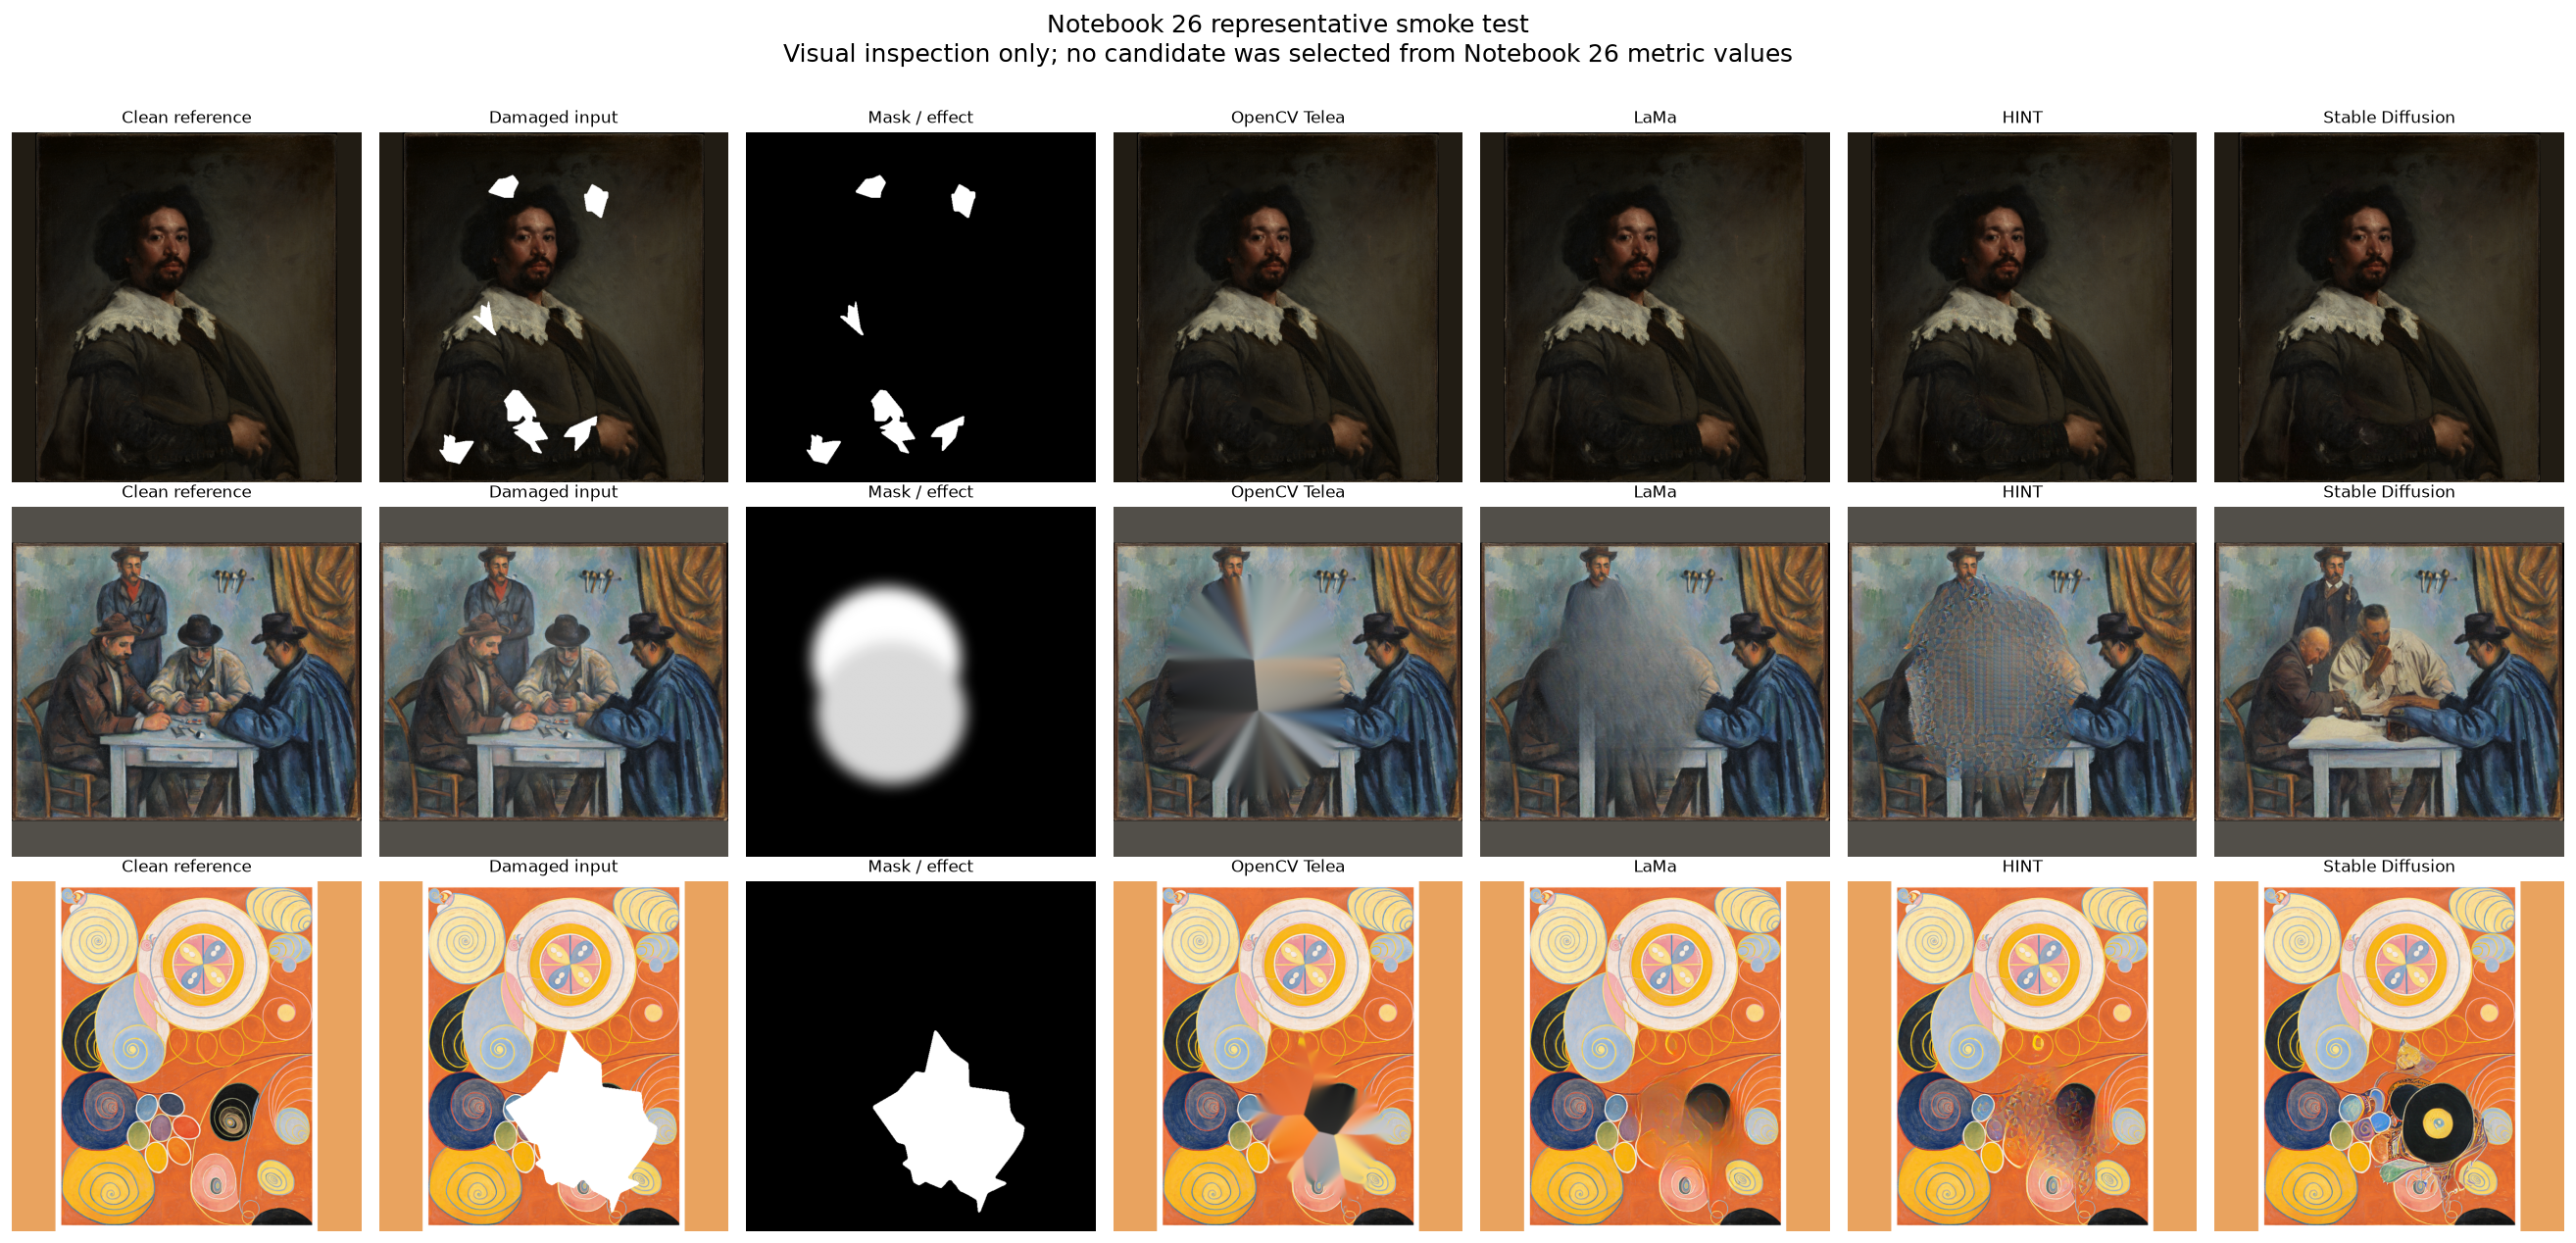

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_population_smoke,selected_candidate_population,The exact configured candidate population was selected.,blocking,10504,10504,True,
1,batch_3_population_smoke,candidate_identity_uniqueness,Candidate IDs and model-case selections are unique.,blocking,"{""duplicate_model_case_rows"": 0, ""unique_candidate_ids"": 10504}","{""duplicate_model_case_rows"": 0, ""unique_candidate_ids"": 10504}",True,
2,batch_3_population_smoke,core_model_candidate_counts,"Each full method covers exactly 2,620 candidates.",blocking,"{""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""stable_diffusion_inpainting"": 2620}","{""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""stable_diffusion_inpainting"": 2620}",True,
3,batch_3_population_smoke,common_core_case_coverage,"All four full methods cover the same 2,620 cases.",blocking,2620,"{""common_intersection"": 2620, ""hint_places2"": 2620, ""lama"": 2620, ""opencv_telea"": 2620, ""stable_diffusion_inpainting"": 2620}",True,
4,batch_3_population_smoke,evaluated_experiment_coverage,The selected core cases preserve the exact four-experiment contract.,blocking,"{""canonical_missing_region"": 1500, ""damage_size_sensitivity"": 245, ""mask_robustness"": 525, ""synthetic_degradation"": 350}","{""canonical_missing_region"": 1500, ""damage_size_sensitivity"": 245, ""mask_robustness"": 525, ""synthetic_degradation"": 350}",True,
5,batch_3_population_smoke,zero_control_and_quality_populations,Canonical zero controls remain separate from nonzero restoration-quality candidates.,blocking,"{""all_nonzero_candidates"": 9304, ""core_quality_candidates"": 9280, ""zero_control_candidates"": 1200}","{""all_nonzero_candidates"": 9304, ""core_quality_candidates"": 9280, ""zero_control_candidates"": 1200}",True,
6,batch_3_population_smoke,bounded_sdxl_scope,The bounded SDXL cases remain nested within the full-method case population and descriptive only.,blocking,"{""candidates"": 24, ""coverage_role"": ""bounded_descriptive_only"", ""nested_in_core_cases"": true}","{""candidates"": 24, ""coverage_roles"": [""bounded_descriptive_only""], ""nested_in_core_cases"": true}",True,
7,batch_3_population_smoke,metric_independent_selection_fields,"No quality, rank, or trust value exists in the candidate-selection table.",blocking,True,True,True,
8,batch_3_population_smoke,selected_image_paths,"Every unique selected clean, damaged, mask, and restored image path exists.",blocking,"{""missing_paths"": 0}","{""missing_paths"": 0, ""unique_paths"": 16044}",True,
9,batch_3_population_smoke,representative_smoke_population,Three representative cases contain all four full-method restorations and valid displayed paths.,blocking,"{""candidate_rows"": 12, ""cases"": 3, ""displayed_paths"": 21, ""missing_paths"": 0}","{""candidate_rows"": 12, ""cases"": 3, ""displayed_paths"": 21, ""missing_paths"": 0}",True,


Batch 3 passed.
Batch 3 checks: 10
Blocking failures: 0
All selected image paths exist: True
No canonical Notebook 26 artifact has been written.
Next batch: full quality-evidence loading and normalization.


In [11]:
SMOKE_MODEL_ORDER = list(
    POPULATION["core_model_order"]
)

SMOKE_MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
}


def read_smoke_image(
    relative_path: str,
    *,
    force_rgb: bool = True,
) -> np.ndarray:
    """Read one smoke-test image without retaining an open file handle."""
    path = resolve_selected_image_path(
        relative_path
    )

    with Image.open(path) as image:
        if force_rgb:
            image = image.convert("RGB")
        else:
            image = image.convert("L")

        return np.asarray(image)


smoke_case_order = (
    SMOKE_CASE_SELECTION["case_id"]
    .astype(str)
    .tolist()
)

shared_smoke_column_count = 3
smoke_column_count = (
    shared_smoke_column_count
    + len(SMOKE_MODEL_ORDER)
)

figure, axes = plt.subplots(
    nrows=len(smoke_case_order),
    ncols=smoke_column_count,
    figsize=(22, 10.5),
    squeeze=False,
)

for row_index, case_id in enumerate(
    smoke_case_order
):
    case_rows = SMOKE_CANDIDATES.loc[
        SMOKE_CANDIDATES["case_id"]
        .astype(str)
        .eq(case_id)
    ].copy()

    if len(case_rows) != len(
        SMOKE_MODEL_ORDER
    ):
        raise RuntimeError(
            f"Smoke case {case_id!r} does not "
            f"contain exactly "
            f"{len(SMOKE_MODEL_ORDER)} "
            "core candidates."
        )

    first_row = case_rows.iloc[0]
    selection_role = str(
        first_row["selection_role"]
    )

    shared_images = [
        (
            "Clean reference",
            read_smoke_image(
                str(
                    first_row[
                        "clean_image_path"
                    ]
                )
            ),
            None,
        ),
        (
            "Damaged input",
            read_smoke_image(
                str(
                    first_row[
                        "input_image_path"
                    ]
                )
            ),
            None,
        ),
        (
            "Mask / effect",
            read_smoke_image(
                str(
                    first_row[
                        "mask_or_effect_path"
                    ]
                ),
                force_rgb=False,
            ),
            "gray",
        ),
    ]

    for column_index, (
        title,
        image_array,
        colour_map,
    ) in enumerate(shared_images):
        axes[row_index, column_index].imshow(
            image_array,
            cmap=colour_map,
        )
        axes[row_index, column_index].set_title(
            title,
            fontsize=10,
        )
        axes[row_index, column_index].axis("off")

    for model_offset, model_id in enumerate(
        SMOKE_MODEL_ORDER,
        start=shared_smoke_column_count,
    ):
        model_rows = case_rows.loc[
            case_rows["model_id"]
            .astype(str)
            .eq(model_id)
        ]

        if len(model_rows) != 1:
            raise RuntimeError(
                f"Smoke case {case_id!r} has "
                f"{len(model_rows)} rows for "
                f"{model_id!r}."
            )

        model_row = model_rows.iloc[0]
        restored_image = read_smoke_image(
            str(model_row["restored_path"])
        )

        axes[row_index, model_offset].imshow(
            restored_image
        )
        axes[row_index, model_offset].set_title(
            SMOKE_MODEL_LABELS[model_id],
            fontsize=10,
        )
        axes[row_index, model_offset].axis("off")

    axes[row_index, 0].set_ylabel(
        (
            f"{selection_role.replace('_', ' ').title()}\n"
            f"{case_id}"
        ),
        fontsize=9,
    )

figure.suptitle(
    (
        "Notebook 26 representative smoke test\n"
        "Visual inspection only; no candidate was selected from "
        "Notebook 26 metric values"
    ),
    fontsize=15,
    y=1.01,
)

figure.tight_layout()
plt.show()
plt.close(figure)

core_model_counts = (
    CORE_CANDIDATES.groupby("model_id")
    .size()
    .to_dict()
)

core_experiment_case_counts = (
    CORE_CASES.groupby("experiment_id")
    .size()
    .to_dict()
)

expected_core_model_counts = {
    str(model_id): int(count)
    for model_id, count in EXPECTED[
        "candidates_by_core_model"
    ].items()
}

expected_core_experiment_counts = {
    str(experiment_id): int(count)
    for experiment_id, count in POPULATION[
        "experiment_case_counts"
    ].items()
}

core_case_sets = {
    model_id: set(
        CORE_CANDIDATES.loc[
            CORE_CANDIDATES["model_id"]
            .astype(str)
            .eq(model_id),
            "case_id",
        ].astype(str)
    )
    for model_id in POPULATION[
        "core_model_order"
    ]
}

common_core_case_set = set.intersection(
    *core_case_sets.values()
)

sdxl_case_set = set(
    BOUNDED_SDXL_CANDIDATES[
        "case_id"
    ].astype(str)
)

selection_metric_columns = {
    "comparison_value",
    "directional_utility",
    "model_rank",
    "quality_score",
    "combined_score",
    "trust_score",
}

metric_columns_absent = (
    selection_metric_columns.isdisjoint(
        SELECTED_CANDIDATES.columns
    )
)

expected_smoke_cases = len(
    SMOKE_SELECTION_ROLES
)

expected_smoke_candidate_rows = (
    expected_smoke_cases
    * len(SMOKE_MODEL_ORDER)
)

expected_smoke_paths = (
    expected_smoke_cases
    * (
        shared_smoke_column_count
        + len(SMOKE_MODEL_ORDER)
    )
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="selected_candidate_population",
    check_description=(
        "The exact configured candidate population was selected."
    ),
    severity="blocking",
    expected=int(EXPECTED["selected_candidates"]),
    observed=len(SELECTED_CANDIDATES),
    passed=(
        len(SELECTED_CANDIDATES)
        == int(EXPECTED["selected_candidates"])
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="candidate_identity_uniqueness",
    check_description=(
        "Candidate IDs and model-case selections are unique."
    ),
    severity="blocking",
    expected={
        "unique_candidate_ids": int(
            EXPECTED["selected_candidates"]
        ),
        "duplicate_model_case_rows": 0,
    },
    observed={
        "unique_candidate_ids": (
            SELECTED_CANDIDATES[
                "candidate_id"
            ].nunique()
        ),
        "duplicate_model_case_rows": int(
            SELECTED_CANDIDATES.duplicated(
                ["model_id", "case_id"],
                keep=False,
            ).sum()
        ),
    },
    passed=(
        SELECTED_CANDIDATES[
            "candidate_id"
        ].nunique()
        == int(EXPECTED["selected_candidates"])
        and not SELECTED_CANDIDATES.duplicated(
            ["model_id", "case_id"],
            keep=False,
        ).any()
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="core_model_candidate_counts",
    check_description=(
        "Each full method covers exactly 2,620 candidates."
    ),
    severity="blocking",
    expected=expected_core_model_counts,
    observed=core_model_counts,
    passed=(
        core_model_counts
        == expected_core_model_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="common_core_case_coverage",
    check_description=(
        "All four full methods cover the same 2,620 cases."
    ),
    severity="blocking",
    expected=int(EXPECTED["evaluated_cases"]),
    observed={
        model_id: len(case_ids)
        for model_id, case_ids
        in core_case_sets.items()
    }
    | {
        "common_intersection": len(
            common_core_case_set
        )
    },
    passed=(
        len(common_core_case_set)
        == int(EXPECTED["evaluated_cases"])
        and all(
            case_ids == common_core_case_set
            for case_ids in core_case_sets.values()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="evaluated_experiment_coverage",
    check_description=(
        "The selected core cases preserve the exact "
        "four-experiment contract."
    ),
    severity="blocking",
    expected=expected_core_experiment_counts,
    observed=core_experiment_case_counts,
    passed=(
        core_experiment_case_counts
        == expected_core_experiment_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="zero_control_and_quality_populations",
    check_description=(
        "Canonical zero controls remain separate from "
        "nonzero restoration-quality candidates."
    ),
    severity="blocking",
    expected={
        "zero_control_candidates": int(
            EXPECTED[
                "zero_control_core_candidates"
            ]
        ),
        "core_quality_candidates": int(
            EXPECTED["quality_core_candidates"]
        ),
        "all_nonzero_candidates": int(
            EXPECTED[
                "mapped_nonzero_candidates_with_sdxl"
            ]
        ),
    },
    observed={
        "zero_control_candidates": len(
            ZERO_CONTROL_CANDIDATES
        ),
        "core_quality_candidates": len(
            CORE_QUALITY_CANDIDATES
        ),
        "all_nonzero_candidates": len(
            QUALITY_CANDIDATES
        ),
    },
    passed=(
        len(ZERO_CONTROL_CANDIDATES)
        == int(
            EXPECTED[
                "zero_control_core_candidates"
            ]
        )
        and len(CORE_QUALITY_CANDIDATES)
        == int(EXPECTED["quality_core_candidates"])
        and len(QUALITY_CANDIDATES)
        == int(
            EXPECTED[
                "mapped_nonzero_candidates_with_sdxl"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="bounded_sdxl_scope",
    check_description=(
        "The bounded SDXL cases remain nested within the "
        "full-method case population and descriptive only."
    ),
    severity="blocking",
    expected={
        "candidates": int(
            EXPECTED["bounded_sdxl_candidates"]
        ),
        "coverage_role": "bounded_descriptive_only",
        "nested_in_core_cases": True,
    },
    observed={
        "candidates": len(
            BOUNDED_SDXL_CANDIDATES
        ),
        "coverage_roles": sorted(
            BOUNDED_SDXL_CANDIDATES[
                "coverage_role"
            ].astype(str).unique().tolist()
        ),
        "nested_in_core_cases": (
            sdxl_case_set.issubset(
                common_core_case_set
            )
        ),
    },
    passed=(
        len(BOUNDED_SDXL_CANDIDATES)
        == int(EXPECTED["bounded_sdxl_candidates"])
        and set(
            BOUNDED_SDXL_CANDIDATES[
                "coverage_role"
            ].astype(str)
        ) == {"bounded_descriptive_only"}
        and sdxl_case_set.issubset(
            common_core_case_set
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="metric_independent_selection_fields",
    check_description=(
        "No quality, rank, or trust value exists in the "
        "candidate-selection table."
    ),
    severity="blocking",
    expected=True,
    observed=metric_columns_absent,
    passed=metric_columns_absent,
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="selected_image_paths",
    check_description=(
        "Every unique selected clean, damaged, mask, "
        "and restored image path exists."
    ),
    severity="blocking",
    expected={
        "missing_paths": 0,
    },
    observed={
        "unique_paths": len(
            SELECTED_PATH_AUDIT
        ),
        "missing_paths": int(
            (
                ~SELECTED_PATH_AUDIT["exists"]
            ).sum()
        ),
    },
    passed=bool(
        SELECTED_PATH_AUDIT["exists"].all()
    ),
)

VALIDATION.add(
    validation_stage="batch_3_population_smoke",
    check_id="representative_smoke_population",
    check_description=(
        "Three representative cases contain all four "
        "full-method restorations and valid displayed paths."
    ),
    severity="blocking",
    expected={
        "cases": expected_smoke_cases,
        "candidate_rows": expected_smoke_candidate_rows,
        "displayed_paths": expected_smoke_paths,
        "missing_paths": 0,
    },
    observed={
        "cases": SMOKE_CANDIDATES[
            "case_id"
        ].nunique(),
        "candidate_rows": len(
            SMOKE_CANDIDATES
        ),
        "displayed_paths": len(
            SMOKE_PATH_AUDIT
        ),
        "missing_paths": int(
            (
                ~SMOKE_PATH_AUDIT["exists"]
            ).sum()
        ),
    },
    passed=(
        SMOKE_CANDIDATES[
            "case_id"
        ].nunique()
        == expected_smoke_cases
        and len(SMOKE_CANDIDATES)
        == expected_smoke_candidate_rows
        and len(SMOKE_PATH_AUDIT)
        == expected_smoke_paths
        and bool(
            SMOKE_PATH_AUDIT["exists"].all()
        )
    ),
)

BATCH_3_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_3_population_smoke")
    ]
    .reset_index(drop=True)
)

display(BATCH_3_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 3 passed.")
print(f"Batch 3 checks: {len(BATCH_3_CHECKS)}")
print(
    "Blocking failures: "
    f"{int((~BATCH_3_CHECKS['passed']).sum())}"
)
print(
    "All selected image paths exist: "
    f"{bool(SELECTED_PATH_AUDIT['exists'].all())}"
)
print("No canonical Notebook 26 artifact has been written.")
print("Next batch: full quality-evidence loading and normalization.")

## Batch 4 — Full quality-evidence loading and normalization

Load the six validated metric sources and normalize their selected rows into one common evidence structure.

The sources are:

- Notebook 13 classical pixel and structural metrics;
- Notebook 14 LPIPS perceptual metrics;
- Notebook 15 CLIP and DINOv2 feature metrics;
- Notebook 16 spatial diagnostics;
- Notebook 17 texture, colour, and seam evidence;
- Notebook 20 semantic and structural evidence.

Large CSVs are read in bounded chunks. Only rows belonging to the 10,504 selected candidates are retained in memory.

This batch then selects the 11 approved quality anchors for every nonzero candidate and normalizes runtime separately.

Important boundaries:

- zero controls remain outside restoration-quality inference;
- SDXL remains a bounded descriptive subset;
- runtime does not enter quality ranking;
- not-applicable metric rows remain explicit;
- no combined quality, efficiency, uncertainty, or trust score is created.

In [12]:
import gc
import time


QUALITY_SOURCE_INPUTS = {
    "classical": "classical_metrics_path",
    "perceptual": "lpips_metrics_path",
    "feature": "feature_metrics_path",
    "spatial": "spatial_metrics_path",
    "local_consistency": "local_metrics_path",
    "semantic_structural": "semantic_metrics_path",
}

selected_candidate_ids = set(
    SELECTED_CANDIDATES[
        "candidate_id"
    ].astype(str)
)

QUALITY_SOURCE_TABLES = {}
source_loading_records = []

CSV_CHUNK_ROWS = 200_000

for source_index, (
    source_key,
    input_key,
) in enumerate(
    QUALITY_SOURCE_INPUTS.items(),
    start=1,
):
    source_path = INPUT_PATHS[input_key]
    loading_started = time.perf_counter()

    print(
        f"[{source_index}/{len(QUALITY_SOURCE_INPUTS)}] "
        f"Loading selected {source_key} rows from "
        f"{source_path.name}"
    )

    selected_chunks = []
    scanned_rows = 0
    selected_rows = 0
    chunk_count = 0

    for chunk in pd.read_csv(
        source_path,
        chunksize=CSV_CHUNK_ROWS,
        low_memory=False,
        dtype={"candidate_id": "string"},
    ):
        chunk_count += 1
        scanned_rows += len(chunk)

        selected_chunk = chunk.loc[
            chunk["candidate_id"]
            .astype(str)
            .isin(selected_candidate_ids)
        ].copy()

        if not selected_chunk.empty:
            selected_rows += len(selected_chunk)
            selected_chunks.append(
                selected_chunk
            )

        if chunk_count % 5 == 0:
            print(
                f"    scanned {scanned_rows:,} rows; "
                f"retained {selected_rows:,}"
            )

    if not selected_chunks:
        raise RuntimeError(
            f"No selected rows were found in "
            f"{source_path}."
        )

    source_frame = pd.concat(
        selected_chunks,
        ignore_index=True,
        sort=False,
        copy=False,
    )

    del selected_chunks
    gc.collect()

    elapsed_seconds = (
        time.perf_counter() - loading_started
    )

    QUALITY_SOURCE_TABLES[source_key] = (
        source_frame
    )

    source_loading_records.append(
        {
            "source_key": source_key,
            "input_key": input_key,
            "source_rows_scanned": scanned_rows,
            "selected_rows_retained": len(
                source_frame
            ),
            "columns": len(
                source_frame.columns
            ),
            "source_size_mib": (
                source_path.stat().st_size
                / (1024 ** 2)
            ),
            "chunk_count": chunk_count,
            "load_seconds": elapsed_seconds,
        }
    )

    print(
        f"    completed: scanned "
        f"{scanned_rows:,}; retained "
        f"{len(source_frame):,} rows in "
        f"{elapsed_seconds:.2f} seconds"
    )

SOURCE_LOADING_SUMMARY = pd.DataFrame(
    source_loading_records
)

display(SOURCE_LOADING_SUMMARY)

print("All six selected quality-evidence populations loaded.")
print(
    "Selected raw rows in memory: "
    f"{sum(len(frame) for frame in QUALITY_SOURCE_TABLES.values()):,}"
)
print(
    "Total source size scanned: "
    f"{SOURCE_LOADING_SUMMARY['source_size_mib'].sum():.1f} MiB"
)

[1/6] Loading selected classical rows from classical_metrics.csv
    completed: scanned 477,753; retained 296,553 rows in 3.25 seconds
[2/6] Loading selected perceptual rows from lpips_metrics.csv
    completed: scanned 31,608; retained 19,808 rows in 0.40 seconds
[3/6] Loading selected feature rows from feature_metrics.csv
    completed: scanned 63,216; retained 39,616 rows in 1.22 seconds
[4/6] Loading selected spatial rows from spatial_diagnostics.csv
    completed: scanned 143,247; retained 88,747 rows in 2.85 seconds
[5/6] Loading selected local_consistency rows from local_consistency.csv
    scanned 1,000,000 rows; retained 1,000,000
    scanned 2,000,000 rows; retained 1,266,280
    completed: scanned 2,060,667; retained 1,269,567 rows in 46.05 seconds
[6/6] Loading selected semantic_structural rows from semantic_structural_metrics.csv
    completed: scanned 447,312; retained 282,112 rows in 20.68 seconds


,source_key,input_key,source_rows_scanned,selected_rows_retained,columns,source_size_mib,chunk_count,load_seconds
0,classical,classical_metrics_path,477753,296553,16,137.685447,3,3.254149
1,perceptual,lpips_metrics_path,31608,19808,26,13.293438,1,0.402872
2,feature,feature_metrics_path,63216,39616,30,38.188547,1,1.224440
3,spatial,spatial_metrics_path,143247,88747,42,78.143085,1,2.845487
4,local_consistency,local_metrics_path,2060667,1269567,35,1093.391612,11,46.047686
5,semantic_structural,semantic_metrics_path,447312,282112,40,304.538003,3,20.677911


All six selected quality-evidence populations loaded.
Selected raw rows in memory: 1,996,403
Total source size scanned: 1665.2 MiB


In [13]:
SELECTED_RAW_SOURCE_COUNTS = {
    source_key: len(source_frame)
    for source_key, source_frame
    in QUALITY_SOURCE_TABLES.items()
}

EXPECTED_SELECTED_RAW_SOURCE_COUNTS = {
    "classical": int(
        EXPECTED[
            "selected_classical_source_rows"
        ]
    ),
    "perceptual": int(
        EXPECTED[
            "selected_lpips_source_rows"
        ]
    ),
    "feature": int(
        EXPECTED[
            "selected_feature_source_rows"
        ]
    ),
    "spatial": int(
        EXPECTED[
            "selected_spatial_source_rows"
        ]
    ),
    "local_consistency": int(
        EXPECTED[
            "selected_local_source_rows"
        ]
    ),
    "semantic_structural": int(
        EXPECTED[
            "selected_semantic_source_rows"
        ]
    ),
}

normalization_started = time.perf_counter()

print("Normalizing the selected quality evidence...")

NORMALIZED_QUALITY_EVIDENCE = (
    normalise_quality_evidence(
        QUALITY_SOURCE_TABLES,
        SELECTED_CANDIDATES,
        config=ANALYSIS_CONFIG,
    )
)

normalization_seconds = (
    time.perf_counter() - normalization_started
)

NORMALIZED_SOURCE_COUNTS = (
    NORMALIZED_QUALITY_EVIDENCE.groupby(
        "source_notebook_id"
    )
    .size()
    .to_dict()
)

EXPECTED_NORMALIZED_SOURCE_COUNTS = {
    "13": int(
        EXPECTED[
            "selected_classical_source_rows"
        ]
    ),
    "14": int(
        EXPECTED[
            "selected_lpips_source_rows"
        ]
    ),
    "15": int(
        EXPECTED[
            "selected_feature_source_rows"
        ]
    ),
    "16": int(
        EXPECTED["normalized_spatial_rows"]
    ),
    "17": int(
        EXPECTED[
            "selected_local_source_rows"
        ]
    ),
    "20": int(
        EXPECTED[
            "selected_semantic_source_rows"
        ]
    ),
}

NORMALIZED_EVIDENCE_COVERAGE = (
    NORMALIZED_QUALITY_EVIDENCE.groupby(
        [
            "source_notebook_id",
            "evidence_family",
            "status",
        ],
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
        metrics=("metric_name", "nunique"),
        regions=("region_id", "nunique"),
    )
    .reset_index()
    .sort_values(
        [
            "source_notebook_id",
            "evidence_family",
            "status",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

source_count_comparison = pd.DataFrame(
    [
        {
            "source_key": source_key,
            "selected_raw_rows": (
                SELECTED_RAW_SOURCE_COUNTS[
                    source_key
                ]
            ),
            "expected_raw_rows": (
                EXPECTED_SELECTED_RAW_SOURCE_COUNTS[
                    source_key
                ]
            ),
            "matches_contract": (
                SELECTED_RAW_SOURCE_COUNTS[
                    source_key
                ]
                == EXPECTED_SELECTED_RAW_SOURCE_COUNTS[
                    source_key
                ]
            ),
        }
        for source_key
        in QUALITY_SOURCE_INPUTS
    ]
)

display(source_count_comparison)
display(
    NORMALIZED_EVIDENCE_COVERAGE.head(30)
)

print("Quality evidence normalized.")
print(
    "Normalized rows: "
    f"{len(NORMALIZED_QUALITY_EVIDENCE):,}"
)
print(
    "Covered candidates: "
    f"{NORMALIZED_QUALITY_EVIDENCE['candidate_id'].nunique():,}"
)
print(
    "Normalization seconds: "
    f"{normalization_seconds:.2f}"
)
print(
    "Normalized statuses: "
    f"{NORMALIZED_QUALITY_EVIDENCE['status'].value_counts().to_dict()}"
)

Normalizing the selected quality evidence...


,source_key,selected_raw_rows,expected_raw_rows,matches_contract
0,classical,296553,296553,True
1,perceptual,19808,19808,True
2,feature,39616,39616,True
3,spatial,88747,88747,True
4,local_consistency,1269567,1269567,True
5,semantic_structural,282112,282112,True


,source_notebook_id,evidence_family,status,rows,candidates,cases,metrics,regions
0,13,classical_pixel,ok,266241,10504,2620,3,10
1,13,ssim,ok,30312,10504,2620,1,3
2,14,perceptual,ok,19808,10504,2620,1,2
3,15,feature_similarity,ok,39616,10504,2620,2,2
4,16,spatial_diagnostics,ok,1242458,10504,2620,14,10
5,17,colour,not_applicable,20704,8074,2015,1,10
6,17,colour,ok,778019,10504,2620,9,10
7,17,seam,ok,167472,9304,2320,13,4
8,17,texture_descriptor,ok,74432,9304,2320,8,1
9,17,texture_map,ok,228940,9304,2320,4,7


Quality evidence normalized.
Normalized rows: 3,150,114
Covered candidates: 10,504
Normalization seconds: 76.10
Normalized statuses: {'ok': 3129410, 'not_applicable': 20704}


In [14]:
anchor_selection_started = (
    time.perf_counter()
)

QUALITY_ANCHORS = (
    select_quality_anchor_values(
        NORMALIZED_QUALITY_EVIDENCE,
        spatial_source=QUALITY_SOURCE_TABLES[
            "spatial"
        ],
        config=ANALYSIS_CONFIG,
    )
)

RUNTIME_EVIDENCE = build_runtime_evidence(
    SELECTED_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

anchor_selection_seconds = (
    time.perf_counter()
    - anchor_selection_started
)

QUALITY_ANCHORS[
    "comparison_value"
] = pd.to_numeric(
    QUALITY_ANCHORS[
        "comparison_value"
    ],
    errors="coerce",
)

QUALITY_ANCHORS[
    "directional_utility"
] = pd.to_numeric(
    QUALITY_ANCHORS[
        "directional_utility"
    ],
    errors="coerce",
)

RUNTIME_EVIDENCE[
    "comparison_value"
] = pd.to_numeric(
    RUNTIME_EVIDENCE[
        "comparison_value"
    ],
    errors="coerce",
)

anchor_count_per_candidate = (
    QUALITY_ANCHORS.groupby(
        "candidate_id"
    )
    .size()
)

anchor_population_summary = (
    QUALITY_ANCHORS.groupby(
        [
            "model_id",
            "evidence_family",
            "anchor_id",
            "comparison_direction",
        ],
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
        paintings=(
            "painting_id",
            "nunique",
        ),
        finite_values=(
            "comparison_value",
            lambda values: int(
                pd.to_numeric(
                    values,
                    errors="coerce",
                ).notna().sum()
            ),
        ),
    )
    .reset_index()
)

runtime_population_summary = (
    RUNTIME_EVIDENCE.groupby(
        [
            "model_id",
            "status",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
        median_seconds=(
            "comparison_value",
            "median",
        ),
        mean_seconds=(
            "comparison_value",
            "mean",
        ),
    )
    .reset_index()
)

core_anchor_rows = QUALITY_ANCHORS.loc[
    ~QUALITY_ANCHORS["model_id"]
    .astype(str)
    .eq("sdxl_inpainting")
].copy()

sdxl_anchor_rows = QUALITY_ANCHORS.loc[
    QUALITY_ANCHORS["model_id"]
    .astype(str)
    .eq("sdxl_inpainting")
].copy()

normalized_statuses = set(
    NORMALIZED_QUALITY_EVIDENCE[
        "status"
    ].astype(str)
)

expected_anchor_rows = int(
    EXPECTED[
        "all_nonzero_anchor_rows_with_sdxl"
    ]
)

expected_anchor_candidates = int(
    EXPECTED[
        "mapped_nonzero_candidates_with_sdxl"
    ]
)

expected_anchor_count = int(
    EXPECTED["quality_anchors"]
)

expected_core_anchor_rows = int(
    EXPECTED["primary_core_anchor_rows"]
)

expected_sdxl_anchor_rows = (
    int(EXPECTED["bounded_sdxl_candidates"])
    * expected_anchor_count
)

expected_runtime_rows = int(
    EXPECTED["selected_candidates"]
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="selected_raw_source_rows",
    check_description=(
        "Every raw metric source contributes its exact "
        "contracted selected rows."
    ),
    severity="blocking",
    expected=EXPECTED_SELECTED_RAW_SOURCE_COUNTS,
    observed=SELECTED_RAW_SOURCE_COUNTS,
    passed=(
        SELECTED_RAW_SOURCE_COUNTS
        == EXPECTED_SELECTED_RAW_SOURCE_COUNTS
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="normalized_quality_rows",
    check_description=(
        "The common quality-evidence table contains "
        "the exact contracted number of rows."
    ),
    severity="blocking",
    expected=EXPECTED[
        "normalized_quality_rows"
    ],
    observed=len(
        NORMALIZED_QUALITY_EVIDENCE
    ),
    passed=(
        len(NORMALIZED_QUALITY_EVIDENCE)
        == int(
            EXPECTED[
                "normalized_quality_rows"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="normalized_candidate_coverage",
    check_description=(
        "Normalized evidence covers all selected candidates."
    ),
    severity="blocking",
    expected=expected_runtime_rows,
    observed=(
        NORMALIZED_QUALITY_EVIDENCE[
            "candidate_id"
        ].nunique()
    ),
    passed=(
        NORMALIZED_QUALITY_EVIDENCE[
            "candidate_id"
        ].nunique()
        == expected_runtime_rows
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="normalized_source_rows",
    check_description=(
        "The six normalized notebook sources retain "
        "their exact row counts."
    ),
    severity="blocking",
    expected=EXPECTED_NORMALIZED_SOURCE_COUNTS,
    observed=NORMALIZED_SOURCE_COUNTS,
    passed=(
        NORMALIZED_SOURCE_COUNTS
        == EXPECTED_NORMALIZED_SOURCE_COUNTS
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="normalized_status_vocabulary",
    check_description=(
        "Normalized rows use only validated or explicit "
        "not-applicable statuses."
    ),
    severity="blocking",
    expected=["not_applicable", "ok"],
    observed=sorted(normalized_statuses),
    passed=normalized_statuses.issubset(
        {"ok", "not_applicable"}
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="quality_anchor_population",
    check_description=(
        "Every nonzero candidate receives all 11 "
        "separate quality anchors."
    ),
    severity="blocking",
    expected={
        "rows": expected_anchor_rows,
        "candidates": expected_anchor_candidates,
        "anchors": expected_anchor_count,
    },
    observed={
        "rows": len(QUALITY_ANCHORS),
        "candidates": QUALITY_ANCHORS[
            "candidate_id"
        ].nunique(),
        "anchors": QUALITY_ANCHORS[
            "anchor_id"
        ].nunique(),
    },
    passed=(
        len(QUALITY_ANCHORS)
        == expected_anchor_rows
        and QUALITY_ANCHORS[
            "candidate_id"
        ].nunique()
        == expected_anchor_candidates
        and QUALITY_ANCHORS[
            "anchor_id"
        ].nunique()
        == expected_anchor_count
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="anchors_per_candidate",
    check_description=(
        "Every nonzero candidate has exactly 11 separate anchors."
    ),
    severity="blocking",
    expected={
        expected_anchor_count: (
            expected_anchor_candidates
        )
    },
    observed=(
        anchor_count_per_candidate
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    passed=bool(
        anchor_count_per_candidate
        .eq(expected_anchor_count)
        .all()
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="anchor_core_and_sdxl_scope",
    check_description=(
        "Full-method and bounded SDXL anchor rows remain separate."
    ),
    severity="blocking",
    expected={
        "core_rows": expected_core_anchor_rows,
        "bounded_sdxl_rows": expected_sdxl_anchor_rows,
    },
    observed={
        "core_rows": len(core_anchor_rows),
        "bounded_sdxl_rows": len(
            sdxl_anchor_rows
        ),
    },
    passed=(
        len(core_anchor_rows)
        == expected_core_anchor_rows
        and len(sdxl_anchor_rows)
        == expected_sdxl_anchor_rows
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="anchor_values_finite",
    check_description=(
        "Every selected anchor contains a finite comparison value."
    ),
    severity="blocking",
    expected=expected_anchor_rows,
    observed=int(
        np.isfinite(
            QUALITY_ANCHORS[
                "comparison_value"
            ].to_numpy(dtype=float)
        ).sum()
    ),
    passed=bool(
        np.isfinite(
            QUALITY_ANCHORS[
                "comparison_value"
            ].to_numpy(dtype=float)
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="zero_controls_excluded_from_anchors",
    check_description=(
        "Canonical zero controls do not enter "
        "restoration-quality anchor analysis."
    ),
    severity="blocking",
    expected=0,
    observed=int(
        QUALITY_ANCHORS[
            "is_zero_control"
        ].fillna(False).astype(bool).sum()
    ),
    passed=not bool(
        QUALITY_ANCHORS[
            "is_zero_control"
        ].fillna(False).astype(bool).any()
    ),
)

VALIDATION.add(
    validation_stage="batch_4_quality_normalization",
    check_id="runtime_evidence_scope",
    check_description=(
        "Runtime covers all selected candidates and "
        "remains outside quality ranking."
    ),
    severity="blocking",
    expected={
        "rows": expected_runtime_rows,
        "finite_values": expected_runtime_rows,
        "quality_ranking_eligible": False,
    },
    observed={
        "rows": len(RUNTIME_EVIDENCE),
        "finite_values": int(
            np.isfinite(
                RUNTIME_EVIDENCE[
                    "comparison_value"
                ].to_numpy(dtype=float)
            ).sum()
        ),
        "quality_ranking_eligible": bool(
            RUNTIME_EVIDENCE[
                "quality_ranking_eligible"
            ].fillna(False).astype(bool).any()
        ),
    },
    passed=(
        len(RUNTIME_EVIDENCE)
        == expected_runtime_rows
        and np.isfinite(
            RUNTIME_EVIDENCE[
                "comparison_value"
            ].to_numpy(dtype=float)
        ).all()
        and not bool(
            RUNTIME_EVIDENCE[
                "quality_ranking_eligible"
            ].fillna(False).astype(bool).any()
        )
    ),
)

display(anchor_population_summary.head(40))
display(runtime_population_summary)

BATCH_4_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_4_quality_normalization"
        )
    ]
    .reset_index(drop=True)
)

display(BATCH_4_CHECKS)

VALIDATION.raise_for_blocking()

raw_source_rows_released = sum(
    len(frame)
    for frame in QUALITY_SOURCE_TABLES.values()
)

del QUALITY_SOURCE_TABLES
garbage_collected_objects = gc.collect()

print("Batch 4 passed.")
print(f"Batch 4 checks: {len(BATCH_4_CHECKS)}")
print(
    "Blocking failures: "
    f"{int((~BATCH_4_CHECKS['passed']).sum())}"
)
print(
    "Quality anchors: "
    f"{len(QUALITY_ANCHORS):,}"
)
print(
    "Runtime rows: "
    f"{len(RUNTIME_EVIDENCE):,}"
)
print(
    "Released selected raw source rows: "
    f"{raw_source_rows_released:,}"
)
print(
    "Garbage-collected objects: "
    f"{garbage_collected_objects:,}"
)
print("No canonical Notebook 26 artifact has been written.")
print("Next batch: grouped descriptive summaries.")

,model_id,evidence_family,anchor_id,comparison_direction,rows,candidates,cases,paintings,finite_values
0,hint_places2,classical_pixel,classical_masked_mae,lower_is_better,2320,2320,2320,300,2320
1,hint_places2,colour,colour_masked_delta_e,lower_is_better,2320,2320,2320,300,2320
2,hint_places2,feature_similarity,feature_clip_crop,higher_is_better,2320,2320,2320,300,2320
3,hint_places2,feature_similarity,feature_dino_crop,higher_is_better,2320,2320,2320,300,2320
4,hint_places2,local_semantic_preservation,semantic_local_dino,higher_is_better,2320,2320,2320,300,2320
5,hint_places2,perceptual,perceptual_crop_lpips,lower_is_better,2320,2320,2320,300,2320
6,hint_places2,seam,seam_boundary_gradient,lower_is_better,2320,2320,2320,300,2320
7,hint_places2,spatial_diagnostics,spatial_masked_error,lower_is_better,2320,2320,2320,300,2320
8,hint_places2,ssim,structural_crop_ssim,higher_is_better,2320,2320,2320,300,2320
9,hint_places2,structural_layout,structural_affinity_correlation,higher_is_better,2320,2320,2320,300,2320


,model_id,status,candidates,cases,median_seconds,mean_seconds
0,hint_places2,ok,2620,2620,6.677000,6.116698
1,lama,ok,2620,2620,1.450884,1.362781
2,opencv_telea,ok,2620,2620,0.519020,0.552191
3,sdxl_inpainting,ok,24,24,198.031500,199.518875
4,stable_diffusion_inpainting,ok,2620,2620,8.391409,7.643232


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_quality_normalization,selected_raw_source_rows,Every raw metric source contributes its exact contracted selected rows.,blocking,"{""classical"": 296553, ""feature"": 39616, ""local_consistency"": 1269567, ""perceptual"": 19808, ""semantic_structural"": 282112, ""spatial"": 88747}","{""classical"": 296553, ""feature"": 39616, ""local_consistency"": 1269567, ""perceptual"": 19808, ""semantic_structural"": 282112, ""spatial"": 88747}",True,
1,batch_4_quality_normalization,normalized_quality_rows,The common quality-evidence table contains the exact contracted number of rows.,blocking,3150114,3150114,True,
2,batch_4_quality_normalization,normalized_candidate_coverage,Normalized evidence covers all selected candidates.,blocking,10504,10504,True,
3,batch_4_quality_normalization,normalized_source_rows,The six normalized notebook sources retain their exact row counts.,blocking,"{""13"": 296553, ""14"": 19808, ""15"": 39616, ""16"": 1242458, ""17"": 1269567, ""20"": 282112}","{""13"": 296553, ""14"": 19808, ""15"": 39616, ""16"": 1242458, ""17"": 1269567, ""20"": 282112}",True,
4,batch_4_quality_normalization,normalized_status_vocabulary,Normalized rows use only validated or explicit not-applicable statuses.,blocking,"[""not_applicable"", ""ok""]","[""not_applicable"", ""ok""]",True,
5,batch_4_quality_normalization,quality_anchor_population,Every nonzero candidate receives all 11 separate quality anchors.,blocking,"{""anchors"": 11, ""candidates"": 9304, ""rows"": 102344}","{""anchors"": 11, ""candidates"": 9304, ""rows"": 102344}",True,
6,batch_4_quality_normalization,anchors_per_candidate,Every nonzero candidate has exactly 11 separate anchors.,blocking,"{""11"": 9304}","{""11"": 9304}",True,
7,batch_4_quality_normalization,anchor_core_and_sdxl_scope,Full-method and bounded SDXL anchor rows remain separate.,blocking,"{""bounded_sdxl_rows"": 264, ""core_rows"": 102080}","{""bounded_sdxl_rows"": 264, ""core_rows"": 102080}",True,
8,batch_4_quality_normalization,anchor_values_finite,Every selected anchor contains a finite comparison value.,blocking,102344,102344,True,
9,batch_4_quality_normalization,zero_controls_excluded_from_anchors,Canonical zero controls do not enter restoration-quality anchor analysis.,blocking,0,0,True,


Batch 4 passed.
Batch 4 checks: 11
Blocking failures: 0
Quality anchors: 102,344
Runtime rows: 10,504
Released selected raw source rows: 1,996,403
Garbage-collected objects: 0
No canonical Notebook 26 artifact has been written.
Next batch: grouped descriptive summaries.


## Batch 5 — Grouped descriptive summaries

Construct painting-aware descriptive evidence without yet performing new hypothesis tests.

The summaries cover:

- each of the four full methods and every quality anchor;
- the bounded SDXL subset separately;
- the balanced 300-painting canonical population by broad visual category;
- the canonical population by damage type;
- damage-size levels and uncertainty levels from Notebook 23;
- mask-robustness dispersion and sensitivity from Notebook 24;
- degradation-family, severity, and bounded SDXL summaries from Notebook 25;
- evidence availability and explicit non-applicability.

Each quality anchor remains separate. Painting-level medians are used before population summaries so cases, regions, and repeated observations do not receive artificial independence.

The 35-painting focused experiments support exploratory subgroup summaries. They do not establish independent visual-category effects.

No combined score is computed.

In [15]:
def grouped_anchor_descriptives(
    frame: pd.DataFrame,
    *,
    group_columns: list[str],
    population_id: str,
) -> pd.DataFrame:
    """Summarize anchors after reducing repeated rows to paintings."""
    anchor_columns = [
        "model_id",
        "evidence_family",
        "anchor_id",
        "metric_name",
        "feature_model_id",
        "region_id",
        "summary_statistic",
        "comparison_direction",
    ]

    grouping_columns = list(
        dict.fromkeys(
            [
                *group_columns,
                *anchor_columns,
            ]
        )
    )

    required_columns = {
        *grouping_columns,
        "painting_id",
        "case_id",
        "candidate_id",
        "comparison_value",
        "directional_utility",
    }

    missing_columns = sorted(
        required_columns - set(frame.columns)
    )

    if missing_columns:
        raise ValueError(
            "Grouped descriptive input is missing "
            f"columns: {missing_columns}"
        )

    working = frame.copy()
    working["comparison_value"] = pd.to_numeric(
        working["comparison_value"],
        errors="coerce",
    )
    working["directional_utility"] = pd.to_numeric(
        working["directional_utility"],
        errors="coerce",
    )

    painting_level = (
        working.groupby(
            [
                *grouping_columns,
                "painting_id",
            ],
            dropna=False,
        )
        .agg(
            painting_value=(
                "comparison_value",
                "median",
            ),
            painting_directional_utility=(
                "directional_utility",
                "median",
            ),
        )
        .reset_index()
    )

    summary = (
        painting_level.groupby(
            grouping_columns,
            dropna=False,
        )
        .agg(
            estimate=(
                "painting_value",
                "median",
            ),
            painting_mean=(
                "painting_value",
                "mean",
            ),
            painting_std=(
                "painting_value",
                "std",
            ),
            q1=(
                "painting_value",
                lambda values: values.quantile(0.25),
            ),
            q3=(
                "painting_value",
                lambda values: values.quantile(0.75),
            ),
            minimum=(
                "painting_value",
                "min",
            ),
            maximum=(
                "painting_value",
                "max",
            ),
            directional_utility_median=(
                "painting_directional_utility",
                "median",
            ),
            n_paintings=(
                "painting_id",
                "nunique",
            ),
        )
        .reset_index()
    )

    observation_counts = (
        working.groupby(
            grouping_columns,
            dropna=False,
        )
        .agg(
            n_cases=("case_id", "nunique"),
            n_candidates=(
                "candidate_id",
                "nunique",
            ),
            n_observations=(
                "candidate_id",
                "size",
            ),
        )
        .reset_index()
    )

    summary = summary.merge(
        observation_counts,
        on=grouping_columns,
        how="left",
        validate="one_to_one",
    )

    summary["population_id"] = population_id
    summary["independent_unit"] = "painting"
    summary["estimate_name"] = (
        "median_of_painting_medians"
    )
    summary["status"] = np.where(
        np.isfinite(
            pd.to_numeric(
                summary["estimate"],
                errors="coerce",
            )
        ),
        "ok",
        "error",
    )
    summary["issue"] = np.where(
        summary["status"].eq("ok"),
        "",
        "non-finite grouped estimate",
    )

    return summary


ALL_CORE_MODEL_DESCRIPTIVES = (
    grouped_anchor_descriptives(
        core_anchor_rows,
        group_columns=[],
        population_id=(
            "all_nonzero_core_painting_balanced"
        ),
    )
)

SDXL_MODEL_DESCRIPTIVES = (
    grouped_anchor_descriptives(
        sdxl_anchor_rows,
        group_columns=[],
        population_id="bounded_sdxl_descriptive",
    )
)

MODEL_DESCRIPTIVES = (
    pd.concat(
        [
            ALL_CORE_MODEL_DESCRIPTIVES,
            SDXL_MODEL_DESCRIPTIVES,
        ],
        ignore_index=True,
        sort=False,
    )
    .sort_values(
        [
            "population_id",
            "anchor_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(MODEL_DESCRIPTIVES.head(20))

print("Model-level descriptions computed.")
print(
    "Core model-anchor summaries: "
    f"{len(ALL_CORE_MODEL_DESCRIPTIVES):,}"
)
print(
    "Bounded SDXL anchor summaries: "
    f"{len(SDXL_MODEL_DESCRIPTIVES):,}"
)
print(
    "All model-anchor summaries: "
    f"{len(MODEL_DESCRIPTIVES):,}"
)

,model_id,evidence_family,anchor_id,metric_name,feature_model_id,region_id,summary_statistic,comparison_direction,estimate,painting_mean,painting_std,q1,q3,minimum,maximum,directional_utility_median,n_paintings,n_cases,n_candidates,n_observations,population_id,independent_unit,estimate_name,status,issue
0,hint_places2,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,15.269762,15.741341,6.104755,11.120897,18.996719,5.602549,42.088384,-15.269762,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
1,lama,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,11.646478,12.918035,5.723321,8.553233,16.017739,4.438743,35.114559,-11.646478,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
2,opencv_telea,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,14.324611,15.606444,6.097785,11.216569,18.879766,6.094077,36.928005,-14.324611,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
3,stable_diffusion_inpainting,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,25.586065,26.701505,7.420878,21.774329,31.137618,10.607379,54.223082,-25.586065,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
4,hint_places2,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,7.364070,7.777768,2.998407,5.499430,9.586860,2.236090,18.744103,-7.364070,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
5,lama,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,5.427732,6.083509,2.632470,4.173127,7.390088,1.637877,18.006699,-5.427732,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
6,opencv_telea,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,6.507725,7.029325,2.748260,5.029968,8.366540,2.822591,19.514162,-6.507725,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
7,stable_diffusion_inpainting,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,11.646429,11.839279,3.152201,9.612399,13.704451,3.607330,26.448196,-11.646429,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
8,hint_places2,feature_similarity,feature_clip_crop,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,value,higher_is_better,0.990780,0.979817,0.027845,0.980308,0.994461,0.814915,0.998785,0.990780,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,
9,lama,feature_similarity,feature_clip_crop,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,value,higher_is_better,0.994912,0.990265,0.013285,0.991273,0.997091,0.924135,0.998974,0.994912,300,2320,2320,2320,all_nonzero_core_painting_balanced,painting,median_of_painting_medians,ok,


Model-level descriptions computed.
Core model-anchor summaries: 44
Bounded SDXL anchor summaries: 11
All model-anchor summaries: 55


In [16]:
CANONICAL_CORE_ANCHORS = (
    core_anchor_rows.loc[
        core_anchor_rows["experiment_id"]
        .astype(str)
        .eq("canonical_missing_region")
    ]
    .copy()
)

CANONICAL_CORE_ANCHORS[
    "canonical_damage_type"
] = (
    CANONICAL_CORE_ANCHORS["case_id"]
    .astype(str)
    .str.extract(
        r"canonical__p\d+__(.+)$",
        expand=False,
    )
)

expected_canonical_damage_types = {
    "loss_large",
    "loss_small",
    "mixed_damage",
    "scratch_thin",
}

observed_canonical_damage_types = set(
    CANONICAL_CORE_ANCHORS[
        "canonical_damage_type"
    ].dropna().astype(str)
)

if (
    observed_canonical_damage_types
    != expected_canonical_damage_types
):
    raise ValueError(
        "Canonical damage-type extraction changed: "
        f"{sorted(observed_canonical_damage_types)}"
    )

CANONICAL_CATEGORY_DESCRIPTIVES = (
    grouped_anchor_descriptives(
        CANONICAL_CORE_ANCHORS,
        group_columns=["category"],
        population_id=(
            "canonical_nonzero_by_category"
        ),
    )
    .sort_values(
        [
            "category",
            "anchor_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

CANONICAL_DAMAGE_DESCRIPTIVES = (
    grouped_anchor_descriptives(
        CANONICAL_CORE_ANCHORS,
        group_columns=[
            "canonical_damage_type"
        ],
        population_id=(
            "canonical_nonzero_by_damage"
        ),
    )
    .sort_values(
        [
            "canonical_damage_type",
            "anchor_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

category_coverage = (
    CANONICAL_CATEGORY_DESCRIPTIVES.groupby(
        "category"
    )
    .agg(
        summary_rows=(
            "anchor_id",
            "size",
        ),
        models=("model_id", "nunique"),
        anchors=("anchor_id", "nunique"),
        paintings=(
            "n_paintings",
            "max",
        ),
    )
    .reset_index()
)

damage_coverage = (
    CANONICAL_DAMAGE_DESCRIPTIVES.groupby(
        "canonical_damage_type"
    )
    .agg(
        summary_rows=(
            "anchor_id",
            "size",
        ),
        models=("model_id", "nunique"),
        anchors=("anchor_id", "nunique"),
        paintings=(
            "n_paintings",
            "max",
        ),
    )
    .reset_index()
)

display(category_coverage)
display(damage_coverage)
display(
    CANONICAL_CATEGORY_DESCRIPTIVES.head(15)
)
display(
    CANONICAL_DAMAGE_DESCRIPTIVES.head(15)
)

print("Canonical grouped descriptions computed.")
print(
    "Canonical anchor rows: "
    f"{len(CANONICAL_CORE_ANCHORS):,}"
)
print(
    "Category summaries: "
    f"{len(CANONICAL_CATEGORY_DESCRIPTIVES):,}"
)
print(
    "Damage-type summaries: "
    f"{len(CANONICAL_DAMAGE_DESCRIPTIVES):,}"
)

,category,summary_rows,models,anchors,paintings
0,abstraction_surrealism,44,4,11,60
1,architecture_structured,44,4,11,60
2,high_texture_brushwork,44,4,11,60
3,landscape_natural,44,4,11,60
4,portrait_figure,44,4,11,60


,canonical_damage_type,summary_rows,models,anchors,paintings
0,loss_large,44,4,11,300
1,loss_small,44,4,11,300
2,mixed_damage,44,4,11,300
3,scratch_thin,44,4,11,300


,category,model_id,evidence_family,anchor_id,metric_name,feature_model_id,region_id,summary_statistic,comparison_direction,estimate,painting_mean,painting_std,q1,q3,minimum,maximum,directional_utility_median,n_paintings,n_cases,n_candidates,n_observations,population_id,independent_unit,estimate_name,status,issue
0,abstraction_surrealism,hint_places2,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,17.080361,17.310586,7.136596,12.129285,20.997391,5.602549,39.447012,-17.080361,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
1,abstraction_surrealism,lama,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,12.948090,14.085693,6.449479,9.960499,16.966904,4.438743,35.114559,-12.948090,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
2,abstraction_surrealism,opencv_telea,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,17.306649,18.586656,7.151727,13.464328,23.283876,6.285879,36.928005,-17.306649,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
3,abstraction_surrealism,stable_diffusion_inpainting,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,30.452184,30.331048,8.153304,24.848935,35.250487,10.855420,50.279224,-30.452184,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
4,abstraction_surrealism,hint_places2,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,8.063626,8.394512,3.533037,5.892422,10.712024,2.340160,18.744103,-8.063626,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
5,abstraction_surrealism,lama,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,5.957630,6.700452,3.162003,4.771692,8.107541,1.637877,18.006699,-5.957630,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
6,abstraction_surrealism,opencv_telea,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,7.430592,8.385949,3.409659,5.340049,10.615748,3.364093,19.514162,-7.430592,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
7,abstraction_surrealism,stable_diffusion_inpainting,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,13.628773,13.551666,3.751307,11.268643,15.488981,3.607330,26.448196,-13.628773,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
8,abstraction_surrealism,hint_places2,feature_similarity,feature_clip_crop,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,value,higher_is_better,0.993484,0.991674,0.005573,0.989008,0.995983,0.975138,0.998785,0.993484,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,
9,abstraction_surrealism,lama,feature_similarity,feature_clip_crop,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,value,higher_is_better,0.996423,0.994920,0.003696,0.993290,0.997783,0.980965,0.998974,0.996423,60,240,240,240,canonical_nonzero_by_category,painting,median_of_painting_medians,ok,


,canonical_damage_type,model_id,evidence_family,anchor_id,metric_name,feature_model_id,region_id,summary_statistic,comparison_direction,estimate,painting_mean,painting_std,q1,q3,minimum,maximum,directional_utility_median,n_paintings,n_cases,n_candidates,n_observations,population_id,independent_unit,estimate_name,status,issue
0,loss_large,hint_places2,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,25.300794,26.169872,9.722403,19.610987,31.412697,5.556568,94.763823,-25.300794,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
1,loss_large,lama,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,18.347249,20.053847,8.878358,13.956202,25.650137,4.219694,49.807228,-18.347249,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
2,loss_large,opencv_telea,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,23.322490,24.742395,9.630201,17.060080,30.567382,6.088017,58.745940,-23.322490,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
3,loss_large,stable_diffusion_inpainting,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,30.639854,31.775276,11.939927,22.737351,39.337497,5.874580,80.599015,-30.639854,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
4,loss_large,hint_places2,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,12.239207,12.198508,3.936721,9.367930,14.654507,2.081831,33.639202,-12.239207,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
5,loss_large,lama,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,8.660377,9.138425,3.812628,6.319847,11.517822,1.177567,22.243111,-8.660377,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
6,loss_large,opencv_telea,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,10.393683,10.892810,4.020133,7.753419,13.353547,2.276094,26.277756,-10.393683,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
7,loss_large,stable_diffusion_inpainting,colour,colour_masked_delta_e,delta_e_ciede2000_mean,,masked_region,value,lower_is_better,13.532092,14.045339,4.970939,10.383210,16.922823,2.025885,30.811745,-13.532092,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
8,loss_large,hint_places2,feature_similarity,feature_clip_crop,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,value,higher_is_better,0.877326,0.867900,0.061774,0.831122,0.915031,0.613468,0.980651,0.877326,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,
9,loss_large,lama,feature_similarity,feature_clip_crop,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,value,higher_is_better,0.937348,0.926846,0.042235,0.903022,0.956715,0.736018,0.991184,0.937348,300,300,300,300,canonical_nonzero_by_damage,painting,median_of_painting_medians,ok,


Canonical grouped descriptions computed.
Canonical anchor rows: 52,800
Category summaries: 220
Damage-type summaries: 176


In [17]:
FOCUSED_KIND_SELECTION = {
    "23": {
        "experiment_id": (
            "damage_size_sensitivity"
        ),
        "frame": DAMAGE_SIZE_ANALYSIS,
        "analysis_kinds": {
            "level_summary",
            "uncertainty_level_summary",
        },
    },
    "24": {
        "experiment_id": "mask_robustness",
        "frame": MASK_ROBUSTNESS_ANALYSIS,
        "analysis_kinds": {
            "model_dispersion_summary",
            "group_sensitivity_summary",
        },
    },
    "25": {
        "experiment_id": (
            "synthetic_degradation"
        ),
        "frame": DEGRADATION_ANALYSIS,
        "analysis_kinds": {
            "core_model_scope_summary",
            "model_severity_summary",
            "sdxl_subset_anchor_summary",
        },
    },
}

focused_frames = []

for (
    source_notebook_id,
    specification,
) in FOCUSED_KIND_SELECTION.items():
    source_frame = specification[
        "frame"
    ]

    selected_frame = source_frame.loc[
        source_frame["analysis_kind"]
        .astype(str)
        .isin(
            specification[
                "analysis_kinds"
            ]
        )
    ].copy()

    selected_frame[
        "source_notebook_id"
    ] = source_notebook_id

    selected_frame[
        "source_experiment_id"
    ] = specification["experiment_id"]

    focused_frames.append(selected_frame)

FOCUSED_DESCRIPTIVE_EVIDENCE = (
    pd.concat(
        focused_frames,
        ignore_index=True,
        sort=False,
    )
    .sort_values(
        [
            "source_notebook_id",
            "analysis_kind",
            "analysis_row_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

focused_summary_counts = (
    FOCUSED_DESCRIPTIVE_EVIDENCE.groupby(
        [
            "source_notebook_id",
            "source_experiment_id",
            "analysis_kind",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="rows")
)

EVIDENCE_AVAILABILITY = pd.DataFrame(
    [
        {
            "evidence_block": (
                "normalized_quality_evidence"
            ),
            "source_notebooks": (
                "13|14|15|16|17|20"
            ),
            "experiment_scope": (
                "all_evaluated_experiments"
            ),
            "observations": len(
                NORMALIZED_QUALITY_EVIDENCE
            ),
            "applicability_status": "supported",
            "interpretation": (
                "Separate validated metric families"
            ),
        },
        {
            "evidence_block": "quality_anchors",
            "source_notebooks": (
                "13|14|15|16|17|20"
            ),
            "experiment_scope": (
                "all_nonzero_candidates"
            ),
            "observations": len(
                QUALITY_ANCHORS
            ),
            "applicability_status": "supported",
            "interpretation": (
                "Eleven anchors remain separate"
            ),
        },
        {
            "evidence_block": (
                "canonical_uncertainty"
            ),
            "source_notebooks": "18",
            "experiment_scope": (
                "canonical_missing_region"
            ),
            "observations": int(
                UNCERTAINTY[
                    "canonical_group_count"
                ]
            ),
            "applicability_status": "supported",
            "interpretation": (
                "Prompt-specific repeated-seed groups"
            ),
        },
        {
            "evidence_block": (
                "damage_size_uncertainty"
            ),
            "source_notebooks": "22",
            "experiment_scope": (
                "damage_size_sensitivity"
            ),
            "observations": int(
                UNCERTAINTY[
                    "damage_size_group_count"
                ]
            ),
            "applicability_status": "supported",
            "interpretation": (
                "Repeated-seed groups"
            ),
        },
        {
            "evidence_block": (
                "mask_robustness_uncertainty"
            ),
            "source_notebooks": "24",
            "experiment_scope": "mask_robustness",
            "observations": 0,
            "applicability_status": (
                "not_applicable"
            ),
            "interpretation": (
                "Input robustness, not repeated-seed uncertainty"
            ),
        },
        {
            "evidence_block": (
                "synthetic_degradation_uncertainty"
            ),
            "source_notebooks": "25",
            "experiment_scope": (
                "synthetic_degradation"
            ),
            "observations": 0,
            "applicability_status": (
                "not_applicable"
            ),
            "interpretation": (
                "No repeated-seed population"
            ),
        },
        {
            "evidence_block": (
                "dataset_source_comparison"
            ),
            "source_notebooks": "01",
            "experiment_scope": "controlled_300",
            "observations": 1,
            "applicability_status": (
                "not_applicable_single_dataset"
            ),
            "interpretation": (
                "Only one controlled dataset source is present"
            ),
        },
        {
            "evidence_block": "runtime",
            "source_notebooks": (
                "09|10|11|12|12A"
            ),
            "experiment_scope": (
                "all_selected_candidates"
            ),
            "observations": len(
                RUNTIME_EVIDENCE
            ),
            "applicability_status": "supported",
            "interpretation": (
                "Operational evidence outside quality ranking"
            ),
        },
        {
            "evidence_block": "bounded_sdxl",
            "source_notebooks": "12",
            "experiment_scope": (
                "twenty_four_candidate_bounded_subset"
            ),
            "observations": len(
                BOUNDED_SDXL_CANDIDATES
            ),
            "applicability_status": (
                "descriptive_only"
            ),
            "interpretation": (
                "Not a full SDXL comparison"
            ),
        },
    ]
)

expected_core_descriptive_rows = (
    len(POPULATION["core_model_order"])
    * int(EXPECTED["quality_anchors"])
)

expected_sdxl_descriptive_rows = int(
    EXPECTED["quality_anchors"]
)

expected_category_rows = (
    ARTWORKS["category"].nunique()
    * len(POPULATION["core_model_order"])
    * int(EXPECTED["quality_anchors"])
)

expected_damage_rows = (
    len(expected_canonical_damage_types)
    * len(POPULATION["core_model_order"])
    * int(EXPECTED["quality_anchors"])
)

expected_focused_rows = {
    "23": 546,
    "24": 281,
    "25": 2079,
}

observed_focused_rows = {
    notebook_id: int(
        FOCUSED_DESCRIPTIVE_EVIDENCE[
            "source_notebook_id"
        ].eq(notebook_id).sum()
    )
    for notebook_id in expected_focused_rows
}

VALIDATION.add(
    validation_stage="batch_5_grouped_descriptives",
    check_id="model_descriptive_rows",
    check_description=(
        "The model summary contains one row per model "
        "and quality anchor, with SDXL separate."
    ),
    severity="blocking",
    expected={
        "core": expected_core_descriptive_rows,
        "bounded_sdxl": (
            expected_sdxl_descriptive_rows
        ),
        "total": (
            expected_core_descriptive_rows
            + expected_sdxl_descriptive_rows
        ),
    },
    observed={
        "core": len(
            ALL_CORE_MODEL_DESCRIPTIVES
        ),
        "bounded_sdxl": len(
            SDXL_MODEL_DESCRIPTIVES
        ),
        "total": len(MODEL_DESCRIPTIVES),
    },
    passed=(
        len(ALL_CORE_MODEL_DESCRIPTIVES)
        == expected_core_descriptive_rows
        and len(SDXL_MODEL_DESCRIPTIVES)
        == expected_sdxl_descriptive_rows
        and len(MODEL_DESCRIPTIVES)
        == (
            expected_core_descriptive_rows
            + expected_sdxl_descriptive_rows
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_5_grouped_descriptives",
    check_id="canonical_category_rows",
    check_description=(
        "Five canonical categories contain four full methods "
        "and eleven separate anchors."
    ),
    severity="blocking",
    expected={
        "categories": 5,
        "rows": expected_category_rows,
        "paintings_per_category": 60,
    },
    observed={
        "categories": (
            CANONICAL_CATEGORY_DESCRIPTIVES[
                "category"
            ].nunique()
        ),
        "rows": len(
            CANONICAL_CATEGORY_DESCRIPTIVES
        ),
        "painting_counts": sorted(
            CANONICAL_CATEGORY_DESCRIPTIVES[
                "n_paintings"
            ].astype(int).unique().tolist()
        ),
    },
    passed=(
        CANONICAL_CATEGORY_DESCRIPTIVES[
            "category"
        ].nunique() == 5
        and len(
            CANONICAL_CATEGORY_DESCRIPTIVES
        ) == expected_category_rows
        and CANONICAL_CATEGORY_DESCRIPTIVES[
            "n_paintings"
        ].astype(int).eq(60).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_5_grouped_descriptives",
    check_id="canonical_damage_rows",
    check_description=(
        "Four nonzero canonical damage types contain "
        "four full methods and eleven separate anchors."
    ),
    severity="blocking",
    expected={
        "damage_types": sorted(
            expected_canonical_damage_types
        ),
        "rows": expected_damage_rows,
        "paintings_per_damage": 300,
    },
    observed={
        "damage_types": sorted(
            observed_canonical_damage_types
        ),
        "rows": len(
            CANONICAL_DAMAGE_DESCRIPTIVES
        ),
        "painting_counts": sorted(
            CANONICAL_DAMAGE_DESCRIPTIVES[
                "n_paintings"
            ].astype(int).unique().tolist()
        ),
    },
    passed=(
        observed_canonical_damage_types
        == expected_canonical_damage_types
        and len(
            CANONICAL_DAMAGE_DESCRIPTIVES
        ) == expected_damage_rows
        and CANONICAL_DAMAGE_DESCRIPTIVES[
            "n_paintings"
        ].astype(int).eq(300).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_5_grouped_descriptives",
    check_id="focused_descriptive_rows",
    check_description=(
        "The approved Notebook 23–25 descriptive blocks "
        "retain their exact expanded row counts."
    ),
    severity="blocking",
    expected={
        **expected_focused_rows,
        "total": sum(
            expected_focused_rows.values()
        ),
    },
    observed={
        **observed_focused_rows,
        "total": len(
            FOCUSED_DESCRIPTIVE_EVIDENCE
        ),
    },
    passed=(
        observed_focused_rows
        == expected_focused_rows
        and len(FOCUSED_DESCRIPTIVE_EVIDENCE)
        == sum(expected_focused_rows.values())
    ),
)

VALIDATION.add(
    validation_stage="batch_5_grouped_descriptives",
    check_id="descriptive_estimates_finite",
    check_description=(
        "Every newly computed grouped anchor estimate is finite."
    ),
    severity="blocking",
    expected=True,
    observed={
        "model": bool(
            np.isfinite(
                MODEL_DESCRIPTIVES[
                    "estimate"
                ].to_numpy(dtype=float)
            ).all()
        ),
        "category": bool(
            np.isfinite(
                CANONICAL_CATEGORY_DESCRIPTIVES[
                    "estimate"
                ].to_numpy(dtype=float)
            ).all()
        ),
        "damage": bool(
            np.isfinite(
                CANONICAL_DAMAGE_DESCRIPTIVES[
                    "estimate"
                ].to_numpy(dtype=float)
            ).all()
        ),
    },
    passed=all(
        (
            np.isfinite(
                MODEL_DESCRIPTIVES[
                    "estimate"
                ].to_numpy(dtype=float)
            ).all(),
            np.isfinite(
                CANONICAL_CATEGORY_DESCRIPTIVES[
                    "estimate"
                ].to_numpy(dtype=float)
            ).all(),
            np.isfinite(
                CANONICAL_DAMAGE_DESCRIPTIVES[
                    "estimate"
                ].to_numpy(dtype=float)
            ).all(),
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_5_grouped_descriptives",
    check_id="category_scope_excludes_sdxl",
    check_description=(
        "Canonical category and damage summaries remain "
        "restricted to the complete four-method population."
    ),
    severity="blocking",
    expected=sorted(
        POPULATION["core_model_order"]
    ),
    observed=sorted(
        set(
            CANONICAL_CATEGORY_DESCRIPTIVES[
                "model_id"
            ].astype(str)
        )
        | set(
            CANONICAL_DAMAGE_DESCRIPTIVES[
                "model_id"
            ].astype(str)
        )
    ),
    passed=(
        set(
            CANONICAL_CATEGORY_DESCRIPTIVES[
                "model_id"
            ].astype(str)
        )
        == set(POPULATION["core_model_order"])
        and set(
            CANONICAL_DAMAGE_DESCRIPTIVES[
                "model_id"
            ].astype(str)
        )
        == set(POPULATION["core_model_order"])
    ),
)

VALIDATION.add(
    validation_stage="batch_5_grouped_descriptives",
    check_id="evidence_applicability_rows",
    check_description=(
        "Supported, descriptive-only, and not-applicable "
        "evidence scopes remain explicit."
    ),
    severity="blocking",
    expected={
        "rows": 9,
        "dataset_status": (
            "not_applicable_single_dataset"
        ),
        "sdxl_status": "descriptive_only",
    },
    observed={
        "rows": len(EVIDENCE_AVAILABILITY),
        "dataset_status": (
            EVIDENCE_AVAILABILITY.loc[
                EVIDENCE_AVAILABILITY[
                    "evidence_block"
                ].eq(
                    "dataset_source_comparison"
                ),
                "applicability_status",
            ].iloc[0]
        ),
        "sdxl_status": (
            EVIDENCE_AVAILABILITY.loc[
                EVIDENCE_AVAILABILITY[
                    "evidence_block"
                ].eq("bounded_sdxl"),
                "applicability_status",
            ].iloc[0]
        ),
    },
    passed=(
        len(EVIDENCE_AVAILABILITY) == 9
        and EVIDENCE_AVAILABILITY.loc[
            EVIDENCE_AVAILABILITY[
                "evidence_block"
            ].eq(
                "dataset_source_comparison"
            ),
            "applicability_status",
        ].eq(
            "not_applicable_single_dataset"
        ).all()
        and EVIDENCE_AVAILABILITY.loc[
            EVIDENCE_AVAILABILITY[
                "evidence_block"
            ].eq("bounded_sdxl"),
            "applicability_status",
        ].eq("descriptive_only").all()
    ),
)

display(focused_summary_counts)
display(EVIDENCE_AVAILABILITY)

BATCH_5_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_5_grouped_descriptives"
        )
    ]
    .reset_index(drop=True)
)

display(BATCH_5_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 5 passed.")
print(f"Batch 5 checks: {len(BATCH_5_CHECKS)}")
print(
    "Blocking failures: "
    f"{int((~BATCH_5_CHECKS['passed']).sum())}"
)
print(
    "Grouped descriptive rows: "
    f"{len(MODEL_DESCRIPTIVES) + len(CANONICAL_CATEGORY_DESCRIPTIVES) + len(CANONICAL_DAMAGE_DESCRIPTIVES):,}"
)
print(
    "Focused descriptive evidence rows: "
    f"{len(FOCUSED_DESCRIPTIVE_EVIDENCE):,}"
)
print("No canonical Notebook 26 artifact has been written.")
print("Next batch: inferential tests, effect sizes, and FDR correction.")

,source_notebook_id,source_experiment_id,analysis_kind,rows
0,23,damage_size_sensitivity,level_summary,336
1,23,damage_size_sensitivity,uncertainty_level_summary,210
2,24,mask_robustness,group_sensitivity_summary,105
3,24,mask_robustness,model_dispersion_summary,176
4,25,synthetic_degradation,core_model_scope_summary,1892
5,25,synthetic_degradation,model_severity_summary,132
6,25,synthetic_degradation,sdxl_subset_anchor_summary,55


,evidence_block,source_notebooks,experiment_scope,observations,applicability_status,interpretation
0,normalized_quality_evidence,13|14|15|16|17|20,all_evaluated_experiments,3150114,supported,Separate validated metric families
1,quality_anchors,13|14|15|16|17|20,all_nonzero_candidates,102344,supported,Eleven anchors remain separate
2,canonical_uncertainty,18,canonical_missing_region,780,supported,Prompt-specific repeated-seed groups
3,damage_size_uncertainty,22,damage_size_sensitivity,245,supported,Repeated-seed groups
4,mask_robustness_uncertainty,24,mask_robustness,0,not_applicable,"Input robustness, not repeated-seed uncertainty"
5,synthetic_degradation_uncertainty,25,synthetic_degradation,0,not_applicable,No repeated-seed population
6,dataset_source_comparison,01,controlled_300,1,not_applicable_single_dataset,Only one controlled dataset source is present
7,runtime,09|10|11|12|12A,all_selected_candidates,10504,supported,Operational evidence outside quality ranking
8,bounded_sdxl,12,twenty_four_candidate_bounded_subset,24,descriptive_only,Not a full SDXL comparison


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_grouped_descriptives,model_descriptive_rows,"The model summary contains one row per model and quality anchor, with SDXL separate.",blocking,"{""bounded_sdxl"": 11, ""core"": 44, ""total"": 55}","{""bounded_sdxl"": 11, ""core"": 44, ""total"": 55}",True,
1,batch_5_grouped_descriptives,canonical_category_rows,Five canonical categories contain four full methods and eleven separate anchors.,blocking,"{""categories"": 5, ""paintings_per_category"": 60, ""rows"": 220}","{""categories"": 5, ""painting_counts"": [60], ""rows"": 220}",True,
2,batch_5_grouped_descriptives,canonical_damage_rows,Four nonzero canonical damage types contain four full methods and eleven separate anchors.,blocking,"{""damage_types"": [""loss_large"", ""loss_small"", ""mixed_damage"", ""scratch_thin""], ""paintings_per_damage"": 300, ""rows"": 176}","{""damage_types"": [""loss_large"", ""loss_small"", ""mixed_damage"", ""scratch_thin""], ""painting_counts"": [300], ""rows"": 176}",True,
3,batch_5_grouped_descriptives,focused_descriptive_rows,The approved Notebook 23–25 descriptive blocks retain their exact expanded row counts.,blocking,"{""23"": 546, ""24"": 281, ""25"": 2079, ""total"": 2906}","{""23"": 546, ""24"": 281, ""25"": 2079, ""total"": 2906}",True,
4,batch_5_grouped_descriptives,descriptive_estimates_finite,Every newly computed grouped anchor estimate is finite.,blocking,True,"{""category"": true, ""damage"": true, ""model"": true}",True,
5,batch_5_grouped_descriptives,category_scope_excludes_sdxl,Canonical category and damage summaries remain restricted to the complete four-method population.,blocking,"[""hint_places2"", ""lama"", ""opencv_telea"", ""stable_diffusion_inpainting""]","[""hint_places2"", ""lama"", ""opencv_telea"", ""stable_diffusion_inpainting""]",True,
6,batch_5_grouped_descriptives,evidence_applicability_rows,"Supported, descriptive-only, and not-applicable evidence scopes remain explicit.",blocking,"{""dataset_status"": ""not_applicable_single_dataset"", ""rows"": 9, ""sdxl_status"": ""descriptive_only""}","{""dataset_status"": ""not_applicable_single_dataset"", ""rows"": 9, ""sdxl_status"": ""descriptive_only""}",True,


Batch 5 passed.
Batch 5 checks: 7
Blocking failures: 0
Grouped descriptive rows: 451
Focused descriptive evidence rows: 2,906
No canonical Notebook 26 artifact has been written.
Next batch: inferential tests, effect sizes, and FDR correction.


## Batch 6 — Inferential tests, effect sizes, and FDR correction

Perform new inferential analysis on the balanced nonzero canonical population.

The independent unit is painting. Before testing:

- four canonical damage cases are reduced to one painting-level value for overall model and category tests;
- canonical damage-type tests retain one value per painting and damage type;
- model comparisons are paired within all 300 paintings;
- category tests compare five independent 60-painting groups;
- damage-type tests use repeated measurements within paintings.

The batch computes:

- all six paired contrasts among the four full methods;
- matched rank-biserial effect sizes;
- bounded painting-cluster bootstrap confidence intervals;
- deterministic Monte Carlo sign-flip tests;
- Friedman tests with Kendall’s W;
- Kruskal–Wallis tests with epsilon-squared;
- Benjamini–Hochberg correction within each declared test family;
- validated focused-experiment inferential evidence from Notebooks 23–25.

SDXL remains descriptive and does not enter these tests. No exhaustive `300^300` bootstrap or `2^300` sign enumeration is attempted.

In [18]:
from itertools import combinations


ANCHOR_META_COLUMNS = [
    "evidence_family",
    "anchor_id",
    "metric_name",
    "feature_model_id",
    "region_id",
    "summary_statistic",
    "comparison_direction",
]

PAINTING_OVERALL_ANCHORS = (
    CANONICAL_CORE_ANCHORS.groupby(
        [
            *ANCHOR_META_COLUMNS,
            "painting_id",
            "category",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        directional_utility=(
            "directional_utility",
            "median",
        ),
        comparison_value=(
            "comparison_value",
            "median",
        ),
        n_cases=("case_id", "nunique"),
    )
    .reset_index()
)

PAINTING_DAMAGE_ANCHORS = (
    CANONICAL_CORE_ANCHORS.groupby(
        [
            *ANCHOR_META_COLUMNS,
            "painting_id",
            "canonical_damage_type",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        directional_utility=(
            "directional_utility",
            "median",
        ),
        comparison_value=(
            "comparison_value",
            "median",
        ),
        n_cases=("case_id", "nunique"),
    )
    .reset_index()
)

painting_anchor_coverage = pd.DataFrame(
    [
        {
            "population": (
                "painting_overall_canonical"
            ),
            "rows": len(
                PAINTING_OVERALL_ANCHORS
            ),
            "paintings": (
                PAINTING_OVERALL_ANCHORS[
                    "painting_id"
                ].nunique()
            ),
            "models": (
                PAINTING_OVERALL_ANCHORS[
                    "model_id"
                ].nunique()
            ),
            "anchors": (
                PAINTING_OVERALL_ANCHORS[
                    "anchor_id"
                ].nunique()
            ),
        },
        {
            "population": (
                "painting_by_damage_canonical"
            ),
            "rows": len(
                PAINTING_DAMAGE_ANCHORS
            ),
            "paintings": (
                PAINTING_DAMAGE_ANCHORS[
                    "painting_id"
                ].nunique()
            ),
            "models": (
                PAINTING_DAMAGE_ANCHORS[
                    "model_id"
                ].nunique()
            ),
            "anchors": (
                PAINTING_DAMAGE_ANCHORS[
                    "anchor_id"
                ].nunique()
            ),
        },
    ]
)

display(painting_anchor_coverage)
display(PAINTING_OVERALL_ANCHORS.head(12))

print("Painting-level inferential populations prepared.")
print(
    "Overall painting-anchor rows: "
    f"{len(PAINTING_OVERALL_ANCHORS):,}"
)
print(
    "Damage-specific painting-anchor rows: "
    f"{len(PAINTING_DAMAGE_ANCHORS):,}"
)
print(
    "Independent paintings: "
    f"{PAINTING_OVERALL_ANCHORS['painting_id'].nunique()}"
)

,population,rows,paintings,models,anchors
0,painting_overall_canonical,13200,300,4,11
1,painting_by_damage_canonical,52800,300,4,11


,evidence_family,anchor_id,metric_name,feature_model_id,region_id,summary_statistic,comparison_direction,painting_id,category,model_id,directional_utility,comparison_value,n_cases
0,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p001,portrait_figure,hint_places2,-7.011583,7.011583,4
1,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p001,portrait_figure,lama,-5.594540,5.594540,4
2,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p001,portrait_figure,opencv_telea,-6.275819,6.275819,4
3,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p001,portrait_figure,stable_diffusion_inpainting,-16.570222,16.570222,4
4,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p002,portrait_figure,hint_places2,-11.457593,11.457593,4
5,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p002,portrait_figure,lama,-7.886015,7.886015,4
6,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p002,portrait_figure,opencv_telea,-12.306177,12.306177,4
7,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p002,portrait_figure,stable_diffusion_inpainting,-24.764755,24.764755,4
8,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p003,portrait_figure,hint_places2,-11.585955,11.585955,4
9,classical_pixel,classical_masked_mae,mae,,masked_region,value,lower_is_better,p003,portrait_figure,lama,-6.040907,6.040907,4


Painting-level inferential populations prepared.
Overall painting-anchor rows: 13,200
Damage-specific painting-anchor rows: 52,800
Independent paintings: 300


In [19]:
CORE_MODEL_ORDER = list(
    POPULATION["core_model_order"]
)

CORE_MODEL_PAIRS = list(
    combinations(CORE_MODEL_ORDER, 2)
)

CANONICAL_PAINTING_COUNT = int(
    PAINTING_OVERALL_ANCHORS[
        "painting_id"
    ].nunique()
)

new_inferential_records = []

anchor_groups = list(
    PAINTING_OVERALL_ANCHORS.groupby(
        ANCHOR_META_COLUMNS,
        dropna=False,
        sort=True,
    )
)

for anchor_index, (
    anchor_values,
    anchor_frame,
) in enumerate(
    anchor_groups,
    start=1,
):
    anchor_metadata = dict(
        zip(
            ANCHOR_META_COLUMNS,
            anchor_values,
        )
    )

    anchor_id = str(
        anchor_metadata["anchor_id"]
    )

    print(
        f"[{anchor_index}/{len(anchor_groups)}] "
        f"Testing {anchor_id}"
    )

    model_pivot = anchor_frame.pivot(
        index="painting_id",
        columns="model_id",
        values="directional_utility",
    ).dropna(
        subset=CORE_MODEL_ORDER
    )

    if len(model_pivot) != CANONICAL_PAINTING_COUNT:
        raise RuntimeError(
            f"{anchor_id!r} has "
            f"{len(model_pivot)} complete paintings; "
            f"expected {CANONICAL_PAINTING_COUNT}."
        )

    for pair_index, (
        left_model,
        right_model,
    ) in enumerate(
        CORE_MODEL_PAIRS,
        start=1,
    ):
        print(
            f"    pair {pair_index}/"
            f"{len(CORE_MODEL_PAIRS)}: "
            f"{left_model} versus {right_model}"
        )

        differences = (
            model_pivot[left_model]
            - model_pivot[right_model]
        ).to_numpy(dtype=float)

        bootstrap = (
            deterministic_cluster_bootstrap_interval(
                differences,
                confidence_level=float(
                    STATISTICS[
                        "confidence_level"
                    ]
                ),
                resamples=int(
                    STATISTICS[
                        "general_bootstrap_resamples"
                    ]
                ),
                random_seed=int(
                    STATISTICS["random_seed"]
                ),
            )
        )

        sign_flip = sign_flip_test(
            differences,
            exact_max_n=int(
                STATISTICS[
                    "exact_sign_flip_max_paintings"
                ]
            ),
            monte_carlo_assignments=int(
                STATISTICS[
                    "monte_carlo_sign_flip_assignments"
                ]
            ),
            random_seed=int(
                STATISTICS["random_seed"]
            ),
        )

        new_inferential_records.append(
            {
                "result_kind": (
                    "paired_model_contrast"
                ),
                "analysis_family_id": (
                    "canonical_paired_core_models"
                ),
                **anchor_metadata,
                "model_id": left_model,
                "comparison_model_id": (
                    right_model
                ),
                "scope_type": "population",
                "scope_value": (
                    "canonical_nonzero_balanced_300"
                ),
                "independent_unit": "painting",
                "n_paintings": len(
                    differences
                ),
                "n_groups": 2,
                "n_observations": len(
                    differences
                ),
                "estimate_name": (
                    "median_directional_utility_difference"
                ),
                "estimate": bootstrap[
                    "estimate"
                ],
                "ci_lower": bootstrap[
                    "ci_lower"
                ],
                "ci_upper": bootstrap[
                    "ci_upper"
                ],
                "effect_size_name": (
                    "matched_rank_biserial"
                ),
                "effect_size": (
                    matched_rank_biserial(
                        differences
                    )
                ),
                "test_statistic": sign_flip[
                    "statistic"
                ],
                "p_value": sign_flip[
                    "p_value"
                ],
                "test_method": sign_flip[
                    "method"
                ],
                "bootstrap_method": bootstrap[
                    "method"
                ],
                "bootstrap_resamples": bootstrap[
                    "resamples"
                ],
                "applicability_status": (
                    "supported"
                ),
                "interpretation_status": (
                    "positive_estimate_favours_model_id"
                ),
                "status": "ok",
                "issue": "",
            }
        )

    repeated_test = (
        friedman_with_kendalls_w(
            [
                model_pivot[model_id]
                .to_numpy(dtype=float)
                for model_id in CORE_MODEL_ORDER
            ]
        )
    )

    new_inferential_records.append(
        {
            "result_kind": (
                "repeated_model_test"
            ),
            "analysis_family_id": (
                "canonical_repeated_core_models"
            ),
            **anchor_metadata,
            "model_id": "all_core_models",
            "comparison_model_id": "",
            "scope_type": "population",
            "scope_value": (
                "canonical_nonzero_balanced_300"
            ),
            "independent_unit": "painting",
            "n_paintings": repeated_test[
                "n_blocks"
            ],
            "n_groups": repeated_test[
                "n_groups"
            ],
            "n_observations": repeated_test[
                "n_blocks"
            ],
            "estimate_name": (
                "friedman_chi_square"
            ),
            "estimate": repeated_test[
                "statistic"
            ],
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "effect_size_name": "kendalls_w",
            "effect_size": repeated_test[
                "kendalls_w"
            ],
            "test_statistic": repeated_test[
                "statistic"
            ],
            "p_value": repeated_test[
                "p_value"
            ],
            "test_method": "friedman",
            "bootstrap_method": (
                "not_applicable"
            ),
            "bootstrap_resamples": 0,
            "applicability_status": (
                "supported"
            ),
            "interpretation_status": (
                "omnibus_model_difference"
            ),
            "status": "ok",
            "issue": "",
        }
    )

PAIR_AND_MODEL_TESTS = pd.DataFrame(
    new_inferential_records
)

display(
    PAIR_AND_MODEL_TESTS[
        [
            "result_kind",
            "anchor_id",
            "model_id",
            "comparison_model_id",
            "n_paintings",
            "estimate",
            "ci_lower",
            "ci_upper",
            "effect_size",
            "p_value",
        ]
    ].head(24)
)

print("Paired and repeated-model tests completed.")
print(
    "Paired model contrasts: "
    f"{PAIR_AND_MODEL_TESTS['result_kind'].eq('paired_model_contrast').sum()}"
)
print(
    "Repeated-model tests: "
    f"{PAIR_AND_MODEL_TESTS['result_kind'].eq('repeated_model_test').sum()}"
)

[1/11] Testing classical_masked_mae
    pair 1/6: opencv_telea versus lama
    pair 2/6: opencv_telea versus hint_places2
    pair 3/6: opencv_telea versus stable_diffusion_inpainting
    pair 4/6: lama versus hint_places2
    pair 5/6: lama versus stable_diffusion_inpainting
    pair 6/6: hint_places2 versus stable_diffusion_inpainting
[2/11] Testing colour_masked_delta_e
    pair 1/6: opencv_telea versus lama
    pair 2/6: opencv_telea versus hint_places2
    pair 3/6: opencv_telea versus stable_diffusion_inpainting
    pair 4/6: lama versus hint_places2
    pair 5/6: lama versus stable_diffusion_inpainting
    pair 6/6: hint_places2 versus stable_diffusion_inpainting
[3/11] Testing feature_clip_crop
    pair 1/6: opencv_telea versus lama
    pair 2/6: opencv_telea versus hint_places2
    pair 3/6: opencv_telea versus stable_diffusion_inpainting
    pair 4/6: lama versus hint_places2
    pair 5/6: lama versus stable_diffusion_inpainting
    pair 6/6: hint_places2 versus stable_diffus

,result_kind,anchor_id,model_id,comparison_model_id,n_paintings,estimate,ci_lower,ci_upper,effect_size,p_value
0,paired_model_contrast,classical_masked_mae,opencv_telea,lama,300,-2.033043,-2.362727,-1.682822,-0.878405,9.999900e-06
1,paired_model_contrast,classical_masked_mae,opencv_telea,hint_places2,300,0.268163,-0.127195,0.643936,0.034906,8.323817e-01
2,paired_model_contrast,classical_masked_mae,opencv_telea,stable_diffusion_inpainting,300,10.682870,10.099542,11.348277,0.997475,9.999900e-06
3,paired_model_contrast,classical_masked_mae,lama,hint_places2,300,2.153540,1.835992,2.324458,0.912337,9.999900e-06
4,paired_model_contrast,classical_masked_mae,lama,stable_diffusion_inpainting,300,13.093844,12.303889,13.761874,1.000000,9.999900e-06
5,paired_model_contrast,classical_masked_mae,hint_places2,stable_diffusion_inpainting,300,10.423600,9.921856,11.449385,0.985471,9.999900e-06
6,repeated_model_test,classical_masked_mae,all_core_models,,300,677.428000,NaN,NaN,0.752698,1.645850e-146
7,paired_model_contrast,colour_masked_delta_e,opencv_telea,lama,300,-0.723417,-0.843535,-0.569036,-0.793666,9.999900e-06
8,paired_model_contrast,colour_masked_delta_e,opencv_telea,hint_places2,300,0.776720,0.538954,0.959048,0.461440,9.999900e-06
9,paired_model_contrast,colour_masked_delta_e,opencv_telea,stable_diffusion_inpainting,300,4.736859,4.485699,4.990522,0.998317,9.999900e-06


Paired and repeated-model tests completed.
Paired model contrasts: 66
Repeated-model tests: 11


In [20]:
category_test_records = []

for (
    anchor_and_model_values,
    group,
) in PAINTING_OVERALL_ANCHORS.groupby(
    [
        *ANCHOR_META_COLUMNS,
        "model_id",
    ],
    dropna=False,
    sort=True,
):
    metadata_values = (
        anchor_and_model_values[:-1]
    )
    model_id = str(
        anchor_and_model_values[-1]
    )

    anchor_metadata = dict(
        zip(
            ANCHOR_META_COLUMNS,
            metadata_values,
        )
    )

    category_arrays = [
        category_group[
            "directional_utility"
        ].to_numpy(dtype=float)
        for _, category_group
        in group.groupby(
            "category",
            sort=True,
        )
    ]

    category_test = (
        kruskal_with_epsilon_squared(
            category_arrays
        )
    )

    category_test_records.append(
        {
            "result_kind": (
                "canonical_category_test"
            ),
            "analysis_family_id": (
                "canonical_independent_category"
            ),
            **anchor_metadata,
            "model_id": model_id,
            "comparison_model_id": "",
            "scope_type": "category",
            "scope_value": (
                "five_balanced_categories"
            ),
            "independent_unit": "painting",
            "n_paintings": group[
                "painting_id"
            ].nunique(),
            "n_groups": category_test[
                "n_groups"
            ],
            "n_observations": category_test[
                "n"
            ],
            "estimate_name": (
                "kruskal_wallis_h"
            ),
            "estimate": category_test[
                "statistic"
            ],
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "effect_size_name": (
                "epsilon_squared"
            ),
            "effect_size": category_test[
                "epsilon_squared"
            ],
            "test_statistic": category_test[
                "statistic"
            ],
            "p_value": category_test[
                "p_value"
            ],
            "test_method": (
                "kruskal_wallis"
            ),
            "bootstrap_method": (
                "not_applicable"
            ),
            "bootstrap_resamples": 0,
            "applicability_status": (
                "supported_canonical_only"
            ),
            "interpretation_status": (
                "category_difference_not_style_effect"
            ),
            "status": "ok",
            "issue": "",
        }
    )

CATEGORY_TESTS = pd.DataFrame(
    category_test_records
)

damage_test_records = []

for (
    anchor_and_model_values,
    group,
) in PAINTING_DAMAGE_ANCHORS.groupby(
    [
        *ANCHOR_META_COLUMNS,
        "model_id",
    ],
    dropna=False,
    sort=True,
):
    metadata_values = (
        anchor_and_model_values[:-1]
    )
    model_id = str(
        anchor_and_model_values[-1]
    )

    anchor_metadata = dict(
        zip(
            ANCHOR_META_COLUMNS,
            metadata_values,
        )
    )

    damage_pivot = group.pivot(
        index="painting_id",
        columns="canonical_damage_type",
        values="directional_utility",
    ).dropna()

    damage_types = sorted(
        damage_pivot.columns.astype(str)
    )

    if (
        len(damage_pivot)
        != CANONICAL_PAINTING_COUNT
        or set(damage_types)
        != expected_canonical_damage_types
    ):
        raise RuntimeError(
            "Canonical damage repeated-measures "
            "population is incomplete."
        )

    damage_test = (
        friedman_with_kendalls_w(
            [
                damage_pivot[damage_type]
                .to_numpy(dtype=float)
                for damage_type in damage_types
            ]
        )
    )

    damage_test_records.append(
        {
            "result_kind": (
                "canonical_damage_test"
            ),
            "analysis_family_id": (
                "canonical_repeated_damage_type"
            ),
            **anchor_metadata,
            "model_id": model_id,
            "comparison_model_id": "",
            "scope_type": "damage_type",
            "scope_value": (
                "four_nonzero_canonical_types"
            ),
            "independent_unit": "painting",
            "n_paintings": damage_test[
                "n_blocks"
            ],
            "n_groups": damage_test[
                "n_groups"
            ],
            "n_observations": damage_test[
                "n_blocks"
            ],
            "estimate_name": (
                "friedman_chi_square"
            ),
            "estimate": damage_test[
                "statistic"
            ],
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "effect_size_name": "kendalls_w",
            "effect_size": damage_test[
                "kendalls_w"
            ],
            "test_statistic": damage_test[
                "statistic"
            ],
            "p_value": damage_test[
                "p_value"
            ],
            "test_method": "friedman",
            "bootstrap_method": (
                "not_applicable"
            ),
            "bootstrap_resamples": 0,
            "applicability_status": (
                "supported_canonical_only"
            ),
            "interpretation_status": (
                "within_painting_damage_difference"
            ),
            "status": "ok",
            "issue": "",
        }
    )

DAMAGE_TESTS = pd.DataFrame(
    damage_test_records
)

NEW_INFERENTIAL_RESULTS = (
    pd.concat(
        [
            PAIR_AND_MODEL_TESTS,
            CATEGORY_TESTS,
            DAMAGE_TESTS,
        ],
        ignore_index=True,
        sort=False,
    )
)

NEW_INFERENTIAL_RESULTS[
    "q_value"
] = np.nan

for (
    result_kind,
    row_indices,
) in NEW_INFERENTIAL_RESULTS.groupby(
    "result_kind",
    sort=True,
).groups.items():
    positions = list(row_indices)

    NEW_INFERENTIAL_RESULTS.loc[
        positions,
        "q_value",
    ] = benjamini_hochberg(
        pd.to_numeric(
            NEW_INFERENTIAL_RESULTS.loc[
                positions,
                "p_value",
            ],
            errors="coerce",
        ).to_numpy(dtype=float)
    )

FOCUSED_INFERENTIAL_KIND_SELECTION = {
    "23": {
        "experiment_id": (
            "damage_size_sensitivity"
        ),
        "frame": DAMAGE_SIZE_ANALYSIS,
        "analysis_kinds": {
            "damage_trend",
            "morphology_association",
            "paired_model_contrast",
            "evaluated_baseline_type_contrast",
            "damage_integrity",
        },
    },
    "24": {
        "experiment_id": "mask_robustness",
        "frame": MASK_ROBUSTNESS_ANALYSIS,
        "analysis_kinds": {
            "morphology_association",
            "paired_model_dispersion_contrast",
        },
    },
    "25": {
        "experiment_id": (
            "synthetic_degradation"
        ),
        "frame": DEGRADATION_ANALYSIS,
        "analysis_kinds": {
            "affected_area_association",
            "paired_core_model_contrast",
            "paired_model_severity_contrast",
            "combined_component_contrast",
        },
    },
}

focused_inferential_frames = []

for (
    source_notebook_id,
    specification,
) in FOCUSED_INFERENTIAL_KIND_SELECTION.items():
    source_frame = specification["frame"]

    selected_frame = source_frame.loc[
        source_frame["analysis_kind"]
        .astype(str)
        .isin(
            specification[
                "analysis_kinds"
            ]
        )
    ].copy()

    selected_frame[
        "source_notebook_id"
    ] = source_notebook_id

    selected_frame[
        "source_experiment_id"
    ] = specification["experiment_id"]

    focused_inferential_frames.append(
        selected_frame
    )

FOCUSED_INFERENTIAL_EVIDENCE = (
    pd.concat(
        focused_inferential_frames,
        ignore_index=True,
        sort=False,
    )
    .sort_values(
        [
            "source_notebook_id",
            "analysis_kind",
            "analysis_row_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

new_test_counts = (
    NEW_INFERENTIAL_RESULTS[
        "result_kind"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

expected_new_test_counts = {
    "canonical_category_test": (
        len(CORE_MODEL_ORDER)
        * int(EXPECTED["quality_anchors"])
    ),
    "canonical_damage_test": (
        len(CORE_MODEL_ORDER)
        * int(EXPECTED["quality_anchors"])
    ),
    "paired_model_contrast": (
        len(CORE_MODEL_PAIRS)
        * int(EXPECTED["quality_anchors"])
    ),
    "repeated_model_test": int(
        EXPECTED["quality_anchors"]
    ),
}

focused_inferential_counts = (
    FOCUSED_INFERENTIAL_EVIDENCE[
        "source_notebook_id"
    ]
    .value_counts()
    .sort_index()
    .to_dict()
)

expected_focused_inferential_counts = {
    "23": 593,
    "24": 660,
    "25": 946,
}

expected_overall_painting_rows = (
    CANONICAL_PAINTING_COUNT
    * len(CORE_MODEL_ORDER)
    * int(EXPECTED["quality_anchors"])
)

expected_damage_painting_rows = (
    CANONICAL_PAINTING_COUNT
    * len(expected_canonical_damage_types)
    * len(CORE_MODEL_ORDER)
    * int(EXPECTED["quality_anchors"])
)

expected_new_test_rows = sum(
    expected_new_test_counts.values()
)

VALIDATION.add(
    validation_stage="batch_6_inference_effects",
    check_id="painting_level_populations",
    check_description=(
        "Canonical inference uses the exact expanded "
        "painting-level populations."
    ),
    severity="blocking",
    expected={
        "overall_rows": expected_overall_painting_rows,
        "damage_rows": expected_damage_painting_rows,
        "paintings": CANONICAL_PAINTING_COUNT,
    },
    observed={
        "overall_rows": len(
            PAINTING_OVERALL_ANCHORS
        ),
        "damage_rows": len(
            PAINTING_DAMAGE_ANCHORS
        ),
        "paintings": (
            PAINTING_OVERALL_ANCHORS[
                "painting_id"
            ].nunique()
        ),
    },
    passed=(
        len(PAINTING_OVERALL_ANCHORS)
        == expected_overall_painting_rows
        and len(PAINTING_DAMAGE_ANCHORS)
        == expected_damage_painting_rows
        and PAINTING_OVERALL_ANCHORS[
            "painting_id"
        ].nunique()
        == CANONICAL_PAINTING_COUNT
    ),
)

VALIDATION.add(
    validation_stage="batch_6_inference_effects",
    check_id="new_test_family_counts",
    check_description=(
        "All four declared test families contain "
        "their exact expected rows."
    ),
    severity="blocking",
    expected=expected_new_test_counts,
    observed=new_test_counts,
    passed=(
        new_test_counts
        == expected_new_test_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_6_inference_effects",
    check_id="new_test_probabilities",
    check_description=(
        "All new p-values and FDR-adjusted q-values "
        "are finite probabilities."
    ),
    severity="blocking",
    expected={
        "finite_p_values": expected_new_test_rows,
        "finite_q_values": expected_new_test_rows,
    },
    observed={
        "finite_p_values": int(
            pd.to_numeric(
                NEW_INFERENTIAL_RESULTS[
                    "p_value"
                ],
                errors="coerce",
            ).notna().sum()
        ),
        "finite_q_values": int(
            pd.to_numeric(
                NEW_INFERENTIAL_RESULTS[
                    "q_value"
                ],
                errors="coerce",
            ).notna().sum()
        ),
    },
    passed=(
        len(NEW_INFERENTIAL_RESULTS)
        == expected_new_test_rows
        and pd.to_numeric(
            NEW_INFERENTIAL_RESULTS[
                "p_value"
            ],
            errors="coerce",
        ).between(0, 1).all()
        and pd.to_numeric(
            NEW_INFERENTIAL_RESULTS[
                "q_value"
            ],
            errors="coerce",
        ).between(0, 1).all()
    ),
)

paired_rows = NEW_INFERENTIAL_RESULTS.loc[
    NEW_INFERENTIAL_RESULTS[
        "result_kind"
    ].eq("paired_model_contrast")
].copy()

VALIDATION.add(
    validation_stage="batch_6_inference_effects",
    check_id="paired_model_scope",
    check_description=(
        "Every paired contrast contains all 300 paintings "
        "and a finite interval and effect size."
    ),
    severity="blocking",
    expected={
        "rows": expected_new_test_counts[
            "paired_model_contrast"
        ],
        "paintings_per_row": (
            CANONICAL_PAINTING_COUNT
        ),
        "finite_intervals": True,
        "finite_effect_sizes": True,
    },
    observed={
        "rows": len(paired_rows),
        "painting_counts": sorted(
            paired_rows[
                "n_paintings"
            ].astype(int).unique().tolist()
        ),
    },
    passed=(
        len(paired_rows)
        == expected_new_test_counts[
            "paired_model_contrast"
        ]
        and paired_rows[
            "n_paintings"
        ].astype(int).eq(
            CANONICAL_PAINTING_COUNT
        ).all()
        and np.isfinite(
            paired_rows[
                [
                    "ci_lower",
                    "ci_upper",
                    "effect_size",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_6_inference_effects",
    check_id="category_and_damage_scope",
    check_description=(
        "Category tests use five independent groups and "
        "damage tests use four repeated conditions."
    ),
    severity="blocking",
    expected={
        "category_groups": 5,
        "damage_groups": 4,
        "paintings": CANONICAL_PAINTING_COUNT,
    },
    observed={
        "category_groups": sorted(
            CATEGORY_TESTS[
                "n_groups"
            ].astype(int).unique().tolist()
        ),
        "damage_groups": sorted(
            DAMAGE_TESTS[
                "n_groups"
            ].astype(int).unique().tolist()
        ),
        "category_paintings": sorted(
            CATEGORY_TESTS[
                "n_paintings"
            ].astype(int).unique().tolist()
        ),
        "damage_paintings": sorted(
            DAMAGE_TESTS[
                "n_paintings"
            ].astype(int).unique().tolist()
        ),
    },
    passed=(
        CATEGORY_TESTS[
            "n_groups"
        ].astype(int).eq(5).all()
        and DAMAGE_TESTS[
            "n_groups"
        ].astype(int).eq(4).all()
        and CATEGORY_TESTS[
            "n_paintings"
        ].astype(int).eq(
            CANONICAL_PAINTING_COUNT
        ).all()
        and DAMAGE_TESTS[
            "n_paintings"
        ].astype(int).eq(
            CANONICAL_PAINTING_COUNT
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_6_inference_effects",
    check_id="focused_inferential_rows",
    check_description=(
        "Validated Notebook 23–25 inferential blocks "
        "retain their exact expanded row counts."
    ),
    severity="blocking",
    expected={
        **expected_focused_inferential_counts,
        "total": sum(
            expected_focused_inferential_counts.values()
        ),
    },
    observed={
        **focused_inferential_counts,
        "total": len(
            FOCUSED_INFERENTIAL_EVIDENCE
        ),
    },
    passed=(
        focused_inferential_counts
        == expected_focused_inferential_counts
        and len(
            FOCUSED_INFERENTIAL_EVIDENCE
        )
        == sum(
            expected_focused_inferential_counts.values()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_6_inference_effects",
    check_id="sdxl_excluded_from_new_inference",
    check_description=(
        "The bounded SDXL subset does not enter new inferential tests."
    ),
    severity="blocking",
    expected=False,
    observed=bool(
        NEW_INFERENTIAL_RESULTS[
            ["model_id", "comparison_model_id"]
        ]
        .astype(str)
        .apply(
            lambda column: column.str.contains(
                "sdxl",
                case=False,
                regex=False,
            )
        )
        .any()
        .any()
    ),
    passed=not bool(
        NEW_INFERENTIAL_RESULTS[
            ["model_id", "comparison_model_id"]
        ]
        .astype(str)
        .apply(
            lambda column: column.str.contains(
                "sdxl",
                case=False,
                regex=False,
            )
        )
        .any()
        .any()
    ),
)

display(
    NEW_INFERENTIAL_RESULTS[
        [
            "result_kind",
            "anchor_id",
            "model_id",
            "comparison_model_id",
            "n_paintings",
            "estimate",
            "effect_size_name",
            "effect_size",
            "p_value",
            "q_value",
        ]
    ].head(30)
)

display(
    FOCUSED_INFERENTIAL_EVIDENCE.groupby(
        [
            "source_notebook_id",
            "source_experiment_id",
            "analysis_kind",
        ]
    )
    .size()
    .reset_index(name="rows")
)

BATCH_6_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_6_inference_effects"
        )
    ]
    .reset_index(drop=True)
)

display(BATCH_6_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 6 passed.")
print(f"Batch 6 checks: {len(BATCH_6_CHECKS)}")
print(
    "Blocking failures: "
    f"{int((~BATCH_6_CHECKS['passed']).sum())}"
)
print(
    "New inferential rows: "
    f"{len(NEW_INFERENTIAL_RESULTS):,}"
)
print(
    "Focused inferential evidence rows: "
    f"{len(FOCUSED_INFERENTIAL_EVIDENCE):,}"
)
print("No canonical Notebook 26 artifact has been written.")
print("Next batch: correlations and metric disagreement.")

,result_kind,anchor_id,model_id,comparison_model_id,n_paintings,estimate,effect_size_name,effect_size,p_value,q_value
0,paired_model_contrast,classical_masked_mae,opencv_telea,lama,300,-2.033043,matched_rank_biserial,-0.878405,9.999900e-06,1.099989e-05
1,paired_model_contrast,classical_masked_mae,opencv_telea,hint_places2,300,0.268163,matched_rank_biserial,0.034906,8.323817e-01,8.323817e-01
2,paired_model_contrast,classical_masked_mae,opencv_telea,stable_diffusion_inpainting,300,10.682870,matched_rank_biserial,0.997475,9.999900e-06,1.099989e-05
3,paired_model_contrast,classical_masked_mae,lama,hint_places2,300,2.153540,matched_rank_biserial,0.912337,9.999900e-06,1.099989e-05
4,paired_model_contrast,classical_masked_mae,lama,stable_diffusion_inpainting,300,13.093844,matched_rank_biserial,1.000000,9.999900e-06,1.099989e-05
5,paired_model_contrast,classical_masked_mae,hint_places2,stable_diffusion_inpainting,300,10.423600,matched_rank_biserial,0.985471,9.999900e-06,1.099989e-05
6,repeated_model_test,classical_masked_mae,all_core_models,,300,677.428000,kendalls_w,0.752698,1.645850e-146,1.810435e-146
7,paired_model_contrast,colour_masked_delta_e,opencv_telea,lama,300,-0.723417,matched_rank_biserial,-0.793666,9.999900e-06,1.099989e-05
8,paired_model_contrast,colour_masked_delta_e,opencv_telea,hint_places2,300,0.776720,matched_rank_biserial,0.461440,9.999900e-06,1.099989e-05
9,paired_model_contrast,colour_masked_delta_e,opencv_telea,stable_diffusion_inpainting,300,4.736859,matched_rank_biserial,0.998317,9.999900e-06,1.099989e-05


,source_notebook_id,source_experiment_id,analysis_kind,rows
0,23,damage_size_sensitivity,damage_integrity,49
1,23,damage_size_sensitivity,damage_trend,96
2,23,damage_size_sensitivity,evaluated_baseline_type_contrast,22
3,23,damage_size_sensitivity,morphology_association,294
4,23,damage_size_sensitivity,paired_model_contrast,132
5,24,mask_robustness,morphology_association,396
6,24,mask_robustness,paired_model_dispersion_contrast,264
7,25,synthetic_degradation,affected_area_association,132
8,25,synthetic_degradation,combined_component_contrast,88
9,25,synthetic_degradation,paired_core_model_contrast,528


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_inference_effects,painting_level_populations,Canonical inference uses the exact expanded painting-level populations.,blocking,"{""damage_rows"": 52800, ""overall_rows"": 13200, ""paintings"": 300}","{""damage_rows"": 52800, ""overall_rows"": 13200, ""paintings"": 300}",True,
1,batch_6_inference_effects,new_test_family_counts,All four declared test families contain their exact expected rows.,blocking,"{""canonical_category_test"": 44, ""canonical_damage_test"": 44, ""paired_model_contrast"": 66, ""repeated_model_test"": 11}","{""canonical_category_test"": 44, ""canonical_damage_test"": 44, ""paired_model_contrast"": 66, ""repeated_model_test"": 11}",True,
2,batch_6_inference_effects,new_test_probabilities,All new p-values and FDR-adjusted q-values are finite probabilities.,blocking,"{""finite_p_values"": 165, ""finite_q_values"": 165}","{""finite_p_values"": 165, ""finite_q_values"": 165}",True,
3,batch_6_inference_effects,paired_model_scope,Every paired contrast contains all 300 paintings and a finite interval and effect size.,blocking,"{""finite_effect_sizes"": true, ""finite_intervals"": true, ""paintings_per_row"": 300, ""rows"": 66}","{""painting_counts"": [300], ""rows"": 66}",True,
4,batch_6_inference_effects,category_and_damage_scope,Category tests use five independent groups and damage tests use four repeated conditions.,blocking,"{""category_groups"": 5, ""damage_groups"": 4, ""paintings"": 300}","{""category_groups"": [5], ""category_paintings"": [300], ""damage_groups"": [4], ""damage_paintings"": [300]}",True,
5,batch_6_inference_effects,focused_inferential_rows,Validated Notebook 23–25 inferential blocks retain their exact expanded row counts.,blocking,"{""23"": 593, ""24"": 660, ""25"": 946, ""total"": 2199}","{""23"": 593, ""24"": 660, ""25"": 946, ""total"": 2199}",True,
6,batch_6_inference_effects,sdxl_excluded_from_new_inference,The bounded SDXL subset does not enter new inferential tests.,blocking,False,False,True,


Batch 6 passed.
Batch 6 checks: 7
Blocking failures: 0
New inferential rows: 165
Focused inferential evidence rows: 2,199
No canonical Notebook 26 artifact has been written.
Next batch: correlations and metric disagreement.


## Batch 7 — Correlations and metric disagreement

Construct painting-level correlation evidence without treating repeated cases, regions, seeds, or candidates as independent observations.

This batch computes:

- Pearson and Spearman relationships among the eleven canonical quality anchors;
- agreement of painting rankings across the three complete core models;
- seven predeclared metric-disagreement comparisons;
- sensitivity to the approved region policy;
- canonical diffusion uncertainty–performance associations, with prompt arms kept separate;
- retained damage-size uncertainty trends from Notebook 23.

All quality metrics are converted to directional utility before comparison, so a larger value consistently means better restoration quality. Negative correlations therefore represent genuine disagreement rather than opposite metric direction.

These analyses diagnose agreement and disagreement. They do not establish that metrics are interchangeable, that uncertainty is calibrated confidence, or that any metric represents conservation truth.

In [21]:
import hashlib
from itertools import combinations


ANCHOR_IDENTITY_COLUMNS = [
    "anchor_id",
    "source_notebook_id",
    "evidence_family",
    "metric_name",
    "feature_model_id",
    "region_id",
    "summary_statistic",
    "comparison_direction",
]

ANCHOR_IDENTITY = (
    QUALITY_ANCHORS[
        ANCHOR_IDENTITY_COLUMNS
    ]
    .drop_duplicates()
    .sort_values(
        "anchor_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

if (
    len(ANCHOR_IDENTITY) != 11
    or ANCHOR_IDENTITY[
        "anchor_id"
    ].duplicated().any()
):
    raise RuntimeError(
        "The quality-anchor identity table is not one-to-one."
    )

ANCHOR_LOOKUP = (
    ANCHOR_IDENTITY
    .set_index("anchor_id")
    .to_dict(orient="index")
)


def combine_source_notebook_ids(
    *values: object,
) -> str:
    """Combine pipe-delimited notebook identifiers deterministically."""

    identifiers = set()

    for value in values:
        for token in str(value).split("|"):
            token = token.strip()

            if token not in {
                "",
                "nan",
                "None",
                "<NA>",
            }:
                identifiers.add(token)

    return "|".join(sorted(identifiers))


def pairwise_rank_reversal_fraction(
    left: pd.Series | np.ndarray,
    right: pd.Series | np.ndarray,
) -> float:
    """Return the fraction of comparable painting pairs ranked oppositely."""

    x = np.asarray(left, dtype=float)
    y = np.asarray(right, dtype=float)

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) < 2:
        return np.nan

    left_index, right_index = np.triu_indices(
        len(x),
        k=1,
    )

    left_difference = (
        x[left_index] - x[right_index]
    )
    right_difference = (
        y[left_index] - y[right_index]
    )

    products = (
        left_difference
        * right_difference
    )

    comparable = products != 0

    if not comparable.any():
        return np.nan

    return float(
        np.mean(
            products[comparable] < 0
        )
    )


def correlation_agreement_status(
    correlation: float,
) -> str:
    """Translate a directional-utility correlation into a compact label."""

    if not np.isfinite(correlation):
        return "not_estimable"

    if correlation >= 0.70:
        return "strong_agreement"

    if correlation >= 0.40:
        return "moderate_agreement"

    if correlation >= 0:
        return "weak_agreement"

    return "inverse_association"


def make_correlation_record(
    **values: object,
) -> dict[str, object]:
    """Construct one exact-schema canonical correlation record."""

    unknown_columns = (
        set(values)
        - set(CORRELATION_COLUMNS)
    )

    if unknown_columns:
        raise KeyError(
            "Unknown correlation columns: "
            f"{sorted(unknown_columns)}"
        )

    record = {
        column: pd.NA
        for column in CORRELATION_COLUMNS
    }

    record.update(
        {
            "independent_unit": "painting",
            "q_value": np.nan,
            "applicability_status": "supported",
            "interpretation_status": (
                "association_not_metric_interchangeability"
            ),
            "schema_version": (
                CORRELATION_SCHEMA_VERSION
            ),
            "status": "ok",
            "issue": "",
        }
    )

    record.update(values)

    identity_columns = [
        "correlation_kind",
        "analysis_family_id",
        "experiment_id",
        "scope_type",
        "scope_value",
        "left_evidence_family",
        "left_metric_name",
        "left_region_id",
        "right_evidence_family",
        "right_metric_name",
        "right_region_id",
        "model_id",
        "comparison_model_id",
        "correlation_method",
    ]

    identity_text = "|".join(
        str(record[column])
        for column in identity_columns
    )

    record["correlation_id"] = (
        "cor_"
        + hashlib.sha256(
            identity_text.encode("utf-8")
        ).hexdigest()[:24]
    )

    return record


anchor_pair_records = []

for model_id in CORE_MODEL_ORDER:
    model_frame = (
        PAINTING_OVERALL_ANCHORS.loc[
            PAINTING_OVERALL_ANCHORS[
                "model_id"
            ].astype(str).eq(
                model_id
            )
        ]
    )

    anchor_matrix = model_frame.pivot(
        index="painting_id",
        columns="anchor_id",
        values="directional_utility",
    )

    if (
        anchor_matrix.shape != (300, 11)
        or anchor_matrix.isna().any().any()
    ):
        raise RuntimeError(
            "The canonical painting-anchor matrix is incomplete "
            f"for {model_id}: {anchor_matrix.shape}"
        )

    anchor_ids = sorted(
        anchor_matrix.columns.astype(str)
    )

    for left_anchor, right_anchor in combinations(
        anchor_ids,
        2,
    ):
        left_values = anchor_matrix[
            left_anchor
        ]
        right_values = anchor_matrix[
            right_anchor
        ]

        summary = correlation_summary(
            left_values,
            right_values,
        )

        rank_reversal = (
            pairwise_rank_reversal_fraction(
                left_values,
                right_values,
            )
        )

        left_metadata = (
            ANCHOR_LOOKUP[left_anchor]
        )
        right_metadata = (
            ANCHOR_LOOKUP[right_anchor]
        )

        common_values = {
            "analysis_family_id": (
                f"{left_anchor}__vs__{right_anchor}"
            ),
            "source_notebook_ids": (
                combine_source_notebook_ids(
                    left_metadata[
                        "source_notebook_id"
                    ],
                    right_metadata[
                        "source_notebook_id"
                    ],
                )
            ),
            "experiment_id": (
                "canonical_missing_region"
            ),
            "scope_type": (
                "canonical_population"
            ),
            "scope_value": (
                "all_nonzero_cases_painting_medians"
            ),
            "left_evidence_family": (
                left_metadata[
                    "evidence_family"
                ]
            ),
            "left_metric_name": (
                left_metadata[
                    "metric_name"
                ]
            ),
            "left_region_id": (
                left_metadata[
                    "region_id"
                ]
            ),
            "right_evidence_family": (
                right_metadata[
                    "evidence_family"
                ]
            ),
            "right_metric_name": (
                right_metadata[
                    "metric_name"
                ]
            ),
            "right_region_id": (
                right_metadata[
                    "region_id"
                ]
            ),
            "model_id": model_id,
            "comparison_model_id": "",
            "n_paintings": summary["n"],
            "n_cases": 1200,
            "n_observations": summary["n"],
            "rank_reversal_fraction": (
                rank_reversal
            ),
            "applicability_status": (
                "supported_canonical_only"
            ),
            "interpretation_status": (
                "directional_utility_agreement_"
                "not_metric_interchangeability"
            ),
        }

        anchor_pair_records.append(
            make_correlation_record(
                correlation_kind=(
                    "metric_pair_correlation"
                ),
                correlation_method="pearson",
                correlation=summary[
                    "pearson_r"
                ],
                p_value=summary[
                    "pearson_p_value"
                ],
                agreement_status=(
                    correlation_agreement_status(
                        summary["pearson_r"]
                    )
                ),
                **common_values,
            )
        )

        anchor_pair_records.append(
            make_correlation_record(
                correlation_kind=(
                    "rank_correlation"
                ),
                correlation_method="spearman",
                correlation=summary[
                    "spearman_rho"
                ],
                p_value=summary[
                    "spearman_p_value"
                ],
                agreement_status=(
                    correlation_agreement_status(
                        summary["spearman_rho"]
                    )
                ),
                **common_values,
            )
        )

ANCHOR_PAIR_CORRELATIONS = pd.DataFrame(
    anchor_pair_records,
    columns=CORRELATION_COLUMNS,
)

cross_model_records = []

for (
    anchor_id,
    anchor_frame,
) in PAINTING_OVERALL_ANCHORS.groupby(
    "anchor_id",
    sort=True,
):
    model_matrix = anchor_frame.pivot(
        index="painting_id",
        columns="model_id",
        values="directional_utility",
    )

    if (
        model_matrix.shape != (300, 4)
        or model_matrix.isna().any().any()
    ):
        raise RuntimeError(
            "The cross-model painting matrix is incomplete "
            f"for {anchor_id}: {model_matrix.shape}"
        )

    metadata = ANCHOR_LOOKUP[
        str(anchor_id)
    ]

    for (
        left_model,
        right_model,
    ) in combinations(
        CORE_MODEL_ORDER,
        2,
    ):
        left_values = model_matrix[
            left_model
        ]
        right_values = model_matrix[
            right_model
        ]

        summary = correlation_summary(
            left_values,
            right_values,
        )

        cross_model_records.append(
            make_correlation_record(
                correlation_kind=(
                    "cross_model_correlation"
                ),
                analysis_family_id=(
                    f"cross_model__{anchor_id}"
                ),
                source_notebook_ids=str(
                    metadata[
                        "source_notebook_id"
                    ]
                ),
                experiment_id=(
                    "canonical_missing_region"
                ),
                scope_type="cross_model",
                scope_value=(
                    "same_anchor_painting_rank"
                ),
                left_evidence_family=(
                    metadata[
                        "evidence_family"
                    ]
                ),
                left_metric_name=(
                    metadata[
                        "metric_name"
                    ]
                ),
                left_region_id=(
                    metadata[
                        "region_id"
                    ]
                ),
                right_evidence_family=(
                    metadata[
                        "evidence_family"
                    ]
                ),
                right_metric_name=(
                    metadata[
                        "metric_name"
                    ]
                ),
                right_region_id=(
                    metadata[
                        "region_id"
                    ]
                ),
                model_id=left_model,
                comparison_model_id=right_model,
                n_paintings=summary["n"],
                n_cases=1200,
                n_observations=summary["n"],
                correlation_method="spearman",
                correlation=summary[
                    "spearman_rho"
                ],
                p_value=summary[
                    "spearman_p_value"
                ],
                rank_reversal_fraction=(
                    pairwise_rank_reversal_fraction(
                        left_values,
                        right_values,
                    )
                ),
                agreement_status=(
                    correlation_agreement_status(
                        summary[
                            "spearman_rho"
                        ]
                    )
                ),
                applicability_status=(
                    "supported_canonical_only"
                ),
                interpretation_status=(
                    "cross_model_painting_rank_agreement"
                ),
            )
        )

CROSS_MODEL_CORRELATIONS = pd.DataFrame(
    cross_model_records,
    columns=CORRELATION_COLUMNS,
)

display(ANCHOR_IDENTITY)

display(
    ANCHOR_PAIR_CORRELATIONS[
        [
            "correlation_kind",
            "analysis_family_id",
            "model_id",
            "correlation_method",
            "correlation",
            "p_value",
            "rank_reversal_fraction",
            "agreement_status",
        ]
    ].head(20)
)

print("Canonical anchor relationships computed.")
print(
    "Within-model anchor correlation rows: "
    f"{len(ANCHOR_PAIR_CORRELATIONS):,}"
)
print(
    "Cross-model correlation rows: "
    f"{len(CROSS_MODEL_CORRELATIONS):,}"
)

,anchor_id,source_notebook_id,evidence_family,metric_name,feature_model_id,region_id,summary_statistic,comparison_direction
0,classical_masked_mae,13,classical_pixel,mae,,masked_region,value,lower_is_better
1,colour_masked_delta_e,17,colour,delta_e_ciede2000_mean,,masked_region,value,lower_is_better
2,feature_clip_crop,15,feature_similarity,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,value,higher_is_better
3,feature_dino_crop,15,feature_similarity,dinov2_cosine_similarity,dinov2_vits14,mask_bbox_crop,value,higher_is_better
4,perceptual_crop_lpips,14,perceptual,lpips,,mask_bbox_crop,value,lower_is_better
5,seam_boundary_gradient,17,seam,boundary_gradient_mismatch,,boundary_ring,value,lower_is_better
6,semantic_local_dino,20,local_semantic_preservation,local_patch_cosine_similarity,dinov2_vits14,mask_bbox_crop,mean,higher_is_better
7,spatial_masked_error,16,spatial_diagnostics,restored_error_mean,,masked_region,value,lower_is_better
8,structural_affinity_correlation,20,structural_layout,reference_affinity_map_correlation,dinov2_vits14,content_region,pearson_correlation,higher_is_better
9,structural_crop_ssim,13,ssim,ssim,,mask_bbox_crop,value,higher_is_better


,correlation_kind,analysis_family_id,model_id,correlation_method,correlation,p_value,rank_reversal_fraction,agreement_status
0,metric_pair_correlation,classical_masked_mae__vs__colour_masked_delta_e,opencv_telea,pearson,0.924649,5.659611e-127,0.115295,strong_agreement
1,rank_correlation,classical_masked_mae__vs__colour_masked_delta_e,opencv_telea,spearman,0.928614,2.432315e-130,0.115295,strong_agreement
2,metric_pair_correlation,classical_masked_mae__vs__feature_clip_crop,opencv_telea,pearson,0.126536,2.842783e-02,0.459688,weak_agreement
3,rank_correlation,classical_masked_mae__vs__feature_clip_crop,opencv_telea,spearman,0.114112,4.830357e-02,0.459688,weak_agreement
4,metric_pair_correlation,classical_masked_mae__vs__feature_dino_crop,opencv_telea,pearson,0.058235,3.147545e-01,0.459777,weak_agreement
5,rank_correlation,classical_masked_mae__vs__feature_dino_crop,opencv_telea,spearman,0.120858,3.641506e-02,0.459777,weak_agreement
6,metric_pair_correlation,classical_masked_mae__vs__perceptual_crop_lpips,opencv_telea,pearson,0.331268,4.086811e-09,0.372196,weak_agreement
7,rank_correlation,classical_masked_mae__vs__perceptual_crop_lpips,opencv_telea,spearman,0.368804,4.248449e-11,0.372196,weak_agreement
8,metric_pair_correlation,classical_masked_mae__vs__seam_boundary_gradient,opencv_telea,pearson,0.802282,9.726561e-69,0.195407,strong_agreement
9,rank_correlation,classical_masked_mae__vs__seam_boundary_gradient,opencv_telea,spearman,0.803688,3.763384e-69,0.195407,strong_agreement


Canonical anchor relationships computed.
Within-model anchor correlation rows: 440
Cross-model correlation rows: 66


In [23]:
PREDECLARED_DISAGREEMENT_SPECS = {
    "psnr_vs_ssim": {
        "left": {
            "evidence_family": "classical_pixel",
            "metric_name": "psnr",
            "region_id": "content_region",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
        "right": {
            "evidence_family": "ssim",
            "metric_name": "ssim",
            "region_id": "mask_bbox_crop",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
    },
    "classical_vs_lpips": {
        "left": {
            "evidence_family": "classical_pixel",
            "metric_name": "mae",
            "region_id": "masked_region",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
        "right": {
            "evidence_family": "perceptual",
            "metric_name": "lpips",
            "region_id": "mask_bbox_crop",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
    },
    "clip_vs_dinov2": {
        "left": {
            "evidence_family": "feature_similarity",
            "metric_name": "clip_cosine_similarity",
            "region_id": "mask_bbox_crop",
            "summary_statistic": "value",
            "feature_model_id": "clip_vit_b32",
        },
        "right": {
            "evidence_family": "feature_similarity",
            "metric_name": "dinov2_cosine_similarity",
            "region_id": "mask_bbox_crop",
            "summary_statistic": "value",
            "feature_model_id": "dinov2_vits14",
        },
    },
    "semantic_vs_texture": {
        "left": {
            "evidence_family": (
                "local_semantic_preservation"
            ),
            "metric_name": (
                "local_patch_cosine_similarity"
            ),
            "region_id": "mask_bbox_crop",
            "summary_statistic": "mean",
            "feature_model_id": "dinov2_vits14",
        },
        "right": {
            "evidence_family": "texture_map",
            "metric_name": (
                "local_texture_error_p95"
            ),
            "region_id": "mask_bbox_crop",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
    },
    "semantic_vs_pixel": {
        "left": {
            "evidence_family": (
                "local_semantic_preservation"
            ),
            "metric_name": (
                "local_patch_cosine_similarity"
            ),
            "region_id": "mask_bbox_crop",
            "summary_statistic": "mean",
            "feature_model_id": "dinov2_vits14",
        },
        "right": {
            "evidence_family": "classical_pixel",
            "metric_name": "mae",
            "region_id": "masked_region",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
    },
    "feature_vs_colour": {
        "left": {
            "evidence_family": "feature_similarity",
            "metric_name": (
                "dinov2_cosine_similarity"
            ),
            "region_id": "mask_bbox_crop",
            "summary_statistic": "value",
            "feature_model_id": "dinov2_vits14",
        },
        "right": {
            "evidence_family": "colour",
            "metric_name": (
                "delta_e_ciede2000_mean"
            ),
            "region_id": "masked_region",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
    },
    "feature_vs_seam": {
        "left": {
            "evidence_family": "feature_similarity",
            "metric_name": (
                "dinov2_cosine_similarity"
            ),
            "region_id": "mask_bbox_crop",
            "summary_statistic": "value",
            "feature_model_id": "dinov2_vits14",
        },
        "right": {
            "evidence_family": "seam",
            "metric_name": (
                "boundary_gradient_mismatch"
            ),
            "region_id": "boundary_ring",
            "summary_statistic": "value",
            "feature_model_id": None,
        },
    },
}

configured_disagreement_pair_ids = {
    str(record["pair_id"])
    for record
    in SETTINGS[
        "required_disagreement_pairs"
    ]
}

if (
    set(PREDECLARED_DISAGREEMENT_SPECS)
    != configured_disagreement_pair_ids
):
    raise RuntimeError(
        "The implemented disagreement pairs differ from "
        "the configured contract."
    )


def canonical_painting_metric(
    specification: dict[str, object],
    model_id: str,
) -> tuple[pd.DataFrame, str]:
    """Select and aggregate one exact canonical metric policy."""

    mask = (
        NORMALIZED_QUALITY_EVIDENCE[
            "experiment_id"
        ].astype(str).eq(
            "canonical_missing_region"
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "model_id"
        ].astype(str).eq(
            model_id
        )
        & ~NORMALIZED_QUALITY_EVIDENCE[
            "is_zero_control"
        ].fillna(False).astype(bool)
        & NORMALIZED_QUALITY_EVIDENCE[
            "status"
        ].astype(str).isin(
            {"ok", "passed"}
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "evidence_family"
        ].astype(str).eq(
            str(
                specification[
                    "evidence_family"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "metric_name"
        ].astype(str).eq(
            str(
                specification[
                    "metric_name"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "region_id"
        ].astype(str).eq(
            str(
                specification[
                    "region_id"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "summary_statistic"
        ].astype(str).eq(
            str(
                specification[
                    "summary_statistic"
                ]
            )
        )
    )

    feature_model_id = specification.get(
        "feature_model_id"
    )

    if feature_model_id:
        mask &= NORMALIZED_QUALITY_EVIDENCE[
            "feature_model_id"
        ].astype(str).eq(
            str(feature_model_id)
        )

    selected_metric = (
        NORMALIZED_QUALITY_EVIDENCE.loc[
            mask
        ].copy()
    )

    if selected_metric.empty:
        raise RuntimeError(
            "No rows matched the predeclared metric policy: "
            f"{model_id}, {specification}"
        )

    selected_metric[
        "directional_utility"
    ] = np.where(
        selected_metric[
            "comparison_direction"
        ].astype(str).eq(
            "higher_is_better"
        ),
        pd.to_numeric(
            selected_metric[
                "comparison_value"
            ],
            errors="coerce",
        ),
        -pd.to_numeric(
            selected_metric[
                "comparison_value"
            ],
            errors="coerce",
        ),
    )

    painting_metric = (
        selected_metric.groupby(
            "painting_id",
            as_index=False,
        )
        .agg(
            directional_utility=(
                "directional_utility",
                "median",
            ),
            n_cases=(
                "case_id",
                "nunique",
            ),
        )
    )

    if (
        len(painting_metric) != 300
        or int(
            painting_metric[
                "n_cases"
            ].sum()
        ) != 1200
        or not np.isfinite(
            painting_metric[
                "directional_utility"
            ].to_numpy(dtype=float)
        ).all()
    ):
        raise RuntimeError(
            "The canonical painting-level metric population "
            "is incomplete."
        )

    source_notebook_ids = (
        combine_source_notebook_ids(
            *selected_metric[
                "source_notebook_id"
            ].astype(str).unique()
        )
    )

    return (
        painting_metric,
        source_notebook_ids,
    )


predeclared_disagreement_records = []

for (
    pair_id,
    pair_specification,
) in PREDECLARED_DISAGREEMENT_SPECS.items():
    for model_id in CORE_MODEL_ORDER:
        (
            left_metric,
            left_sources,
        ) = canonical_painting_metric(
            pair_specification["left"],
            model_id,
        )

        (
            right_metric,
            right_sources,
        ) = canonical_painting_metric(
            pair_specification["right"],
            model_id,
        )

        paired_metrics = (
            left_metric[
                [
                    "painting_id",
                    "directional_utility",
                ]
            ]
            .rename(
                columns={
                    "directional_utility": (
                        "left_utility"
                    )
                }
            )
            .merge(
                right_metric[
                    [
                        "painting_id",
                        "directional_utility",
                    ]
                ].rename(
                    columns={
                        "directional_utility": (
                            "right_utility"
                        )
                    }
                ),
                on="painting_id",
                how="inner",
                validate="one_to_one",
            )
        )

        summary = correlation_summary(
            paired_metrics[
                "left_utility"
            ],
            paired_metrics[
                "right_utility"
            ],
        )

        predeclared_disagreement_records.append(
            make_correlation_record(
                correlation_kind=(
                    "predeclared_disagreement"
                ),
                analysis_family_id=pair_id,
                source_notebook_ids=(
                    combine_source_notebook_ids(
                        left_sources,
                        right_sources,
                    )
                ),
                experiment_id=(
                    "canonical_missing_region"
                ),
                scope_type=(
                    "predeclared_metric_pair"
                ),
                scope_value=pair_id,
                left_evidence_family=(
                    pair_specification[
                        "left"
                    ][
                        "evidence_family"
                    ]
                ),
                left_metric_name=(
                    pair_specification[
                        "left"
                    ][
                        "metric_name"
                    ]
                ),
                left_region_id=(
                    pair_specification[
                        "left"
                    ][
                        "region_id"
                    ]
                ),
                right_evidence_family=(
                    pair_specification[
                        "right"
                    ][
                        "evidence_family"
                    ]
                ),
                right_metric_name=(
                    pair_specification[
                        "right"
                    ][
                        "metric_name"
                    ]
                ),
                right_region_id=(
                    pair_specification[
                        "right"
                    ][
                        "region_id"
                    ]
                ),
                model_id=model_id,
                comparison_model_id="",
                n_paintings=summary["n"],
                n_cases=int(
                    left_metric[
                        "n_cases"
                    ].sum()
                ),
                n_observations=summary["n"],
                correlation_method="spearman",
                correlation=summary[
                    "spearman_rho"
                ],
                p_value=summary[
                    "spearman_p_value"
                ],
                rank_reversal_fraction=(
                    pairwise_rank_reversal_fraction(
                        paired_metrics[
                            "left_utility"
                        ],
                        paired_metrics[
                            "right_utility"
                        ],
                    )
                ),
                agreement_status=(
                    correlation_agreement_status(
                        summary[
                            "spearman_rho"
                        ]
                    )
                ),
                applicability_status=(
                    "supported_canonical_only"
                ),
                interpretation_status=(
                    "predeclared_rank_disagreement_screen"
                ),
            )
        )

PREDECLARED_DISAGREEMENT = pd.DataFrame(
    predeclared_disagreement_records,
    columns=CORRELATION_COLUMNS,
)

APPROVED_REGION_IDS = {
    "masked_region",
    "mask_bbox_crop",
    "content_region",
    "boundary_ring",
    "outside_mask_content",
    "full_image",
}

region_correlation_records = []

for anchor_specification in SETTINGS[
    "quality_anchors"
]:
    anchor_id = str(
        anchor_specification[
            "anchor_id"
        ]
    )

    region_mask = (
        NORMALIZED_QUALITY_EVIDENCE[
            "experiment_id"
        ].astype(str).eq(
            "canonical_missing_region"
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "model_id"
        ].astype(str).isin(
            CORE_MODEL_ORDER
        )
        & ~NORMALIZED_QUALITY_EVIDENCE[
            "is_zero_control"
        ].fillna(False).astype(bool)
        & NORMALIZED_QUALITY_EVIDENCE[
            "status"
        ].astype(str).isin(
            {"ok", "passed"}
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "evidence_family"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "evidence_family"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "metric_name"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "metric_name"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "summary_statistic"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "summary_statistic"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "region_id"
        ].astype(str).isin(
            APPROVED_REGION_IDS
        )
    )

    anchor_feature_model = (
        anchor_specification.get(
            "feature_model_id"
        )
    )

    if anchor_feature_model:
        region_mask &= (
            NORMALIZED_QUALITY_EVIDENCE[
                "feature_model_id"
            ].astype(str).eq(
                str(anchor_feature_model)
            )
        )

    region_source = (
        NORMALIZED_QUALITY_EVIDENCE.loc[
            region_mask
        ].copy()
    )

    if region_source.empty:
        raise RuntimeError(
            "No region-policy evidence was found "
            f"for {anchor_id}."
        )

    region_source[
        "directional_utility"
    ] = np.where(
        region_source[
            "comparison_direction"
        ].astype(str).eq(
            "higher_is_better"
        ),
        pd.to_numeric(
            region_source[
                "comparison_value"
            ],
            errors="coerce",
        ),
        -pd.to_numeric(
            region_source[
                "comparison_value"
            ],
            errors="coerce",
        ),
    )

    source_notebook_ids = (
        combine_source_notebook_ids(
            *region_source[
                "source_notebook_id"
            ].astype(str).unique()
        )
    )

    for (
        model_id,
        model_region_source,
    ) in region_source.groupby(
        "model_id",
        sort=True,
    ):
        painting_region = (
            model_region_source.groupby(
                [
                    "painting_id",
                    "region_id",
                ],
                as_index=False,
            )
            .agg(
                directional_utility=(
                    "directional_utility",
                    "median",
                )
            )
        )

        region_matrix = painting_region.pivot(
            index="painting_id",
            columns="region_id",
            values="directional_utility",
        )

        available_regions = sorted(
            region_matrix.columns.astype(str)
        )

        for (
            left_region,
            right_region,
        ) in combinations(
            available_regions,
            2,
        ):
            summary = correlation_summary(
                region_matrix[
                    left_region
                ],
                region_matrix[
                    right_region
                ],
            )

            if (
                summary["n"] < 10
                or not np.isfinite(
                    summary[
                        "spearman_rho"
                    ]
                )
            ):
                continue

            region_correlation_records.append(
                make_correlation_record(
                    correlation_kind=(
                        "region_policy_correlation"
                    ),
                    analysis_family_id=(
                        f"{anchor_id}__region_policy"
                    ),
                    source_notebook_ids=(
                        source_notebook_ids
                    ),
                    experiment_id=(
                        "canonical_missing_region"
                    ),
                    scope_type="region_policy",
                    scope_value=(
                        f"{left_region}__vs__"
                        f"{right_region}"
                    ),
                    left_evidence_family=(
                        anchor_specification[
                            "evidence_family"
                        ]
                    ),
                    left_metric_name=(
                        anchor_specification[
                            "metric_name"
                        ]
                    ),
                    left_region_id=left_region,
                    right_evidence_family=(
                        anchor_specification[
                            "evidence_family"
                        ]
                    ),
                    right_metric_name=(
                        anchor_specification[
                            "metric_name"
                        ]
                    ),
                    right_region_id=right_region,
                    model_id=str(model_id),
                    comparison_model_id="",
                    n_paintings=summary["n"],
                    n_cases=(
                        model_region_source[
                            "case_id"
                        ].nunique()
                    ),
                    n_observations=summary["n"],
                    correlation_method="spearman",
                    correlation=summary[
                        "spearman_rho"
                    ],
                    p_value=summary[
                        "spearman_p_value"
                    ],
                    rank_reversal_fraction=(
                        pairwise_rank_reversal_fraction(
                            region_matrix[
                                left_region
                            ],
                            region_matrix[
                                right_region
                            ],
                        )
                    ),
                    agreement_status=(
                        correlation_agreement_status(
                            summary[
                                "spearman_rho"
                            ]
                        )
                    ),
                    applicability_status=(
                        "supported_canonical_only"
                    ),
                    interpretation_status=(
                        "region_choice_sensitivity_"
                        "not_metric_interchangeability"
                    ),
                )
            )

REGION_POLICY_CORRELATIONS = pd.DataFrame(
    region_correlation_records,
    columns=CORRELATION_COLUMNS,
)

display(
    PREDECLARED_DISAGREEMENT[
        [
            "analysis_family_id",
            "model_id",
            "correlation",
            "rank_reversal_fraction",
            "agreement_status",
        ]
    ]
)

display(
    REGION_POLICY_CORRELATIONS.groupby(
        "analysis_family_id"
    )
    .size()
    .reset_index(
        name="correlation_rows"
    )
)

print("Predeclared disagreement evidence computed.")
print(
    "Predeclared rows: "
    f"{len(PREDECLARED_DISAGREEMENT):,}"
)
print(
    "Region-policy rows: "
    f"{len(REGION_POLICY_CORRELATIONS):,}"
)

,analysis_family_id,model_id,correlation,rank_reversal_fraction,agreement_status
0,psnr_vs_ssim,opencv_telea,0.582146,0.287402,moderate_agreement
1,psnr_vs_ssim,lama,0.696198,0.244392,moderate_agreement
2,psnr_vs_ssim,hint_places2,0.641108,0.270814,moderate_agreement
3,psnr_vs_ssim,stable_diffusion_inpainting,0.407016,0.361984,moderate_agreement
4,classical_vs_lpips,opencv_telea,0.368804,0.372196,weak_agreement
5,classical_vs_lpips,lama,0.528070,0.317191,moderate_agreement
6,classical_vs_lpips,hint_places2,0.335676,0.385240,weak_agreement
7,classical_vs_lpips,stable_diffusion_inpainting,-0.274603,0.594493,inverse_association
8,clip_vs_dinov2,opencv_telea,0.594889,0.287536,moderate_agreement
9,clip_vs_dinov2,lama,0.611889,0.284771,moderate_agreement


,analysis_family_id,correlation_rows
0,classical_masked_mae__region_policy,40
1,colour_masked_delta_e__region_policy,40
2,feature_clip_crop__region_policy,4
3,feature_dino_crop__region_policy,4
4,perceptual_crop_lpips__region_policy,4
5,semantic_local_dino__region_policy,4
6,spatial_masked_error__region_policy,40
7,structural_crop_ssim__region_policy,12
8,texture_crop_p95__region_policy,12


Predeclared disagreement evidence computed.
Predeclared rows: 28
Region-policy rows: 160


In [24]:
UNCERTAINTY_METRIC_IDS = [
    "rgb_std_mean_masked",
    "rgb_pair_mae_mean_masked",
    "lpips_pair_mean_crop",
    "clip_pair_distance_mean_crop",
    "dino_pair_distance_mean_crop",
]

PERFORMANCE_METRIC_DIRECTIONS = {
    "reference_mae_masked_mean": (
        "lower_is_better"
    ),
    "reference_ssim_crop_mean": (
        "higher_is_better"
    ),
    "reference_lpips_crop_mean": (
        "lower_is_better"
    ),
    "reference_clip_crop_mean": (
        "higher_is_better"
    ),
    "reference_dino_crop_mean": (
        "higher_is_better"
    ),
    "texture_error_p95_crop_mean": (
        "lower_is_better"
    ),
    "colour_delta_e_masked_mean": (
        "lower_is_better"
    ),
    "seam_gradient_mismatch_mean": (
        "lower_is_better"
    ),
}

uncertainty_association_records = []

for (
    prompt_variant_id,
    prompt_group,
) in CANONICAL_UNCERTAINTY_GROUPS.groupby(
    "prompt_variant_id",
    sort=True,
):
    painting_uncertainty = (
        prompt_group.groupby(
            "painting_id",
            as_index=False,
        )[
            [
                *UNCERTAINTY_METRIC_IDS,
                *PERFORMANCE_METRIC_DIRECTIONS,
            ]
        ]
        .median(
            numeric_only=True
        )
    )

    prompt_group_count = (
        prompt_group[
            "uncertainty_group_id"
        ].nunique()
    )

    for uncertainty_metric in (
        UNCERTAINTY_METRIC_IDS
    ):
        for (
            performance_metric,
            performance_direction,
        ) in PERFORMANCE_METRIC_DIRECTIONS.items():
            performance_adversity = (
                pd.to_numeric(
                    painting_uncertainty[
                        performance_metric
                    ],
                    errors="coerce",
                )
            )

            if (
                performance_direction
                == "higher_is_better"
            ):
                performance_adversity = (
                    -performance_adversity
                )

            summary = correlation_summary(
                painting_uncertainty[
                    uncertainty_metric
                ],
                performance_adversity,
            )

            identity_text = "|".join(
                [
                    str(prompt_variant_id),
                    uncertainty_metric,
                    performance_metric,
                ]
            )

            spearman_rho = summary[
                "spearman_rho"
            ]

            if not np.isfinite(
                spearman_rho
            ):
                interpretation_status = (
                    "not_estimable"
                )
            elif spearman_rho > 0:
                interpretation_status = (
                    "higher_variability_associated_"
                    "with_worse_performance"
                )
            elif spearman_rho < 0:
                interpretation_status = (
                    "higher_variability_associated_"
                    "with_better_performance"
                )
            else:
                interpretation_status = (
                    "no_monotonic_association"
                )

            uncertainty_association_records.append(
                {
                    "association_id": (
                        "upa_"
                        + hashlib.sha256(
                            identity_text.encode(
                                "utf-8"
                            )
                        ).hexdigest()[:24]
                    ),
                    "source_notebook_id": "18",
                    "experiment_id": (
                        "canonical_missing_region"
                    ),
                    "prompt_variant_id": (
                        str(prompt_variant_id)
                    ),
                    "uncertainty_metric": (
                        uncertainty_metric
                    ),
                    "performance_metric": (
                        performance_metric
                    ),
                    "performance_direction": (
                        performance_direction
                    ),
                    "independent_unit": (
                        "painting"
                    ),
                    "n_paintings": summary[
                        "n"
                    ],
                    "n_groups": (
                        prompt_group_count
                    ),
                    "spearman_rho": (
                        spearman_rho
                    ),
                    "spearman_p_value": (
                        summary[
                            "spearman_p_value"
                        ]
                    ),
                    "spearman_q_value": (
                        np.nan
                    ),
                    "pearson_r": (
                        summary[
                            "pearson_r"
                        ]
                    ),
                    "pearson_p_value": (
                        summary[
                            "pearson_p_value"
                        ]
                    ),
                    "applicability_status": (
                        "supported_prompt_specific"
                    ),
                    "interpretation_status": (
                        interpretation_status
                    ),
                }
            )

UNCERTAINTY_PERFORMANCE_ASSOCIATIONS = (
    pd.DataFrame(
        uncertainty_association_records
    )
)

UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
    "spearman_q_value"
] = benjamini_hochberg(
    pd.to_numeric(
        UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
            "spearman_p_value"
        ],
        errors="coerce",
    ).to_numpy(dtype=float)
)

DAMAGE_SIZE_UNCERTAINTY_TRENDS = (
    DAMAGE_SIZE_ANALYSIS.loc[
        DAMAGE_SIZE_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "uncertainty_trend"
        )
    ]
    .copy()
    .reset_index(drop=True)
)

DAMAGE_SIZE_UNCERTAINTY_TRENDS[
    "source_experiment_id"
] = "damage_size_sensitivity"

UPSTREAM_METRIC_DISAGREEMENT = (
    METRIC_DISAGREEMENT.copy()
)

METRIC_CORRELATIONS = (
    pd.concat(
        [
            ANCHOR_PAIR_CORRELATIONS,
            CROSS_MODEL_CORRELATIONS,
            PREDECLARED_DISAGREEMENT,
            REGION_POLICY_CORRELATIONS,
        ],
        ignore_index=True,
    )[
        list(CORRELATION_COLUMNS)
    ]
)

for (
    correlation_kind,
    row_indices,
) in METRIC_CORRELATIONS.groupby(
    "correlation_kind",
    sort=True,
).groups.items():
    positions = list(row_indices)

    METRIC_CORRELATIONS.loc[
        positions,
        "q_value",
    ] = benjamini_hochberg(
        pd.to_numeric(
            METRIC_CORRELATIONS.loc[
                positions,
                "p_value",
            ],
            errors="coerce",
        ).to_numpy(dtype=float)
    )

METRIC_CORRELATIONS[
    "q_value"
] = pd.to_numeric(
    METRIC_CORRELATIONS[
        "q_value"
    ],
    errors="coerce",
)

METRIC_CORRELATIONS = (
    METRIC_CORRELATIONS.sort_values(
        [
            "correlation_kind",
            "analysis_family_id",
            "model_id",
            "comparison_model_id",
            "left_region_id",
            "right_region_id",
            "correlation_method",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

expected_correlation_kind_counts = {
    "cross_model_correlation": 66,
    "metric_pair_correlation": 220,
    "predeclared_disagreement": 28,
    "rank_correlation": 220,
    "region_policy_correlation": 160,
}

observed_correlation_kind_counts = {
    str(key): int(value)
    for key, value
    in METRIC_CORRELATIONS[
        "correlation_kind"
    ].value_counts().items()
}

expected_predeclared_counts = {
    pair_id: 4
    for pair_id
    in sorted(
        configured_disagreement_pair_ids
    )
}

observed_predeclared_counts = {
    str(key): int(value)
    for key, value
    in PREDECLARED_DISAGREEMENT.groupby(
        "analysis_family_id"
    ).size().items()
}

expected_region_counts = {
    (
        "classical_masked_mae"
        "__region_policy"
    ): 40,
    (
        "colour_masked_delta_e"
        "__region_policy"
    ): 40,
    (
        "feature_clip_crop"
        "__region_policy"
    ): 4,
    (
        "feature_dino_crop"
        "__region_policy"
    ): 4,
    (
        "perceptual_crop_lpips"
        "__region_policy"
    ): 4,
    (
        "semantic_local_dino"
        "__region_policy"
    ): 4,
    (
        "spatial_masked_error"
        "__region_policy"
    ): 40,
    (
        "structural_crop_ssim"
        "__region_policy"
    ): 12,
    (
        "texture_crop_p95"
        "__region_policy"
    ): 12,
}

observed_region_counts = {
    str(key): int(value)
    for key, value
    in REGION_POLICY_CORRELATIONS.groupby(
        "analysis_family_id"
    ).size().items()
}

observed_uncertainty_prompt_counts = {
    str(key): int(value)
    for key, value
    in UNCERTAINTY_PERFORMANCE_ASSOCIATIONS.groupby(
        "prompt_variant_id"
    ).size().items()
}

observed_uncertainty_group_counts = {
    str(key): int(value)
    for key, value
    in UNCERTAINTY_PERFORMANCE_ASSOCIATIONS.groupby(
        "prompt_variant_id"
    )[
        "n_groups"
    ].max().items()
}

correlation_schema_status = (
    validate_metric_correlations(
        METRIC_CORRELATIONS,
        config=ANALYSIS_CONFIG,
    )
)

correlation_numeric_columns = [
    "correlation",
    "p_value",
    "q_value",
    "rank_reversal_fraction",
]

uncertainty_numeric_columns = [
    "spearman_rho",
    "spearman_p_value",
    "spearman_q_value",
    "pearson_r",
    "pearson_p_value",
]

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "canonical_correlation_schema"
    ),
    check_description=(
        "The 694-row correlation table follows the exact "
        "canonical schema."
    ),
    severity="blocking",
    expected={
        "passed": True,
        "rows": 694,
    },
    observed={
        **correlation_schema_status,
        "rows": len(
            METRIC_CORRELATIONS
        ),
    },
    passed=(
        bool(
            correlation_schema_status[
                "passed"
            ]
        )
        and len(
            METRIC_CORRELATIONS
        ) == 694
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "correlation_kind_counts"
    ),
    check_description=(
        "Every declared correlation family contains "
        "its exact evidence population."
    ),
    severity="blocking",
    expected=(
        expected_correlation_kind_counts
    ),
    observed=(
        observed_correlation_kind_counts
    ),
    passed=(
        observed_correlation_kind_counts
        == expected_correlation_kind_counts
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "correlation_painting_scope"
    ),
    check_description=(
        "Every new correlation uses all 300 paintings "
        "and finite bounded statistics."
    ),
    severity="blocking",
    expected={
        "paintings": [300],
        "observations": [300],
        "finite_numeric_values": True,
    },
    observed={
        "paintings": sorted(
            pd.to_numeric(
                METRIC_CORRELATIONS[
                    "n_paintings"
                ],
                errors="coerce",
            ).astype(int).unique().tolist()
        ),
        "observations": sorted(
            pd.to_numeric(
                METRIC_CORRELATIONS[
                    "n_observations"
                ],
                errors="coerce",
            ).astype(int).unique().tolist()
        ),
        "finite_numeric_values": bool(
            np.isfinite(
                METRIC_CORRELATIONS[
                    correlation_numeric_columns
                ].to_numpy(dtype=float)
            ).all()
        ),
    },
    passed=(
        pd.to_numeric(
            METRIC_CORRELATIONS[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(300).all()
        and pd.to_numeric(
            METRIC_CORRELATIONS[
                "n_observations"
            ],
            errors="coerce",
        ).eq(300).all()
        and np.isfinite(
            METRIC_CORRELATIONS[
                correlation_numeric_columns
            ].to_numpy(dtype=float)
        ).all()
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "predeclared_pair_coverage"
    ),
    check_description=(
        "All seven predeclared disagreements are computed "
        "separately for the four fully evaluated models."
    ),
    severity="blocking",
    expected=expected_predeclared_counts,
    observed=observed_predeclared_counts,
    passed=(
        observed_predeclared_counts
        == expected_predeclared_counts
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "region_policy_coverage"
    ),
    check_description=(
        "Every supported alternative-region comparison is retained; "
        "single-region seam and structural-affinity anchors are not fabricated."
    ),
    severity="blocking",
    expected=expected_region_counts,
    observed=observed_region_counts,
    passed=(
        observed_region_counts
        == expected_region_counts
        and len(
            REGION_POLICY_CORRELATIONS
        ) == 160
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "canonical_uncertainty_associations"
    ),
    check_description=(
        "Five uncertainty measures and eight performance measures "
        "are associated separately inside both prompt arms."
    ),
    severity="blocking",
    expected={
        "association_rows": 80,
        "prompt_rows": {
            "p00_generic": 40,
            "p05_scratch_aware": 40,
        },
        "prompt_groups": {
            "p00_generic": 480,
            "p05_scratch_aware": 300,
        },
        "paintings": [300],
    },
    observed={
        "association_rows": len(
            UNCERTAINTY_PERFORMANCE_ASSOCIATIONS
        ),
        "prompt_rows": (
            observed_uncertainty_prompt_counts
        ),
        "prompt_groups": (
            observed_uncertainty_group_counts
        ),
        "paintings": sorted(
            UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
                "n_paintings"
            ].astype(int).unique().tolist()
        ),
    },
    passed=(
        len(
            UNCERTAINTY_PERFORMANCE_ASSOCIATIONS
        ) == 80
        and observed_uncertainty_prompt_counts
        == {
            "p00_generic": 40,
            "p05_scratch_aware": 40,
        }
        and observed_uncertainty_group_counts
        == {
            "p00_generic": 480,
            "p05_scratch_aware": 300,
        }
        and UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
            "n_paintings"
        ].astype(int).eq(300).all()
        and np.isfinite(
            UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
                uncertainty_numeric_columns
            ].to_numpy(dtype=float)
        ).all()
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "damage_size_uncertainty_retained"
    ),
    check_description=(
        "All 60 validated Notebook 23 damage-size uncertainty "
        "trend rows remain available."
    ),
    severity="blocking",
    expected={
        "rows": 60,
        "analysis_kind": (
            "uncertainty_trend"
        ),
        "status": "ok",
    },
    observed={
        "rows": len(
            DAMAGE_SIZE_UNCERTAINTY_TRENDS
        ),
        "analysis_kinds": sorted(
            DAMAGE_SIZE_UNCERTAINTY_TRENDS[
                "analysis_kind"
            ].astype(str).unique().tolist()
        ),
        "statuses": sorted(
            DAMAGE_SIZE_UNCERTAINTY_TRENDS[
                "status"
            ].astype(str).unique().tolist()
        ),
    },
    passed=(
        len(
            DAMAGE_SIZE_UNCERTAINTY_TRENDS
        ) == 60
        and DAMAGE_SIZE_UNCERTAINTY_TRENDS[
            "analysis_kind"
        ].astype(str).eq(
            "uncertainty_trend"
        ).all()
        and DAMAGE_SIZE_UNCERTAINTY_TRENDS[
            "status"
        ].astype(str).eq(
            "ok"
        ).all()
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "upstream_disagreement_retained"
    ),
    check_description=(
        "Notebook 21's family-balanced disagreement evidence "
        "is retained without replacement."
    ),
    severity="blocking",
    expected={
        "rows": 2181,
        "anchors": 11,
        "scopes": 9,
        "status": "ok",
    },
    observed={
        "rows": len(
            UPSTREAM_METRIC_DISAGREEMENT
        ),
        "anchors": (
            UPSTREAM_METRIC_DISAGREEMENT[
                "anchor_id"
            ].nunique()
        ),
        "scopes": (
            UPSTREAM_METRIC_DISAGREEMENT[
                "analysis_scope"
            ].nunique()
        ),
        "statuses": sorted(
            UPSTREAM_METRIC_DISAGREEMENT[
                "status"
            ].astype(str).unique().tolist()
        ),
    },
    passed=(
        len(
            UPSTREAM_METRIC_DISAGREEMENT
        ) == 2181
        and UPSTREAM_METRIC_DISAGREEMENT[
            "anchor_id"
        ].nunique() == 11
        and UPSTREAM_METRIC_DISAGREEMENT[
            "analysis_scope"
        ].nunique() == 9
        and UPSTREAM_METRIC_DISAGREEMENT[
            "status"
        ].astype(str).eq(
            "ok"
        ).all()
    ),
)

sdxl_present_in_new_correlations = bool(
    METRIC_CORRELATIONS[
        [
            "model_id",
            "comparison_model_id",
        ]
    ]
    .astype(str)
    .apply(
        lambda column: column.str.contains(
            "sdxl",
            case=False,
            regex=False,
        )
    )
    .any()
    .any()
)

VALIDATION.add(
    validation_stage=(
        "batch_7_correlations_disagreement"
    ),
    check_id=(
        "sdxl_excluded_from_new_correlations"
    ),
    check_description=(
        "The bounded SDXL subset does not enter new "
        "painting-level correlation inference."
    ),
    severity="blocking",
    expected=False,
    observed=(
        sdxl_present_in_new_correlations
    ),
    passed=not (
        sdxl_present_in_new_correlations
    ),
)

correlation_coverage = (
    METRIC_CORRELATIONS.groupby(
        [
            "correlation_kind",
            "correlation_method",
        ],
        dropna=False,
    )
    .agg(
        rows=("correlation_id", "size"),
        analysis_families=(
            "analysis_family_id",
            "nunique",
        ),
        models=("model_id", "nunique"),
        median_correlation=(
            "correlation",
            "median",
        ),
        median_rank_reversal=(
            "rank_reversal_fraction",
            "median",
        ),
    )
    .reset_index()
)

strongest_correlations = (
    METRIC_CORRELATIONS.assign(
        absolute_correlation=lambda frame: (
            pd.to_numeric(
                frame["correlation"],
                errors="coerce",
            ).abs()
        )
    )
    .sort_values(
        [
            "absolute_correlation",
            "correlation_kind",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    )
    .head(30)
)

uncertainty_preview = (
    UNCERTAINTY_PERFORMANCE_ASSOCIATIONS.sort_values(
        [
            "spearman_q_value",
            "prompt_variant_id",
            "uncertainty_metric",
            "performance_metric",
        ],
        kind="stable",
    )
    .head(30)
)

upstream_disagreement_coverage = (
    UPSTREAM_METRIC_DISAGREEMENT.groupby(
        "analysis_scope"
    )
    .size()
    .reset_index(name="rows")
)

display(correlation_coverage)

display(
    strongest_correlations[
        [
            "correlation_kind",
            "analysis_family_id",
            "model_id",
            "comparison_model_id",
            "left_region_id",
            "right_region_id",
            "correlation",
            "q_value",
            "rank_reversal_fraction",
            "agreement_status",
        ]
    ]
)

display(uncertainty_preview)
display(upstream_disagreement_coverage)

BATCH_7_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_7_correlations_disagreement"
        )
    ]
    .reset_index(drop=True)
)

display(BATCH_7_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 7 passed.")
print(f"Batch 7 checks: {len(BATCH_7_CHECKS)}")
print(
    "Blocking failures: "
    f"{int((~BATCH_7_CHECKS['passed']).sum())}"
)
print(
    "Canonical correlation rows: "
    f"{len(METRIC_CORRELATIONS):,}"
)
print(
    "Canonical uncertainty-performance associations: "
    f"{len(UNCERTAINTY_PERFORMANCE_ASSOCIATIONS):,}"
)
print(
    "Damage-size uncertainty trend rows retained: "
    f"{len(DAMAGE_SIZE_UNCERTAINTY_TRENDS):,}"
)
print("No canonical Notebook 26 artifact has been written.")
print(
    "Next batch: ranking stability, sensitivity, "
    "and quality-versus-compute evidence."
)

,correlation_kind,correlation_method,rows,analysis_families,models,median_correlation,median_rank_reversal
0,cross_model_correlation,spearman,66,11,3,0.553065,0.299298
1,metric_pair_correlation,pearson,220,55,4,0.321662,0.376533
2,predeclared_disagreement,spearman,28,7,4,0.363170,0.374816
3,rank_correlation,spearman,220,55,4,0.357892,0.376533
4,region_policy_correlation,spearman,160,9,4,0.865130,0.154849


,correlation_kind,analysis_family_id,model_id,comparison_model_id,left_region_id,right_region_id,correlation,q_value,rank_reversal_fraction,agreement_status
90,metric_pair_correlation,classical_masked_mae__vs__spatial_masked_error,hint_places2,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
93,metric_pair_correlation,classical_masked_mae__vs__spatial_masked_error,stable_diffusion_inpainting,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
338,rank_correlation,classical_masked_mae__vs__spatial_masked_error,hint_places2,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
339,rank_correlation,classical_masked_mae__vs__spatial_masked_error,lama,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
340,rank_correlation,classical_masked_mae__vs__spatial_masked_error,opencv_telea,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
341,rank_correlation,classical_masked_mae__vs__spatial_masked_error,stable_diffusion_inpainting,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
91,metric_pair_correlation,classical_masked_mae__vs__spatial_masked_error,lama,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
92,metric_pair_correlation,classical_masked_mae__vs__spatial_masked_error,opencv_telea,,masked_region,masked_region,1.000000,0.000000e+00,0.000000,strong_agreement
552,region_policy_correlation,classical_masked_mae__region_policy,lama,,full_image,masked_region,0.958653,8.665354e-163,0.087625,strong_agreement
648,region_policy_correlation,spatial_masked_error__region_policy,lama,,full_image,masked_region,0.958653,8.665354e-163,0.087625,strong_agreement


,association_id,source_notebook_id,experiment_id,prompt_variant_id,uncertainty_metric,performance_metric,performance_direction,independent_unit,n_paintings,n_groups,spearman_rho,spearman_p_value,spearman_q_value,pearson_r,pearson_p_value,applicability_status,interpretation_status
67,upa_2985a03700ec4124b209a61b,18,canonical_missing_region,p05_scratch_aware,clip_pair_distance_mean_crop,reference_clip_crop_mean,higher_is_better,painting,300,300,0.718464,6.655814e-49,5.324651e-47,0.489072,1.908359e-19,supported_prompt_specific,higher_variability_associated_with_worse_performance
58,upa_aca5c3061785795ecf12189a,18,canonical_missing_region,p05_scratch_aware,lpips_pair_mean_crop,reference_lpips_crop_mean,lower_is_better,painting,300,300,0.712711,8.291189e-48,3.316476e-46,0.569262,3.652567e-27,supported_prompt_specific,higher_variability_associated_with_worse_performance
76,upa_cfdefab6bd7975d3ca120e78,18,canonical_missing_region,p05_scratch_aware,dino_pair_distance_mean_crop,reference_dino_crop_mean,higher_is_better,painting,300,300,0.663200,2.188397e-39,5.835724e-38,0.446292,4.327117e-16,supported_prompt_specific,higher_variability_associated_with_worse_performance
27,upa_dc0d37e9a2f2c0296eb0abcf,18,canonical_missing_region,p00_generic,clip_pair_distance_mean_crop,reference_clip_crop_mean,higher_is_better,painting,300,480,0.630506,1.180686e-34,2.361372e-33,0.449415,2.551484e-16,supported_prompt_specific,higher_variability_associated_with_worse_performance
17,upa_7c9b160513ceb40fd2fb22a5,18,canonical_missing_region,p00_generic,lpips_pair_mean_crop,reference_ssim_crop_mean,higher_is_better,painting,300,480,0.625357,5.840942e-34,9.345507e-33,0.619359,3.624039e-33,supported_prompt_specific,higher_variability_associated_with_worse_performance
40,upa_e7cd220bf3c7e322836a9f62,18,canonical_missing_region,p05_scratch_aware,rgb_std_mean_masked,reference_mae_masked_mean,lower_is_better,painting,300,300,0.621963,1.648777e-33,2.198369e-32,0.604538,2.794623e-31,supported_prompt_specific,higher_variability_associated_with_worse_performance
48,upa_ed08357bc23b5e6eeddd3932,18,canonical_missing_region,p05_scratch_aware,rgb_pair_mae_mean_masked,reference_mae_masked_mean,lower_is_better,painting,300,300,0.615862,1.031553e-32,1.178918e-31,0.601360,6.889520e-31,supported_prompt_specific,higher_variability_associated_with_worse_performance
59,upa_45e35411679ea3c51e6b9421,18,canonical_missing_region,p05_scratch_aware,lpips_pair_mean_crop,reference_clip_crop_mean,higher_is_better,painting,300,300,0.614537,1.528035e-32,1.528035e-31,0.419618,3.177179e-14,supported_prompt_specific,higher_variability_associated_with_worse_performance
47,upa_dd5143db51a903e9edddf43b,18,canonical_missing_region,p05_scratch_aware,rgb_std_mean_masked,seam_gradient_mismatch_mean,lower_is_better,painting,300,300,0.592100,9.026602e-30,8.023647e-29,0.594525,4.638649e-30,supported_prompt_specific,higher_variability_associated_with_worse_performance
36,upa_5b6f16d21334f210f5c009bb,18,canonical_missing_region,p00_generic,dino_pair_distance_mean_crop,reference_dino_crop_mean,higher_is_better,painting,300,480,0.588663,2.296772e-29,1.837418e-28,0.456729,7.250838e-17,supported_prompt_specific,higher_variability_associated_with_worse_performance


,analysis_scope,rows
0,category,110
1,damage_type,111
2,degradation_type,110
3,experiment,66
4,overall,22
5,severity,77
6,style_or_period,1485
7,target_damage_fraction,177
8,zero_control,23


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_correlations_disagreement,canonical_correlation_schema,The 694-row correlation table follows the exact canonical schema.,blocking,"{""passed"": true, ""rows"": 694}","{""exact_columns"": true, ""kinds_valid"": true, ""no_combined_score"": true, ""passed"": true, ""probability_valid"": true, ""rows"": 694, ""schemas_valid"": true, ""uniq...",True,
1,batch_7_correlations_disagreement,correlation_kind_counts,Every declared correlation family contains its exact evidence population.,blocking,"{""cross_model_correlation"": 66, ""metric_pair_correlation"": 220, ""predeclared_disagreement"": 28, ""rank_correlation"": 220, ""region_policy_correlation"": 160}","{""cross_model_correlation"": 66, ""metric_pair_correlation"": 220, ""predeclared_disagreement"": 28, ""rank_correlation"": 220, ""region_policy_correlation"": 160}",True,
2,batch_7_correlations_disagreement,correlation_painting_scope,Every new correlation uses all 300 paintings and finite bounded statistics.,blocking,"{""finite_numeric_values"": true, ""observations"": [300], ""paintings"": [300]}","{""finite_numeric_values"": true, ""observations"": [300], ""paintings"": [300]}",True,
3,batch_7_correlations_disagreement,predeclared_pair_coverage,All seven predeclared disagreements are computed separately for the four fully evaluated models.,blocking,"{""classical_vs_lpips"": 4, ""clip_vs_dinov2"": 4, ""feature_vs_colour"": 4, ""feature_vs_seam"": 4, ""psnr_vs_ssim"": 4, ""semantic_vs_pixel"": 4, ""semantic_vs_texture...","{""classical_vs_lpips"": 4, ""clip_vs_dinov2"": 4, ""feature_vs_colour"": 4, ""feature_vs_seam"": 4, ""psnr_vs_ssim"": 4, ""semantic_vs_pixel"": 4, ""semantic_vs_texture...",True,
4,batch_7_correlations_disagreement,region_policy_coverage,Every supported alternative-region comparison is retained; single-region seam and structural-affinity anchors are not fabricated.,blocking,"{""classical_masked_mae__region_policy"": 40, ""colour_masked_delta_e__region_policy"": 40, ""feature_clip_crop__region_policy"": 4, ""feature_dino_crop__region_po...","{""classical_masked_mae__region_policy"": 40, ""colour_masked_delta_e__region_policy"": 40, ""feature_clip_crop__region_policy"": 4, ""feature_dino_crop__region_po...",True,
5,batch_7_correlations_disagreement,canonical_uncertainty_associations,Five uncertainty measures and eight performance measures are associated separately inside both prompt arms.,blocking,"{""association_rows"": 80, ""paintings"": [300], ""prompt_groups"": {""p00_generic"": 480, ""p05_scratch_aware"": 300}, ""prompt_rows"": {""p00_generic"": 40, ""p05_scratc...","{""association_rows"": 80, ""paintings"": [300], ""prompt_groups"": {""p00_generic"": 480, ""p05_scratch_aware"": 300}, ""prompt_rows"": {""p00_generic"": 40, ""p05_scratc...",True,
6,batch_7_correlations_disagreement,damage_size_uncertainty_retained,All 60 validated Notebook 23 damage-size uncertainty trend rows remain available.,blocking,"{""analysis_kind"": ""uncertainty_trend"", ""rows"": 60, ""status"": ""ok""}","{""analysis_kinds"": [""uncertainty_trend""], ""rows"": 60, ""statuses"": [""ok""]}",True,
7,batch_7_correlations_disagreement,upstream_disagreement_retained,Notebook 21's family-balanced disagreement evidence is retained without replacement.,blocking,"{""anchors"": 11, ""rows"": 2181, ""scopes"": 9, ""status"": ""ok""}","{""anchors"": 11, ""rows"": 2181, ""scopes"": 9, ""statuses"": [""ok""]}",True,
8,batch_7_correlations_disagreement,sdxl_excluded_from_new_correlations,The bounded SDXL subset does not enter new painting-level correlation inference.,blocking,False,False,True,


Batch 7 passed.
Batch 7 checks: 9
Blocking failures: 0
Canonical correlation rows: 694
Canonical uncertainty-performance associations: 80
Damage-size uncertainty trend rows retained: 60
No canonical Notebook 26 artifact has been written.
Next batch: ranking stability, sensitivity, and quality-versus-compute evidence.


## Batch 8 — Ranking stability, sensitivity, and quality versus compute

Evaluate whether the family-balanced core-model ordering remains stable when paintings, evidence families, approved region choices, or the zero-control evidence scope changes.

Painting-level medians are computed before model ranking so paintings with more repeated cases do not receive greater weight. Each evidence family then receives equal weight, regardless of how many anchors it contains.

The sensitivity analyses include:

- the approved baseline ranking;
- leave-one-painting-out stability;
- leave-one-evidence-family-out stability;
- one-anchor-at-a-time region-policy substitutions;
- a separate comparison using the supported zero-control structural-affinity integrity anchor;
- deterministic painting-cluster bootstrap winner stability.

Zero controls contain empty masks. Consequently, ten mask-dependent quality anchors are not applicable to them. Only the supported structural-affinity anchor enters the zero-control sensitivity comparison; missing anchors are not fabricated.

Runtime remains operational evidence outside restoration-quality ranking. Quality-versus-compute associations are computed separately for every model and quality anchor without forming a combined quality, efficiency, uncertainty, or trust score.

In [25]:
from scipy.stats import (
    kendalltau,
    rankdata,
    spearmanr,
)


RANKING_INPUT_COLUMNS = [
    "painting_id",
    "model_id",
    "evidence_family",
    "anchor_id",
    "comparison_direction",
    "comparison_value",
]

ALL_PAINTING_ANCHORS = (
    core_anchor_rows.groupby(
        [
            *ANCHOR_META_COLUMNS,
            "painting_id",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        comparison_value=(
            "comparison_value",
            "median",
        ),
        directional_utility=(
            "directional_utility",
            "median",
        ),
        n_cases=(
            "case_id",
            "nunique",
        ),
        n_candidates=(
            "candidate_id",
            "nunique",
        ),
    )
    .reset_index()
)

BASELINE_RANKING_INPUT = (
    ALL_PAINTING_ANCHORS[
        RANKING_INPUT_COLUMNS
    ]
    .copy()
)

if (
    len(BASELINE_RANKING_INPUT) != 13200
    or BASELINE_RANKING_INPUT[
        "painting_id"
    ].nunique() != 300
    or BASELINE_RANKING_INPUT[
        "model_id"
    ].nunique() != 4
    or BASELINE_RANKING_INPUT[
        "anchor_id"
    ].nunique() != 11
):
    raise RuntimeError(
        "The painting-level baseline ranking population "
        "is incomplete."
    )

RANKING_SOURCE_NOTEBOOK_IDS = (
    combine_source_notebook_ids(
        *ANCHOR_IDENTITY[
            "source_notebook_id"
        ].astype(str).unique()
    )
)


def make_ranking_record(
    **values: object,
) -> dict[str, object]:
    """Construct one exact-schema ranking-stability record."""

    unknown_columns = (
        set(values)
        - set(RANKING_STABILITY_COLUMNS)
    )

    if unknown_columns:
        raise KeyError(
            "Unknown ranking-stability columns: "
            f"{sorted(unknown_columns)}"
        )

    record = {
        column: pd.NA
        for column
        in RANKING_STABILITY_COLUMNS
    }

    record.update(
        {
            "source_notebook_ids": (
                RANKING_SOURCE_NOTEBOOK_IDS
            ),
            "experiment_id": (
                "all_primary_experiments"
            ),
            "omitted_unit_type": "",
            "omitted_unit_id": "",
            "evidence_family": (
                "all_balanced_families"
            ),
            "region_policy_id": (
                "approved_anchor_regions"
            ),
            "independent_unit": "painting",
            "bootstrap_resamples": 0,
            "applicability_status": "supported",
            "interpretation_status": (
                "family_balanced_descriptive_ranking"
            ),
            "schema_version": (
                RANKING_STABILITY_SCHEMA_VERSION
            ),
            "status": "ok",
            "issue": "",
        }
    )

    record.update(values)

    identity_columns = [
        "ranking_kind",
        "analysis_family_id",
        "experiment_id",
        "scope_type",
        "scope_value",
        "omitted_unit_type",
        "omitted_unit_id",
        "evidence_family",
        "region_policy_id",
        "model_id",
    ]

    identity_text = "|".join(
        str(record[column])
        for column in identity_columns
    )

    record["ranking_id"] = (
        "rank_"
        + hashlib.sha256(
            identity_text.encode("utf-8")
        ).hexdigest()[:24]
    )

    return record


def ranking_map(
    ranking_frame: pd.DataFrame,
) -> dict[str, float]:
    """Return model-to-rank mappings."""

    return {
        str(model_id): float(rank_value)
        for model_id, rank_value
        in zip(
            ranking_frame["model_id"],
            ranking_frame["overall_rank"],
        )
    }


def ranking_winners(
    ranking_frame: pd.DataFrame,
) -> list[str]:
    """Return every model tied at the best rank."""

    ranks = pd.to_numeric(
        ranking_frame["overall_rank"],
        errors="coerce",
    )

    minimum_rank = float(
        ranks.min()
    )

    return sorted(
        ranking_frame.loc[
            np.isclose(
                ranks,
                minimum_rank,
                rtol=0,
                atol=1e-12,
            ),
            "model_id",
        ].astype(str)
    )


def ranking_agreement(
    reference_ranks: dict[str, float],
    sensitivity_ranks: dict[str, float],
) -> tuple[float, float]:
    """Compare two four-model rank vectors."""

    reference = np.asarray(
        [
            reference_ranks[model_id]
            for model_id
            in CORE_MODEL_ORDER
        ],
        dtype=float,
    )

    sensitivity = np.asarray(
        [
            sensitivity_ranks[model_id]
            for model_id
            in CORE_MODEL_ORDER
        ],
        dtype=float,
    )

    if np.allclose(
        reference,
        sensitivity,
        rtol=0,
        atol=1e-12,
    ):
        return 1.0, 1.0

    tau_result = kendalltau(
        reference,
        sensitivity,
    )

    rho_result = spearmanr(
        reference,
        sensitivity,
    )

    return (
        float(tau_result.statistic),
        float(rho_result.statistic),
    )


BASELINE_ANCHOR_RANKS, BASELINE_MODEL_RANKS = (
    family_balanced_ranks(
        BASELINE_RANKING_INPUT,
        rank_method=str(
            STATISTICS[
                "ranking_method"
            ]
        ),
    )
)

BASELINE_RANK_MAP = ranking_map(
    BASELINE_MODEL_RANKS
)

BASELINE_WINNER_MODELS = ranking_winners(
    BASELINE_MODEL_RANKS
)

RANKING_RECORDS = []


def append_ranking_scenario(
    *,
    ranking_kind: str,
    analysis_family_id: str,
    ranking_frame: pd.DataFrame,
    scope_type: str,
    scope_value: str,
    n_paintings: int,
    n_cases: int,
    n_candidates: int,
    omitted_unit_type: str = "",
    omitted_unit_id: str = "",
    evidence_family: str = (
        "all_balanced_families"
    ),
    region_policy_id: str = (
        "approved_anchor_regions"
    ),
    bootstrap_resamples: int = 0,
    winner_frequency_by_model: (
        dict[str, float] | None
    ) = None,
    winner_models_override: (
        list[str] | None
    ) = None,
    interpretation_status: str = (
        "family_balanced_descriptive_ranking"
    ),
) -> None:
    """Append one four-model ranking scenario."""

    sensitivity_rank_map = ranking_map(
        ranking_frame
    )

    scenario_winners = (
        sorted(winner_models_override)
        if winner_models_override
        is not None
        else ranking_winners(
            ranking_frame
        )
    )

    winner_model_id = "|".join(
        scenario_winners
    )

    winner_retained = set(
        BASELINE_WINNER_MODELS
    ).issubset(
        set(scenario_winners)
    )

    if winner_frequency_by_model is None:
        shared_credit = (
            1.0 / len(scenario_winners)
        )

        winner_frequency_by_model = {
            model_id: (
                shared_credit
                if model_id
                in scenario_winners
                else 0.0
            )
            for model_id
            in CORE_MODEL_ORDER
        }

    kendalls_tau, spearman_rho = (
        ranking_agreement(
            BASELINE_RANK_MAP,
            sensitivity_rank_map,
        )
    )

    for model_id in CORE_MODEL_ORDER:
        sensitivity_rank = (
            sensitivity_rank_map[
                model_id
            ]
        )

        baseline_rank = (
            BASELINE_RANK_MAP[
                model_id
            ]
        )

        RANKING_RECORDS.append(
            make_ranking_record(
                ranking_kind=ranking_kind,
                analysis_family_id=(
                    analysis_family_id
                ),
                scope_type=scope_type,
                scope_value=scope_value,
                omitted_unit_type=(
                    omitted_unit_type
                ),
                omitted_unit_id=(
                    omitted_unit_id
                ),
                evidence_family=(
                    evidence_family
                ),
                region_policy_id=(
                    region_policy_id
                ),
                model_id=model_id,
                baseline_rank=baseline_rank,
                sensitivity_rank=(
                    sensitivity_rank
                ),
                rank_change=(
                    sensitivity_rank
                    - baseline_rank
                ),
                winner_model_id=(
                    winner_model_id
                ),
                winner_retained=(
                    winner_retained
                ),
                winner_frequency=float(
                    winner_frequency_by_model[
                        model_id
                    ]
                ),
                kendalls_tau=(
                    kendalls_tau
                ),
                spearman_rho=(
                    spearman_rho
                ),
                n_paintings=int(
                    n_paintings
                ),
                n_cases=int(n_cases),
                n_candidates=int(
                    n_candidates
                ),
                bootstrap_resamples=int(
                    bootstrap_resamples
                ),
                interpretation_status=(
                    interpretation_status
                ),
            )
        )


append_ranking_scenario(
    ranking_kind="baseline_rank",
    analysis_family_id=(
        "all_nonzero_core_family_balanced"
    ),
    ranking_frame=(
        BASELINE_MODEL_RANKS
    ),
    scope_type="population",
    scope_value=(
        "painting_medians_all_nonzero_cases"
    ),
    n_paintings=300,
    n_cases=2320,
    n_candidates=9280,
    winner_models_override=(
        BASELINE_WINNER_MODELS
    ),
    interpretation_status=(
        "approved_family_balanced_baseline"
    ),
)

display(BASELINE_ANCHOR_RANKS)
display(BASELINE_MODEL_RANKS)

print("Painting-level ranking population prepared.")
print(
    "Painting-anchor-model rows: "
    f"{len(BASELINE_RANKING_INPUT):,}"
)
print(
    "Evidence families: "
    f"{BASELINE_RANKING_INPUT['evidence_family'].nunique()}"
)
print(
    "Baseline winner: "
    f"{'|'.join(BASELINE_WINNER_MODELS)}"
)

,evidence_family,anchor_id,comparison_direction,model_id,model_median,anchor_rank
1,classical_pixel,classical_masked_mae,lower_is_better,lama,11.646478,1.0
2,classical_pixel,classical_masked_mae,lower_is_better,opencv_telea,14.324611,2.0
0,classical_pixel,classical_masked_mae,lower_is_better,hint_places2,15.269762,3.0
3,classical_pixel,classical_masked_mae,lower_is_better,stable_diffusion_inpainting,25.586065,4.0
5,colour,colour_masked_delta_e,lower_is_better,lama,5.427732,1.0
6,colour,colour_masked_delta_e,lower_is_better,opencv_telea,6.507725,2.0
4,colour,colour_masked_delta_e,lower_is_better,hint_places2,7.364070,3.0
7,colour,colour_masked_delta_e,lower_is_better,stable_diffusion_inpainting,11.646429,4.0
9,feature_similarity,feature_clip_crop,higher_is_better,lama,0.994912,1.0
8,feature_similarity,feature_clip_crop,higher_is_better,hint_places2,0.990780,2.0


,model_id,family_balanced_rank,overall_rank
1,lama,1.10,1.0
0,hint_places2,2.50,2.0
2,opencv_telea,2.55,3.0
3,stable_diffusion_inpainting,3.85,4.0


Painting-level ranking population prepared.
Painting-anchor-model rows: 13,200
Evidence families: 10
Baseline winner: lama


In [26]:
PAINTING_IDS = sorted(
    BASELINE_RANKING_INPUT[
        "painting_id"
    ].astype(str).unique()
)

for painting_index, painting_id in enumerate(
    PAINTING_IDS,
    start=1,
):
    leave_one_painting_input = (
        BASELINE_RANKING_INPUT.loc[
            ~BASELINE_RANKING_INPUT[
                "painting_id"
            ].astype(str).eq(
                painting_id
            )
        ]
    )

    _, leave_one_painting_ranks = (
        family_balanced_ranks(
            leave_one_painting_input,
            rank_method=str(
                STATISTICS[
                    "ranking_method"
                ]
            ),
        )
    )

    remaining_raw_rows = (
        core_anchor_rows.loc[
            ~core_anchor_rows[
                "painting_id"
            ].astype(str).eq(
                painting_id
            )
        ]
    )

    append_ranking_scenario(
        ranking_kind=(
            "leave_one_painting_out"
        ),
        analysis_family_id=(
            "painting_cluster_sensitivity"
        ),
        ranking_frame=(
            leave_one_painting_ranks
        ),
        scope_type=(
            "leave_one_painting_out"
        ),
        scope_value=painting_id,
        omitted_unit_type="painting",
        omitted_unit_id=painting_id,
        n_paintings=299,
        n_cases=(
            remaining_raw_rows[
                "case_id"
            ].nunique()
        ),
        n_candidates=(
            remaining_raw_rows[
                "candidate_id"
            ].nunique()
        ),
        interpretation_status=(
            "painting_cluster_sensitivity"
        ),
    )

    if (
        painting_index % 10 == 0
        or painting_index
        == len(PAINTING_IDS)
    ):
        print(
            "Leave-one-painting progress: "
            f"{painting_index}/"
            f"{len(PAINTING_IDS)}"
        )

EVIDENCE_FAMILIES = sorted(
    BASELINE_RANKING_INPUT[
        "evidence_family"
    ].astype(str).unique()
)

for evidence_family in EVIDENCE_FAMILIES:
    leave_one_family_input = (
        BASELINE_RANKING_INPUT.loc[
            ~BASELINE_RANKING_INPUT[
                "evidence_family"
            ].astype(str).eq(
                evidence_family
            )
        ]
    )

    _, leave_one_family_ranks = (
        family_balanced_ranks(
            leave_one_family_input,
            rank_method=str(
                STATISTICS[
                    "ranking_method"
                ]
            ),
        )
    )

    append_ranking_scenario(
        ranking_kind=(
            "leave_one_evidence_family_out"
        ),
        analysis_family_id=(
            "evidence_family_sensitivity"
        ),
        ranking_frame=(
            leave_one_family_ranks
        ),
        scope_type=(
            "leave_one_evidence_family_out"
        ),
        scope_value=(
            evidence_family
        ),
        omitted_unit_type=(
            "evidence_family"
        ),
        omitted_unit_id=(
            evidence_family
        ),
        evidence_family=(
            "all_except_omitted"
        ),
        n_paintings=300,
        n_cases=2320,
        n_candidates=9280,
        interpretation_status=(
            "evidence_family_sensitivity"
        ),
    )

print("Leave-one-unit ranking sensitivity computed.")
print(
    "Painting omissions: "
    f"{len(PAINTING_IDS)}"
)
print(
    "Evidence-family omissions: "
    f"{len(EVIDENCE_FAMILIES)}"
)
print(
    "Ranking records so far: "
    f"{len(RANKING_RECORDS):,}"
)

Leave-one-painting progress: 10/300
Leave-one-painting progress: 20/300
Leave-one-painting progress: 30/300
Leave-one-painting progress: 40/300
Leave-one-painting progress: 50/300
Leave-one-painting progress: 60/300
Leave-one-painting progress: 70/300
Leave-one-painting progress: 80/300
Leave-one-painting progress: 90/300
Leave-one-painting progress: 100/300
Leave-one-painting progress: 110/300
Leave-one-painting progress: 120/300
Leave-one-painting progress: 130/300
Leave-one-painting progress: 140/300
Leave-one-painting progress: 150/300
Leave-one-painting progress: 160/300
Leave-one-painting progress: 170/300
Leave-one-painting progress: 180/300
Leave-one-painting progress: 190/300
Leave-one-painting progress: 200/300
Leave-one-painting progress: 210/300
Leave-one-painting progress: 220/300
Leave-one-painting progress: 230/300
Leave-one-painting progress: 240/300
Leave-one-painting progress: 250/300
Leave-one-painting progress: 260/300
Leave-one-painting progress: 270/300
Leave-one-

In [28]:
# Make the cell safe to rerun after any partial failure.
PRE_CELL_34_RANKING_KINDS = {
    "baseline_rank",
    "leave_one_painting_out",
    "leave_one_evidence_family_out",
}

RANKING_RECORDS = [
    record
    for record in RANKING_RECORDS
    if record["ranking_kind"]
    in PRE_CELL_34_RANKING_KINDS
]

if len(RANKING_RECORDS) != 1244:
    raise RuntimeError(
        "The pre-Cell-34 ranking population should contain "
        f"1,244 records; observed {len(RANKING_RECORDS)}."
    )

REGION_VARIANT_INPUTS = {}
region_variant_records = []

for anchor_specification in SETTINGS[
    "quality_anchors"
]:
    anchor_id = str(
        anchor_specification[
            "anchor_id"
        ]
    )

    baseline_region_id = str(
        anchor_specification[
            "region_id"
        ]
    )

    variant_mask = (
        NORMALIZED_QUALITY_EVIDENCE[
            "model_id"
        ].astype(str).isin(
            CORE_MODEL_ORDER
        )
        & ~NORMALIZED_QUALITY_EVIDENCE[
            "is_zero_control"
        ].fillna(False).astype(bool)
        & NORMALIZED_QUALITY_EVIDENCE[
            "status"
        ].astype(str).isin(
            {"ok", "passed"}
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "evidence_family"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "evidence_family"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "metric_name"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "metric_name"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "summary_statistic"
        ].astype(str).eq(
            str(
                anchor_specification[
                    "summary_statistic"
                ]
            )
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "region_id"
        ].astype(str).isin(
            APPROVED_REGION_IDS
        )
    )

    feature_model_id = (
        anchor_specification.get(
            "feature_model_id"
        )
    )

    if feature_model_id:
        variant_mask &= (
            NORMALIZED_QUALITY_EVIDENCE[
                "feature_model_id"
            ].astype(str).eq(
                str(feature_model_id)
            )
        )

    anchor_region_source = (
        NORMALIZED_QUALITY_EVIDENCE.loc[
            variant_mask
        ]
        .copy()
    )

    complete_region_counts = (
        anchor_region_source.groupby(
            "region_id"
        )[
            "candidate_id"
        ]
        .nunique()
    )

    alternative_regions = sorted(
        str(region_id)
        for (
            region_id,
            candidate_count,
        ) in complete_region_counts.items()
        if (
            int(candidate_count) == 9280
            and str(region_id)
            != baseline_region_id
        )
    )

    for alternative_region_id in (
        alternative_regions
    ):
        alternative_raw = (
            anchor_region_source.loc[
                anchor_region_source[
                    "region_id"
                ].astype(str).eq(
                    alternative_region_id
                )
            ]
            .copy()
        )

        if (
            len(alternative_raw) != 9280
            or alternative_raw[
                "candidate_id"
            ].nunique() != 9280
        ):
            raise RuntimeError(
                "An alternative region does not cover "
                "all 9280 nonzero core candidates."
            )

        alternative_raw[
            "comparison_value"
        ] = pd.to_numeric(
            alternative_raw[
                "comparison_value"
            ],
            errors="coerce",
        )

        if not np.isfinite(
            alternative_raw[
                "comparison_value"
            ].to_numpy(dtype=float)
        ).all():
            raise RuntimeError(
                "An alternative region contains "
                "non-finite comparison values."
            )

        alternative_painting = (
            alternative_raw.groupby(
                [
                    "painting_id",
                    "model_id",
                ],
                as_index=False,
            )
            .agg(
                comparison_value=(
                    "comparison_value",
                    "median",
                )
            )
        )

        alternative_painting[
            "evidence_family"
        ] = str(
            anchor_specification[
                "evidence_family"
            ]
        )

        alternative_painting[
            "anchor_id"
        ] = anchor_id

        alternative_painting[
            "comparison_direction"
        ] = str(
            alternative_raw[
                "comparison_direction"
            ].iloc[0]
        )

        alternative_painting = (
            alternative_painting[
                RANKING_INPUT_COLUMNS
            ]
        )

        if (
            len(alternative_painting)
            != 1200
        ):
            raise RuntimeError(
                "An alternative region must produce "
                "1200 painting-model rows."
            )

        variant_key = (
            anchor_id,
            alternative_region_id,
        )

        REGION_VARIANT_INPUTS[
            variant_key
        ] = alternative_painting

        region_variant_records.append(
            {
                "anchor_id": anchor_id,
                "evidence_family": str(
                    anchor_specification[
                        "evidence_family"
                    ]
                ),
                "baseline_region_id": (
                    baseline_region_id
                ),
                "alternative_region_id": (
                    alternative_region_id
                ),
                "candidate_count": 9280,
                "painting_model_rows": 1200,
            }
        )

REGION_POLICY_VARIANTS = (
    pd.DataFrame(
        region_variant_records
    )
    .sort_values(
        [
            "anchor_id",
            "alternative_region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

EXPECTED_REGION_POLICY_VARIANTS = 23

if (
    len(REGION_POLICY_VARIANTS)
    != EXPECTED_REGION_POLICY_VARIANTS
):
    raise RuntimeError(
        "The complete full-population region-policy "
        "substitutions differ from the evidence contract: "
        f"expected {EXPECTED_REGION_POLICY_VARIANTS}, "
        f"observed {len(REGION_POLICY_VARIANTS)}."
    )

for variant_index, variant in enumerate(
    REGION_POLICY_VARIANTS.to_dict(
        orient="records"
    ),
    start=1,
):
    anchor_id = str(
        variant["anchor_id"]
    )

    alternative_region_id = str(
        variant[
            "alternative_region_id"
        ]
    )

    sensitivity_input = pd.concat(
        [
            BASELINE_RANKING_INPUT.loc[
                ~BASELINE_RANKING_INPUT[
                    "anchor_id"
                ].astype(str).eq(
                    anchor_id
                )
            ],
            REGION_VARIANT_INPUTS[
                (
                    anchor_id,
                    alternative_region_id,
                )
            ],
        ],
        ignore_index=True,
    )

    if (
        len(sensitivity_input)
        != 13200
        or sensitivity_input[
            "painting_id"
        ].nunique() != 300
        or sensitivity_input[
            "model_id"
        ].nunique() != 4
        or sensitivity_input[
            "anchor_id"
        ].nunique() != 11
    ):
        raise RuntimeError(
            "A region substitution changed the "
            "painting-level ranking population."
        )

    _, region_sensitivity_ranks = (
        family_balanced_ranks(
            sensitivity_input,
            rank_method=str(
                STATISTICS[
                    "ranking_method"
                ]
            ),
        )
    )

    append_ranking_scenario(
        ranking_kind=(
            "region_policy_sensitivity"
        ),
        analysis_family_id=(
            f"{anchor_id}__region_substitution"
        ),
        ranking_frame=(
            region_sensitivity_ranks
        ),
        scope_type=(
            "one_anchor_region_substitution"
        ),
        scope_value=(
            alternative_region_id
        ),
        omitted_unit_type=(
            "baseline_region"
        ),
        omitted_unit_id=str(
            variant[
                "baseline_region_id"
            ]
        ),
        evidence_family=str(
            variant[
                "evidence_family"
            ]
        ),
        region_policy_id=(
            f"{anchor_id}__"
            f"{alternative_region_id}"
        ),
        n_paintings=300,
        n_cases=2320,
        n_candidates=9280,
        interpretation_status=(
            "one_anchor_region_policy_sensitivity"
        ),
    )

    if (
        variant_index % 10 == 0
        or variant_index
        == len(REGION_POLICY_VARIANTS)
    ):
        print(
            "Region-policy progress: "
            f"{variant_index}/"
            f"{len(REGION_POLICY_VARIANTS)}"
        )

ZERO_CONTROL_ANCHOR_ROWS = (
    NORMALIZED_QUALITY_EVIDENCE.loc[
        NORMALIZED_QUALITY_EVIDENCE[
            "anchor_id"
        ].fillna("").astype(str).ne("")
        & NORMALIZED_QUALITY_EVIDENCE[
            "model_id"
        ].astype(str).isin(
            CORE_MODEL_ORDER
        )
        & NORMALIZED_QUALITY_EVIDENCE[
            "is_zero_control"
        ].fillna(False).astype(bool)
        & NORMALIZED_QUALITY_EVIDENCE[
            "status"
        ].astype(str).isin(
            {"ok", "passed"}
        )
    ]
    .copy()
)

observed_zero_control_anchor_ids = set(
    ZERO_CONTROL_ANCHOR_ROWS[
        "anchor_id"
    ].astype(str)
)

expected_zero_control_anchor_ids = {
    "structural_affinity_correlation"
}

ZERO_CONTROL_ANCHOR_ROWS[
    "comparison_value"
] = pd.to_numeric(
    ZERO_CONTROL_ANCHOR_ROWS[
        "comparison_value"
    ],
    errors="coerce",
)

if (
    len(ZERO_CONTROL_ANCHOR_ROWS)
    != 1200
    or ZERO_CONTROL_ANCHOR_ROWS[
        "candidate_id"
    ].nunique() != 1200
    or ZERO_CONTROL_ANCHOR_ROWS[
        "painting_id"
    ].nunique() != 300
    or ZERO_CONTROL_ANCHOR_ROWS[
        "model_id"
    ].nunique() != 4
    or observed_zero_control_anchor_ids
    != expected_zero_control_anchor_ids
    or not np.isfinite(
        ZERO_CONTROL_ANCHOR_ROWS[
            "comparison_value"
        ].to_numpy(dtype=float)
    ).all()
):
    raise RuntimeError(
        "The supported zero-control structural-affinity "
        "population is incomplete: "
        f"rows={len(ZERO_CONTROL_ANCHOR_ROWS)}, "
        f"candidates="
        f"{ZERO_CONTROL_ANCHOR_ROWS['candidate_id'].nunique()}, "
        f"paintings="
        f"{ZERO_CONTROL_ANCHOR_ROWS['painting_id'].nunique()}, "
        f"models="
        f"{ZERO_CONTROL_ANCHOR_ROWS['model_id'].nunique()}, "
        f"anchors="
        f"{sorted(observed_zero_control_anchor_ids)}."
    )

ZERO_CONTROL_RANKING_INPUT = (
    ZERO_CONTROL_ANCHOR_ROWS.groupby(
        [
            "painting_id",
            "model_id",
            "evidence_family",
            "anchor_id",
            "comparison_direction",
        ],
        dropna=False,
    )
    .agg(
        comparison_value=(
            "comparison_value",
            "median",
        )
    )
    .reset_index()[
        RANKING_INPUT_COLUMNS
    ]
)

if (
    len(ZERO_CONTROL_RANKING_INPUT)
    != 1200
    or ZERO_CONTROL_RANKING_INPUT[
        "painting_id"
    ].nunique() != 300
    or ZERO_CONTROL_RANKING_INPUT[
        "model_id"
    ].nunique() != 4
):
    raise RuntimeError(
        "The zero-control structural-affinity ranking "
        "must contain 1,200 painting-model rows."
    )

_, ZERO_CONTROL_MODEL_RANKS = (
    family_balanced_ranks(
        ZERO_CONTROL_RANKING_INPUT,
        rank_method=str(
            STATISTICS[
                "ranking_method"
            ]
        ),
    )
)

append_ranking_scenario(
    ranking_kind=(
        "zero_control_sensitivity"
    ),
    analysis_family_id=(
        "canonical_zero_control_"
        "structural_affinity"
    ),
    ranking_frame=(
        ZERO_CONTROL_MODEL_RANKS
    ),
    scope_type=(
        "zero_control_integrity_anchor"
    ),
    scope_value=(
        "structural_affinity_correlation"
    ),
    omitted_unit_type=(
        "nonzero_quality_population"
    ),
    omitted_unit_id=(
        "all_nonzero_primary_cases"
    ),
    evidence_family=(
        "structural_layout"
    ),
    region_policy_id=(
        "content_region"
    ),
    n_paintings=300,
    n_cases=300,
    n_candidates=1200,
    interpretation_status=(
        "zero_control_structural_affinity_"
        "integrity_sensitivity"
    ),
)

bootstrap_anchor_ids = sorted(
    BASELINE_RANKING_INPUT[
        "anchor_id"
    ].astype(str).unique()
)

bootstrap_painting_ids = sorted(
    BASELINE_RANKING_INPUT[
        "painting_id"
    ].astype(str).unique()
)

anchor_tensor = np.empty(
    (
        len(bootstrap_anchor_ids),
        len(CORE_MODEL_ORDER),
        len(bootstrap_painting_ids),
    ),
    dtype=float,
)

for (
    anchor_position,
    anchor_id,
) in enumerate(
    bootstrap_anchor_ids
):
    anchor_matrix = (
        ALL_PAINTING_ANCHORS.loc[
            ALL_PAINTING_ANCHORS[
                "anchor_id"
            ].astype(str).eq(
                anchor_id
            )
        ]
        .pivot(
            index="painting_id",
            columns="model_id",
            values="directional_utility",
        )
        .reindex(
            index=bootstrap_painting_ids,
            columns=CORE_MODEL_ORDER,
        )
    )

    anchor_tensor[
        anchor_position
    ] = anchor_matrix.to_numpy(
        dtype=float
    ).T

if not np.isfinite(
    anchor_tensor
).all():
    raise RuntimeError(
        "The bootstrap anchor tensor contains "
        "non-finite values."
    )

family_anchor_positions = {
    evidence_family: [
        position
        for (
            position,
            anchor_id,
        ) in enumerate(
            bootstrap_anchor_ids
        )
        if str(
            ANCHOR_LOOKUP[
                anchor_id
            ][
                "evidence_family"
            ]
        ) == evidence_family
    ]
    for evidence_family
    in EVIDENCE_FAMILIES
}

if (
    len(family_anchor_positions)
    != 10
    or any(
        not positions
        for positions
        in family_anchor_positions.values()
    )
):
    raise RuntimeError(
        "The bootstrap family-to-anchor mapping is incomplete."
    )

bootstrap_resamples = int(
    STATISTICS[
        "general_bootstrap_resamples"
    ]
)

bootstrap_rng = np.random.default_rng(
    int(
        STATISTICS[
            "random_seed"
        ]
    )
)

bootstrap_rank_sum = np.zeros(
    len(CORE_MODEL_ORDER),
    dtype=float,
)

bootstrap_winner_credit = np.zeros(
    len(CORE_MODEL_ORDER),
    dtype=float,
)

for bootstrap_index in range(
    bootstrap_resamples
):
    sampled_painting_positions = (
        bootstrap_rng.integers(
            0,
            len(bootstrap_painting_ids),
            size=len(
                bootstrap_painting_ids
            ),
        )
    )

    sampled_anchor_medians = np.median(
        anchor_tensor[
            :,
            :,
            sampled_painting_positions,
        ],
        axis=2,
    )

    sampled_anchor_ranks = np.vstack(
        [
            rankdata(
                -anchor_values,
                method=str(
                    STATISTICS[
                        "ranking_method"
                    ]
                ),
            )
            for anchor_values
            in sampled_anchor_medians
        ]
    )

    sampled_family_ranks = np.vstack(
        [
            sampled_anchor_ranks[
                anchor_positions
            ].mean(axis=0)
            for anchor_positions
            in family_anchor_positions.values()
        ]
    )

    sampled_scores = (
        sampled_family_ranks.mean(
            axis=0
        )
    )

    sampled_overall_ranks = rankdata(
        sampled_scores,
        method=str(
            STATISTICS[
                "ranking_method"
            ]
        ),
    )

    bootstrap_rank_sum += (
        sampled_overall_ranks
    )

    winner_positions = np.flatnonzero(
        np.isclose(
            sampled_scores,
            sampled_scores.min(),
            rtol=0,
            atol=1e-12,
        )
    )

    bootstrap_winner_credit[
        winner_positions
    ] += (
        1.0
        / len(winner_positions)
    )

    completed_bootstraps = (
        bootstrap_index + 1
    )

    if (
        completed_bootstraps % 500
        == 0
        or completed_bootstraps
        == bootstrap_resamples
    ):
        print(
            "Bootstrap progress: "
            f"{completed_bootstraps}/"
            f"{bootstrap_resamples}"
        )

bootstrap_mean_ranks = (
    bootstrap_rank_sum
    / bootstrap_resamples
)

bootstrap_winner_frequencies = (
    bootstrap_winner_credit
    / bootstrap_resamples
)

BOOTSTRAP_MODEL_RANKS = pd.DataFrame(
    {
        "model_id": CORE_MODEL_ORDER,
        "family_balanced_rank": (
            bootstrap_mean_ranks
        ),
        "overall_rank": (
            bootstrap_mean_ranks
        ),
        "winner_frequency": (
            bootstrap_winner_frequencies
        ),
    }
)

maximum_winner_frequency = float(
    BOOTSTRAP_MODEL_RANKS[
        "winner_frequency"
    ].max()
)

BOOTSTRAP_WINNER_MODELS = sorted(
    BOOTSTRAP_MODEL_RANKS.loc[
        np.isclose(
            BOOTSTRAP_MODEL_RANKS[
                "winner_frequency"
            ],
            maximum_winner_frequency,
            rtol=0,
            atol=1e-12,
        ),
        "model_id",
    ].astype(str)
)

append_ranking_scenario(
    ranking_kind=(
        "bootstrap_winner_stability"
    ),
    analysis_family_id=(
        "painting_cluster_bootstrap"
    ),
    ranking_frame=(
        BOOTSTRAP_MODEL_RANKS
    ),
    scope_type=(
        "painting_cluster_bootstrap"
    ),
    scope_value=(
        "all_nonzero_primary_core_cases"
    ),
    n_paintings=300,
    n_cases=2320,
    n_candidates=9280,
    bootstrap_resamples=(
        bootstrap_resamples
    ),
    winner_frequency_by_model={
        model_id: float(
            BOOTSTRAP_MODEL_RANKS.loc[
                BOOTSTRAP_MODEL_RANKS[
                    "model_id"
                ].astype(str).eq(
                    model_id
                ),
                "winner_frequency",
            ].iloc[0]
        )
        for model_id
        in CORE_MODEL_ORDER
    },
    winner_models_override=(
        BOOTSTRAP_WINNER_MODELS
    ),
    interpretation_status=(
        "painting_cluster_bootstrap_"
        "winner_frequency"
    ),
)

if len(RANKING_RECORDS) != 1344:
    raise RuntimeError(
        "Batch 8 should contain 1344 ranking records "
        "after all sensitivity analyses; observed "
        f"{len(RANKING_RECORDS)}."
    )

display(REGION_POLICY_VARIANTS)
display(ZERO_CONTROL_MODEL_RANKS)
display(BOOTSTRAP_MODEL_RANKS)

print(
    "Region, zero-control, and bootstrap "
    "sensitivity computed."
)
print(
    "Region-policy variants: "
    f"{len(REGION_POLICY_VARIANTS)}"
)
print(
    "Zero-control anchor rows: "
    f"{len(ZERO_CONTROL_ANCHOR_ROWS):,}"
)
print(
    "Zero-control supported anchors: "
    f"{sorted(observed_zero_control_anchor_ids)}"
)
print(
    "Bootstrap winner: "
    f"{'|'.join(BOOTSTRAP_WINNER_MODELS)}"
)
print(
    "Ranking records so far: "
    f"{len(RANKING_RECORDS):,}"
)

Region-policy progress: 10/23
Region-policy progress: 20/23
Region-policy progress: 23/23


C:\Users\rahul\AppData\Local\Temp\ipykernel_19092\2623583752.py:241: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_result = spearmanr(


Bootstrap progress: 500/5000
Bootstrap progress: 1000/5000
Bootstrap progress: 1500/5000
Bootstrap progress: 2000/5000
Bootstrap progress: 2500/5000
Bootstrap progress: 3000/5000
Bootstrap progress: 3500/5000
Bootstrap progress: 4000/5000
Bootstrap progress: 4500/5000
Bootstrap progress: 5000/5000


,anchor_id,evidence_family,baseline_region_id,alternative_region_id,candidate_count,painting_model_rows
0,classical_masked_mae,classical_pixel,masked_region,boundary_ring,9280,1200
1,classical_masked_mae,classical_pixel,masked_region,content_region,9280,1200
2,classical_masked_mae,classical_pixel,masked_region,full_image,9280,1200
3,classical_masked_mae,classical_pixel,masked_region,mask_bbox_crop,9280,1200
4,classical_masked_mae,classical_pixel,masked_region,outside_mask_content,9280,1200
5,colour_masked_delta_e,colour,masked_region,boundary_ring,9280,1200
6,colour_masked_delta_e,colour,masked_region,content_region,9280,1200
7,colour_masked_delta_e,colour,masked_region,full_image,9280,1200
8,colour_masked_delta_e,colour,masked_region,mask_bbox_crop,9280,1200
9,colour_masked_delta_e,colour,masked_region,outside_mask_content,9280,1200


,model_id,family_balanced_rank,overall_rank
0,hint_places2,2.5,2.5
1,lama,2.5,2.5
2,opencv_telea,2.5,2.5
3,stable_diffusion_inpainting,2.5,2.5


,model_id,family_balanced_rank,overall_rank,winner_frequency
0,opencv_telea,2.8171,2.8171,0.0
1,lama,1.0000,1.0000,1.0
2,hint_places2,2.1829,2.1829,0.0
3,stable_diffusion_inpainting,4.0000,4.0000,0.0


Region, zero-control, and bootstrap sensitivity computed.
Region-policy variants: 23
Zero-control anchor rows: 1,200
Zero-control supported anchors: ['structural_affinity_correlation']
Bootstrap winner: lama
Ranking records so far: 1,344


In [32]:
BATCH_8_VALIDATION_STAGE = (
    "batch_8_ranking_compute"
)

# Make this cell safe to rerun after a failed validation attempt.
retained_validation_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != BATCH_8_VALIDATION_STAGE
]

removed_batch_8_checks = (
    len(VALIDATION.checks)
    - len(retained_validation_checks)
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)

print(
    "Previous Batch 8 validation checks removed: "
    f"{removed_batch_8_checks}"
)

RANKING_STABILITY = (
    pd.DataFrame(
        RANKING_RECORDS,
        columns=RANKING_STABILITY_COLUMNS,
    )
    .sort_values(
        [
            "ranking_kind",
            "analysis_family_id",
            "omitted_unit_id",
            "region_policy_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


def make_statistical_result_record(
    **values: object,
) -> dict[str, object]:
    """Construct one exact-schema statistical-result record."""

    unknown_columns = (
        set(values)
        - set(STATISTICAL_RESULT_COLUMNS)
    )

    if unknown_columns:
        raise KeyError(
            "Unknown statistical-result columns: "
            f"{sorted(unknown_columns)}"
        )

    record = {
        column: pd.NA
        for column
        in STATISTICAL_RESULT_COLUMNS
    }

    record.update(
        {
            "source_row_ids_json": "[]",
            "feature_model_id": "",
            "comparison_model_id": "",
            "painting_id": "",
            "category": "",
            "damage_or_degradation_type": "",
            "target_damage_fraction": np.nan,
            "independent_unit": "painting",
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "effect_size_name": (
                "not_applicable"
            ),
            "effect_size": np.nan,
            "q_value": np.nan,
            "bootstrap_method": (
                "not_applicable"
            ),
            "bootstrap_resamples": 0,
            "applicability_status": "supported",
            "schema_version": (
                STATISTICAL_RESULTS_SCHEMA_VERSION
            ),
            "status": "ok",
            "issue": "",
        }
    )

    record.update(values)

    identity_columns = [
        "result_kind",
        "analysis_family_id",
        "experiment_id",
        "scope_type",
        "scope_value",
        "evidence_family",
        "metric_name",
        "feature_model_id",
        "region_id",
        "model_id",
        "comparison_model_id",
    ]

    identity_text = "|".join(
        str(record[column])
        for column in identity_columns
    )

    record["result_id"] = (
        "stat_"
        + hashlib.sha256(
            identity_text.encode("utf-8")
        ).hexdigest()[:24]
    )

    return record


core_quality_candidate_ids = set(
    core_anchor_rows[
        "candidate_id"
    ].astype(str)
)

CORE_QUALITY_RUNTIME = (
    RUNTIME_EVIDENCE.loc[
        RUNTIME_EVIDENCE[
            "candidate_id"
        ].astype(str).isin(
            core_quality_candidate_ids
        )
        & RUNTIME_EVIDENCE[
            "status"
        ].astype(str).eq(
            "ok"
        )
    ]
    .copy()
)

PAINTING_RUNTIME = (
    CORE_QUALITY_RUNTIME.groupby(
        [
            "painting_id",
            "model_id",
        ],
        as_index=False,
    )
    .agg(
        runtime_seconds=(
            "comparison_value",
            "median",
        ),
        n_candidates=(
            "candidate_id",
            "nunique",
        ),
        n_cases=(
            "case_id",
            "nunique",
        ),
    )
)

if (
    len(PAINTING_RUNTIME) != 1200
    or PAINTING_RUNTIME[
        "painting_id"
    ].nunique() != 300
    or PAINTING_RUNTIME[
        "model_id"
    ].nunique() != 4
    or not np.isfinite(
        PAINTING_RUNTIME[
            "runtime_seconds"
        ].to_numpy(dtype=float)
    ).all()
):
    raise RuntimeError(
        "The painting-level runtime population is incomplete."
    )

RUNTIME_SOURCE_BY_MODEL = {
    "opencv_telea": "09",
    "lama": "10",
    "hint_places2": "12A",
    "stable_diffusion_inpainting": "11",
}

quality_compute_records = []

for (
    anchor_and_model_values,
    quality_group,
) in ALL_PAINTING_ANCHORS.groupby(
    [
        *ANCHOR_META_COLUMNS,
        "model_id",
    ],
    dropna=False,
    sort=True,
):
    metadata_values = (
        anchor_and_model_values[:-1]
    )

    model_id = str(
        anchor_and_model_values[-1]
    )

    anchor_metadata = dict(
        zip(
            ANCHOR_META_COLUMNS,
            metadata_values,
        )
    )

    anchor_id = str(
        anchor_metadata[
            "anchor_id"
        ]
    )

    anchor_identity = (
        ANCHOR_LOOKUP[
            anchor_id
        ]
    )

    paired_quality_runtime = (
        quality_group[
            [
                "painting_id",
                "directional_utility",
            ]
        ]
        .merge(
            PAINTING_RUNTIME.loc[
                PAINTING_RUNTIME[
                    "model_id"
                ].astype(str).eq(
                    model_id
                ),
                [
                    "painting_id",
                    "runtime_seconds",
                ],
            ],
            on="painting_id",
            how="inner",
            validate="one_to_one",
        )
    )

    summary = correlation_summary(
        paired_quality_runtime[
            "directional_utility"
        ],
        paired_quality_runtime[
            "runtime_seconds"
        ],
    )

    if (
        summary["n"] != 300
        or not np.isfinite(
            summary[
                "spearman_rho"
            ]
        )
        or not np.isfinite(
            summary[
                "spearman_p_value"
            ]
        )
    ):
        raise RuntimeError(
            "A quality-versus-runtime association "
            f"is incomplete for {anchor_id}/{model_id}."
        )

    if summary["spearman_rho"] > 0:
        interpretation_status = (
            "longer_runtime_associated_with_"
            "higher_directional_utility"
        )
    elif summary["spearman_rho"] < 0:
        interpretation_status = (
            "longer_runtime_associated_with_"
            "lower_directional_utility"
        )
    else:
        interpretation_status = (
            "no_monotonic_quality_runtime_association"
        )

    model_runtime_rows = (
        CORE_QUALITY_RUNTIME.loc[
            CORE_QUALITY_RUNTIME[
                "model_id"
            ].astype(str).eq(
                model_id
            )
        ]
    )

    feature_model_value = (
        anchor_metadata[
            "feature_model_id"
        ]
    )

    if pd.isna(feature_model_value):
        feature_model_value = ""

    quality_compute_records.append(
        make_statistical_result_record(
            result_kind=(
                "quality_compute_association"
            ),
            analysis_family_id=(
                f"{anchor_id}__runtime"
            ),
            source_notebook_ids=(
                combine_source_notebook_ids(
                    anchor_identity[
                        "source_notebook_id"
                    ],
                    RUNTIME_SOURCE_BY_MODEL[
                        model_id
                    ],
                )
            ),
            experiment_id=(
                "all_primary_experiments"
            ),
            scope_type=(
                "painting_level_quality_runtime"
            ),
            scope_value=(
                "all_nonzero_primary_core_cases"
            ),
            evidence_family=(
                anchor_metadata[
                    "evidence_family"
                ]
            ),
            metric_name=(
                anchor_metadata[
                    "metric_name"
                ]
            ),
            feature_model_id=(
                feature_model_value
            ),
            region_id=(
                anchor_metadata[
                    "region_id"
                ]
            ),
            summary_statistic=(
                anchor_metadata[
                    "summary_statistic"
                ]
            ),
            comparison_direction=(
                anchor_metadata[
                    "comparison_direction"
                ]
            ),
            model_id=model_id,
            population_id=(
                "all_nonzero_primary_core_cases"
            ),
            n_paintings=summary["n"],
            n_cases=(
                model_runtime_rows[
                    "case_id"
                ].nunique()
            ),
            n_candidates=(
                model_runtime_rows[
                    "candidate_id"
                ].nunique()
            ),
            n_observations=summary["n"],
            estimate_name="spearman_rho",
            estimate=summary[
                "spearman_rho"
            ],
            test_statistic=summary[
                "spearman_rho"
            ],
            p_value=summary[
                "spearman_p_value"
            ],
            test_method="spearman",
            applicability_status=(
                "supported_operational_association"
            ),
            interpretation_status=(
                interpretation_status
            ),
        )
    )

QUALITY_COMPUTE_ASSOCIATIONS = (
    pd.DataFrame(
        quality_compute_records,
        columns=STATISTICAL_RESULT_COLUMNS,
    )
)

QUALITY_COMPUTE_ASSOCIATIONS[
    "q_value"
] = benjamini_hochberg(
    pd.to_numeric(
        QUALITY_COMPUTE_ASSOCIATIONS[
            "p_value"
        ],
        errors="coerce",
    ).to_numpy(dtype=float)
)

QUALITY_COMPUTE_ASSOCIATIONS = (
    QUALITY_COMPUTE_ASSOCIATIONS.sort_values(
        [
            "analysis_family_id",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

FOCUSED_RANKING_KIND_SELECTION = {
    "23": {
        "experiment_id": (
            "damage_size_sensitivity"
        ),
        "frame": DAMAGE_SIZE_ANALYSIS,
        "analysis_kinds": {
            "ranking_by_level",
            "ranking_stability",
        },
    },
    "24": {
        "experiment_id": (
            "mask_robustness"
        ),
        "frame": MASK_ROBUSTNESS_ANALYSIS,
        "analysis_kinds": {
            "anchor_winner_stability",
            "group_rank_stability",
            "variant_family_balanced_rank",
        },
    },
    "25": {
        "experiment_id": (
            "synthetic_degradation"
        ),
        "frame": DEGRADATION_ANALYSIS,
        "analysis_kinds": {
            "core_case_family_balanced_rank",
            "core_rank_summary",
        },
    },
}

focused_ranking_frames = []

for (
    source_notebook_id,
    specification,
) in FOCUSED_RANKING_KIND_SELECTION.items():
    source_frame = (
        specification[
            "frame"
        ]
    )

    selected_ranking_frame = (
        source_frame.loc[
            source_frame[
                "analysis_kind"
            ].astype(str).isin(
                specification[
                    "analysis_kinds"
                ]
            )
        ]
        .copy()
    )

    selected_ranking_frame[
        "source_notebook_id"
    ] = source_notebook_id

    selected_ranking_frame[
        "source_experiment_id"
    ] = specification[
        "experiment_id"
    ]

    focused_ranking_frames.append(
        selected_ranking_frame
    )

FOCUSED_RANKING_EVIDENCE = (
    pd.concat(
        focused_ranking_frames,
        ignore_index=True,
        sort=False,
    )
    .sort_values(
        [
            "source_notebook_id",
            "analysis_kind",
            "analysis_row_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

expected_ranking_kind_counts = {
    "baseline_rank": 4,
    "bootstrap_winner_stability": 4,
    "leave_one_evidence_family_out": 40,
    "leave_one_painting_out": 1200,
    "region_policy_sensitivity": 92,
    "zero_control_sensitivity": 4,
}

expected_focused_ranking_counts = {
    "23": 112,
    "24": 5670,
    "25": 1572,
}

observed_ranking_kind_counts = {
    str(key): int(value)
    for (
        key,
        value,
    ) in RANKING_STABILITY[
        "ranking_kind"
    ].value_counts().items()
}

observed_focused_ranking_counts = {
    str(key): int(value)
    for (
        key,
        value,
    ) in FOCUSED_RANKING_EVIDENCE[
        "source_notebook_id"
    ].value_counts().items()
}

ranking_schema_status = (
    validate_ranking_stability(
        RANKING_STABILITY,
        config=ANALYSIS_CONFIG,
    )
)

quality_compute_schema_status = (
    validate_statistical_results(
        QUALITY_COMPUTE_ASSOCIATIONS,
        config=ANALYSIS_CONFIG,
    )
)

required_finite_ranking_columns = [
    "baseline_rank",
    "sensitivity_rank",
    "rank_change",
    "winner_frequency",
]

required_ranking_values_finite = bool(
    np.isfinite(
        RANKING_STABILITY[
            required_finite_ranking_columns
        ].to_numpy(dtype=float)
    ).all()
)

zero_control_ranking_mask = (
    RANKING_STABILITY[
        "ranking_kind"
    ].astype(str).eq(
        "zero_control_sensitivity"
    )
)

estimable_rank_agreement_mask = (
    ~zero_control_ranking_mask
)

kendalls_tau_values = pd.to_numeric(
    RANKING_STABILITY[
        "kendalls_tau"
    ],
    errors="coerce",
)

spearman_rho_values = pd.to_numeric(
    RANKING_STABILITY[
        "spearman_rho"
    ],
    errors="coerce",
)

estimable_rank_agreements_finite = bool(
    np.isfinite(
        kendalls_tau_values.loc[
            estimable_rank_agreement_mask
        ].to_numpy(dtype=float)
    ).all()
    and np.isfinite(
        spearman_rho_values.loc[
            estimable_rank_agreement_mask
        ].to_numpy(dtype=float)
    ).all()
)

zero_control_agreements_undefined = bool(
    kendalls_tau_values.loc[
        zero_control_ranking_mask
    ].isna().all()
    and spearman_rho_values.loc[
        zero_control_ranking_mask
    ].isna().all()
)

expected_zero_control_winner_set = set(
    CORE_MODEL_ORDER
)

observed_zero_control_winner_sets = [
    set(
        str(value).split("|")
    )
    for value
    in RANKING_STABILITY.loc[
        zero_control_ranking_mask,
        "winner_model_id",
    ]
]

zero_control_complete_tie = bool(
    int(
        zero_control_ranking_mask.sum()
    ) == 4
    and pd.to_numeric(
        RANKING_STABILITY.loc[
            zero_control_ranking_mask,
            "sensitivity_rank",
        ],
        errors="coerce",
    ).eq(2.5).all()
    and pd.to_numeric(
        RANKING_STABILITY.loc[
            zero_control_ranking_mask,
            "winner_frequency",
        ],
        errors="coerce",
    ).apply(
        lambda value: np.isclose(
            value,
            1.0 / 4.0,
            rtol=0,
            atol=1e-12,
        )
    ).all()
    and all(
        winner_set
        == expected_zero_control_winner_set
        for winner_set
        in observed_zero_control_winner_sets
    )
)

quality_compute_numeric_columns = [
    "estimate",
    "test_statistic",
    "p_value",
    "q_value",
]

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "painting_level_ranking_population"
    ),
    check_description=(
        "Ranking uses 300 independent painting medians, "
        "four fully evaluated models, eleven anchors, and ten families."
    ),
    severity="blocking",
    expected={
        "rows": 13200,
        "paintings": 300,
        "models": 4,
        "anchors": 11,
        "families": 10,
    },
    observed={
        "rows": len(
            BASELINE_RANKING_INPUT
        ),
        "paintings": (
            BASELINE_RANKING_INPUT[
                "painting_id"
            ].nunique()
        ),
        "models": (
            BASELINE_RANKING_INPUT[
                "model_id"
            ].nunique()
        ),
        "anchors": (
            BASELINE_RANKING_INPUT[
                "anchor_id"
            ].nunique()
        ),
        "families": (
            BASELINE_RANKING_INPUT[
                "evidence_family"
            ].nunique()
        ),
    },
    passed=(
        len(
            BASELINE_RANKING_INPUT
        ) == 13200
        and BASELINE_RANKING_INPUT[
            "painting_id"
        ].nunique() == 300
        and BASELINE_RANKING_INPUT[
            "model_id"
        ].nunique() == 4
        and BASELINE_RANKING_INPUT[
            "anchor_id"
        ].nunique() == 11
        and BASELINE_RANKING_INPUT[
            "evidence_family"
        ].nunique() == 10
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "ranking_stability_schema"
    ),
    check_description=(
        "The 1,344-row ranking-stability table follows "
        "the exact canonical schema."
    ),
    severity="blocking",
    expected={
        "passed": True,
        "rows": 1344,
    },
    observed={
        **ranking_schema_status,
        "rows": len(
            RANKING_STABILITY
        ),
    },
    passed=(
        bool(
            ranking_schema_status[
                "passed"
            ]
        )
        and len(
            RANKING_STABILITY
        ) == 1344
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "ranking_stability_kind_counts"
    ),
    check_description=(
        "Every declared baseline and sensitivity family "
        "contains its exact expected rows."
    ),
    severity="blocking",
    expected=(
        expected_ranking_kind_counts
    ),
    observed=(
        observed_ranking_kind_counts
    ),
    passed=(
        observed_ranking_kind_counts
        == expected_ranking_kind_counts
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "ranking_values_and_ties"
    ),
    check_description=(
        "Required ranking values are finite; rank correlations "
        "are finite where estimable and explicitly undefined "
        "for the complete zero-control tie."
    ),
    severity="blocking",
    expected={
        "required_values_finite": True,
        "estimable_agreements_finite": True,
        "zero_control_agreements": (
            "undefined_complete_tie"
        ),
        "zero_control_models_tied": 4,
    },
    observed={
        "required_values_finite": (
            required_ranking_values_finite
        ),
        "estimable_agreements_finite": (
            estimable_rank_agreements_finite
        ),
        "zero_control_agreements_undefined": (
            zero_control_agreements_undefined
        ),
        "zero_control_complete_tie": (
            zero_control_complete_tie
        ),
        "zero_control_sensitivity_ranks": (
            RANKING_STABILITY.loc[
                zero_control_ranking_mask,
                [
                    "model_id",
                    "sensitivity_rank",
                    "winner_frequency",
                    "kendalls_tau",
                    "spearman_rho",
                ],
            ].to_dict(
                orient="records"
            )
        ),
    },
    passed=(
        required_ranking_values_finite
        and estimable_rank_agreements_finite
        and zero_control_agreements_undefined
        and zero_control_complete_tie
        and pd.to_numeric(
            RANKING_STABILITY[
                "winner_frequency"
            ],
            errors="coerce",
        ).between(0, 1).all()
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "sensitivity_population_contract"
    ),
    check_description=(
        "The analysis contains 300 painting omissions, "
        "10 family omissions, 23 region substitutions, "
        "and 1,200 supported zero-control integrity rows."
    ),
    severity="blocking",
    expected={
        "painting_omissions": 300,
        "family_omissions": 10,
        "region_variants": 23,
        "zero_control_anchor_rows": 1200,
        "zero_control_anchor_ids": [
            "structural_affinity_correlation"
        ],
    },
    observed={
        "painting_omissions": (
            RANKING_STABILITY.loc[
                RANKING_STABILITY[
                    "ranking_kind"
                ].eq(
                    "leave_one_painting_out"
                ),
                "omitted_unit_id",
            ].nunique()
        ),
        "family_omissions": (
            RANKING_STABILITY.loc[
                RANKING_STABILITY[
                    "ranking_kind"
                ].eq(
                    "leave_one_evidence_family_out"
                ),
                "omitted_unit_id",
            ].nunique()
        ),
        "region_variants": len(
            REGION_POLICY_VARIANTS
        ),
        "zero_control_anchor_rows": len(
            ZERO_CONTROL_ANCHOR_ROWS
        ),
        "zero_control_anchor_ids": sorted(
            observed_zero_control_anchor_ids
        ),
    },
    passed=(
        RANKING_STABILITY.loc[
            RANKING_STABILITY[
                "ranking_kind"
            ].eq(
                "leave_one_painting_out"
            ),
            "omitted_unit_id",
        ].nunique() == 300
        and RANKING_STABILITY.loc[
            RANKING_STABILITY[
                "ranking_kind"
            ].eq(
                "leave_one_evidence_family_out"
            ),
            "omitted_unit_id",
        ].nunique() == 10
        and len(
            REGION_POLICY_VARIANTS
        ) == 23
        and len(
            ZERO_CONTROL_ANCHOR_ROWS
        ) == 1200
        and observed_zero_control_anchor_ids
        == {
            "structural_affinity_correlation"
        }
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "bootstrap_winner_stability"
    ),
    check_description=(
        "The deterministic painting bootstrap uses 5,000 "
        "resamples and distributes one winner vote per resample."
    ),
    severity="blocking",
    expected={
        "resamples": 5000,
        "winner_frequency_sum": 1.0,
    },
    observed={
        "resamples": (
            bootstrap_resamples
        ),
        "winner_frequency_sum": float(
            bootstrap_winner_frequencies.sum()
        ),
    },
    passed=(
        bootstrap_resamples == 5000
        and np.isclose(
            bootstrap_winner_frequencies.sum(),
            1.0,
            rtol=0,
            atol=1e-12,
        )
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "quality_compute_associations"
    ),
    check_description=(
        "Runtime is associated separately with all eleven "
        "quality anchors for each core model."
    ),
    severity="blocking",
    expected={
        "rows": 44,
        "paintings": [300],
        "schema_passed": True,
        "finite_statistics": True,
    },
    observed={
        "rows": len(
            QUALITY_COMPUTE_ASSOCIATIONS
        ),
        "paintings": sorted(
            QUALITY_COMPUTE_ASSOCIATIONS[
                "n_paintings"
            ].astype(int).unique().tolist()
        ),
        "schema_passed": bool(
            quality_compute_schema_status[
                "passed"
            ]
        ),
        "finite_statistics": bool(
            np.isfinite(
                QUALITY_COMPUTE_ASSOCIATIONS[
                    quality_compute_numeric_columns
                ].to_numpy(dtype=float)
            ).all()
        ),
    },
    passed=(
        len(
            QUALITY_COMPUTE_ASSOCIATIONS
        ) == 44
        and QUALITY_COMPUTE_ASSOCIATIONS[
            "n_paintings"
        ].astype(int).eq(300).all()
        and bool(
            quality_compute_schema_status[
                "passed"
            ]
        )
        and np.isfinite(
            QUALITY_COMPUTE_ASSOCIATIONS[
                quality_compute_numeric_columns
            ].to_numpy(dtype=float)
        ).all()
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "focused_ranking_evidence"
    ),
    check_description=(
        "Validated ranking and stability evidence from "
        "Notebooks 23–25 is retained."
    ),
    severity="blocking",
    expected=(
        expected_focused_ranking_counts
    ),
    observed=(
        observed_focused_ranking_counts
    ),
    passed=(
        observed_focused_ranking_counts
        == expected_focused_ranking_counts
        and len(
            FOCUSED_RANKING_EVIDENCE
        ) == 7354
    ),
)

sdxl_in_new_ranking_or_compute = bool(
    pd.concat(
        [
            RANKING_STABILITY[
                ["model_id"]
            ],
            QUALITY_COMPUTE_ASSOCIATIONS[
                ["model_id"]
            ],
        ],
        ignore_index=True,
    )[
        "model_id"
    ]
    .astype(str)
    .str.contains(
        "sdxl",
        case=False,
        regex=False,
    )
    .any()
)

runtime_quality_eligible = bool(
    RUNTIME_EVIDENCE[
        "quality_ranking_eligible"
    ]
    .fillna(False)
    .map(
        lambda value: (
            value
            if isinstance(value, bool)
            else str(value).strip().lower()
            in {
                "true",
                "1",
                "yes",
                "y",
            }
        )
    )
    .any()
)

VALIDATION.add(
    validation_stage=(
        BATCH_8_VALIDATION_STAGE
    ),
    check_id=(
        "runtime_outside_quality_ranking"
    ),
    check_description=(
        "Runtime remains outside family-balanced quality ranking, "
        "and bounded SDXL evidence does not enter new inference."
    ),
    severity="blocking",
    expected={
        "runtime_quality_eligible": False,
        "sdxl_present": False,
    },
    observed={
        "runtime_quality_eligible": (
            runtime_quality_eligible
        ),
        "sdxl_present": (
            sdxl_in_new_ranking_or_compute
        ),
    },
    passed=(
        not runtime_quality_eligible
        and not (
            sdxl_in_new_ranking_or_compute
        )
    ),
)

ranking_sensitivity_summary = (
    RANKING_STABILITY.groupby(
        "ranking_kind"
    )
    .agg(
        rows=(
            "ranking_id",
            "size",
        ),
        scenarios=(
            "scope_value",
            "nunique",
        ),
        winner_retention_rate=(
            "winner_retained",
            "mean",
        ),
        minimum_kendalls_tau=(
            "kendalls_tau",
            "min",
        ),
        minimum_spearman_rho=(
            "spearman_rho",
            "min",
        ),
        maximum_absolute_rank_change=(
            "rank_change",
            lambda values: float(
                pd.to_numeric(
                    values,
                    errors="coerce",
                ).abs().max()
            ),
        ),
    )
    .reset_index()
)

quality_compute_preview = (
    QUALITY_COMPUTE_ASSOCIATIONS.assign(
        absolute_association=(
            lambda frame: pd.to_numeric(
                frame["estimate"],
                errors="coerce",
            ).abs()
        )
    )
    .sort_values(
        [
            "q_value",
            "absolute_association",
        ],
        ascending=[
            True,
            False,
        ],
        kind="stable",
    )
    .head(44)
)

focused_ranking_summary = (
    FOCUSED_RANKING_EVIDENCE.groupby(
        [
            "source_notebook_id",
            "source_experiment_id",
            "analysis_kind",
        ]
    )
    .size()
    .reset_index(name="rows")
)

display(
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].isin(
            {
                "baseline_rank",
                "bootstrap_winner_stability",
                "zero_control_sensitivity",
            }
        )
    ]
)

display(ranking_sensitivity_summary)

display(
    quality_compute_preview[
        [
            "analysis_family_id",
            "model_id",
            "n_paintings",
            "estimate",
            "p_value",
            "q_value",
            "interpretation_status",
        ]
    ]
)

display(focused_ranking_summary)

BATCH_8_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_8_VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(BATCH_8_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 8 passed.")
print(f"Batch 8 checks: {len(BATCH_8_CHECKS)}")
print(
    "Blocking failures: "
    f"{int((~BATCH_8_CHECKS['passed']).sum())}"
)
print(
    "Ranking-stability rows: "
    f"{len(RANKING_STABILITY):,}"
)
print(
    "Quality-versus-compute rows: "
    f"{len(QUALITY_COMPUTE_ASSOCIATIONS):,}"
)
print(
    "Focused upstream ranking rows: "
    f"{len(FOCUSED_RANKING_EVIDENCE):,}"
)
print(
    "Zero-control rank agreement: undefined "
    "because all four models are tied."
)
print("No canonical Notebook 26 artifact has been written.")
print(
    "Next batch: canonical persistence, "
    "figures, and scientific validation."
)

Previous Batch 8 validation checks removed: 9


,ranking_id,ranking_kind,analysis_family_id,source_notebook_ids,experiment_id,scope_type,scope_value,omitted_unit_type,omitted_unit_id,evidence_family,region_policy_id,model_id,baseline_rank,sensitivity_rank,rank_change,winner_model_id,winner_retained,winner_frequency,kendalls_tau,spearman_rho,independent_unit,n_paintings,n_cases,n_candidates,bootstrap_resamples,applicability_status,interpretation_status,schema_version,status,issue
0,rank_52acb9ae9dab6824c902deea,baseline_rank,all_nonzero_core_family_balanced,13|14|15|16|17|20,all_primary_experiments,population,painting_medians_all_nonzero_cases,,,all_balanced_families,approved_anchor_regions,hint_places2,2.0,2.0000,0.0000,lama,True,0.00,1.0,1.0,painting,300,2320,9280,0,supported,approved_family_balanced_baseline,grouped_ranking_stability.v1,ok,
1,rank_af75790b01c7c7d3aa2857cc,baseline_rank,all_nonzero_core_family_balanced,13|14|15|16|17|20,all_primary_experiments,population,painting_medians_all_nonzero_cases,,,all_balanced_families,approved_anchor_regions,lama,1.0,1.0000,0.0000,lama,True,1.00,1.0,1.0,painting,300,2320,9280,0,supported,approved_family_balanced_baseline,grouped_ranking_stability.v1,ok,
2,rank_51970b91de90ef82a56d2858,baseline_rank,all_nonzero_core_family_balanced,13|14|15|16|17|20,all_primary_experiments,population,painting_medians_all_nonzero_cases,,,all_balanced_families,approved_anchor_regions,opencv_telea,3.0,3.0000,0.0000,lama,True,0.00,1.0,1.0,painting,300,2320,9280,0,supported,approved_family_balanced_baseline,grouped_ranking_stability.v1,ok,
3,rank_3f8ff68ae880ffe2b0aca914,baseline_rank,all_nonzero_core_family_balanced,13|14|15|16|17|20,all_primary_experiments,population,painting_medians_all_nonzero_cases,,,all_balanced_families,approved_anchor_regions,stable_diffusion_inpainting,4.0,4.0000,0.0000,lama,True,0.00,1.0,1.0,painting,300,2320,9280,0,supported,approved_family_balanced_baseline,grouped_ranking_stability.v1,ok,
4,rank_bc44a66c68b53cbd1d8865fd,bootstrap_winner_stability,painting_cluster_bootstrap,13|14|15|16|17|20,all_primary_experiments,painting_cluster_bootstrap,all_nonzero_primary_core_cases,,,all_balanced_families,approved_anchor_regions,hint_places2,2.0,2.1829,0.1829,lama,True,0.00,1.0,1.0,painting,300,2320,9280,5000,supported,painting_cluster_bootstrap_winner_frequency,grouped_ranking_stability.v1,ok,
5,rank_eec73e69c316f1d5ac8bb269,bootstrap_winner_stability,painting_cluster_bootstrap,13|14|15|16|17|20,all_primary_experiments,painting_cluster_bootstrap,all_nonzero_primary_core_cases,,,all_balanced_families,approved_anchor_regions,lama,1.0,1.0000,0.0000,lama,True,1.00,1.0,1.0,painting,300,2320,9280,5000,supported,painting_cluster_bootstrap_winner_frequency,grouped_ranking_stability.v1,ok,
6,rank_d0159c6ea9f0f3e23c109f50,bootstrap_winner_stability,painting_cluster_bootstrap,13|14|15|16|17|20,all_primary_experiments,painting_cluster_bootstrap,all_nonzero_primary_core_cases,,,all_balanced_families,approved_anchor_regions,opencv_telea,3.0,2.8171,-0.1829,lama,True,0.00,1.0,1.0,painting,300,2320,9280,5000,supported,painting_cluster_bootstrap_winner_frequency,grouped_ranking_stability.v1,ok,
7,rank_ff137828590fb5fc67cfb636,bootstrap_winner_stability,painting_cluster_bootstrap,13|14|15|16|17|20,all_primary_experiments,painting_cluster_bootstrap,all_nonzero_primary_core_cases,,,all_balanced_families,approved_anchor_regions,stable_diffusion_inpainting,4.0,4.0000,0.0000,lama,True,0.00,1.0,1.0,painting,300,2320,9280,5000,supported,painting_cluster_bootstrap_winner_frequency,grouped_ranking_stability.v1,ok,
1340,rank_483d84b845c3b215515cd19d,zero_control_sensitivity,canonical_zero_control_structural_affinity,13|14|15|16|17|20,all_primary_experiments,zero_control_integrity_anchor,structural_affinity_correlation,nonzero_quality_population,all_nonzero_primary_cases,structural_layout,content_region,hint_places2,2.0,2.5000,0.5000,hint_places2|lama|opencv_telea|stable_diffusion_inpainting,True,0.25,NaN,NaN,painting,300,300,1200,0,supported,zero_control_struc

,ranking_kind,rows,scenarios,winner_retention_rate,minimum_kendalls_tau,minimum_spearman_rho,maximum_absolute_rank_change
0,baseline_rank,4,1,1.0,1.000000,1.000000,0.0000
1,bootstrap_winner_stability,4,1,1.0,1.000000,1.000000,0.1829
2,leave_one_evidence_family_out,40,10,1.0,0.666667,0.800000,1.0000
3,leave_one_painting_out,1200,300,1.0,0.912871,0.948683,0.5000
4,region_policy_sensitivity,92,6,1.0,0.666667,0.800000,1.0000
5,zero_control_sensitivity,4,1,1.0,NaN,NaN,1.5000


,analysis_family_id,model_id,n_paintings,estimate,p_value,q_value,interpretation_status
17,perceptual_crop_lpips__runtime,lama,300,-0.556031,9.604825e-26,2.299999e-24,longer_runtime_associated_with_lower_directional_utility
37,structural_crop_ssim__runtime,lama,300,-0.555071,1.210531e-25,2.299999e-24,longer_runtime_associated_with_lower_directional_utility
25,semantic_local_dino__runtime,lama,300,-0.553872,1.614837e-25,2.299999e-24,longer_runtime_associated_with_lower_directional_utility
13,feature_dino_crop__runtime,lama,300,-0.552793,2.090908e-25,2.299999e-24,longer_runtime_associated_with_lower_directional_utility
41,texture_crop_p95__runtime,lama,300,-0.551714,2.704798e-25,2.380223e-24,longer_runtime_associated_with_lower_directional_utility
9,feature_clip_crop__runtime,lama,300,-0.550635,3.495667e-25,2.563489e-24,longer_runtime_associated_with_lower_directional_utility
22,seam_boundary_gradient__runtime,opencv_telea,300,0.478065,1.546741e-18,9.722369e-18,longer_runtime_associated_with_higher_directional_utility
38,structural_crop_ssim__runtime,opencv_telea,300,0.363982,7.903377e-11,4.346857e-10,longer_runtime_associated_with_higher_directional_utility
6,colour_masked_delta_e__runtime,opencv_telea,300,0.331991,3.763700e-09,1.840031e-08,longer_runtime_associated_with_higher_directional_utility
2,classical_masked_mae__runtime,opencv_telea,300,0.323435,9.837088e-09,3.934835e-08,longer_runtime_associated_with_higher_directional_utility


,source_notebook_id,source_experiment_id,analysis_kind,rows
0,23,damage_size_sensitivity,ranking_by_level,28
1,23,damage_size_sensitivity,ranking_stability,84
2,24,mask_robustness,anchor_winner_stability,2310
3,24,mask_robustness,group_rank_stability,1260
4,24,mask_robustness,variant_family_balanced_rank,2100
5,25,synthetic_degradation,core_case_family_balanced_rank,1400
6,25,synthetic_degradation,core_rank_summary,172


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_ranking_compute,painting_level_ranking_population,"Ranking uses 300 independent painting medians, four fully evaluated models, eleven anchors, and ten families.",blocking,"{""anchors"": 11, ""families"": 10, ""models"": 4, ""paintings"": 300, ""rows"": 13200}","{""anchors"": 11, ""families"": 10, ""models"": 4, ""paintings"": 300, ""rows"": 13200}",True,
1,batch_8_ranking_compute,ranking_stability_schema,"The 1,344-row ranking-stability table follows the exact canonical schema.",blocking,"{""passed"": true, ""rows"": 1344}","{""exact_columns"": true, ""kinds_valid"": true, ""no_combined_score"": true, ""passed"": true, ""probability_valid"": true, ""rows"": 1344, ""schemas_valid"": true, ""uni...",True,
2,batch_8_ranking_compute,ranking_stability_kind_counts,Every declared baseline and sensitivity family contains its exact expected rows.,blocking,"{""baseline_rank"": 4, ""bootstrap_winner_stability"": 4, ""leave_one_evidence_family_out"": 40, ""leave_one_painting_out"": 1200, ""region_policy_sensitivity"": 92, ...","{""baseline_rank"": 4, ""bootstrap_winner_stability"": 4, ""leave_one_evidence_family_out"": 40, ""leave_one_painting_out"": 1200, ""region_policy_sensitivity"": 92, ...",True,
3,batch_8_ranking_compute,ranking_values_and_ties,Required ranking values are finite; rank correlations are finite where estimable and explicitly undefined for the complete zero-control tie.,blocking,"{""estimable_agreements_finite"": true, ""required_values_finite"": true, ""zero_control_agreements"": ""undefined_complete_tie"", ""zero_control_models_tied"": 4}","{""estimable_agreements_finite"": true, ""required_values_finite"": true, ""zero_control_agreements_undefined"": true, ""zero_control_complete_tie"": true, ""zero_co...",True,
4,batch_8_ranking_compute,sensitivity_population_contract,"The analysis contains 300 painting omissions, 10 family omissions, 23 region substitutions, and 1,200 supported zero-control integrity rows.",blocking,"{""family_omissions"": 10, ""painting_omissions"": 300, ""region_variants"": 23, ""zero_control_anchor_ids"": [""structural_affinity_correlation""], ""zero_control_anc...","{""family_omissions"": 10, ""painting_omissions"": 300, ""region_variants"": 23, ""zero_control_anchor_ids"": [""structural_affinity_correlation""], ""zero_control_anc...",True,
5,batch_8_ranking_compute,bootstrap_winner_stability,"The deterministic painting bootstrap uses 5,000 resamples and distributes one winner vote per resample.",blocking,"{""resamples"": 5000, ""winner_frequency_sum"": 1.0}","{""resamples"": 5000, ""winner_frequency_sum"": 1.0}",True,
6,batch_8_ranking_compute,quality_compute_associations,Runtime is associated separately with all eleven quality anchors for each core model.,blocking,"{""finite_statistics"": true, ""paintings"": [300], ""rows"": 44, ""schema_passed"": true}","{""finite_statistics"": true, ""paintings"": [300], ""rows"": 44, ""schema_passed"": true}",True,
7,batch_8_ranking_compute,focused_ranking_evidence,Validated ranking and stability evidence from Notebooks 23–25 is retained.,blocking,"{""23"": 112, ""24"": 5670, ""25"": 1572}","{""23"": 112, ""24"": 5670, ""25"": 1572}",True,
8,batch_8_ranking_compute,runtime_outside_quality_ranking,"Runtime remains outside family-balanced quality ranking, and bounded SDXL evidence does not enter new inference.",blocking,"{""runtime_quality_eligible"": false, ""sdxl_present"": false}","{""runtime_quality_eligible"": false, ""sdxl_present"": false}",True,


Batch 8 passed.
Batch 8 checks: 9
Blocking failures: 0
Ranking-stability rows: 1,344
Quality-versus-compute rows: 44
Focused upstream ranking rows: 7,354
Zero-control rank agreement: undefined because all four models are tied.
No canonical Notebook 26 artifact has been written.
Next batch: canonical persistence, figures, and scientific validation.


## Batch 9 — Canonical Persistence, Figures, and Scientific Validation

This batch consolidates the approved descriptive, inferential, uncertainty, ranking, and applicability evidence into the three canonical tables.

It then generates:

- the metric-correlation figure;
- the grouped-performance figure;
- the paired-effect-size figure.

The canonical files are reloaded and validated before the notebook proceeds to report generation. Metric families remain separate, runtime remains outside quality ranking, and no combined quality, uncertainty, efficiency, or trust score is created.

In [33]:
BATCH_9_VALIDATION_STAGE = (
    "batch_9_persistence_figures"
)


def scalar_missing(value: object) -> bool:
    """Return whether a scalar value is absent."""

    if value is None:
        return True

    if isinstance(value, str):
        return not value.strip()

    try:
        return bool(pd.isna(value))
    except (TypeError, ValueError):
        return False


def first_value(
    row: pd.Series,
    *columns: str,
    default: object = "",
) -> object:
    """Return the first non-missing value from candidate columns."""

    for column in columns:
        if column not in row.index:
            continue

        value = row[column]

        if not scalar_missing(value):
            return value

    return default


def numeric_value(
    row: pd.Series,
    *columns: str,
) -> float:
    """Return the first available numeric value or NaN."""

    value = first_value(
        row,
        *columns,
        default=np.nan,
    )

    converted = pd.to_numeric(
        value,
        errors="coerce",
    )

    return (
        float(converted)
        if pd.notna(converted)
        else np.nan
    )


RESULT_NUMERIC_COLUMNS = {
    "target_damage_fraction",
    "n_paintings",
    "n_cases",
    "n_candidates",
    "n_observations",
    "estimate",
    "ci_lower",
    "ci_upper",
    "effect_size",
    "test_statistic",
    "p_value",
    "q_value",
    "bootstrap_resamples",
}


def make_canonical_result(
    namespace: str,
    position: int,
    **values: object,
) -> dict[str, object]:
    """Create one exact-schema, reproducibly identified result row."""

    unknown_columns = (
        set(values)
        - set(STATISTICAL_RESULT_COLUMNS)
    )

    if unknown_columns:
        raise KeyError(
            "Unknown canonical result columns: "
            f"{sorted(unknown_columns)}"
        )

    record = {
        column: (
            np.nan
            if column in RESULT_NUMERIC_COLUMNS
            else ""
        )
        for column in STATISTICAL_RESULT_COLUMNS
    }

    record.update(
        {
            "source_row_ids_json": "[]",
            "independent_unit": "painting",
            "effect_size_name": "not_applicable",
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "applicability_status": "supported",
            "interpretation_status": (
                "descriptive_evidence"
            ),
            "schema_version": (
                STATISTICAL_RESULTS_SCHEMA_VERSION
            ),
            "status": "ok",
            "issue": "",
        }
    )

    record.update(values)

    identity_text = (
        f"{namespace}|{position}|"
        f"{record['source_row_ids_json']}|"
        f"{record['analysis_family_id']}|"
        f"{record['model_id']}|"
        f"{record['scope_value']}"
    )

    record["result_id"] = (
        "stat_"
        + hashlib.sha256(
            identity_text.encode("utf-8")
        ).hexdigest()[:24]
    )

    return record


def anchor_source_notebook(
    anchor_id: object,
) -> str:
    """Resolve the metric notebook responsible for an anchor."""

    anchor_metadata = ANCHOR_LOOKUP.get(
        str(anchor_id),
        {},
    )

    return str(
        anchor_metadata.get(
            "source_notebook_id",
            "13|14|15|16|17|20",
        )
    )


STATISTICAL_RESULT_RECORDS = []


def append_grouped_descriptives(
    frame: pd.DataFrame,
    *,
    namespace: str,
    result_kind: str,
    experiment_id: str,
    scope_type: str,
    scope_column: str,
    interpretation_status: str,
) -> None:
    """Convert grouped descriptive rows into the canonical schema."""

    for position, (_, row) in enumerate(
        frame.iterrows()
    ):
        anchor_id = str(
            first_value(
                row,
                "anchor_id",
                default=namespace,
            )
        )

        scope_value = first_value(
            row,
            scope_column,
            "population_id",
            default=scope_type,
        )

        STATISTICAL_RESULT_RECORDS.append(
            make_canonical_result(
                namespace,
                position,
                result_kind=result_kind,
                analysis_family_id=anchor_id,
                source_notebook_ids=(
                    anchor_source_notebook(
                        anchor_id
                    )
                ),
                source_row_ids_json=json.dumps(
                    [
                        (
                            f"computed:{namespace}:"
                            f"{position}"
                        )
                    ]
                ),
                experiment_id=experiment_id,
                scope_type=scope_type,
                scope_value=str(scope_value),
                evidence_family=first_value(
                    row,
                    "evidence_family",
                ),
                metric_name=first_value(
                    row,
                    "metric_name",
                    "anchor_id",
                ),
                feature_model_id=first_value(
                    row,
                    "feature_model_id",
                ),
                region_id=first_value(
                    row,
                    "region_id",
                ),
                summary_statistic=first_value(
                    row,
                    "summary_statistic",
                ),
                comparison_direction=first_value(
                    row,
                    "comparison_direction",
                ),
                model_id=first_value(
                    row,
                    "model_id",
                ),
                category=first_value(
                    row,
                    "category",
                ),
                damage_or_degradation_type=(
                    first_value(
                        row,
                        "canonical_damage_type",
                        "damage_or_degradation_type",
                    )
                ),
                target_damage_fraction=(
                    numeric_value(
                        row,
                        "target_damage_fraction",
                    )
                ),
                population_id=first_value(
                    row,
                    "population_id",
                ),
                independent_unit=first_value(
                    row,
                    "independent_unit",
                    default="painting",
                ),
                n_paintings=numeric_value(
                    row,
                    "n_paintings",
                ),
                n_cases=numeric_value(
                    row,
                    "n_cases",
                ),
                n_candidates=numeric_value(
                    row,
                    "n_candidates",
                ),
                n_observations=numeric_value(
                    row,
                    "n_observations",
                ),
                estimate_name=first_value(
                    row,
                    "estimate_name",
                    default=(
                        "median_of_painting_medians"
                    ),
                ),
                estimate=numeric_value(
                    row,
                    "estimate",
                ),
                applicability_status=(
                    first_value(
                        row,
                        "applicability_status",
                        default="supported",
                    )
                ),
                interpretation_status=(
                    interpretation_status
                ),
                status=first_value(
                    row,
                    "status",
                    default="ok",
                ),
                issue=first_value(
                    row,
                    "issue",
                ),
            )
        )


append_grouped_descriptives(
    ALL_CORE_MODEL_DESCRIPTIVES,
    namespace="core_model_descriptive",
    result_kind="model_descriptive_summary",
    experiment_id="all_primary_experiments",
    scope_type="model_overall",
    scope_column="population_id",
    interpretation_status=(
        "painting_balanced_model_description"
    ),
)

append_grouped_descriptives(
    SDXL_MODEL_DESCRIPTIVES,
    namespace="bounded_sdxl_descriptive",
    result_kind="sdxl_bounded_summary",
    experiment_id="bounded_sdxl_subset",
    scope_type="bounded_model_subset",
    scope_column="population_id",
    interpretation_status=(
        "bounded_sdxl_descriptive_only"
    ),
)

append_grouped_descriptives(
    CANONICAL_CATEGORY_DESCRIPTIVES,
    namespace="canonical_category_summary",
    result_kind="canonical_category_summary",
    experiment_id="canonical_missing_region",
    scope_type="category",
    scope_column="category",
    interpretation_status=(
        "category_pattern_not_independent_style_effect"
    ),
)

append_grouped_descriptives(
    CANONICAL_DAMAGE_DESCRIPTIVES,
    namespace="canonical_damage_summary",
    result_kind="canonical_damage_summary",
    experiment_id="canonical_missing_region",
    scope_type="damage_type",
    scope_column="canonical_damage_type",
    interpretation_status=(
        "repeated_canonical_damage_description"
    ),
)

print(
    "Grouped descriptive records prepared: "
    f"{len(STATISTICAL_RESULT_RECORDS):,}"
)


for position, (_, row) in enumerate(
    NEW_INFERENTIAL_RESULTS.iterrows()
):
    anchor_id = str(
        first_value(
            row,
            "anchor_id",
            default="unknown_anchor",
        )
    )

    result_kind = str(
        first_value(
            row,
            "result_kind",
        )
    )

    canonical_only = result_kind in {
        "canonical_category_test",
        "canonical_damage_test",
    }

    STATISTICAL_RESULT_RECORDS.append(
        make_canonical_result(
            "new_inferential",
            position,
            result_kind=result_kind,
            analysis_family_id=first_value(
                row,
                "analysis_family_id",
                default=anchor_id,
            ),
            source_notebook_ids=(
                anchor_source_notebook(
                    anchor_id
                )
            ),
            source_row_ids_json=json.dumps(
                [
                    (
                        "computed:new_inferential:"
                        f"{position}"
                    )
                ]
            ),
            experiment_id=(
                "canonical_missing_region"
                if canonical_only
                else "all_primary_experiments"
            ),
            scope_type=first_value(
                row,
                "scope_type",
            ),
            scope_value=first_value(
                row,
                "scope_value",
            ),
            evidence_family=first_value(
                row,
                "evidence_family",
            ),
            metric_name=first_value(
                row,
                "metric_name",
                "anchor_id",
            ),
            feature_model_id=first_value(
                row,
                "feature_model_id",
            ),
            region_id=first_value(
                row,
                "region_id",
            ),
            summary_statistic=first_value(
                row,
                "summary_statistic",
            ),
            comparison_direction=first_value(
                row,
                "comparison_direction",
            ),
            model_id=first_value(
                row,
                "model_id",
            ),
            comparison_model_id=first_value(
                row,
                "comparison_model_id",
            ),
            population_id=(
                "canonical_nonzero_core"
                if canonical_only
                else "all_nonzero_primary_core"
            ),
            independent_unit=first_value(
                row,
                "independent_unit",
                default="painting",
            ),
            n_paintings=numeric_value(
                row,
                "n_paintings",
            ),
            n_cases=(
                1200
                if canonical_only
                else 2320
            ),
            n_observations=numeric_value(
                row,
                "n_observations",
            ),
            estimate_name=first_value(
                row,
                "estimate_name",
            ),
            estimate=numeric_value(
                row,
                "estimate",
            ),
            ci_lower=numeric_value(
                row,
                "ci_lower",
            ),
            ci_upper=numeric_value(
                row,
                "ci_upper",
            ),
            effect_size_name=first_value(
                row,
                "effect_size_name",
                default="not_applicable",
            ),
            effect_size=numeric_value(
                row,
                "effect_size",
            ),
            test_statistic=numeric_value(
                row,
                "test_statistic",
            ),
            p_value=numeric_value(
                row,
                "p_value",
            ),
            q_value=numeric_value(
                row,
                "q_value",
            ),
            test_method=first_value(
                row,
                "test_method",
                default="not_applicable",
            ),
            bootstrap_method=first_value(
                row,
                "bootstrap_method",
                default="not_applicable",
            ),
            bootstrap_resamples=numeric_value(
                row,
                "bootstrap_resamples",
            ),
            applicability_status=first_value(
                row,
                "applicability_status",
                default="supported",
            ),
            interpretation_status=first_value(
                row,
                "interpretation_status",
            ),
            status=first_value(
                row,
                "status",
                default="ok",
            ),
            issue=first_value(
                row,
                "issue",
            ),
        )
    )

print(
    "New inferential records prepared: "
    f"{len(NEW_INFERENTIAL_RESULTS):,}"
)


def append_upstream_results(
    frame: pd.DataFrame,
    *,
    namespace: str,
    result_kind: str,
    default_source_notebook: str,
    default_experiment_id: str,
) -> None:
    """Adapt validated upstream analysis rows without changing their claims."""

    estimate_candidates = [
        ("estimate", "estimate"),
        ("value", "value"),
        ("model_median", "model_median"),
        ("family_balanced_rank", "family_balanced_rank"),
        ("overall_rank", "overall_rank"),
        ("anchor_rank", "anchor_rank"),
        ("sensitivity_rank", "sensitivity_rank"),
        ("rank_change", "rank_change"),
        ("winner_frequency", "winner_frequency"),
        ("correlation", "correlation"),
        ("spearman_rho", "spearman_rho"),
    ]

    for position, (_, row) in enumerate(
        frame.iterrows()
    ):
        source_notebook_id = str(
            first_value(
                row,
                "source_notebook_id",
                default=default_source_notebook,
            )
        )

        source_row_id = str(
            first_value(
                row,
                "analysis_row_id",
                "ranking_id",
                "result_id",
                default=(
                    f"{namespace}:{position}"
                ),
            )
        )

        estimate_name = str(
            first_value(
                row,
                "estimate_name",
                default="",
            )
        )

        estimate = numeric_value(
            row,
            "estimate",
        )

        if not np.isfinite(estimate):
            for (
                candidate_column,
                candidate_name,
            ) in estimate_candidates:
                candidate_value = numeric_value(
                    row,
                    candidate_column,
                )

                if np.isfinite(candidate_value):
                    estimate = candidate_value

                    if not estimate_name:
                        estimate_name = candidate_name

                    break

        STATISTICAL_RESULT_RECORDS.append(
            make_canonical_result(
                namespace,
                position,
                result_kind=result_kind,
                analysis_family_id=first_value(
                    row,
                    "analysis_family_id",
                    "analysis_kind",
                    "anchor_id",
                    default=namespace,
                ),
                source_notebook_ids=first_value(
                    row,
                    "source_notebook_ids",
                    default=source_notebook_id,
                ),
                source_row_ids_json=json.dumps(
                    [source_row_id]
                ),
                experiment_id=first_value(
                    row,
                    "source_experiment_id",
                    "experiment_id",
                    default=default_experiment_id,
                ),
                scope_type=first_value(
                    row,
                    "scope_type",
                    "analysis_scope",
                    default="focused_experiment",
                ),
                scope_value=first_value(
                    row,
                    "scope_value",
                    "level_id",
                    "variant_id",
                    "analysis_kind",
                    default=default_experiment_id,
                ),
                evidence_family=first_value(
                    row,
                    "evidence_family",
                    "metric_family",
                ),
                metric_name=first_value(
                    row,
                    "metric_name",
                    "metric_id",
                    "anchor_id",
                ),
                feature_model_id=first_value(
                    row,
                    "feature_model_id",
                ),
                region_id=first_value(
                    row,
                    "region_id",
                ),
                summary_statistic=first_value(
                    row,
                    "summary_statistic",
                ),
                comparison_direction=first_value(
                    row,
                    "comparison_direction",
                ),
                model_id=first_value(
                    row,
                    "model_id",
                ),
                comparison_model_id=first_value(
                    row,
                    "comparison_model_id",
                ),
                painting_id=first_value(
                    row,
                    "painting_id",
                ),
                category=first_value(
                    row,
                    "category",
                ),
                damage_or_degradation_type=(
                    first_value(
                        row,
                        "damage_or_degradation_type",
                        "canonical_damage_type",
                        "damage_type",
                        "degradation_family",
                        "severity",
                    )
                ),
                target_damage_fraction=(
                    numeric_value(
                        row,
                        "target_damage_fraction",
                        "realized_damage_fraction",
                    )
                ),
                population_id=first_value(
                    row,
                    "population_id",
                    default=default_experiment_id,
                ),
                independent_unit=first_value(
                    row,
                    "independent_unit",
                    default="painting",
                ),
                n_paintings=numeric_value(
                    row,
                    "n_paintings",
                ),
                n_cases=numeric_value(
                    row,
                    "n_cases",
                ),
                n_candidates=numeric_value(
                    row,
                    "n_candidates",
                ),
                n_observations=numeric_value(
                    row,
                    "n_observations",
                    "observation_count",
                ),
                estimate_name=(
                    estimate_name
                    or "upstream_summary_value"
                ),
                estimate=estimate,
                ci_lower=numeric_value(
                    row,
                    "ci_lower",
                ),
                ci_upper=numeric_value(
                    row,
                    "ci_upper",
                ),
                effect_size_name=first_value(
                    row,
                    "effect_size_name",
                    default="not_applicable",
                ),
                effect_size=numeric_value(
                    row,
                    "effect_size",
                ),
                test_statistic=numeric_value(
                    row,
                    "test_statistic",
                ),
                p_value=numeric_value(
                    row,
                    "p_value",
                ),
                q_value=numeric_value(
                    row,
                    "q_value",
                ),
                test_method=first_value(
                    row,
                    "test_method",
                    default="not_applicable",
                ),
                bootstrap_method=first_value(
                    row,
                    "bootstrap_method",
                    default="not_applicable",
                ),
                bootstrap_resamples=numeric_value(
                    row,
                    "bootstrap_resamples",
                ),
                applicability_status=first_value(
                    row,
                    "applicability_status",
                    default="supported",
                ),
                interpretation_status=first_value(
                    row,
                    "interpretation_status",
                    default=(
                        "validated_upstream_evidence"
                    ),
                ),
                status=first_value(
                    row,
                    "status",
                    default="ok",
                ),
                issue=first_value(
                    row,
                    "issue",
                ),
            )
        )


append_upstream_results(
    FOCUSED_DESCRIPTIVE_EVIDENCE,
    namespace="focused_descriptive",
    result_kind="focused_experiment_summary",
    default_source_notebook="23|24|25",
    default_experiment_id="focused_experiments",
)

append_upstream_results(
    FOCUSED_INFERENTIAL_EVIDENCE,
    namespace="focused_inferential",
    result_kind="focused_experiment_summary",
    default_source_notebook="23|24|25",
    default_experiment_id="focused_experiments",
)

append_upstream_results(
    FOCUSED_RANKING_EVIDENCE,
    namespace="focused_ranking",
    result_kind="focused_experiment_summary",
    default_source_notebook="23|24|25",
    default_experiment_id="focused_experiments",
)

append_upstream_results(
    DAMAGE_SIZE_UNCERTAINTY_TRENDS,
    namespace="damage_size_uncertainty",
    result_kind=(
        "uncertainty_performance_association"
    ),
    default_source_notebook="23",
    default_experiment_id=(
        "damage_size_sensitivity"
    ),
)

print(
    "Focused upstream records prepared: "
    f"{len(FOCUSED_DESCRIPTIVE_EVIDENCE) + len(FOCUSED_INFERENTIAL_EVIDENCE) + len(FOCUSED_RANKING_EVIDENCE):,}"
)


for position, (_, row) in enumerate(
    UNCERTAINTY_PERFORMANCE_ASSOCIATIONS.iterrows()
):
    STATISTICAL_RESULT_RECORDS.append(
        make_canonical_result(
            "canonical_uncertainty_performance",
            position,
            result_kind=(
                "uncertainty_performance_association"
            ),
            analysis_family_id=(
                f"{row['uncertainty_metric']}__"
                f"{row['performance_metric']}"
            ),
            source_notebook_ids="18",
            source_row_ids_json=json.dumps(
                [str(row["association_id"])]
            ),
            experiment_id=(
                "canonical_missing_region"
            ),
            scope_type="prompt_variant",
            scope_value=str(
                row["prompt_variant_id"]
            ),
            evidence_family=(
                "diffusion_uncertainty"
            ),
            metric_name=str(
                row["performance_metric"]
            ),
            summary_statistic="spearman_rho",
            comparison_direction=str(
                row["performance_direction"]
            ),
            model_id=(
                "stable_diffusion_inpainting"
            ),
            population_id=(
                "canonical_prompt_specific_groups"
            ),
            independent_unit="painting",
            n_paintings=float(
                row["n_paintings"]
            ),
            n_cases=float(
                row["n_groups"]
            ),
            n_observations=float(
                row["n_paintings"]
            ),
            estimate_name="spearman_rho",
            estimate=float(
                row["spearman_rho"]
            ),
            test_statistic=float(
                row["spearman_rho"]
            ),
            p_value=float(
                row["spearman_p_value"]
            ),
            q_value=float(
                row["spearman_q_value"]
            ),
            test_method="spearman",
            applicability_status=str(
                row["applicability_status"]
            ),
            interpretation_status=str(
                row["interpretation_status"]
            ),
        )
    )


for position, (_, row) in enumerate(
    QUALITY_COMPUTE_ASSOCIATIONS.iterrows()
):
    copied_values = {
        column: row[column]
        for column in STATISTICAL_RESULT_COLUMNS
        if column not in {
            "result_id",
            "schema_version",
        }
    }

    STATISTICAL_RESULT_RECORDS.append(
        make_canonical_result(
            "quality_compute",
            position,
            **copied_values,
        )
    )


for position, (_, row) in enumerate(
    EVIDENCE_AVAILABILITY.iterrows()
):
    applicability_status = str(
        row["applicability_status"]
    )

    result_kind = (
        "evidence_availability"
        if applicability_status
        == "supported"
        else "applicability_audit"
    )

    STATISTICAL_RESULT_RECORDS.append(
        make_canonical_result(
            "evidence_availability",
            position,
            result_kind=result_kind,
            analysis_family_id=str(
                row["evidence_block"]
            ),
            source_notebook_ids=str(
                row["source_notebooks"]
            ),
            source_row_ids_json="[]",
            experiment_id=str(
                row["experiment_scope"]
            ),
            scope_type="evidence_block",
            scope_value=str(
                row["evidence_block"]
            ),
            evidence_family=str(
                row["evidence_block"]
            ),
            metric_name=str(
                row["evidence_block"]
            ),
            population_id=str(
                row["experiment_scope"]
            ),
            independent_unit=(
                "evidence_record"
            ),
            n_observations=float(
                row["observations"]
            ),
            estimate_name=(
                "available_observations"
            ),
            estimate=float(
                row["observations"]
            ),
            applicability_status=(
                applicability_status
            ),
            interpretation_status=str(
                row["interpretation"]
            ),
            status=(
                "ok"
                if applicability_status
                == "supported"
                else "not_applicable"
            ),
        )
    )


for position, (
    model_id,
    group,
) in enumerate(
    ZERO_CONTROL_ANCHOR_ROWS.groupby(
        "model_id",
        sort=True,
    )
):
    anchor_id = str(
        group["anchor_id"].iloc[0]
    )

    STATISTICAL_RESULT_RECORDS.append(
        make_canonical_result(
            "zero_control_integrity",
            position,
            result_kind=(
                "zero_control_integrity"
            ),
            analysis_family_id=anchor_id,
            source_notebook_ids=(
                anchor_source_notebook(
                    anchor_id
                )
            ),
            source_row_ids_json=json.dumps(
                sorted(
                    f"candidate:{candidate_id}"
                    for candidate_id
                    in group[
                        "candidate_id"
                    ].astype(str).unique()
                )
            ),
            experiment_id=(
                "canonical_missing_region"
            ),
            scope_type=(
                "zero_control_integrity"
            ),
            scope_value="canonical_none_cases",
            evidence_family=str(
                group[
                    "evidence_family"
                ].iloc[0]
            ),
            metric_name=str(
                group["metric_name"].iloc[0]
            ),
            feature_model_id=str(
                group[
                    "feature_model_id"
                ].iloc[0]
            ),
            region_id=str(
                group["region_id"].iloc[0]
            ),
            summary_statistic=str(
                group[
                    "summary_statistic"
                ].iloc[0]
            ),
            comparison_direction=str(
                group[
                    "comparison_direction"
                ].iloc[0]
            ),
            model_id=str(model_id),
            population_id=(
                "canonical_zero_controls"
            ),
            independent_unit="painting",
            n_paintings=float(
                group[
                    "painting_id"
                ].nunique()
            ),
            n_cases=float(
                group["case_id"].nunique()
            ),
            n_candidates=float(
                group[
                    "candidate_id"
                ].nunique()
            ),
            n_observations=float(len(group)),
            estimate_name=(
                "median_zero_control_value"
            ),
            estimate=float(
                pd.to_numeric(
                    group["comparison_value"],
                    errors="coerce",
                ).median()
            ),
            applicability_status=(
                "supported_integrity_only"
            ),
            interpretation_status=(
                "zero_control_integrity_not_restoration_quality"
            ),
        )
    )


STATISTICAL_RESULTS = (
    pd.DataFrame(
        STATISTICAL_RESULT_RECORDS,
        columns=STATISTICAL_RESULT_COLUMNS,
    )
    .sort_values(
        [
            "result_kind",
            "experiment_id",
            "analysis_family_id",
            "scope_value",
            "model_id",
            "comparison_model_id",
            "result_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

EXPECTED_STATISTICAL_RESULT_KIND_COUNTS = {
    "applicability_audit": 4,
    "canonical_category_summary": 220,
    "canonical_category_test": 44,
    "canonical_damage_summary": 176,
    "canonical_damage_test": 44,
    "evidence_availability": 5,
    "focused_experiment_summary": 12459,
    "model_descriptive_summary": 44,
    "paired_model_contrast": 66,
    "quality_compute_association": 44,
    "repeated_model_test": 11,
    "sdxl_bounded_summary": 11,
    "uncertainty_performance_association": 140,
    "zero_control_integrity": 4,
}

observed_statistical_result_kind_counts = {
    str(key): int(value)
    for key, value
    in STATISTICAL_RESULTS[
        "result_kind"
    ].value_counts().sort_index().items()
}

if (
    len(STATISTICAL_RESULTS) != 13272
    or observed_statistical_result_kind_counts
    != EXPECTED_STATISTICAL_RESULT_KIND_COUNTS
):
    raise RuntimeError(
        "The consolidated statistical-result population "
        "does not match the approved Batch 9 contract."
    )

statistical_results_schema_status = (
    validate_statistical_results(
        STATISTICAL_RESULTS,
        config=ANALYSIS_CONFIG,
    )
)

if not statistical_results_schema_status[
    "passed"
]:
    raise RuntimeError(
        "The in-memory statistical-results table "
        f"failed schema validation: "
        f"{statistical_results_schema_status}"
    )

display(
    STATISTICAL_RESULTS.groupby(
        "result_kind"
    )
    .size()
    .reset_index(name="rows")
)

print("Canonical statistical-result table assembled.")
print(
    "Statistical-result rows: "
    f"{len(STATISTICAL_RESULTS):,}"
)
print(
    "Result kinds: "
    f"{STATISTICAL_RESULTS['result_kind'].nunique()}"
)
print(
    "Unique result IDs: "
    f"{STATISTICAL_RESULTS['result_id'].nunique():,}"
)

Grouped descriptive records prepared: 451
New inferential records prepared: 165
Focused upstream records prepared: 12,459


,result_kind,rows
0,applicability_audit,4
1,canonical_category_summary,220
2,canonical_category_test,44
3,canonical_damage_summary,176
4,canonical_damage_test,44
5,evidence_availability,5
6,focused_experiment_summary,12459
7,model_descriptive_summary,44
8,paired_model_contrast,66
9,quality_compute_association,44


Canonical statistical-result table assembled.
Statistical-result rows: 13,272
Result kinds: 14
Unique result IDs: 13,272


Correlation matrix figure written.
Grouped-performance figure written.
Effect-size figure written.


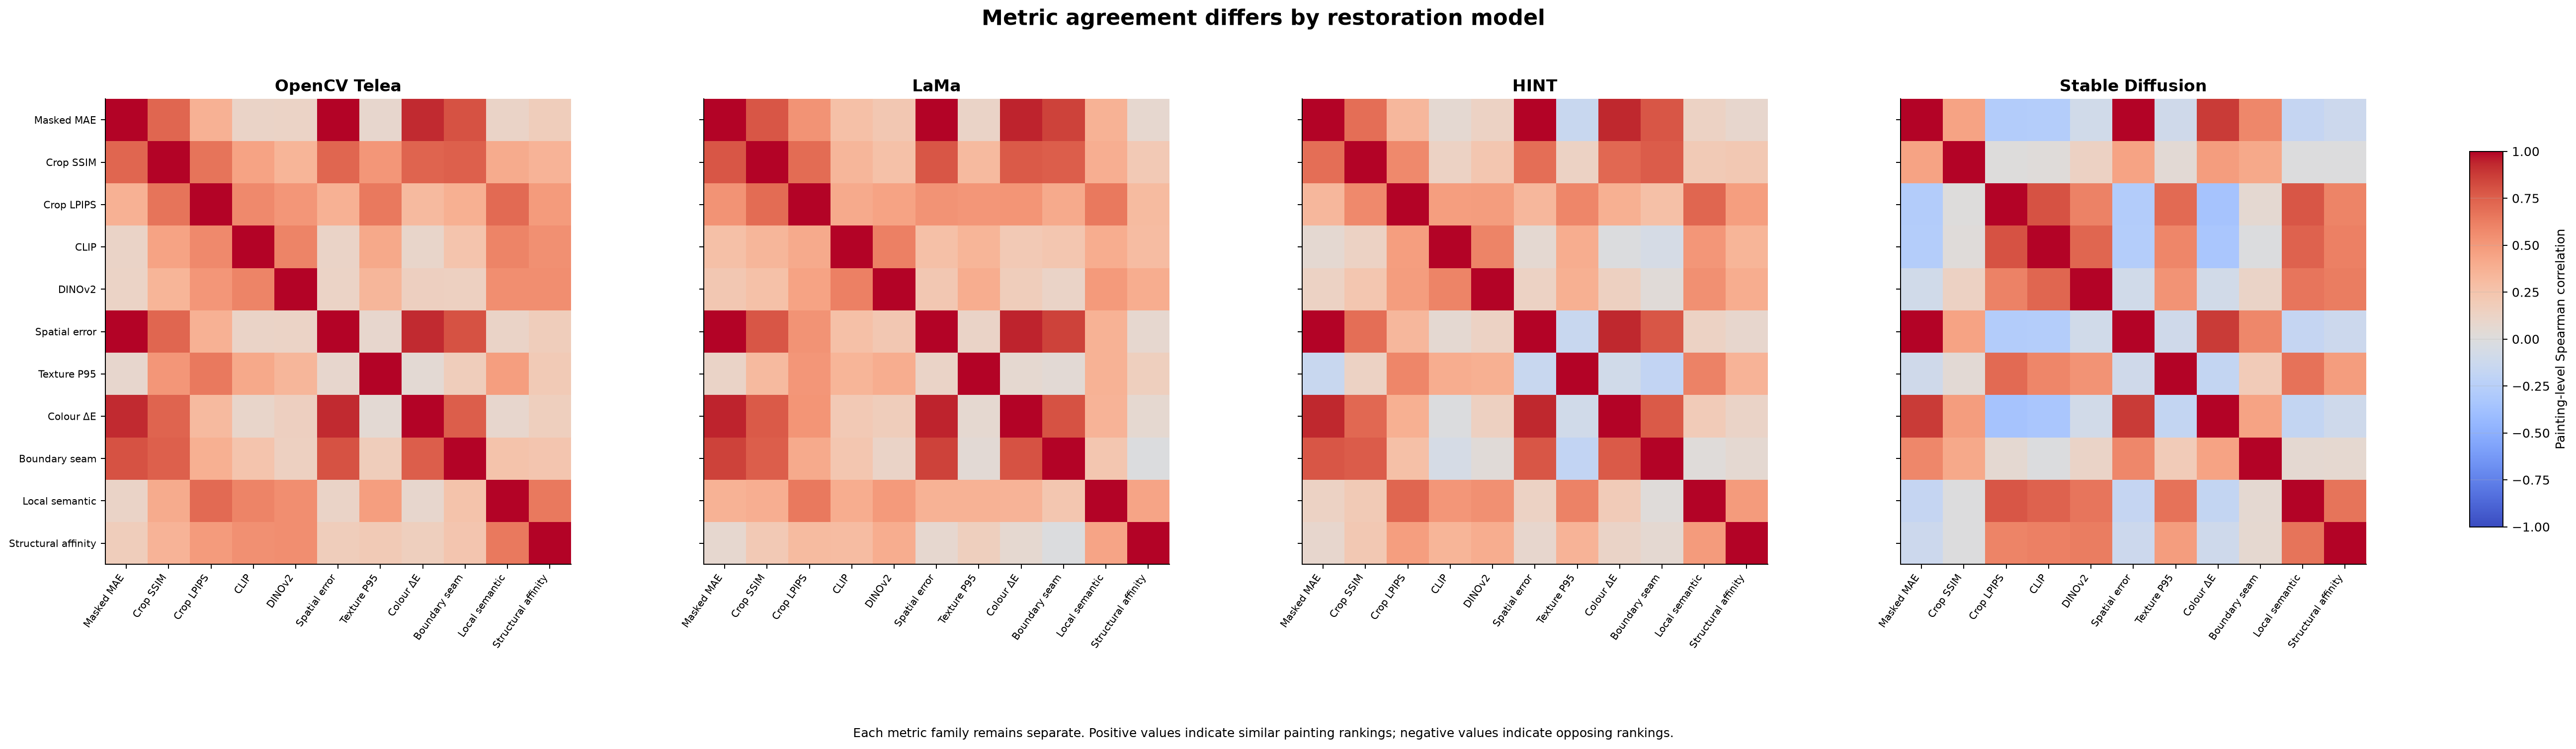

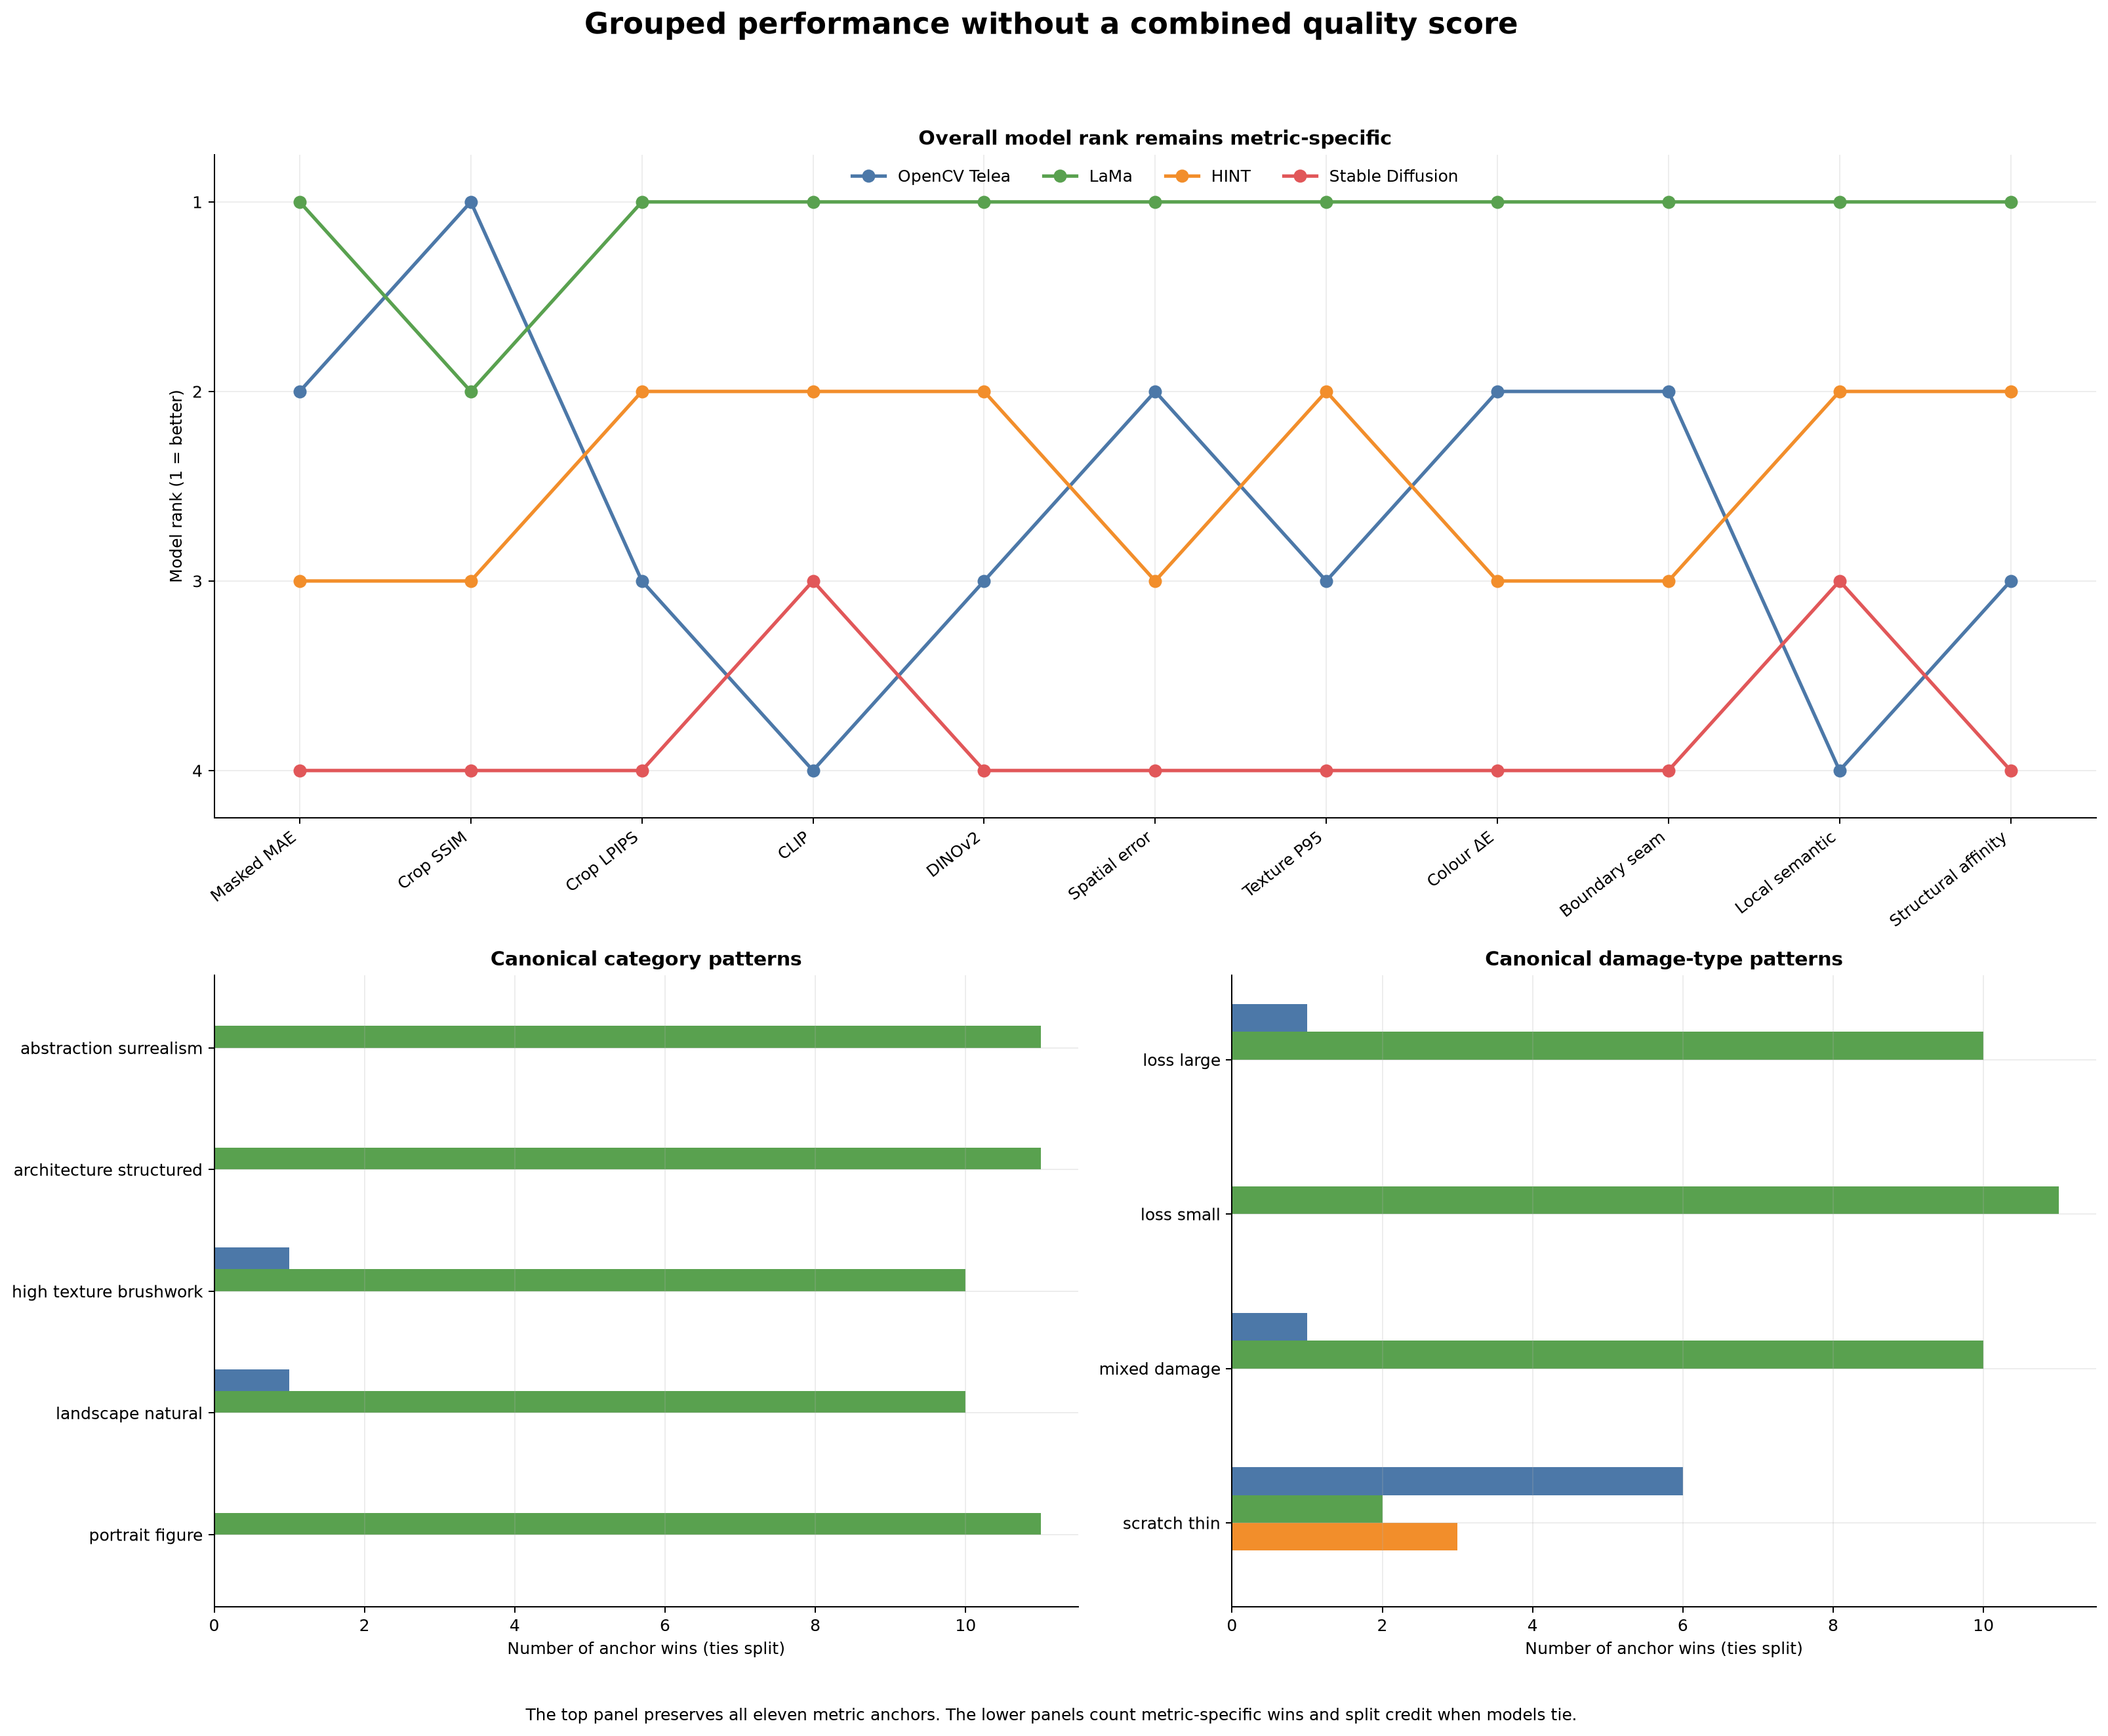

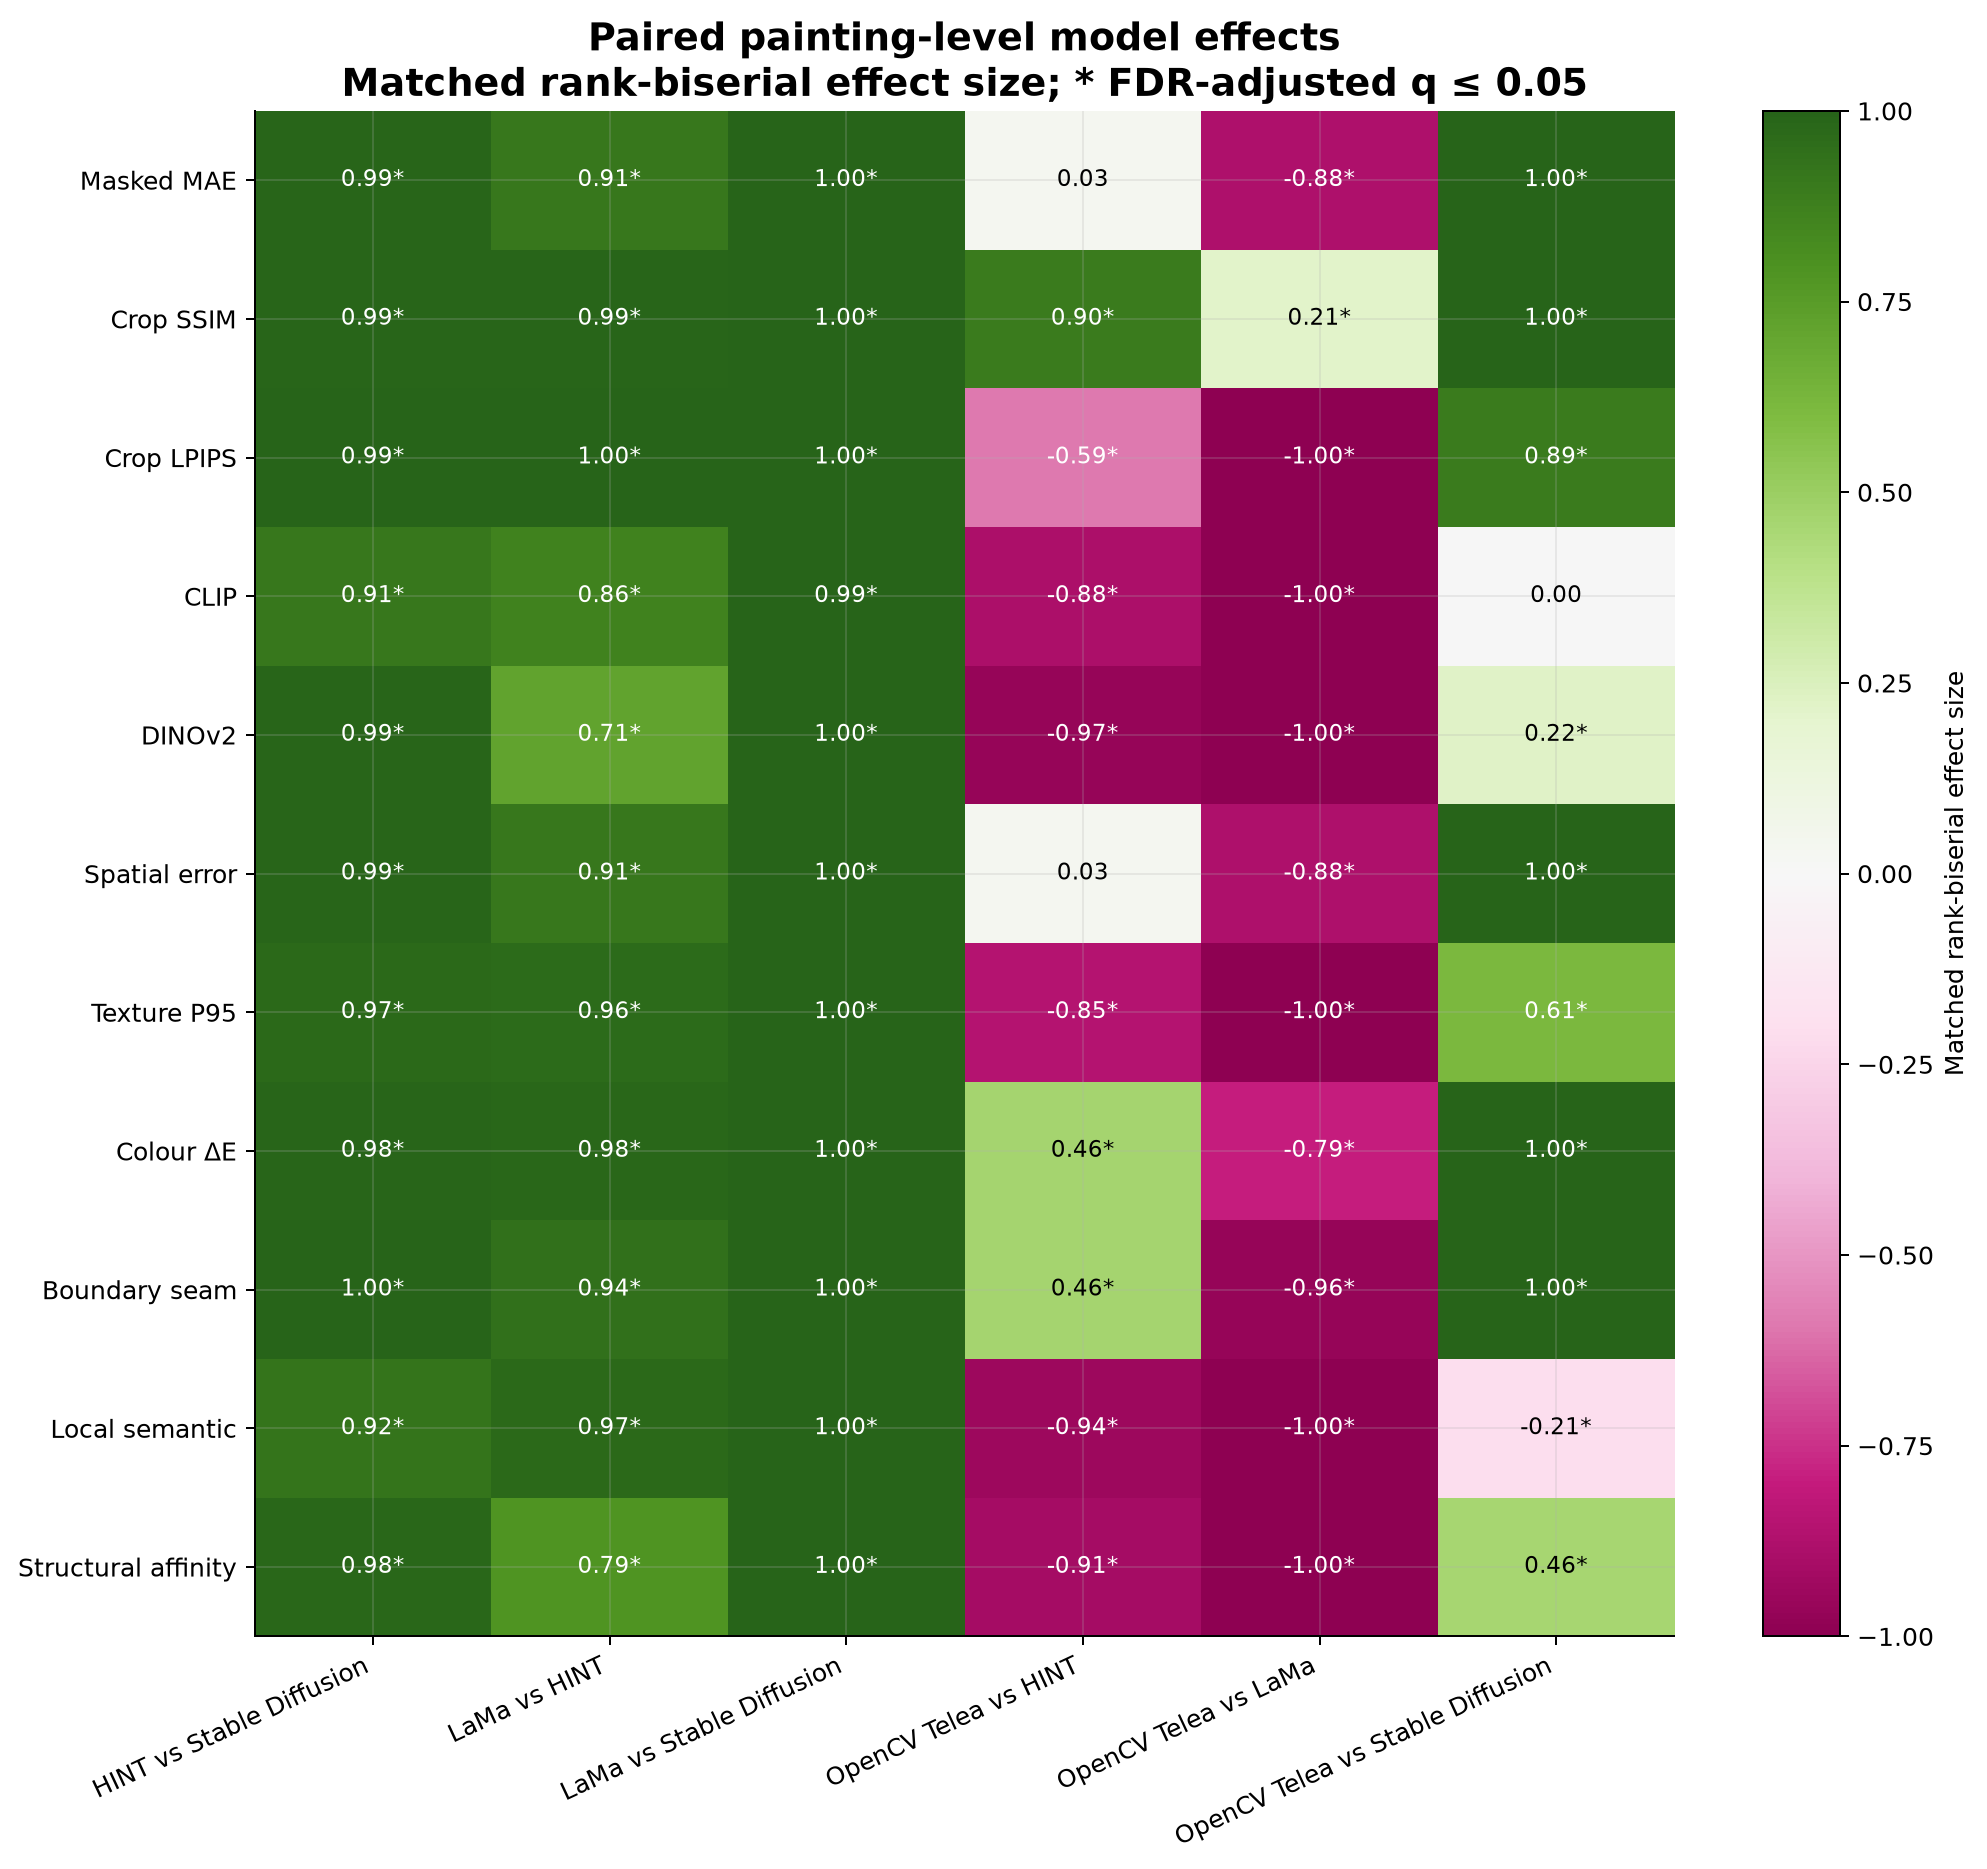

All three canonical figures rendered.


In [34]:
from PIL import Image as PILImage


MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
    "sdxl_inpainting": "SDXL",
}

MODEL_COLOURS = {
    "opencv_telea": "#4C78A8",
    "lama": "#59A14F",
    "hint_places2": "#F28E2B",
    "stable_diffusion_inpainting": (
        "#E15759"
    ),
    "sdxl_inpainting": "#B279A2",
}

ANCHOR_LABELS = {
    "classical_masked_mae": "Masked MAE",
    "structural_crop_ssim": "Crop SSIM",
    "perceptual_crop_lpips": "Crop LPIPS",
    "feature_clip_crop": "CLIP",
    "feature_dino_crop": "DINOv2",
    "spatial_masked_error": "Spatial error",
    "texture_crop_p95": "Texture P95",
    "colour_masked_delta_e": "Colour ΔE",
    "seam_boundary_gradient": "Boundary seam",
    "semantic_local_dino": "Local semantic",
    "structural_affinity_correlation": (
        "Structural affinity"
    ),
}

ANCHOR_ORDER = [
    str(specification["anchor_id"])
    for specification
    in SETTINGS["quality_anchors"]
]

CORE_MODEL_ORDER = list(
    map(
        str,
        POPULATION["core_model_order"],
    )
)


def save_figure_atomically(
    figure: mpl.figure.Figure,
    destination: Path,
) -> None:
    """Save a Notebook 26 figure through its owned work directory."""

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary = (
        WORK_ROOT
        / (
            f".{destination.stem}"
            f".building{destination.suffix}"
        )
    )

    figure.savefig(
        temporary,
        bbox_inches="tight",
        facecolor="white",
    )

    temporary.replace(destination)


metric_to_anchor = {
    str(specification["metric_name"]): str(
        specification["anchor_id"]
    )
    for specification
    in SETTINGS["quality_anchors"]
}

rank_correlation_rows = (
    METRIC_CORRELATIONS.loc[
        METRIC_CORRELATIONS[
            "correlation_kind"
        ].astype(str).eq(
            "rank_correlation"
        )
        & METRIC_CORRELATIONS[
            "correlation_method"
        ].astype(str).eq(
            "spearman"
        )
    ]
    .copy()
)

if (
    len(rank_correlation_rows) != 220
    or rank_correlation_rows[
        "model_id"
    ].nunique() != 4
):
    raise RuntimeError(
        "The correlation figure input must contain "
        "55 metric pairs for each core model."
    )

figure, axes = plt.subplots(
    1,
    4,
    figsize=(31, 8.4),
    sharex=True,
    sharey=True,
)

correlation_image = None

for axis, model_id in zip(
    axes,
    CORE_MODEL_ORDER,
):
    matrix = pd.DataFrame(
        np.nan,
        index=ANCHOR_ORDER,
        columns=ANCHOR_ORDER,
        dtype=float,
    )

    np.fill_diagonal(
        matrix.values,
        1.0,
    )

    model_rows = (
        rank_correlation_rows.loc[
            rank_correlation_rows[
                "model_id"
            ].astype(str).eq(model_id)
        ]
    )

    for _, row in model_rows.iterrows():
        left_anchor = metric_to_anchor.get(
            str(row["left_metric_name"])
        )

        right_anchor = metric_to_anchor.get(
            str(row["right_metric_name"])
        )

        if (
            left_anchor is None
            or right_anchor is None
        ):
            raise KeyError(
                "A correlation metric is not mapped "
                "to an approved quality anchor."
            )

        value = float(row["correlation"])

        matrix.loc[
            left_anchor,
            right_anchor,
        ] = value

        matrix.loc[
            right_anchor,
            left_anchor,
        ] = value

    if not np.isfinite(
        matrix.to_numpy(dtype=float)
    ).all():
        raise RuntimeError(
            "The rank-correlation matrix is incomplete "
            f"for {model_id}."
        )

    correlation_image = axis.imshow(
        matrix.to_numpy(dtype=float),
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
        aspect="equal",
    )

    axis.set_title(
        MODEL_LABELS[model_id],
        fontsize=13,
        weight="bold",
    )

    axis.set_xticks(
        range(len(ANCHOR_ORDER))
    )

    axis.set_yticks(
        range(len(ANCHOR_ORDER))
    )

    axis.set_xticklabels(
        [
            ANCHOR_LABELS[anchor_id]
            for anchor_id in ANCHOR_ORDER
        ],
        rotation=55,
        ha="right",
        fontsize=8,
    )

    axis.set_yticklabels(
        [
            ANCHOR_LABELS[anchor_id]
            for anchor_id in ANCHOR_ORDER
        ],
        fontsize=8,
    )

    axis.grid(False)

figure.suptitle(
    "Metric agreement differs by restoration model",
    fontsize=17,
    weight="bold",
)

figure.text(
    0.5,
    0.01,
    (
        "Each metric family remains separate. "
        "Positive values indicate similar painting rankings; "
        "negative values indicate opposing rankings."
    ),
    ha="center",
    fontsize=10,
)

# Reserve a dedicated right margin before adding the colour bar.
# This prevents it from covering the Stable Diffusion heatmap.
figure.subplots_adjust(
    left=0.07,
    right=0.91,
    bottom=0.24,
    top=0.86,
    wspace=0.12,
)

colorbar_axis = figure.add_axes(
    [0.935, 0.29, 0.012, 0.50]
)

figure.colorbar(
    correlation_image,
    cax=colorbar_axis,
    label="Painting-level Spearman correlation",
)

save_figure_atomically(
    figure,
    OUTPUT_PATHS["correlation_figure"],
)

plt.close(figure)

print("Correlation matrix figure written.")


def winner_credit_table(
    frame: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:
    """Count anchor wins while splitting credit for exact ties."""

    credit_records = []

    for (
        group_value,
        anchor_id,
    ), group in frame.groupby(
        [
            group_column,
            "anchor_id",
        ],
        dropna=False,
        sort=True,
    ):
        utilities = pd.to_numeric(
            group[
                "directional_utility_median"
            ],
            errors="coerce",
        )

        maximum = float(utilities.max())

        winner_mask = np.isclose(
            utilities,
            maximum,
            rtol=0,
            atol=1e-12,
        )

        winner_count = int(
            winner_mask.sum()
        )

        for model_id in group.loc[
            winner_mask,
            "model_id",
        ].astype(str):
            credit_records.append(
                {
                    group_column: str(
                        group_value
                    ),
                    "model_id": model_id,
                    "winner_credit": (
                        1.0 / winner_count
                    ),
                }
            )

    credits = pd.DataFrame(
        credit_records
    )

    return (
        credits.pivot_table(
            index=group_column,
            columns="model_id",
            values="winner_credit",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reindex(
            columns=CORE_MODEL_ORDER,
            fill_value=0.0,
        )
    )


category_winner_credits = winner_credit_table(
    CANONICAL_CATEGORY_DESCRIPTIVES,
    "category",
)

damage_winner_credits = winner_credit_table(
    CANONICAL_DAMAGE_DESCRIPTIVES,
    "canonical_damage_type",
)

if (
    not np.allclose(
        category_winner_credits.sum(axis=1),
        11.0,
    )
    or not np.allclose(
        damage_winner_credits.sum(axis=1),
        11.0,
    )
):
    raise RuntimeError(
        "Grouped winner-credit totals must equal "
        "the eleven separate quality anchors."
    )

figure = plt.figure(
    figsize=(18, 15)
)

grid = figure.add_gridspec(
    2,
    2,
    height_ratios=[1.05, 1.0],
)

rank_axis = figure.add_subplot(
    grid[0, :]
)

category_axis = figure.add_subplot(
    grid[1, 0]
)

damage_axis = figure.add_subplot(
    grid[1, 1]
)

rank_positions = np.arange(
    len(ANCHOR_ORDER)
)

for model_id in CORE_MODEL_ORDER:
    model_ranks = (
        BASELINE_ANCHOR_RANKS.loc[
            BASELINE_ANCHOR_RANKS[
                "model_id"
            ].astype(str).eq(model_id)
        ]
        .set_index("anchor_id")
        .reindex(ANCHOR_ORDER)
    )

    rank_axis.plot(
        rank_positions,
        model_ranks[
            "anchor_rank"
        ].to_numpy(dtype=float),
        marker="o",
        linewidth=2.1,
        markersize=7,
        color=MODEL_COLOURS[model_id],
        label=MODEL_LABELS[model_id],
    )

rank_axis.set_xticks(rank_positions)

rank_axis.set_xticklabels(
    [
        ANCHOR_LABELS[anchor_id]
        for anchor_id in ANCHOR_ORDER
    ],
    rotation=38,
    ha="right",
)

rank_axis.set_yticks(
    [1, 2, 3, 4]
)

rank_axis.set_ylim(
    4.25,
    0.75,
)

rank_axis.set_ylabel(
    "Model rank (1 = better)"
)

rank_axis.set_title(
    "Overall model rank remains metric-specific",
    weight="bold",
)

rank_axis.legend(
    ncol=4,
    frameon=False,
    loc="upper center",
)


def plot_winner_credits(
    axis: mpl.axes.Axes,
    table: pd.DataFrame,
    title: str,
) -> None:
    positions = np.arange(
        len(table.index)
    )

    width = 0.18

    for model_index, model_id in enumerate(
        CORE_MODEL_ORDER
    ):
        axis.barh(
            positions
            + (
                model_index
                - (len(CORE_MODEL_ORDER) - 1) / 2
            )
            * width,
            table[
                model_id
            ].to_numpy(dtype=float),
            height=width,
            color=MODEL_COLOURS[model_id],
            label=MODEL_LABELS[model_id],
        )

    axis.set_yticks(positions)

    axis.set_yticklabels(
        [
            str(value).replace("_", " ")
            for value in table.index
        ]
    )

    axis.invert_yaxis()

    axis.set_xlabel(
        "Number of anchor wins (ties split)"
    )

    axis.set_xlim(
        0,
        max(
            11.5,
            float(
                table.to_numpy(
                    dtype=float
                ).max()
            )
            + 0.5,
        ),
    )

    axis.set_title(
        title,
        weight="bold",
    )


plot_winner_credits(
    category_axis,
    category_winner_credits,
    "Canonical category patterns",
)

plot_winner_credits(
    damage_axis,
    damage_winner_credits,
    "Canonical damage-type patterns",
)

figure.suptitle(
    "Grouped performance without a combined quality score",
    fontsize=18,
    weight="bold",
)

figure.text(
    0.5,
    0.015,
    (
        "The top panel preserves all eleven metric anchors. "
        "The lower panels count metric-specific wins and "
        "split credit when models tie."
    ),
    ha="center",
    fontsize=10,
)

figure.tight_layout(
    rect=[0, 0.04, 1, 0.95]
)

save_figure_atomically(
    figure,
    OUTPUT_PATHS[
        "grouped_performance_figure"
    ],
)

plt.close(figure)

print("Grouped-performance figure written.")


paired_effects = (
    NEW_INFERENTIAL_RESULTS.loc[
        NEW_INFERENTIAL_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "paired_model_contrast"
        )
    ]
    .copy()
)

if (
    len(paired_effects) != 66
    or not np.isfinite(
        paired_effects[
            "effect_size"
        ].to_numpy(dtype=float)
    ).all()
):
    raise RuntimeError(
        "The effect-size figure requires "
        "66 finite paired-model effects."
    )

paired_effects[
    "model_pair"
] = (
    paired_effects["model_id"].map(
        MODEL_LABELS
    )
    + " vs "
    + paired_effects[
        "comparison_model_id"
    ].map(MODEL_LABELS)
)

pair_order = sorted(
    paired_effects[
        "model_pair"
    ].unique().tolist()
)

effect_matrix = (
    paired_effects.pivot(
        index="anchor_id",
        columns="model_pair",
        values="effect_size",
    )
    .reindex(
        index=ANCHOR_ORDER,
        columns=pair_order,
    )
)

q_value_matrix = (
    paired_effects.pivot(
        index="anchor_id",
        columns="model_pair",
        values="q_value",
    )
    .reindex(
        index=ANCHOR_ORDER,
        columns=pair_order,
    )
)

if not np.isfinite(
    effect_matrix.to_numpy(dtype=float)
).all():
    raise RuntimeError(
        "The paired-effect matrix is incomplete."
    )

figure, axis = plt.subplots(
    figsize=(11.5, 10.5)
)

effect_image = axis.imshow(
    effect_matrix.to_numpy(dtype=float),
    vmin=-1,
    vmax=1,
    cmap="PiYG",
    aspect="auto",
)

axis.set_xticks(
    range(len(pair_order))
)

axis.set_xticklabels(
    pair_order,
    rotation=25,
    ha="right",
)

axis.set_yticks(
    range(len(ANCHOR_ORDER))
)

axis.set_yticklabels(
    [
        ANCHOR_LABELS[anchor_id]
        for anchor_id in ANCHOR_ORDER
    ]
)

for row_index in range(
    len(ANCHOR_ORDER)
):
    for column_index in range(
        len(pair_order)
    ):
        effect_value = float(
            effect_matrix.iloc[
                row_index,
                column_index,
            ]
        )

        q_value = float(
            q_value_matrix.iloc[
                row_index,
                column_index,
            ]
        )

        significance = (
            "*"
            if q_value <= 0.05
            else ""
        )

        axis.text(
            column_index,
            row_index,
            (
                f"{effect_value:.2f}"
                f"{significance}"
            ),
            ha="center",
            va="center",
            fontsize=9,
            color=(
                "white"
                if abs(effect_value) >= 0.55
                else "black"
            ),
        )

axis.set_title(
    (
        "Paired painting-level model effects\n"
        "Matched rank-biserial effect size; "
        "* FDR-adjusted q ≤ 0.05"
    ),
    fontsize=15,
    weight="bold",
)

figure.colorbar(
    effect_image,
    ax=axis,
    label="Matched rank-biserial effect size",
)

figure.tight_layout()

save_figure_atomically(
    figure,
    OUTPUT_PATHS[
        "effect_sizes_figure"
    ],
)

plt.close(figure)

print("Effect-size figure written.")

for figure_key in (
    "correlation_figure",
    "grouped_performance_figure",
    "effect_sizes_figure",
):
    display(
        PILImage.open(
            OUTPUT_PATHS[figure_key]
        ).copy()
    )

print("All three canonical figures rendered.")

In [35]:
# Make the Batch 9 validation stage safe to rerun.
retained_validation_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != BATCH_9_VALIDATION_STAGE
]

removed_batch_9_checks = (
    len(VALIDATION.checks)
    - len(retained_validation_checks)
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)

print(
    "Previous Batch 9 validation checks removed: "
    f"{removed_batch_9_checks}"
)

in_memory_schema_status = {
    "statistical_results": (
        validate_statistical_results(
            STATISTICAL_RESULTS,
            config=ANALYSIS_CONFIG,
        )
    ),
    "metric_correlations": (
        validate_metric_correlations(
            METRIC_CORRELATIONS,
            config=ANALYSIS_CONFIG,
        )
    ),
    "ranking_stability": (
        validate_ranking_stability(
            RANKING_STABILITY,
            config=ANALYSIS_CONFIG,
        )
    ),
}

if not all(
    status["passed"]
    for status
    in in_memory_schema_status.values()
):
    raise RuntimeError(
        "Canonical tables failed in-memory validation: "
        f"{in_memory_schema_status}"
    )

atomic_write_csv(
    STATISTICAL_RESULTS,
    OUTPUT_PATHS["statistical_results"],
)

atomic_write_csv(
    METRIC_CORRELATIONS,
    OUTPUT_PATHS["metric_correlations"],
)

atomic_write_csv(
    RANKING_STABILITY,
    OUTPUT_PATHS["ranking_stability"],
)

RELOADED_STATISTICAL_RESULTS = pd.read_csv(
    OUTPUT_PATHS["statistical_results"],
    low_memory=False,
)

RELOADED_METRIC_CORRELATIONS = pd.read_csv(
    OUTPUT_PATHS["metric_correlations"],
    low_memory=False,
)

RELOADED_RANKING_STABILITY = pd.read_csv(
    OUTPUT_PATHS["ranking_stability"],
    low_memory=False,
)

reloaded_schema_status = {
    "statistical_results": (
        validate_statistical_results(
            RELOADED_STATISTICAL_RESULTS,
            config=ANALYSIS_CONFIG,
        )
    ),
    "metric_correlations": (
        validate_metric_correlations(
            RELOADED_METRIC_CORRELATIONS,
            config=ANALYSIS_CONFIG,
        )
    ),
    "ranking_stability": (
        validate_ranking_stability(
            RELOADED_RANKING_STABILITY,
            config=ANALYSIS_CONFIG,
        )
    ),
}

reloaded_id_sequences_match = {
    "statistical_results": (
        RELOADED_STATISTICAL_RESULTS[
            "result_id"
        ].astype(str).tolist()
        == STATISTICAL_RESULTS[
            "result_id"
        ].astype(str).tolist()
    ),
    "metric_correlations": (
        RELOADED_METRIC_CORRELATIONS[
            "correlation_id"
        ].astype(str).tolist()
        == METRIC_CORRELATIONS[
            "correlation_id"
        ].astype(str).tolist()
    ),
    "ranking_stability": (
        RELOADED_RANKING_STABILITY[
            "ranking_id"
        ].astype(str).tolist()
        == RANKING_STABILITY[
            "ranking_id"
        ].astype(str).tolist()
    ),
}

figure_metadata = {}

for figure_key in (
    "correlation_figure",
    "grouped_performance_figure",
    "effect_sizes_figure",
):
    figure_path = OUTPUT_PATHS[
        figure_key
    ]

    with PILImage.open(
        figure_path
    ) as image:
        image.load()

        figure_metadata[
            figure_key
        ] = {
            "format": image.format,
            "mode": image.mode,
            "width": int(image.width),
            "height": int(image.height),
            "size_bytes": int(
                figure_path.stat().st_size
            ),
            "sha256": sha256_file(
                figure_path
            ),
        }

work_files_before_cleanup = sorted(
    path
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

for work_file in work_files_before_cleanup:
    resolved_file = work_file.resolve()

    if not resolved_file.is_relative_to(
        WORK_ROOT.resolve()
    ):
        raise RuntimeError(
            "Refusing to remove a file outside "
            "Notebook 26's work directory."
        )

    work_file.unlink()

for work_directory in sorted(
    (
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_dir()
    ),
    key=lambda path: len(path.parts),
    reverse=True,
):
    if work_directory != WORK_ROOT:
        try:
            work_directory.rmdir()
        except OSError:
            pass

work_files_after_cleanup = sorted(
    path
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

observed_statistical_result_kind_counts = {
    str(key): int(value)
    for key, value
    in RELOADED_STATISTICAL_RESULTS[
        "result_kind"
    ].value_counts().sort_index().items()
}

VALIDATION.add(
    validation_stage=(
        BATCH_9_VALIDATION_STAGE
    ),
    check_id=(
        "canonical_table_schemas"
    ),
    check_description=(
        "All three canonical tables pass their exact "
        "schemas both before and after persistence."
    ),
    severity="blocking",
    expected={
        "in_memory": True,
        "reloaded": True,
    },
    observed={
        "in_memory": (
            in_memory_schema_status
        ),
        "reloaded": (
            reloaded_schema_status
        ),
    },
    passed=(
        all(
            status["passed"]
            for status
            in in_memory_schema_status.values()
        )
        and all(
            status["passed"]
            for status
            in reloaded_schema_status.values()
        )
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_9_VALIDATION_STAGE
    ),
    check_id=(
        "canonical_table_populations"
    ),
    check_description=(
        "The persisted canonical tables contain the "
        "approved result, correlation, and ranking populations."
    ),
    severity="blocking",
    expected={
        "statistical_results": 13272,
        "metric_correlations": 694,
        "ranking_stability": 1344,
        "statistical_result_kinds": (
            EXPECTED_STATISTICAL_RESULT_KIND_COUNTS
        ),
    },
    observed={
        "statistical_results": len(
            RELOADED_STATISTICAL_RESULTS
        ),
        "metric_correlations": len(
            RELOADED_METRIC_CORRELATIONS
        ),
        "ranking_stability": len(
            RELOADED_RANKING_STABILITY
        ),
        "statistical_result_kinds": (
            observed_statistical_result_kind_counts
        ),
    },
    passed=(
        len(
            RELOADED_STATISTICAL_RESULTS
        ) == 13272
        and len(
            RELOADED_METRIC_CORRELATIONS
        ) == 694
        and len(
            RELOADED_RANKING_STABILITY
        ) == 1344
        and observed_statistical_result_kind_counts
        == EXPECTED_STATISTICAL_RESULT_KIND_COUNTS
    ),
)

VALIDATION.add(
    validation_stage=(
        BATCH_9_VALIDATION_STAGE
    ),
    check_id=(
        "canonical_reload_identity"
    ),
    check_description=(
        "Persistence preserves every canonical row identifier "
        "in deterministic order."
    ),
    severity="blocking",
    expected={
        key: True
        for key
        in reloaded_id_sequences_match
    },
    observed=(
        reloaded_id_sequences_match
    ),
    passed=all(
        reloaded_id_sequences_match.values()
    ),
)

figures_are_readable = all(
    metadata["format"] == "PNG"
    and metadata["width"] >= 1200
    and metadata["height"] >= 700
    and metadata["size_bytes"] > 0
    for metadata
    in figure_metadata.values()
)

VALIDATION.add(
    validation_stage=(
        BATCH_9_VALIDATION_STAGE
    ),
    check_id=(
        "canonical_figures"
    ),
    check_description=(
        "All three declared analytical figures are readable, "
        "non-empty PNG files with report-ready dimensions."
    ),
    severity="blocking",
    expected={
        "figures": 3,
        "format": "PNG",
        "minimum_width": 1200,
        "minimum_height": 700,
    },
    observed=figure_metadata,
    passed=(
        len(figure_metadata) == 3
        and figures_are_readable
    ),
)

new_inferential_kinds = {
    "paired_model_contrast",
    "repeated_model_test",
    "canonical_category_test",
    "canonical_damage_test",
    "quality_compute_association",
}

new_inferential_rows = (
    RELOADED_STATISTICAL_RESULTS.loc[
        RELOADED_STATISTICAL_RESULTS[
            "result_kind"
        ].astype(str).isin(
            new_inferential_kinds
        )
    ]
)

sdxl_in_new_inference = bool(
    new_inferential_rows[
        [
            "model_id",
            "comparison_model_id",
        ]
    ]
    .astype(str)
    .apply(
        lambda column: column.str.contains(
            "sdxl",
            case=False,
            regex=False,
        )
    )
    .any()
    .any()
)

dataset_applicability_rows = (
    RELOADED_STATISTICAL_RESULTS.loc[
        RELOADED_STATISTICAL_RESULTS[
            "analysis_family_id"
        ].astype(str).eq(
            "dataset_source_comparison"
        )
    ]
)

VALIDATION.add(
    validation_stage=(
        BATCH_9_VALIDATION_STAGE
    ),
    check_id=(
        "scientific_scope_protections"
    ),
    check_description=(
        "SDXL remains outside new inference, the single-dataset "
        "limit remains explicit, and uncertainty associations "
        "remain separate from combined scores."
    ),
    severity="blocking",
    expected={
        "sdxl_in_new_inference": False,
        "dataset_status": (
            "not_applicable_single_dataset"
        ),
        "uncertainty_association_rows": 140,
        "combined_scores": False,
    },
    observed={
        "sdxl_in_new_inference": (
            sdxl_in_new_inference
        ),
        "dataset_statuses": sorted(
            dataset_applicability_rows[
                "applicability_status"
            ].astype(str).unique().tolist()
        ),
        "uncertainty_association_rows": int(
            RELOADED_STATISTICAL_RESULTS[
                "result_kind"
            ].astype(str).eq(
                "uncertainty_performance_association"
            ).sum()
        ),
        "schema_no_combined_score": bool(
            reloaded_schema_status[
                "statistical_results"
            ]["no_combined_score"]
        ),
    },
    passed=(
        not sdxl_in_new_inference
        and len(
            dataset_applicability_rows
        ) == 1
        and dataset_applicability_rows[
            "applicability_status"
        ].astype(str).eq(
            "not_applicable_single_dataset"
        ).all()
        and int(
            RELOADED_STATISTICAL_RESULTS[
                "result_kind"
            ].astype(str).eq(
                "uncertainty_performance_association"
            ).sum()
        ) == 140
        and bool(
            reloaded_schema_status[
                "statistical_results"
            ]["no_combined_score"]
        )
    ),
)

canonical_batch_9_paths = [
    OUTPUT_PATHS["statistical_results"],
    OUTPUT_PATHS["metric_correlations"],
    OUTPUT_PATHS["ranking_stability"],
    OUTPUT_PATHS["correlation_figure"],
    OUTPUT_PATHS[
        "grouped_performance_figure"
    ],
    OUTPUT_PATHS["effect_sizes_figure"],
]

VALIDATION.add(
    validation_stage=(
        BATCH_9_VALIDATION_STAGE
    ),
    check_id=(
        "batch_9_artifacts_and_work_cleanup"
    ),
    check_description=(
        "All six Batch 9 canonical artifacts exist and the "
        "Notebook 26 work directory contains no temporary files."
    ),
    severity="blocking",
    expected={
        "canonical_artifacts": 6,
        "missing_artifacts": [],
        "work_files_after_cleanup": 0,
    },
    observed={
        "canonical_artifacts": sum(
            path.is_file()
            for path
            in canonical_batch_9_paths
        ),
        "missing_artifacts": [
            str(
                path.relative_to(
                    PROJECT_ROOT
                )
            ).replace("\\", "/")
            for path
            in canonical_batch_9_paths
            if not path.is_file()
        ],
        "work_files_before_cleanup": [
            str(
                path.relative_to(
                    PROJECT_ROOT
                )
            ).replace("\\", "/")
            for path
            in work_files_before_cleanup
        ],
        "work_files_after_cleanup": len(
            work_files_after_cleanup
        ),
    },
    passed=(
        all(
            path.is_file()
            for path
            in canonical_batch_9_paths
        )
        and not work_files_after_cleanup
    ),
)

BATCH_9_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            BATCH_9_VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(BATCH_9_CHECKS)

display(
    RELOADED_STATISTICAL_RESULTS[
        [
            "result_kind",
            "experiment_id",
            "scope_type",
            "evidence_family",
            "metric_name",
            "model_id",
            "comparison_model_id",
            "estimate",
            "p_value",
            "q_value",
            "applicability_status",
        ]
    ].head(30)
)

VALIDATION.raise_for_blocking()

print("Batch 9 passed.")
print(
    "Batch 9 checks: "
    f"{len(BATCH_9_CHECKS)}"
)
print(
    "Blocking failures: "
    f"{int((~BATCH_9_CHECKS['passed']).sum())}"
)
print(
    "Statistical-result rows: "
    f"{len(RELOADED_STATISTICAL_RESULTS):,}"
)
print(
    "Metric-correlation rows: "
    f"{len(RELOADED_METRIC_CORRELATIONS):,}"
)
print(
    "Ranking-stability rows: "
    f"{len(RELOADED_RANKING_STABILITY):,}"
)
print("Canonical figures: 3")
print(
    "Temporary work files remaining: "
    f"{len(work_files_after_cleanup)}"
)
print(
    "Next batch: mock-aligned self-contained HTML report, "
    "final manifests, and completion traceability."
)

Previous Batch 9 validation checks removed: 0


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_persistence_figures,canonical_table_schemas,All three canonical tables pass their exact schemas both before and after persistence.,blocking,"{""in_memory"": true, ""reloaded"": true}","{""in_memory"": {""metric_correlations"": {""exact_columns"": true, ""kinds_valid"": true, ""no_combined_score"": true, ""passed"": true, ""probability_valid"": true, ""sc...",True,
1,batch_9_persistence_figures,canonical_table_populations,"The persisted canonical tables contain the approved result, correlation, and ranking populations.",blocking,"{""metric_correlations"": 694, ""ranking_stability"": 1344, ""statistical_result_kinds"": {""applicability_audit"": 4, ""canonical_category_summary"": 220, ""canonical...","{""metric_correlations"": 694, ""ranking_stability"": 1344, ""statistical_result_kinds"": {""applicability_audit"": 4, ""canonical_category_summary"": 220, ""canonical...",True,
2,batch_9_persistence_figures,canonical_reload_identity,Persistence preserves every canonical row identifier in deterministic order.,blocking,"{""metric_correlations"": true, ""ranking_stability"": true, ""statistical_results"": true}","{""metric_correlations"": true, ""ranking_stability"": true, ""statistical_results"": true}",True,
3,batch_9_persistence_figures,canonical_figures,"All three declared analytical figures are readable, non-empty PNG files with report-ready dimensions.",blocking,"{""figures"": 3, ""format"": ""PNG"", ""minimum_height"": 700, ""minimum_width"": 1200}","{""correlation_figure"": {""format"": ""PNG"", ""height"": 1508, ""mode"": ""RGBA"", ""sha256"": ""fcd5c98cd230e5bf4b31c3feb59719f34eb33bb850cfbd8c8d2b28649132ac0b"", ""size...",True,
4,batch_9_persistence_figures,scientific_scope_protections,"SDXL remains outside new inference, the single-dataset limit remains explicit, and uncertainty associations remain separate from combined scores.",blocking,"{""combined_scores"": false, ""dataset_status"": ""not_applicable_single_dataset"", ""sdxl_in_new_inference"": false, ""uncertainty_association_rows"": 140}","{""dataset_statuses"": [""not_applicable_single_dataset""], ""schema_no_combined_score"": true, ""sdxl_in_new_inference"": false, ""uncertainty_association_rows"": 140}",True,
5,batch_9_persistence_figures,batch_9_artifacts_and_work_cleanup,All six Batch 9 canonical artifacts exist and the Notebook 26 work directory contains no temporary files.,blocking,"{""canonical_artifacts"": 6, ""missing_artifacts"": [], ""work_files_after_cleanup"": 0}","{""canonical_artifacts"": 6, ""missing_artifacts"": [], ""work_files_after_cleanup"": 0, ""work_files_before_cleanup"": []}",True,


,result_kind,experiment_id,scope_type,evidence_family,metric_name,model_id,comparison_model_id,estimate,p_value,q_value,applicability_status
0,applicability_audit,controlled_300,evidence_block,dataset_source_comparison,dataset_source_comparison,NaN,NaN,1.000000,NaN,NaN,not_applicable_single_dataset
1,applicability_audit,mask_robustness,evidence_block,mask_robustness_uncertainty,mask_robustness_uncertainty,NaN,NaN,0.000000,NaN,NaN,not_applicable
2,applicability_audit,synthetic_degradation,evidence_block,synthetic_degradation_uncertainty,synthetic_degradation_uncertainty,NaN,NaN,0.000000,NaN,NaN,not_applicable
3,applicability_audit,twenty_four_candidate_bounded_subset,evidence_block,bounded_sdxl,bounded_sdxl,NaN,NaN,24.000000,NaN,NaN,descriptive_only
4,canonical_category_summary,canonical_missing_region,category,classical_pixel,mae,hint_places2,NaN,17.080361,NaN,NaN,supported
5,canonical_category_summary,canonical_missing_region,category,classical_pixel,mae,lama,NaN,12.948090,NaN,NaN,supported
6,canonical_category_summary,canonical_missing_region,category,classical_pixel,mae,opencv_telea,NaN,17.306649,NaN,NaN,supported
7,canonical_category_summary,canonical_missing_region,category,classical_pixel,mae,stable_diffusion_inpainting,NaN,30.452184,NaN,NaN,supported
8,canonical_category_summary,canonical_missing_region,category,classical_pixel,mae,hint_places2,NaN,14.262113,NaN,NaN,supported
9,canonical_category_summary,canonical_missing_region,category,classical_pixel,mae,lama,NaN,10.771789,NaN,NaN,supported


Batch 9 passed.
Batch 9 checks: 6
Blocking failures: 0
Statistical-result rows: 13,272
Metric-correlation rows: 694
Ranking-stability rows: 1,344
Canonical figures: 3
Temporary work files remaining: 0
Next batch: mock-aligned self-contained HTML report, final manifests, and completion traceability.


## Batch 10 — Mock-Aligned Self-Contained Statistical Report

Build the final report as an evidence-populated and additively upgraded version of the approved mock.

The approved structure remains binding:

1. executive findings;
2. evaluated population;
3. overall model differences;
4. category and canonical-damage patterns;
5. damage-size sensitivity;
6. mask morphology and seed robustness;
7. synthetic degradation;
8. metric-correlation structure;
9. metric and region disagreement;
10. uncertainty and performance;
11. ranking stability and sensitivity;
12. quality and compute;
13. representative restorations;
14. supported conclusions and limitations;
15. thesis contribution and provenance.

The report embeds all required figures and restoration panels inside the HTML. It does not depend on repository-relative image links when downloaded separately.

In [44]:
import base64
import io
import re
from html import escape

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.multi_model_comparison import (
    image_grid_to_data_uri,
    image_path_to_data_uri,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


REPORT_SETTINGS = SETTINGS["report"]

EXPECTED_REPORT_SECTION_ORDER = list(
    map(
        str,
        REPORT_SETTINGS[
            "required_section_ids"
        ],
    )
)

REPORT_SECTION_TITLES = {
    "executive_findings": "Executive findings",
    "what_was_evaluated": "What was evaluated?",
    "overall_model_differences": (
        "Overall model differences"
    ),
    "category_and_canonical_damage": (
        "Category and canonical-damage patterns"
    ),
    "damage_size_sensitivity": (
        "Damage-size sensitivity"
    ),
    "mask_morphology_and_seed_robustness": (
        "Mask morphology and seed robustness"
    ),
    "synthetic_degradation": (
        "Synthetic degradation"
    ),
    "metric_correlation_structure": (
        "Metric-correlation structure"
    ),
    "metric_and_region_disagreement": (
        "Metric and region disagreement"
    ),
    "uncertainty_and_performance": (
        "Uncertainty and performance"
    ),
    "ranking_stability_and_sensitivity": (
        "Ranking stability and sensitivity"
    ),
    "quality_and_compute": (
        "Quality and compute"
    ),
    "representative_restorations": (
        "Representative restorations"
    ),
    "supported_conclusions_and_limits": (
        "Supported conclusions and limitations"
    ),
    "thesis_contribution_and_provenance": (
        "Thesis contribution and provenance"
    ),
}

MOCK_APPROVED_ROLES = {
    "executive_findings": (
        "Headline indicators, direct findings, central "
        "scope warning, and the main grouped-performance visual."
    ),
    "what_was_evaluated": (
        "Population arithmetic, evidence families, model "
        "coverage, independent-unit policy, and selection rules."
    ),
    "overall_model_differences": (
        "Core-model ranks, anchor winners, paired effects, "
        "confidence-aware conclusions, and bounded SDXL scope."
    ),
    "category_and_canonical_damage": (
        "Category and canonical-damage tables, plots, "
        "assertions, and nearby inference limitations."
    ),
    "damage_size_sensitivity": (
        "Damage-level trajectories, model-rank changes, "
        "uncertainty evidence, and focused 35-painting experiment limits."
    ),
    "mask_morphology_and_seed_robustness": (
        "Mask-placement and morphology robustness, seed "
        "variation, ranking behaviour, and scope limitations."
    ),
    "synthetic_degradation": (
        "Dirt, transparency, water-stain, combined-degradation, "
        "severity, and bounded SDXL findings."
    ),
    "metric_correlation_structure": (
        "Model-specific correlation structure and explanation "
        "of agreement without claiming interchangeability."
    ),
    "metric_and_region_disagreement": (
        "Predeclared metric disagreements, rank reversals, "
        "region sensitivity, and direct evaluation implications."
    ),
    "uncertainty_and_performance": (
        "Prompt-separated variability associations, supported "
        "interpretation, and the calibrated-confidence warning."
    ),
    "ranking_stability_and_sensitivity": (
        "Baseline rank, painting/family/region omissions, "
        "bootstrap stability, and zero-control tie handling."
    ),
    "quality_and_compute": (
        "Runtime summaries and quality-runtime associations "
        "kept outside restoration-quality ranking."
    ),
    "representative_restorations": (
        "Rule-selected success, failure, disagreement, "
        "uncertainty, robustness, degradation, and SDXL panels."
    ),
    "supported_conclusions_and_limits": (
        "RQ1–RQ3 answers, direct model conclusions, unsupported "
        "claims, and practical evaluation limits."
    ),
    "thesis_contribution_and_provenance": (
        "Canonical artifacts, notebook dependencies, validation "
        "scope, mock traceability, and thesis contribution."
    ),
}

MOCK_TO_FINAL_TRACEABILITY = pd.DataFrame(
    [
        {
            "mock_element_id": (
                f"mock_{index:02d}_{section_id}"
            ),
            "mock_section": (
                REPORT_SECTION_TITLES[
                    section_id
                ]
            ),
            "approved_role": (
                MOCK_APPROVED_ROLES[
                    section_id
                ]
            ),
            "final_section": section_id,
            "canonical_evidence_source": (
                "Notebooks 08–26 validated canonical evidence"
            ),
            "implementation_status": (
                "upgraded_additively"
            ),
            "deviation_reason": "",
        }
        for index, section_id
        in enumerate(
            EXPECTED_REPORT_SECTION_ORDER,
            start=1,
        )
    ]
)

if (
    list(
        MOCK_TO_FINAL_TRACEABILITY[
            "final_section"
        ]
    )
    != EXPECTED_REPORT_SECTION_ORDER
    or not MOCK_TO_FINAL_TRACEABILITY[
        "implementation_status"
    ].isin(
        {
            "preserved",
            "upgraded_additively",
            "approved_deviation",
        }
    ).all()
    or MOCK_TO_FINAL_TRACEABILITY[
        "deviation_reason"
    ].astype(str).str.strip().ne("").any()
):
    raise RuntimeError(
        "Mock-to-final traceability does not preserve "
        "the approved report structure."
    )


def model_display(
    model_id: object,
) -> str:
    return MODEL_LABELS.get(
        str(model_id),
        str(model_id).replace(
            "_",
            " ",
        ).title(),
    )


BASELINE_RANK_REPORT = (
    BASELINE_MODEL_RANKS.assign(
        Model=lambda frame: (
            frame["model_id"].map(
                model_display
            )
        )
    )
    .rename(
        columns={
            "family_balanced_rank": (
                "Family-balanced rank"
            ),
            "overall_rank": "Overall rank",
        }
    )[
        [
            "Model",
            "Family-balanced rank",
            "Overall rank",
        ]
    ]
    .sort_values(
        "Overall rank",
        kind="stable",
    )
    .round(3)
)

ANCHOR_WIN_REPORT = (
    BASELINE_ANCHOR_RANKS.loc[
        pd.to_numeric(
            BASELINE_ANCHOR_RANKS[
                "anchor_rank"
            ],
            errors="coerce",
        ).eq(1.0)
    ]
    .groupby("model_id")
    .size()
    .reindex(
        CORE_MODEL_ORDER,
        fill_value=0,
    )
    .rename("Anchor wins")
    .reset_index()
)

ANCHOR_WIN_REPORT["Model"] = (
    ANCHOR_WIN_REPORT[
        "model_id"
    ].map(model_display)
)

ANCHOR_WIN_REPORT = (
    ANCHOR_WIN_REPORT[
        [
            "Model",
            "Anchor wins",
        ]
    ]
)

CATEGORY_WIN_REPORT = (
    category_winner_credits.rename(
        columns={
            model_id: model_display(
                model_id
            )
            for model_id
            in CORE_MODEL_ORDER
        }
    )
    .rename_axis("Painting category")
    .reset_index()
    .round(2)
)

DAMAGE_WIN_REPORT = (
    damage_winner_credits.rename(
        columns={
            model_id: model_display(
                model_id
            )
            for model_id
            in CORE_MODEL_ORDER
        }
    )
    .rename_axis(
        "Canonical damage type"
    )
    .reset_index()
    .round(2)
)

DAMAGE_SIZE_RANK_ROWS = (
    DAMAGE_SIZE_ANALYSIS.loc[
        DAMAGE_SIZE_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "ranking_by_level"
        )
    ]
    .copy()
)

DAMAGE_SIZE_RANK_ROWS[
    "estimate"
] = pd.to_numeric(
    DAMAGE_SIZE_RANK_ROWS[
        "estimate"
    ],
    errors="coerce",
)

DAMAGE_SIZE_RANK_ROWS[
    "target_damage_fraction"
] = pd.to_numeric(
    DAMAGE_SIZE_RANK_ROWS[
        "target_damage_fraction"
    ],
    errors="coerce",
)

DAMAGE_SIZE_RANK_REPORT = (
    DAMAGE_SIZE_RANK_ROWS.pivot(
        index="level_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(
        columns=CORE_MODEL_ORDER
    )
    .rename(
        columns={
            model_id: model_display(
                model_id
            )
            for model_id
            in CORE_MODEL_ORDER
        }
    )
    .rename_axis("Damage level")
    .reset_index()
    .round(3)
)

MASK_RANK_ROWS = (
    MASK_ROBUSTNESS_ANALYSIS.loc[
        MASK_ROBUSTNESS_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "group_rank_stability"
        )
        & MASK_ROBUSTNESS_ANALYSIS[
            "estimate_name"
        ].astype(str).eq(
            "median_variant_rank"
        )
    ]
    .copy()
)

MASK_RANK_ROWS[
    "estimate"
] = pd.to_numeric(
    MASK_RANK_ROWS["estimate"],
    errors="coerce",
)

MASK_RANK_REPORT = (
    MASK_RANK_ROWS.groupby(
        "model_id"
    )[
        "estimate"
    ]
    .agg(
        groups="size",
        median_rank="median",
        best_group_rank="min",
        worst_group_rank="max",
    )
    .reindex(CORE_MODEL_ORDER)
    .reset_index()
)

MASK_RANK_REPORT["Model"] = (
    MASK_RANK_REPORT[
        "model_id"
    ].map(model_display)
)

MASK_RANK_REPORT = (
    MASK_RANK_REPORT.rename(
        columns={
            "groups": "Robustness groups",
            "median_rank": "Median group rank",
            "best_group_rank": "Best group rank",
            "worst_group_rank": "Worst group rank",
        }
    )[
        [
            "Model",
            "Robustness groups",
            "Median group rank",
            "Best group rank",
            "Worst group rank",
        ]
    ]
    .round(3)
)

DEGRADATION_RANK_ROWS = (
    DEGRADATION_ANALYSIS.loc[
        DEGRADATION_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "core_rank_summary"
        )
        & DEGRADATION_ANALYSIS[
            "scope_type"
        ].astype(str).eq(
            "degradation_family"
        )
    ]
    .copy()
)

DEGRADATION_RANK_ROWS[
    "estimate"
] = pd.to_numeric(
    DEGRADATION_RANK_ROWS[
        "estimate"
    ],
    errors="coerce",
)

DEGRADATION_RANK_REPORT = (
    DEGRADATION_RANK_ROWS.pivot(
        index="scope_value",
        columns="model_id",
        values="estimate",
    )
    .reindex(
        columns=CORE_MODEL_ORDER
    )
    .rename(
        columns={
            model_id: model_display(
                model_id
            )
            for model_id
            in CORE_MODEL_ORDER
        }
    )
    .rename_axis(
        "Degradation family"
    )
    .reset_index()
    .round(3)
)

CORRELATION_DISAGREEMENT_REPORT = (
    METRIC_CORRELATIONS.loc[
        METRIC_CORRELATIONS[
            "correlation_kind"
        ].astype(str).eq(
            "predeclared_disagreement"
        )
    ]
    .assign(
        absolute_correlation=lambda frame: (
            pd.to_numeric(
                frame["correlation"],
                errors="coerce",
            ).abs()
        ),
        rank_reversal_fraction=lambda frame: (
            pd.to_numeric(
                frame[
                    "rank_reversal_fraction"
                ],
                errors="coerce",
            )
        ),
    )
    .sort_values(
        [
            "rank_reversal_fraction",
            "absolute_correlation",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    )
    .head(12)
    .assign(
        Model=lambda frame: (
            frame["model_id"].map(
                model_display
            )
        )
    )
    .rename(
        columns={
            "analysis_family_id": (
                "Predeclared comparison"
            ),
            "correlation": (
                "Spearman correlation"
            ),
            "rank_reversal_fraction": (
                "Rank-reversal fraction"
            ),
            "agreement_status": (
                "Agreement status"
            ),
        }
    )[
        [
            "Predeclared comparison",
            "Model",
            "Spearman correlation",
            "Rank-reversal fraction",
            "Agreement status",
        ]
    ]
    .round(3)
)

UNCERTAINTY_ASSOCIATION_REPORT = (
    UNCERTAINTY_PERFORMANCE_ASSOCIATIONS.assign(
        significant=lambda frame: (
            pd.to_numeric(
                frame[
                    "spearman_q_value"
                ],
                errors="coerce",
            ).le(0.05)
        ),
        worse_association=lambda frame: (
            frame[
                "interpretation_status"
            ].astype(str).eq(
                "higher_variability_associated_with_worse_performance"
            )
        ),
    )
    .groupby(
        "prompt_variant_id"
    )
    .agg(
        associations=(
            "association_id",
            "size",
        ),
        median_spearman_rho=(
            "spearman_rho",
            "median",
        ),
        significant_associations=(
            "significant",
            "sum",
        ),
        worse_performance_associations=(
            "worse_association",
            "sum",
        ),
        paintings=("n_paintings", "max"),
        groups=("n_groups", "max"),
    )
    .reset_index()
    .rename(
        columns={
            "prompt_variant_id": (
                "Prompt arm"
            ),
            "associations": (
                "Associations"
            ),
            "median_spearman_rho": (
                "Median Spearman rho"
            ),
            "significant_associations": (
                "FDR-significant"
            ),
            "worse_performance_associations": (
                "Positive adversity associations"
            ),
            "paintings": "Paintings",
            "groups": "Seed groups",
        }
    )
    .round(3)
)

RANKING_SENSITIVITY_REPORT = (
    RANKING_STABILITY.groupby(
        "ranking_kind"
    )
    .agg(
        rows=("ranking_id", "size"),
        scenarios=(
            "scope_value",
            "nunique",
        ),
        winner_retention_rate=(
            "winner_retained",
            "mean",
        ),
        maximum_absolute_rank_change=(
            "rank_change",
            lambda values: float(
                pd.to_numeric(
                    values,
                    errors="coerce",
                ).abs().max()
            ),
        ),
        minimum_kendalls_tau=(
            "kendalls_tau",
            "min",
        ),
    )
    .reset_index()
    .rename(
        columns={
            "ranking_kind": (
                "Sensitivity analysis"
            ),
            "rows": "Rows",
            "scenarios": "Scenarios",
            "winner_retention_rate": (
                "Winner retained"
            ),
            "maximum_absolute_rank_change": (
                "Maximum rank change"
            ),
            "minimum_kendalls_tau": (
                "Minimum Kendall tau"
            ),
        }
    )
    .round(3)
)

RUNTIME_REPORT = (
    RUNTIME_EVIDENCE.assign(
        runtime_seconds=pd.to_numeric(
            RUNTIME_EVIDENCE[
                "comparison_value"
            ],
            errors="coerce",
        )
    )
    .groupby("model_id")[
        "runtime_seconds"
    ]
    .agg(
        candidates="size",
        median_seconds="median",
        mean_seconds="mean",
        minimum_seconds="min",
        maximum_seconds="max",
    )
    .reindex(
        POPULATION["all_model_order"]
    )
    .reset_index()
)

RUNTIME_REPORT["Model"] = (
    RUNTIME_REPORT[
        "model_id"
    ].map(model_display)
)

RUNTIME_REPORT = (
    RUNTIME_REPORT.rename(
        columns={
            "candidates": "Candidates",
            "median_seconds": (
                "Median seconds"
            ),
            "mean_seconds": "Mean seconds",
            "minimum_seconds": (
                "Minimum seconds"
            ),
            "maximum_seconds": (
                "Maximum seconds"
            ),
        }
    )[
        [
            "Model",
            "Candidates",
            "Median seconds",
            "Mean seconds",
            "Minimum seconds",
            "Maximum seconds",
        ]
    ]
    .round(3)
)

POPULATION_REPORT = pd.DataFrame(
    [
        (
            "Controlled paintings",
            int(ARTWORKS["painting_id"].nunique()),
            "Independent statistical units",
        ),
        (
            "Evaluated restoration cases",
            int(EXPECTED["evaluated_cases"]),
            (
                "Canonical, size, robustness, "
                "and synthetic-degradation cases"
            ),
        ),
        (
            "Core candidates",
            int(EXPECTED["primary_core_candidates"]),
            (
                f"{int(EXPECTED['evaluated_cases']):,} each for "
                "OpenCV Telea, LaMa, HINT, and Stable Diffusion"
            ),
        ),
        (
            "Nonzero core candidates",
            int(EXPECTED["quality_core_candidates"]),
            (
                "Restoration-quality population "
                "after zero-control exclusion"
            ),
        ),
        (
            "Canonical zero controls",
            int(EXPECTED["zero_control_core_candidates"]),
            (
                "Integrity population; not ordinary "
                "restoration-quality evidence"
            ),
        ),
        (
            "Bounded SDXL candidates",
            int(EXPECTED["bounded_sdxl_candidates"]),
            "Descriptive only",
        ),
        (
            "Quality anchors",
            int(EXPECTED["quality_anchors"]),
            "Kept separate across ten evidence families",
        ),
        (
            "Repeated-seed uncertainty groups",
            int(EXPECTED["supported_uncertainty_groups"]),
            (
                f"{int(EXPECTED['canonical_uncertainty_groups']):,} "
                "canonical and "
                f"{int(EXPECTED['damage_size_uncertainty_groups']):,} "
                "damage-size groups"
            ),
        ),
    ],
    columns=[
        "Population element",
        "Count",
        "Interpretation",
    ],
)

BASELINE_WINNER = str(
    BASELINE_MODEL_RANKS.sort_values(
        "overall_rank",
        kind="stable",
    )[
        "model_id"
    ].iloc[0]
)

BASELINE_WINNER_LABEL = model_display(
    BASELINE_WINNER
)

BASELINE_WINNER_ANCHORS = int(
    ANCHOR_WIN_REPORT.loc[
        ANCHOR_WIN_REPORT[
            "Model"
        ].eq(BASELINE_WINNER_LABEL),
        "Anchor wins",
    ].iloc[0]
)

PAIRED_SIGNIFICANT_COUNT = int(
    (
        NEW_INFERENTIAL_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "paired_model_contrast"
        )
        & pd.to_numeric(
            NEW_INFERENTIAL_RESULTS[
                "q_value"
            ],
            errors="coerce",
        ).le(0.05)
    ).sum()
)

CATEGORY_SIGNIFICANT_COUNT = int(
    (
        NEW_INFERENTIAL_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "canonical_category_test"
        )
        & pd.to_numeric(
            NEW_INFERENTIAL_RESULTS[
                "q_value"
            ],
            errors="coerce",
        ).le(0.05)
    ).sum()
)

DAMAGE_SIGNIFICANT_COUNT = int(
    (
        NEW_INFERENTIAL_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "canonical_damage_test"
        )
        & pd.to_numeric(
            NEW_INFERENTIAL_RESULTS[
                "q_value"
            ],
            errors="coerce",
        ).le(0.05)
    ).sum()
)

UNCERTAINTY_SIGNIFICANT_COUNT = int(
    pd.to_numeric(
        UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
            "spearman_q_value"
        ],
        errors="coerce",
    ).le(0.05).sum()
)

ANALYTICAL_VIEWS = {}


def figure_to_data_uri(
    figure: mpl.figure.Figure,
) -> str:
    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="PNG",
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(figure)

    payload = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return (
        "data:image/png;base64,"
        + payload
    )


def register_analytical_view(
    *,
    view_id: str,
    title: str,
    caption: str,
    data_uri: str,
) -> None:
    if view_id in ANALYTICAL_VIEWS:
        raise KeyError(
            f"Duplicate analytical view: {view_id}"
        )

    ANALYTICAL_VIEWS[view_id] = {
        "view_id": view_id,
        "title": title,
        "caption": caption,
        "data_uri": data_uri,
        "tile_count": 1,
    }


register_analytical_view(
    view_id="grouped_performance",
    title=(
        "Grouped performance without a combined score"
    ),
    caption=(
        "Model ranks remain separate by quality anchor. "
        "Lower ordinal rank is better."
    ),
    data_uri=image_path_to_data_uri(
        OUTPUT_PATHS[
            "grouped_performance_figure"
        ],
        max_dimension=int(
            REPORT_SETTINGS[
                "image_max_dimension_pixels"
            ]
        ),
        photographic_format="PNG",
    ),
)

register_analytical_view(
    view_id="paired_effect_sizes",
    title="Paired model effect sizes",
    caption=(
        "Matched rank-biserial effects use painting-level "
        "paired comparisons; stars denote q ≤ 0.05."
    ),
    data_uri=image_path_to_data_uri(
        OUTPUT_PATHS[
            "effect_sizes_figure"
        ],
        max_dimension=int(
            REPORT_SETTINGS[
                "image_max_dimension_pixels"
            ]
        ),
        photographic_format="PNG",
    ),
)

register_analytical_view(
    view_id="correlation_matrix",
    title="Model-specific metric correlations",
    caption=(
        "Spearman correlations compare painting rankings. "
        "Agreement does not make metrics interchangeable."
    ),
    data_uri=image_path_to_data_uri(
        OUTPUT_PATHS[
            "correlation_figure"
        ],
        max_dimension=int(
            REPORT_SETTINGS[
                "image_max_dimension_pixels"
            ]
        ),
        photographic_format="PNG",
    ),
)

figure, axis = plt.subplots(
    figsize=(8.4, 4.8)
)

anchor_win_values = (
    ANCHOR_WIN_REPORT.set_index(
        "Model"
    )[
        "Anchor wins"
    ]
)

axis.bar(
    anchor_win_values.index,
    anchor_win_values.values,
    color=[
        MODEL_COLOURS[model_id]
        for model_id
        in CORE_MODEL_ORDER
    ],
)

axis.set_ylabel(
    "Best-ranked anchors"
)

axis.set_ylim(0, 11.5)

axis.set_title(
    "Metric-specific anchor wins"
)

for index, value in enumerate(
    anchor_win_values.values
):
    axis.text(
        index,
        value + 0.2,
        f"{int(value)}",
        ha="center",
        weight="bold",
    )

register_analytical_view(
    view_id="anchor_wins",
    title="Metric-specific anchor wins",
    caption=(
        "A win is counted only when a model has rank 1 "
        "for that individual approved anchor."
    ),
    data_uri=figure_to_data_uri(
        figure
    ),
)


def register_credit_heatmap(
    *,
    view_id: str,
    title: str,
    caption: str,
    table: pd.DataFrame,
) -> None:
    figure, axis = plt.subplots(
        figsize=(
            8.5,
            max(4.5, len(table) * 0.75),
        )
    )

    values = table[
        CORE_MODEL_ORDER
    ].to_numpy(dtype=float)

    image = axis.imshow(
        values,
        cmap="YlGnBu",
        vmin=0,
        vmax=11,
        aspect="auto",
    )

    axis.set_xticks(
        range(len(CORE_MODEL_ORDER))
    )

    axis.set_xticklabels(
        [
            model_display(model_id)
            for model_id
            in CORE_MODEL_ORDER
        ],
        rotation=20,
        ha="right",
    )

    axis.set_yticks(
        range(len(table.index))
    )

    axis.set_yticklabels(
        [
            str(value).replace(
                "_",
                " ",
            )
            for value
            in table.index
        ]
    )

    for row_index in range(
        values.shape[0]
    ):
        for column_index in range(
            values.shape[1]
        ):
            axis.text(
                column_index,
                row_index,
                f"{values[row_index, column_index]:.1f}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if values[
                        row_index,
                        column_index,
                    ] >= 6
                    else "black"
                ),
            )

    axis.set_title(title)

    figure.colorbar(
        image,
        ax=axis,
        label=(
            "Anchor wins; exact ties split"
        ),
    )

    register_analytical_view(
        view_id=view_id,
        title=title,
        caption=caption,
        data_uri=figure_to_data_uri(
            figure
        ),
    )


register_credit_heatmap(
    view_id="category_anchor_wins",
    title=(
        "Anchor wins by canonical painting category"
    ),
    caption=(
        "Each category contains 60 independent paintings. "
        "This is category evidence, not a general style effect."
    ),
    table=category_winner_credits,
)

register_credit_heatmap(
    view_id="damage_anchor_wins",
    title=(
        "Anchor wins by canonical damage type"
    ),
    caption=(
        "Each painting contributes one repeated value "
        "per canonical damage type."
    ),
    table=damage_winner_credits,
)

figure, axis = plt.subplots(
    figsize=(9.2, 5.4)
)

for model_id in CORE_MODEL_ORDER:
    model_rows = (
        DAMAGE_SIZE_RANK_ROWS.loc[
            DAMAGE_SIZE_RANK_ROWS[
                "model_id"
            ].astype(str).eq(
                model_id
            )
        ]
        .sort_values(
            "target_damage_fraction",
            kind="stable",
        )
    )

    axis.plot(
        model_rows[
            "target_damage_fraction"
        ].to_numpy(dtype=float)
        * 100,
        model_rows[
            "estimate"
        ].to_numpy(dtype=float),
        marker="o",
        linewidth=2,
        color=MODEL_COLOURS[model_id],
        label=model_display(model_id),
    )

axis.invert_yaxis()

axis.set_xlabel(
    "Target damaged area (%)"
)
axis.set_ylabel(
    "Family-balanced rank (lower is better)"
)

axis.set_title(
    "Damage-size rank trajectory"
)

axis.legend(
    frameon=False,
    ncol=3,
)

register_analytical_view(
    view_id="damage_size_ranks",
    title="Damage-size rank trajectory",
    caption=(
        "Seven damage levels across 35 paintings. "
        "The trajectories are painting-specific sensitivity "
        "evidence rather than an independent category test."
    ),
    data_uri=figure_to_data_uri(
        figure
    ),
)

figure, axis = plt.subplots(
    figsize=(8.8, 5.2)
)

mask_box_values = [
    MASK_RANK_ROWS.loc[
        MASK_RANK_ROWS[
            "model_id"
        ].astype(str).eq(
            model_id
        ),
        "estimate",
    ].dropna().to_numpy(dtype=float)
    for model_id
    in CORE_MODEL_ORDER
]

mask_box = axis.boxplot(
    mask_box_values,
    tick_labels=[
        model_display(model_id)
        for model_id
        in CORE_MODEL_ORDER
    ],
    patch_artist=True,
)

for patch, model_id in zip(
    mask_box["boxes"],
    CORE_MODEL_ORDER,
):
    patch.set_facecolor(
        MODEL_COLOURS[model_id]
    )

    patch.set_alpha(0.75)

axis.set_ylabel(
    "Median variant rank"
)

axis.set_title(
    "Rank variation across mask-robustness groups"
)

register_analytical_view(
    view_id="mask_robustness_ranks",
    title=(
        "Rank variation across mask-robustness groups"
    ),
    caption=(
        "Each group contains five controlled mask variants. "
        "This measures input sensitivity, not diffusion uncertainty."
    ),
    data_uri=figure_to_data_uri(
        figure
    ),
)

figure, axis = plt.subplots(
    figsize=(10, 5.8)
)

degradation_plot = (
    DEGRADATION_RANK_ROWS.pivot(
        index="scope_value",
        columns="model_id",
        values="estimate",
    )
    .reindex(
        columns=CORE_MODEL_ORDER
    )
)

x_positions = np.arange(
    len(degradation_plot.index)
)

bar_width = 0.24

for model_index, model_id in enumerate(
    CORE_MODEL_ORDER
):
    axis.bar(
        x_positions
        + (
            model_index
            - (len(CORE_MODEL_ORDER) - 1) / 2
        )
        * bar_width,
        degradation_plot[
            model_id
        ].to_numpy(dtype=float),
        width=bar_width,
        color=MODEL_COLOURS[model_id],
        label=model_display(model_id),
    )

axis.set_xticks(x_positions)

axis.set_xticklabels(
    [
        str(value).replace(
            "_",
            " ",
        )
        for value
        in degradation_plot.index
    ],
    rotation=20,
    ha="right",
)

axis.set_ylabel(
    "Mean family-balanced case rank"
)

axis.set_title(
    "Core-model rank by synthetic degradation"
)

axis.legend(
    frameon=False,
    ncol=3,
)

register_analytical_view(
    view_id="degradation_ranks",
    title=(
        "Core-model rank by synthetic degradation"
    ),
    caption=(
        "Lower ordinal rank is better. Each degradation "
        "summary is based on 35 paintings."
    ),
    data_uri=figure_to_data_uri(
        figure
    ),
)

figure, axis = plt.subplots(
    figsize=(8.8, 5.2)
)

prompt_order = sorted(
    UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
        "prompt_variant_id"
    ].astype(str).unique().tolist()
)

uncertainty_box_values = [
    pd.to_numeric(
        UNCERTAINTY_PERFORMANCE_ASSOCIATIONS.loc[
            UNCERTAINTY_PERFORMANCE_ASSOCIATIONS[
                "prompt_variant_id"
            ].astype(str).eq(
                prompt_variant_id
            ),
            "spearman_rho",
        ],
        errors="coerce",
    ).dropna().to_numpy(dtype=float)
    for prompt_variant_id
    in prompt_order
]

axis.boxplot(
    uncertainty_box_values,
    tick_labels=prompt_order,
    patch_artist=True,
)

axis.axhline(
    0,
    color="#374151",
    linewidth=1,
)

axis.set_ylabel(
    "Spearman association with performance adversity"
)

axis.set_title(
    "Uncertainty–performance associations by prompt arm"
)

register_analytical_view(
    view_id="uncertainty_associations",
    title=(
        "Uncertainty–performance associations by prompt arm"
    ),
    caption=(
        "Positive values mean greater repeated-seed variability "
        "is associated with worse scalar performance."
    ),
    data_uri=figure_to_data_uri(
        figure
    ),
)

figure, axis = plt.subplots(
    figsize=(10, 5.4)
)

sensitivity_plot = (
    RANKING_STABILITY.loc[
        ~RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "baseline_rank"
        )
    ]
    .groupby("ranking_kind")[
        "rank_change"
    ]
    .apply(
        lambda values: float(
            pd.to_numeric(
                values,
                errors="coerce",
            ).abs().max()
        )
    )
    .sort_values()
)

axis.barh(
    [
        value.replace(
            "_",
            " ",
        )
        for value
        in sensitivity_plot.index
    ],
    sensitivity_plot.values,
    color="#4C78A8",
)

axis.set_xlabel(
    "Maximum absolute rank change"
)

axis.set_title(
    "Ranking sensitivity across declared perturbations"
)

register_analytical_view(
    view_id="ranking_sensitivity",
    title=(
        "Ranking sensitivity across declared perturbations"
    ),
    caption=(
        "The zero-control comparison is shown separately "
        "because only one integrity anchor is applicable."
    ),
    data_uri=figure_to_data_uri(
        figure
    ),
)

figure, axis = plt.subplots(
    figsize=(8.8, 5.2)
)

runtime_plot = (
    RUNTIME_REPORT.set_index(
        "Model"
    )[
        "Median seconds"
    ]
)

axis.bar(
    runtime_plot.index,
    runtime_plot.values,
    color=[
        MODEL_COLOURS[model_id]
        for model_id
        in POPULATION["all_model_order"]
    ],
)

axis.set_yscale("log")

axis.set_ylabel(
    "Median recorded runtime (seconds, log scale)"
)

axis.set_title(
    "Recorded runtime remains operational evidence"
)

axis.tick_params(
    axis="x",
    rotation=20,
)

register_analytical_view(
    view_id="runtime_summary",
    title="Recorded runtime by model",
    caption=(
        "Runtime reflects the recorded hardware, batching, "
        "software, caching, and execution policy. It is not "
        "part of the restoration-quality rank."
    ),
    data_uri=figure_to_data_uri(
        figure
    ),
)

if len(ANALYTICAL_VIEWS) != 12:
    raise RuntimeError(
        "The approved report requires exactly "
        "twelve analytical views at this stage; "
        f"observed {len(ANALYTICAL_VIEWS)}."
    )

display(MOCK_TO_FINAL_TRACEABILITY)
display(BASELINE_RANK_REPORT)
display(ANCHOR_WIN_REPORT)

print("Report evidence and analytical views prepared.")
print(
    "Mock sections preserved: "
    f"{len(MOCK_TO_FINAL_TRACEABILITY)}"
)
print(
    "Analytical views: "
    f"{len(ANALYTICAL_VIEWS)}"
)
print(
    "Baseline winner: "
    f"{BASELINE_WINNER_LABEL}"
)
print(
    "Winner anchor count: "
    f"{BASELINE_WINNER_ANCHORS}/11"
)

,mock_element_id,mock_section,approved_role,final_section,canonical_evidence_source,implementation_status,deviation_reason
0,mock_01_executive_findings,Executive findings,"Headline indicators, direct findings, central scope warning, and the main grouped-performance visual.",executive_findings,Notebooks 08–26 validated canonical evidence,upgraded_additively,
1,mock_02_what_was_evaluated,What was evaluated?,"Population arithmetic, evidence families, model coverage, independent-unit policy, and selection rules.",what_was_evaluated,Notebooks 08–26 validated canonical evidence,upgraded_additively,
2,mock_03_overall_model_differences,Overall model differences,"Core-model ranks, anchor winners, paired effects, confidence-aware conclusions, and bounded SDXL scope.",overall_model_differences,Notebooks 08–26 validated canonical evidence,upgraded_additively,
3,mock_04_category_and_canonical_damage,Category and canonical-damage patterns,"Category and canonical-damage tables, plots, assertions, and nearby inference limitations.",category_and_canonical_damage,Notebooks 08–26 validated canonical evidence,upgraded_additively,
4,mock_05_damage_size_sensitivity,Damage-size sensitivity,"Damage-level trajectories, model-rank changes, uncertainty evidence, and focused 35-painting experiment limits.",damage_size_sensitivity,Notebooks 08–26 validated canonical evidence,upgraded_additively,
5,mock_06_mask_morphology_and_seed_robustness,Mask morphology and seed robustness,"Mask-placement and morphology robustness, seed variation, ranking behaviour, and scope limitations.",mask_morphology_and_seed_robustness,Notebooks 08–26 validated canonical evidence,upgraded_additively,
6,mock_07_synthetic_degradation,Synthetic degradation,"Dirt, transparency, water-stain, combined-degradation, severity, and bounded SDXL findings.",synthetic_degradation,Notebooks 08–26 validated canonical evidence,upgraded_additively,
7,mock_08_metric_correlation_structure,Metric-correlation structure,Model-specific correlation structure and explanation of agreement without claiming interchangeability.,metric_correlation_structure,Notebooks 08–26 validated canonical evidence,upgraded_additively,
8,mock_09_metric_and_region_disagreement,Metric and region disagreement,"Predeclared metric disagreements, rank reversals, region sensitivity, and direct evaluation implications.",metric_and_region_disagreement,Notebooks 08–26 validated canonical evidence,upgraded_additively,
9,mock_10_uncertainty_and_performance,Uncertainty and performance,"Prompt-separated variability associations, supported interpretation, and the calibrated-confidence warning.",uncertainty_and_performance,Notebooks 08–26 validated canonical evidence,upgraded_additively,


,Model,Family-balanced rank,Overall rank
1,LaMa,1.10,1.0
0,HINT,2.50,2.0
2,OpenCV Telea,2.55,3.0
3,Stable Diffusion,3.85,4.0


,Model,Anchor wins
0,OpenCV Telea,1
1,LaMa,10
2,HINT,0
3,Stable Diffusion,0


Report evidence and analytical views prepared.
Mock sections preserved: 15
Analytical views: 12
Baseline winner: LaMa
Winner anchor count: 10/11


In [45]:
def repository_report_image(
    value: object,
) -> Path:
    """Resolve and validate one report image path."""

    image_path = Path(str(value))

    if not image_path.is_absolute():
        image_path = (
            PROJECT_ROOT
            / image_path
        )

    image_path = image_path.resolve()

    if not image_path.is_file():
        raise FileNotFoundError(
            f"Missing report image: {image_path}"
        )

    return image_path


REPORT_VISUAL_PANELS = []

representative_groups = (
    REPRESENTATIVE_CASES.assign(
        numeric_priority=pd.to_numeric(
            REPRESENTATIVE_CASES[
                "selection_priority"
            ],
            errors="raise",
        )
    )
    .sort_values(
        [
            "numeric_priority",
            "model_id",
        ],
        kind="stable",
    )
    .groupby(
        [
            "numeric_priority",
            "selection_role",
            "case_id",
        ],
        sort=True,
        dropna=False,
    )
)

model_order_lookup = {
    model_id: position
    for position, model_id
    in enumerate(
        POPULATION["all_model_order"]
    )
}

for (
    priority,
    selection_role,
    case_id,
), group in representative_groups:
    first_row = group.iloc[0]

    items = [
        (
            "Clean reference",
            repository_report_image(
                first_row[
                    "clean_image_path"
                ]
            ),
        ),
        (
            "Damaged/degraded input",
            repository_report_image(
                first_row[
                    "input_image_path"
                ]
            ),
        ),
    ]

    ordered_group = (
        group.assign(
            model_order=group[
                "model_id"
            ].astype(str).map(
                model_order_lookup
            )
        )
        .sort_values(
            [
                "model_order",
                "model_id",
            ],
            kind="stable",
        )
    )

    for _, candidate_row in (
        ordered_group.iterrows()
    ):
        items.append(
            (
                model_display(
                    candidate_row[
                        "model_id"
                    ]
                ),
                repository_report_image(
                    candidate_row[
                        "restored_path"
                    ]
                ),
            )
        )

    panel_uri = image_grid_to_data_uri(
        items,
        columns=len(items),
        tile_size=(260, 215),
        quality=int(
            REPORT_SETTINGS[
                "photographic_quality"
            ]
        ),
    )

    REPORT_VISUAL_PANELS.append(
        {
            "panel_id": (
                f"representative_{int(priority):02d}"
            ),
            "selection_priority": int(
                priority
            ),
            "selection_role": str(
                selection_role
            ),
            "case_id": str(case_id),
            "painting_id": str(
                first_row["painting_id"]
            ),
            "category": str(
                first_row["category"]
            ),
            "experiment_id": str(
                first_row[
                    "experiment_id"
                ]
            ),
            "title": (
                f"{int(priority):02d}. "
                f"{str(selection_role).replace('_', ' ').title()}"
            ),
            "caption": (
                f"{case_id}; painting "
                f"{first_row['painting_id']}; "
                f"{str(first_row['category']).replace('_', ' ')}. "
                f"{str(first_row['selection_reason']).replace('three core models', 'four core models')}"
            ),
            "data_uri": panel_uri,
            "tile_count": len(items),
        }
    )

REPORT_PANEL_TILE_COUNT = int(
    sum(
        panel["tile_count"]
        for panel
        in REPORT_VISUAL_PANELS
    )
)

EXPECTED_REPORT_PANEL_COUNT = 36
EXPECTED_REPORT_PANEL_TILE_COUNT = 240

if (
    len(REPORT_VISUAL_PANELS)
    != EXPECTED_REPORT_PANEL_COUNT
    or REPORT_PANEL_TILE_COUNT
    != EXPECTED_REPORT_PANEL_TILE_COUNT
):
    raise RuntimeError(
        "The approved representative atlas requires "
        f"{EXPECTED_REPORT_PANEL_COUNT} panels and "
        f"{EXPECTED_REPORT_PANEL_TILE_COUNT} restoration tiles; "
        f"observed {len(REPORT_VISUAL_PANELS)} panels and "
        f"{REPORT_PANEL_TILE_COUNT} tiles."
    )

REPRESENTATIVE_SELECTION_REPORT = (
    pd.DataFrame(
        REPORT_VISUAL_PANELS
    )[
        [
            "selection_priority",
            "selection_role",
            "case_id",
            "painting_id",
            "category",
            "experiment_id",
            "tile_count",
        ]
    ]
    .rename(
        columns={
            "selection_priority": "Priority",
            "selection_role": "Selection role",
            "case_id": "Case",
            "painting_id": "Painting",
            "category": "Category",
            "experiment_id": "Experiment",
            "tile_count": "Tiles",
        }
    )
)

display(
    REPRESENTATIVE_SELECTION_REPORT
)

print("Representative restoration panels prepared.")
print(
    "Panels: "
    f"{len(REPORT_VISUAL_PANELS)}"
)
print(
    "Restoration tiles: "
    f"{REPORT_PANEL_TILE_COUNT}"
)
print(
    "Total report tiles including analytical views: "
    f"{REPORT_PANEL_TILE_COUNT + len(ANALYTICAL_VIEWS)}"
)

,Priority,Selection role,Case,Painting,Category,Experiment,Tiles
0,1,consensus_success,canonical__p001__loss_small,p001,portrait_figure,canonical_missing_region,6
1,2,consensus_failure,synthetic_degradation__p001__partial_transparency__mild,p001,portrait_figure,synthetic_degradation,6
2,3,classical_perceptual_disagreement,synthetic_degradation__p043__partial_transparency__moderate,p043,high_texture_brushwork,synthetic_degradation,6
3,4,feature_colour_disagreement,synthetic_degradation__p256__water_stain__severe,p256,portrait_figure,synthetic_degradation,6
4,5,texture_seam_disagreement,canonical__p084__loss_large,p084,abstraction_surrealism,canonical_missing_region,6
5,6,semantic_local_fidelity_disagreement,damage_size__p018__loss_large__size_06pct,p018,landscape_natural,damage_size_sensitivity,6
6,7,high_sd_uncertainty,canonical__p068__loss_large,p068,abstraction_surrealism,canonical_missing_region,6
7,8,low_uncertainty_consistent_failure,canonical__p136__loss_small,p136,architecture_structured,canonical_missing_region,6
8,9,scratch_thin_deterministic_advantage,canonical__p001__scratch_thin,p001,portrait_figure,canonical_missing_region,6
9,10,damage_size_progression,damage_size__p294__loss_large__size_20pct,p294,portrait_figure,damage_size_sensitivity,6


Representative restoration panels prepared.
Panels: 36
Restoration tiles: 240
Total report tiles including analytical views: 252


In [46]:
def report_table(
    frame: pd.DataFrame,
    *,
    index: bool = False,
) -> str:
    return frame.to_html(
        index=index,
        border=0,
        classes=[
            "report-table",
        ],
        escape=True,
        na_rep="—",
    )


def analytical_view_html(
    view_id: str,
) -> str:
    view = ANALYTICAL_VIEWS[
        view_id
    ]

    return f"""
    <figure class="visual analytical-view">
      <img
        src="{view['data_uri']}"
        alt="{escape(view['title'])}"
      />
      <figcaption>
        <strong>{escape(view['title'])}.</strong>
        {escape(view['caption'])}
      </figcaption>
    </figure>
    """


def representative_panel_html(
    panel: dict[str, object],
) -> str:
    return f"""
    <figure class="visual restoration-panel">
      <img
        src="{panel['data_uri']}"
        alt="{escape(str(panel['title']))}"
      />
      <figcaption>
        <strong>{escape(str(panel['title']))}.</strong>
        {escape(str(panel['caption']))}
      </figcaption>
    </figure>
    """


def conclusion_box(
    text: str,
) -> str:
    return f"""
    <div class="conclusion">
      <strong>Conclusion.</strong>
      {escape(text)}
    </div>
    """


def limitation_box(
    text: str,
) -> str:
    return f"""
    <div class="limitation">
      <strong>Limitation.</strong>
      {escape(text)}
    </div>
    """


RANKING_STABILITY_MINIMUM = float(
    RANKING_STABILITY.loc[
        ~RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "zero_control_sensitivity"
        ),
        "winner_retained",
    ].astype(bool).mean()
)

BOOTSTRAP_WINNER_FREQUENCY = float(
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "bootstrap_winner_stability"
        )
        & RANKING_STABILITY[
            "model_id"
        ].astype(str).eq(
            BASELINE_WINNER
        ),
        "winner_frequency",
    ].iloc[0]
)

category_best_models = {
    str(category): model_display(
        category_winner_credits.loc[
            category
        ].astype(float).idxmax()
    )
    for category
    in category_winner_credits.index
}

damage_best_models = {
    str(damage_type): model_display(
        damage_winner_credits.loc[
            damage_type
        ].astype(float).idxmax()
    )
    for damage_type
    in damage_winner_credits.index
}

panel_gallery_html = "\n".join(
    representative_panel_html(
        panel
    )
    for panel
    in REPORT_VISUAL_PANELS
)

REPORT_SECTIONS = []

REPORT_SECTIONS.append(
    f"""
    <section id="executive_findings">
      <h2>1. Executive findings</h2>

      <p>
        This report consolidates the validated statistical evidence for
        restoration quality, model differences, metric disagreement,
        uncertainty, ranking stability, and compute. Painting is the
        independent unit. Repeated cases, regions, seeds, mask variants,
        and metric rows are not treated as independent paintings.
      </p>

      <div class="kpi-grid">
        <div class="kpi">
          <span>Overall metric winner</span>
          <strong>{escape(BASELINE_WINNER_LABEL)}</strong>
          <small>{BASELINE_WINNER_ANCHORS} of 11 anchor wins</small>
        </div>
        <div class="kpi">
          <span>Bootstrap winner frequency</span>
          <strong>{BOOTSTRAP_WINNER_FREQUENCY:.1%}</strong>
          <small>5,000 painting-cluster resamples</small>
        </div>
        <div class="kpi">
          <span>Core quality population</span>
          <strong>9,280</strong>
          <small>2,320 nonzero cases × 4 models</small>
        </div>
        <div class="kpi">
          <span>Uncertainty groups</span>
          <strong>1,025</strong>
          <small>Prompt-specific repeated-seed groups</small>
        </div>
      </div>

      <ul class="finding-list">
        <li>
          <strong>{escape(BASELINE_WINNER_LABEL)} is the strongest
          computational restoration model in this evaluation.</strong>
          It ranks first overall and wins
          {BASELINE_WINNER_ANCHORS} of the 11 separate quality anchors.
        </li>
        <li>
          <strong>HINT ranks second overall.</strong>
          It adds a modern structure-aware learned comparator and performs
          more consistently than Telea and Stable Diffusion across the
          family-balanced evidence.
        </li>
        <li>
          <strong>OpenCV Telea ranks third but remains the fastest method.</strong>
          It wins crop SSIM, showing that a classical method can remain
          competitive for local structural continuity.
        </li>
        <li>
          <strong>Stable Diffusion ranks fourth overall.</strong>
          Its generative capacity does not compensate for weaker reference
          fidelity across most pixel, perceptual, feature, texture, colour,
          seam, and structural anchors.
        </li>
        <li>
          <strong>Metric disagreement is real and useful.</strong>
          Different metric families do not always order paintings or
          models identically, so no combined quality or trust score is used.
        </li>
      </ul>

      {analytical_view_html("grouped_performance")}

      {conclusion_box(
          f"{BASELINE_WINNER_LABEL} is the best-performing model under "
          "the approved computational framework. This is a direct model "
          "comparison conclusion, but it is not a conservation approval."
      )}

      {limitation_box(
        "The repository contains only controlled_300. Between-dataset "
        "comparison is not_applicable_single_dataset. The 24 SDXL "
        "candidates remain a bounded descriptive subset."
    )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="what_was_evaluated">
      <h2>2. What was evaluated?</h2>

    <p>
      Candidate selection was fixed without inspecting metric values.
      The report compares the same 2,620 eligible cases for OpenCV Telea,
      LaMa, HINT, and the primary generic-prompt Stable Diffusion candidate.
      Empty-mask zero controls are retained as integrity evidence but
      excluded from ordinary restoration-quality inference.
    </p>

      {report_table(POPULATION_REPORT)}

      <h3>Evaluation policy</h3>
      <ul>
        <li>
          Eleven quality anchors remain separate across pixel,
          perceptual, feature, spatial, texture, colour, seam,
          semantic, and structural evidence.
        </li>
        <li>
          Painting is the independent unit; repeated cases and candidates
          are reduced before population-level testing.
        </li>
        <li>
          Runtime is operational evidence and does not enter quality ranking.
        </li>
        <li>
          SDXL is descriptive only because only 24 predeclared candidates
          were completed.
        </li>
        <li>
          No combined quality, efficiency, uncertainty, or trust score
          is retained.
        </li>
      </ul>

        {analytical_view_html("anchor_wins")}

        {conclusion_box(
            "The evaluation population is balanced for the four core "
            "models and supports painting-level paired comparison."
        )}

        {limitation_box(
            "The focused damage-size, mask-robustness, and synthetic-"
            "degradation experiments contain 35 paintings, balanced across "
            "the five broad categories. They do not estimate an independent "
            "art-historical style effect."
        )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="overall_model_differences">
      <h2>3. Overall model differences</h2>

      <p>
        Family-balanced ranking gives each evidence family one equal
        contribution. It does not reward a family merely because that
        family contains more metric rows.
      </p>

      {report_table(BASELINE_RANK_REPORT)}
      {report_table(ANCHOR_WIN_REPORT)}

      <p>
        {PAIRED_SIGNIFICANT_COUNT} of the 66 paired model contrasts remain
        significant after within-family Benjamini–Hochberg correction.
        Effect direction and size remain visible by anchor instead of
        being compressed into one score.
      </p>

      {analytical_view_html("paired_effect_sizes")}

      {conclusion_box(
          f"{BASELINE_WINNER_LABEL} is better overall because its advantage "
          "is repeated across nearly every quality family, not because one "
          "large metric table dominates the ranking."
      )}

      {limitation_box(
          "These effects measure reference fidelity and internal "
          "consistency. They do not establish historical authenticity "
          "or the acceptability of an intervention."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="category_and_canonical_damage">
      <h2>4. Category and canonical-damage patterns</h2>

      <p>
        The balanced canonical population contains 60 independent
        paintings in each of five broad content categories. Category
        inference is therefore supported here, while a general style
        effect is not.
      </p>

      {report_table(CATEGORY_WIN_REPORT)}
      {analytical_view_html("category_anchor_wins")}

      <p>
        {CATEGORY_SIGNIFICANT_COUNT} of 44 model-specific category tests
        remain significant after FDR correction. The strongest model by
        anchor-win credit is:
        {escape("; ".join(
            f"{key.replace('_', ' ')}: {value}"
            for key, value
            in category_best_models.items()
        ))}.
      </p>

      {report_table(DAMAGE_WIN_REPORT)}
      {analytical_view_html("damage_anchor_wins")}

      <p>
        {DAMAGE_SIGNIFICANT_COUNT} of 44 repeated canonical-damage tests
        remain significant after FDR correction. Anchor-win leaders are:
        {escape("; ".join(
            f"{key.replace('_', ' ')}: {value}"
            for key, value
            in damage_best_models.items()
        ))}.
      </p>

      {conclusion_box(
          "Model performance changes with content and damage type, but "
          f"{BASELINE_WINNER_LABEL} remains the most consistently strong "
          "model across the separate evidence anchors."
      )}

      {limitation_box(
          "Category is supported only for the balanced canonical "
          "population. Incomplete metadata prevents a general independent "
          "style or period conclusion."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="damage_size_sensitivity">
      <h2>5. Damage-size sensitivity</h2>

      <p>
        Seven predeclared target sizes from 2% to 20% were evaluated for
        the same 35 paintings. The rank trajectory shows whether a model
        remains competitive as the missing area grows.
      </p>

      {report_table(DAMAGE_SIZE_RANK_REPORT)}
      {analytical_view_html("damage_size_ranks")}

      <ul>
        <li>
          Model ranks are recomputed at every damage level rather than
          assuming one global ordering.
        </li>
        <li>
          Damage-size uncertainty is available for 245 Stable Diffusion
          groups with four seeds each.
        </li>
        <li>
          Increasing damaged area and increasing seed variability are
          related questions, but they are not the same quantity.
        </li>
      </ul>

      {conclusion_box(
          "Damage size is a meaningful stress condition: a model that "
          "performs well on small gaps is not automatically equally reliable "
          "on large missing regions."
      )}

      {limitation_box(
          "The damage-size experiment contains 35 paintings and seven "
          "painting per broad category. Its trajectories are painting-"
          "specific rather than independent category effects."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="mask_morphology_and_seed_robustness">
      <h2>6. Mask morphology and seed robustness</h2>

      <p>
        Mask robustness evaluates controlled changes in mask placement
        and geometry while holding the intended damage level fixed.
        Each robustness group contains five variants.
      </p>

      {report_table(MASK_RANK_REPORT)}
      {analytical_view_html("mask_robustness_ranks")}

      <ul>
        <li>
          Lower median variant rank indicates more consistent preference
          across mask variants.
        </li>
        <li>
          Rank spread reveals sensitivity that an overall average can hide.
        </li>
        <li>
          Mask seed and morphology are input perturbations, not stochastic
          model-output uncertainty.
        </li>
      </ul>

      {conclusion_box(
          "A trustworthy evaluation must test whether conclusions survive "
          "reasonable changes in mask geometry; one convenient mask is "
          "not enough evidence."
      )}

      {limitation_box(
          "The robustness experiment has no repeated Stable Diffusion "
          "generation seeds. Artificial uncertainty values are therefore "
          "not assigned."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="synthetic_degradation">
      <h2>7. Synthetic degradation</h2>

      <p>
        Synthetic degradation extends the binary missing-region tests to
        dirt and dust, partial transparency, water stain, and combined
        water-stain-and-dirt cases. The inputs approximate computational
        stress conditions rather than measured conservation states.
      </p>

      {report_table(DEGRADATION_RANK_REPORT)}
      {analytical_view_html("degradation_ranks")}

      <ul>
        <li>
          Lower family-balanced case rank indicates stronger performance
          across the separate quality families.
        </li>
        <li>
          Severity is ordinal and should not be interpreted as a calibrated
          material-condition scale.
        </li>
        <li>
          The bounded SDXL cases provide examples, not a full five-method
          comparison.
        </li>
      </ul>

      {conclusion_box(
          "Model ordering depends on degradation family, so binary-mask "
          "performance alone is insufficient for a broad restoration claim."
      )}

      {limitation_box(
          "Procedural degradations are controlled computational effects. "
          "They do not reproduce every optical, chemical, or material "
          "property of real painting deterioration."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="metric_correlation_structure">
      <h2>8. Metric-correlation structure</h2>

      <p>
        Correlations are computed after reducing repeated evidence to one
        value per painting and model. All metrics are converted to
        directional utility before comparison, so positive correlation
        means similar painting ordering.
      </p>

      {analytical_view_html("correlation_matrix")}

      {conclusion_box(
          "Metric agreement is model-dependent. Similarity between two "
          "metrics for one restoration method does not prove that the same "
          "metrics are interchangeable for another method."
      )}

      {limitation_box(
          "Correlation measures association, not correctness. Strong "
          "agreement can occur when two metrics share the same blind spot."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="metric_and_region_disagreement">
      <h2>9. Metric and region disagreement</h2>

      <p>
        The predeclared comparisons retain disagreements between classical,
        perceptual, feature, semantic, texture, colour, and seam evidence.
        Rank-reversal fractions show how often two evidence views order
        paintings differently.
      </p>

      {report_table(CORRELATION_DISAGREEMENT_REPORT)}

      <ul>
        <li>
          PSNR or MAE agreement with SSIM does not guarantee agreement
          with perceptual or semantic evidence.
        </li>
        <li>
          CLIP and DINOv2 measure related but non-identical feature behaviour.
        </li>
        <li>
          Feature similarity can remain high while colour drift, texture
          mismatch, or boundary seams remain visible.
        </li>
        <li>
          Twenty-three supported one-anchor region substitutions were
          tested; unsupported region combinations were not fabricated.
        </li>
      </ul>

      {conclusion_box(
          "Metric disagreement is diagnostic evidence. It identifies "
          "cases where a single-number evaluation would be misleading."
      )}

      {limitation_box(
          "No computational metric in this report is designated as "
          "conservation truth. Disagreement cannot be resolved by simply "
          "choosing whichever metric favours a preferred model."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="uncertainty_and_performance">
      <h2>10. Uncertainty and performance</h2>

      <p>
        Stable Diffusion uncertainty is estimated from four repeated seeds
        inside each prompt-specific group. The generic and scratch-aware
        prompt arms remain separate.
      </p>

      {report_table(UNCERTAINTY_ASSOCIATION_REPORT)}
      {analytical_view_html("uncertainty_associations")}

      <p>
        {UNCERTAINTY_SIGNIFICANT_COUNT} of 140 canonical
        uncertainty–performance associations remain significant after
        FDR correction. A positive coefficient means that greater seed
        variability is associated with worse reference-performance
        adversity for the paired scalar measure.
      </p>

      {conclusion_box(
          "Repeated-seed variability can identify unstable generative "
          "cases, but low variability only means that candidates resemble "
          "one another. It does not prove that they are good restorations."
      )}

      {limitation_box(
          "Uncertainty is an empirical seed-variability proxy, not "
          "calibrated confidence. Mask robustness and synthetic degradation "
          "lack repeated-seed populations and receive no artificial values."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="ranking_stability_and_sensitivity">
      <h2>11. Ranking stability and sensitivity</h2>

      <p>
        The baseline family-balanced model order is tested by omitting each
        painting, omitting each evidence family, substituting supported
        regions, and resampling paintings. Zero controls are evaluated
        separately using the only applicable structural-affinity anchor.
      </p>

      {report_table(RANKING_SENSITIVITY_REPORT)}
      {analytical_view_html("ranking_sensitivity")}

      <ul>
        <li>
          The baseline winner is retained in
          {RANKING_STABILITY_MINIMUM:.1%} of the estimable non-zero-control
          sensitivity records.
        </li>
        <li>
          {escape(BASELINE_WINNER_LABEL)} receives
          {BOOTSTRAP_WINNER_FREQUENCY:.1%} winner frequency across
          5,000 painting-cluster bootstrap samples.
        </li>
        <li>
          The zero-control structural-affinity comparison produces a
          complete four-model tie. Kendall and Spearman agreement are
          undefined for that constant rank vector.
        </li>
      </ul>

      {conclusion_box(
          f"The overall advantage of {BASELINE_WINNER_LABEL} is not driven "
          "by one painting, one evidence family, or one supported region "
          "choice."
      )}

      {limitation_box(
          "The zero-control result is an integrity result, not evidence "
          "that the four models perform equally on actual restoration."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="quality_and_compute">
      <h2>12. Quality and compute</h2>

      <p>
        Runtime is reported because deployment cost matters, but it remains
        separate from quality. Quality–runtime associations are computed for
        every core model and every anchor without producing an efficiency score.
      </p>

      {report_table(RUNTIME_REPORT)}
      {analytical_view_html("runtime_summary")}

      <ul>
        <li>
          OpenCV Telea is the fastest method and provides a practical
          deterministic baseline.
        </li>
        <li>
          LaMa combines stronger overall metric performance with higher
          compute cost than Telea.
        </li>
        <li>
          HINT ranks second overall and adds a structure-aware learned
          comparison that is distinct from LaMa and diffusion.
        </li>
        <li>
          Stable Diffusion and especially the bounded SDXL executions
          require substantially more generative compute.
        </li>
      </ul>

      {conclusion_box(
          "The best quality model is not automatically the fastest model. "
          "Method selection should state whether speed or restoration "
          "fidelity has priority."
      )}

      {limitation_box(
          "Runtime depends on recorded hardware, software, batching, "
          "caching, and system load. These measurements are not universal "
          "benchmarks."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="representative_restorations">
      <h2>13. Representative restorations</h2>

      <p>
        The following 36 panels preserve Notebook 21's rule-based case
        selection. They cover consensus success, consensus failure,
        metric disagreement, Stable Diffusion uncertainty, thin-scratch
        behaviour, damage-size progression, category context, synthetic
        degradation, and all 24 bounded SDXL cases.
      </p>

      {report_table(REPRESENTATIVE_SELECTION_REPORT)}

      <div class="atlas">
        {panel_gallery_html}
      </div>

      {conclusion_box(
          "The visual atlas confirms why metric families must remain "
          "separate: some restorations look plausible globally while "
          "retaining local colour, texture, boundary, or structural errors."
      )}

      {limitation_box(
          "Representative panels are selected by declared rules and are "
          "not a substitute for viewing all candidates or conducting "
          "expert human assessment."
      )}
    </section>
    """
)

REPORT_SECTIONS.append(
    f"""
    <section id="supported_conclusions_and_limits">
      <h2>14. Supported conclusions and limitations</h2>

      <div class="rq-grid">
        <article>
          <h3>RQ1 — How should restoration quality be evaluated?</h3>
          <p>
            Quality must be evaluated with complementary pixel,
            perceptual, feature, texture, colour, seam, semantic,
            and structural evidence. Metric disagreements are findings,
            not noise to average away.
          </p>
        </article>

        <article>
          <h3>RQ2 — How do restoration methods compare?</h3>
          <p>
            {escape(BASELINE_WINNER_LABEL)} is the strongest overall
            computational model, HINT ranks second as the additional
            structure-aware learned method, OpenCV Telea is the fast deterministic
            alternative, and Stable Diffusion is weaker on most
            reference-fidelity anchors despite generating plausible content.
          </p>
        </article>

        <article>
          <h3>RQ3 — Does uncertainty identify unreliable cases?</h3>
          <p>
            Repeated-seed variability provides useful instability evidence
            for the canonical and damage-size Stable Diffusion populations.
            It is not calibrated confidence and cannot establish correctness.
          </p>
        </article>
      </div>

      <h3>Supported conclusions</h3>
      <ul>
        <li>
          LaMa is the best core model under the approved computational
          evidence framework.
        </li>
        <li>
          HINT ranks second and contributes a modern structure-aware
          learned comparison beyond LaMa.
        </li>
        <li>
          OpenCV Telea is the fastest and remains competitive on local
          structural continuity.
        </li>
        <li>
          Stable Diffusion requires explicit uncertainty and failure
          inspection; visual plausibility is insufficient.
        </li>
        <li>
          Model ordering should be stress-tested across damage size,
          mask geometry, degradation family, metric family, and region.
        </li>
      </ul>

      <h3>Claims not supported</h3>
      <ul>
        <li>historical authenticity;</li>
        <li>conservation suitability or treatment approval;</li>
        <li>museum approval;</li>
        <li>a general independent style effect;</li>
        <li>a between-dataset comparison;</li>
        <li>a complete five-model comparison including SDXL;</li>
        <li>calibrated probabilistic confidence.</li>
      </ul>

      {conclusion_box(
          "Trustworthiness comes from transparent evidence coverage, "
          "visible disagreement, sensitivity testing, and scoped claims—not "
          "from a universal trust score."
      )}

      {limitation_box(
          "All results remain computational evaluations on controlled "
          "images. Human conservator review and historically grounded "
          "assessment remain necessary for real restoration decisions."
      )}
    </section>
    """
)

canonical_output_report = pd.DataFrame(
    [
        (
            "Statistical results",
            "metrics/statistical_results.csv",
            len(
                RELOADED_STATISTICAL_RESULTS
            ),
        ),
        (
            "Metric correlations",
            "metrics/metric_correlations.csv",
            len(
                RELOADED_METRIC_CORRELATIONS
            ),
        ),
        (
            "Ranking stability",
            "metrics/ranking_stability.csv",
            len(
                RELOADED_RANKING_STABILITY
            ),
        ),
        (
            "Analytical figures",
            "figures/*.png",
            3,
        ),
        (
            "Self-contained report",
            "reports/statistical_analysis.html",
            1,
        ),
    ],
    columns=[
        "Artifact",
        "Notebook-relative path",
        "Rows/files",
    ],
)

REPORT_SECTIONS.append(
    f"""
    <section id="thesis_contribution_and_provenance">
      <h2>15. Thesis contribution and provenance</h2>

      <p>
        Notebook 26 provides the central statistical synthesis for the
        thesis. It connects validated restoration outputs and metric
        families to the research questions without recomputing restoration
        inference or hiding disagreement inside a combined score.
      </p>

      {report_table(canonical_output_report)}

      <h3>Evidence coverage</h3>
        <ul>
          <li>{len(UPSTREAM_MANIFEST_STATUS)} completed upstream notebook manifests;</li>
          <li>{len(RELOADED_STATISTICAL_RESULTS):,} canonical statistical-result rows;</li>
          <li>{len(RELOADED_METRIC_CORRELATIONS):,} canonical correlation rows;</li>
          <li>{len(RELOADED_RANKING_STABILITY):,} ranking-stability rows;</li>
          <li>{len(ANALYTICAL_VIEWS)} analytical report views;</li>
          <li>
            {len(REPORT_VISUAL_PANELS)} representative panels containing
            {REPORT_PANEL_TILE_COUNT} image tiles.
          </li>
        </ul>

      <h3>Approved mock-to-final traceability</h3>
      {report_table(MOCK_TO_FINAL_TRACEABILITY)}

      {conclusion_box(
          "The notebook contributes a reproducible, painting-aware, "
          "multi-evidence statistical layer that directly supports the "
          "thesis while keeping model, metric, uncertainty, and practical "
          "limitations explicit."
      )}

      {limitation_box(
          "The report inherits the scope and limitations of every upstream "
          "artifact. Provenance and statistical validation do not turn "
          "computational proxies into conservation truth."
      )}
    </section>
    """
)

REPORT_BODY = "\n".join(
    REPORT_SECTIONS
)

REPORT_HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8" />
<meta
  name="viewport"
  content="width=device-width, initial-scale=1"
/>
<title>{escape(REPORT_SETTINGS['title'])}</title>
<style>
:root {{
  --ink: #18202b;
  --muted: #5d6878;
  --paper: #ffffff;
  --page: #eef2f6;
  --line: #d6dde7;
  --accent: #2b6f77;
  --accent-soft: #e8f4f4;
  --finding: #edf7ed;
  --finding-line: #4b8f58;
  --limit: #fff5e8;
  --limit-line: #c77b24;
}}
* {{ box-sizing: border-box; }}
body {{
  margin: 0;
  background: var(--page);
  color: var(--ink);
  font-family:
    Inter, "Segoe UI", Arial, sans-serif;
  line-height: 1.58;
}}
main {{
  width: min(1240px, calc(100% - 28px));
  margin: 22px auto 60px;
  background: var(--paper);
  border-radius: 18px;
  box-shadow: 0 12px 36px rgba(24, 32, 43, 0.10);
  overflow: hidden;
}}
header {{
  padding: 58px 7%;
  color: white;
  background:
    linear-gradient(135deg, #183b4a, #2b6f77 62%, #5c8f76);
}}
header h1 {{
  margin: 0 0 12px;
  font-size: clamp(2rem, 5vw, 3.8rem);
  line-height: 1.05;
}}
header p {{
  margin: 0;
  max-width: 900px;
  font-size: 1.12rem;
  opacity: 0.92;
}}
.scope-strip {{
  margin-top: 24px;
  display: flex;
  gap: 10px;
  flex-wrap: wrap;
}}
.scope-strip span {{
  padding: 7px 11px;
  border-radius: 999px;
  background: rgba(255,255,255,0.15);
  font-size: 0.86rem;
}}
section {{
  padding: 44px 7%;
  border-bottom: 1px solid var(--line);
}}
section:last-child {{ border-bottom: 0; }}
h2 {{
  margin: 0 0 20px;
  font-size: 1.9rem;
  color: #183b4a;
}}
h3 {{
  margin-top: 30px;
  color: #2b5564;
}}
p {{ max-width: 980px; }}
ul {{ max-width: 980px; }}
li {{ margin-bottom: 8px; }}
.kpi-grid {{
  display: grid;
  grid-template-columns:
    repeat(auto-fit, minmax(190px, 1fr));
  gap: 14px;
  margin: 24px 0;
}}
.kpi {{
  padding: 18px;
  border: 1px solid var(--line);
  border-radius: 13px;
  background: #fafcfd;
}}
.kpi span, .kpi small {{
  display: block;
  color: var(--muted);
}}
.kpi strong {{
  display: block;
  margin: 7px 0;
  font-size: 1.55rem;
  color: #183b4a;
}}
.finding-list {{
  padding: 20px 24px 12px 42px;
  border-left: 5px solid var(--accent);
  background: var(--accent-soft);
  border-radius: 10px;
}}
.report-table {{
  width: 100%;
  margin: 22px 0;
  border-collapse: collapse;
  font-size: 0.9rem;
}}
.report-table th {{
  background: #183b4a;
  color: white;
  text-align: left;
}}
.report-table th,
.report-table td {{
  padding: 9px 10px;
  border: 1px solid var(--line);
  vertical-align: top;
}}
.report-table tbody tr:nth-child(even) {{
  background: #f7f9fb;
}}
.visual {{
  margin: 28px 0;
  padding: 14px;
  border: 1px solid var(--line);
  border-radius: 13px;
  background: #fbfcfd;
}}
.visual img {{
  display: block;
  width: 100%;
  height: auto;
  border-radius: 8px;
}}
.visual figcaption {{
  padding: 12px 4px 2px;
  color: var(--muted);
  font-size: 0.92rem;
}}
.conclusion,
.limitation {{
  margin: 24px 0;
  padding: 16px 18px;
  border-radius: 10px;
}}
.conclusion {{
  background: var(--finding);
  border-left: 5px solid var(--finding-line);
}}
.limitation {{
  background: var(--limit);
  border-left: 5px solid var(--limit-line);
}}
.rq-grid {{
  display: grid;
  grid-template-columns:
    repeat(auto-fit, minmax(250px, 1fr));
  gap: 16px;
}}
.rq-grid article {{
  padding: 18px;
  border: 1px solid var(--line);
  border-radius: 12px;
  background: #fafcfd;
}}
.rq-grid h3 {{ margin-top: 0; }}
.atlas {{
  display: grid;
  gap: 22px;
}}
.restoration-panel {{
  margin: 0;
}}
footer {{
  padding: 26px 7%;
  background: #18202b;
  color: #dce5ec;
}}
@media (max-width: 700px) {{
  section {{ padding: 32px 5%; }}
  header {{ padding: 42px 5%; }}
  .report-table {{
    display: block;
    overflow-x: auto;
  }}
}}
</style>
</head>
<body>
<main>
<header>
  <h1>{escape(REPORT_SETTINGS['title'])}</h1>
  <p>{escape(REPORT_SETTINGS['subtitle'])}</p>
  <div class="scope-strip">
      <span>{escape(str(POPULATION['dataset_scope']))}</span>
      <span>Painting is the independent unit</span>
      <span>Four complete core models</span>
      <span>Bounded SDXL evidence</span>
      <span>No combined trust score</span>
  </div>
</header>

{REPORT_BODY}

<footer>
  Notebook 26 — Grouped and Statistical Analysis.
  Generated from validated canonical repository evidence.
</footer>
</main>
</body>
</html>
"""

report_temporary_path = (
    WORK_ROOT
    / "statistical_analysis.html.tmp"
)

report_temporary_path.write_text(
    REPORT_HTML,
    encoding="utf-8",
    newline="\n",
)

report_temporary_path.replace(
    OUTPUT_PATHS["report"]
)

RELOADED_REPORT_HTML = (
    OUTPUT_PATHS["report"]
    .read_text(encoding="utf-8")
)

REPORT_VALIDATION = (
    validate_grouped_statistical_report_html(
        RELOADED_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

embedded_report_sources = re.findall(
    r"""<img\b[^>]*\bsrc=["']([^"']+)["']""",
    RELOADED_REPORT_HTML,
    flags=re.IGNORECASE,
)

embedded_report_images = [
    source
    for source
    in embedded_report_sources
    if source.startswith(
        "data:image/"
    )
]

external_report_images = [
    source
    for source
    in embedded_report_sources
    if not source.startswith(
        "data:image/"
    )
]

report_section_positions = [
    RELOADED_REPORT_HTML.find(
        f'id="{section_id}"'
    )
    for section_id
    in EXPECTED_REPORT_SECTION_ORDER
]

report_section_order_valid = (
    all(
        position >= 0
        for position
        in report_section_positions
    )
    and report_section_positions
    == sorted(
        report_section_positions
    )
)

REPORT_TILE_COUNT = (
    len(ANALYTICAL_VIEWS)
    + REPORT_PANEL_TILE_COUNT
)

REPORT_SIZE_MIB = (
    OUTPUT_PATHS[
        "report"
    ].stat().st_size
    / (1024 * 1024)
)

# Make this validation stage safe to rerun.
retained_validation_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_10_report_generation"
]

VALIDATION = ValidationCollector()
VALIDATION.extend(
    retained_validation_checks
)

VALIDATION.add(
    validation_stage=(
        "batch_10_report_generation"
    ),
    check_id=(
        "standalone_report_contract"
    ),
    check_description=(
        "The self-contained HTML report passes the "
        "configured section, scope, and portability contract."
    ),
    severity="blocking",
    expected=True,
    observed=(
        REPORT_VALIDATION.to_dict(
            orient="records"
        )
    ),
    passed=bool(
        REPORT_VALIDATION[
            "passed"
        ].astype(bool).all()
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_10_report_generation"
    ),
    check_id=(
        "mock_structure_and_order"
    ),
    check_description=(
        "The final report preserves all fifteen approved "
        "mock sections in their approved order."
    ),
    severity="blocking",
    expected={
        "sections": 15,
        "ordered": True,
        "unapproved_deviations": 0,
    },
    observed={
        "sections": len(
            MOCK_TO_FINAL_TRACEABILITY
        ),
        "ordered": (
            report_section_order_valid
        ),
        "unapproved_deviations": int(
            MOCK_TO_FINAL_TRACEABILITY[
                "deviation_reason"
            ].astype(str).str.strip().ne("").sum()
        ),
    },
    passed=(
        len(
            MOCK_TO_FINAL_TRACEABILITY
        ) == 15
        and report_section_order_valid
        and not MOCK_TO_FINAL_TRACEABILITY[
            "deviation_reason"
        ].astype(str).str.strip().ne("").any()
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_10_report_generation"
    ),
    check_id=(
        "report_visual_density"
    ),
    check_description=(
        "The report meets the approved analytical-view, "
        "restoration-panel, embedded-image, and tile density."
    ),
    severity="blocking",
    expected={
        "analytical_views": 12,
        "restoration_panels": 22,
        "minimum_embedded_images": int(
            REPORT_SETTINGS[
                "minimum_embedded_images"
            ]
        ),
        "minimum_tiles": int(
            REPORT_SETTINGS[
                "approximate_embedded_tile_count"
            ]
        ),
        "external_images": 0,
    },
    observed={
        "analytical_views": len(
            ANALYTICAL_VIEWS
        ),
        "restoration_panels": len(
            REPORT_VISUAL_PANELS
        ),
        "embedded_images": len(
            embedded_report_images
        ),
        "tiles": REPORT_TILE_COUNT,
        "external_images": len(
            external_report_images
        ),
    },
    passed=(
        len(ANALYTICAL_VIEWS) >= 12
        and len(
            REPORT_VISUAL_PANELS
        ) >= 8
        and len(
            embedded_report_images
        ) >= int(
            REPORT_SETTINGS[
                "minimum_embedded_images"
            ]
        )
        and REPORT_TILE_COUNT
        >= int(
            REPORT_SETTINGS[
                "approximate_embedded_tile_count"
            ]
        )
        and not external_report_images
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_10_report_generation"
    ),
    check_id=(
        "section_conclusions_and_limits"
    ),
    check_description=(
        "Every approved section contains a nearby conclusion "
        "and limitation, with RQ1–RQ3 retained."
    ),
    severity="blocking",
    expected={
        "conclusions": 15,
        "limitations": 15,
        "research_questions": [
            "RQ1",
            "RQ2",
            "RQ3",
        ],
    },
    observed={
        "conclusions": (
            RELOADED_REPORT_HTML.count(
                'class="conclusion"'
            )
        ),
        "limitations": (
            RELOADED_REPORT_HTML.count(
                'class="limitation"'
            )
        ),
        "research_questions": [
            research_question
            for research_question
            in (
                "RQ1",
                "RQ2",
                "RQ3",
            )
            if research_question
            in RELOADED_REPORT_HTML
        ],
    },
    passed=(
        RELOADED_REPORT_HTML.count(
            'class="conclusion"'
        ) == 15
        and RELOADED_REPORT_HTML.count(
            'class="limitation"'
        ) == 15
        and all(
            research_question
            in RELOADED_REPORT_HTML
            for research_question
            in (
                "RQ1",
                "RQ2",
                "RQ3",
            )
        )
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_10_report_generation"
    ),
    check_id=(
        "report_size"
    ),
    check_description=(
        "The self-contained report remains below the "
        "configured soft size threshold."
    ),
    severity="warning",
    expected=(
        f"<= {REPORT_SETTINGS['soft_report_size_warning_mib']} MiB"
    ),
    observed=round(
        REPORT_SIZE_MIB,
        3,
    ),
    passed=(
        REPORT_SIZE_MIB
        <= float(
            REPORT_SETTINGS[
                "soft_report_size_warning_mib"
            ]
        )
    ),
)

BATCH_10_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_10_report_generation"
        )
    ]
    .reset_index(drop=True)
)

display(REPORT_VALIDATION)
display(BATCH_10_CHECKS)

VALIDATION.raise_for_blocking()

report_relative_link = (
    "../outputs/"
    "26_grouped_and_statistical_analysis/"
    "reports/statistical_analysis.html"
)

display(
    HTML(
        f"""
        <div style="figure.suptitle(
    "Metric agreement differs by restoration model",
    fontsize=17,
    weight="bold",
)

figure.text(
    0.5,
    0.01,
    (
        "Each metric family remains separate. "
        "Positive values indicate similar painting rankings; "
        "negative values indicate opposing rankings."
    ),
    ha="center",
    fontsize=10,
)

# Reserve a dedicated right margin before adding the colour bar.
# This prevents it from covering the Stable Diffusion heatmap.
figure.subplots_adjust(
    left=0.09,
    right=0.88,
    bottom=0.24,
    top=0.86,
    wspace=0.12,
)

colorbar_axis = figure.add_axes(
    [0.905, 0.29, 0.012, 0.50]
)

figure.colorbar(
    correlation_image,
    cax=colorbar_axis,
    label="Painting-level Spearman correlation",
)
          padding:14px 16px;
          border:1px solid #cbd5e1;
          border-radius:10px;
          background:#f8fafc;
        ">
          <strong>Notebook 26 report generated.</strong><br>
          <a
            href="{report_relative_link}"
            target="_blank"
          >
            Open the complete self-contained report
          </a>
          <iframe
            src="{report_relative_link}"
            style="
              width:100%;
              height:900px;
              border:1px solid #cbd5e1;
              margin-top:12px;
            "
          ></iframe>
        </div>
        """
    )
)

print("Batch 10 report generation passed.")
print(
    "Report sections: "
    f"{len(EXPECTED_REPORT_SECTION_ORDER)}"
)
print(
    "Analytical views: "
    f"{len(ANALYTICAL_VIEWS)}"
)
print(
    "Representative panels: "
    f"{len(REPORT_VISUAL_PANELS)}"
)
print(
    "Embedded images: "
    f"{len(embedded_report_images)}"
)
print(
    "Embedded tiles: "
    f"{REPORT_TILE_COUNT}"
)
print(
    "External image dependencies: "
    f"{len(external_report_images)}"
)
print(
    "Report size: "
    f"{REPORT_SIZE_MIB:.2f} MiB"
)
print(
    "Next step after report inspection: final validation, "
    "artifact manifest, run manifest, and completion gate."
)

,check_name,observed,expected,passed,issue
0,html_nonempty,4201728,> 0,True,
1,approved_sections_present,15,15,True,
2,approved_sections_ordered,"[4229, 161523, 202889, 412152, 586851, 682605, 733866, 811575, 895759, 899349, 954664, 1022246, 1084173, 4190083, 4193181]",strict approved order,True,
3,required_scope_language,"[""rq1"", ""rq2"", ""rq3"", ""conclusion"", ""limitation"", ""controlled_300"", ""painting"", ""independent unit"", ""not calibrated confidence"", ""not_applicable_single_data...","[""rq1"", ""rq2"", ""rq3"", ""conclusion"", ""limitation"", ""controlled_300"", ""painting"", ""independent unit"", ""not calibrated confidence"", ""not_applicable_single_data...",True,
4,required_visuals_self_contained,0,0,True,
5,embedded_visual_minimum,48,23,True,


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_10_report_generation,standalone_report_contract,"The self-contained HTML report passes the configured section, scope, and portability contract.",blocking,True,"[{""check_name"": ""html_nonempty"", ""expected"": ""> 0"", ""issue"": """", ""observed"": 4201728, ""passed"": true}, {""check_name"": ""approved_sections_present"", ""expected...",True,
1,batch_10_report_generation,mock_structure_and_order,The final report preserves all fifteen approved mock sections in their approved order.,blocking,"{""ordered"": true, ""sections"": 15, ""unapproved_deviations"": 0}","{""ordered"": true, ""sections"": 15, ""unapproved_deviations"": 0}",True,
2,batch_10_report_generation,report_visual_density,"The report meets the approved analytical-view, restoration-panel, embedded-image, and tile density.",blocking,"{""analytical_views"": 12, ""external_images"": 0, ""minimum_embedded_images"": 23, ""minimum_tiles"": 120, ""restoration_panels"": 22}","{""analytical_views"": 12, ""embedded_images"": 48, ""external_images"": 0, ""restoration_panels"": 36, ""tiles"": 252}",True,
3,batch_10_report_generation,section_conclusions_and_limits,"Every approved section contains a nearby conclusion and limitation, with RQ1–RQ3 retained.",blocking,"{""conclusions"": 15, ""limitations"": 15, ""research_questions"": [""RQ1"", ""RQ2"", ""RQ3""]}","{""conclusions"": 15, ""limitations"": 15, ""research_questions"": [""RQ1"", ""RQ2"", ""RQ3""]}",True,
4,batch_10_report_generation,report_size,The self-contained report remains below the configured soft size threshold.,warning,<= 60 MiB,4.007,True,


Batch 10 report generation passed.
Report sections: 15
Analytical views: 12
Representative panels: 36
Embedded images: 48
Embedded tiles: 252
External image dependencies: 0
Report size: 4.01 MiB
Next step after report inspection: final validation, artifact manifest, run manifest, and completion gate.


## Batch 11 — Final Validation, Manifests, and Completion Gate

Consolidate roadmap and mock-report traceability, persist final validation evidence, register canonical artifacts, write the run manifest, update the project-path registry, and independently reload every canonical output before declaring Notebook 26 complete.

This batch does not recompute statistics or modify upstream evidence.

In [48]:
import time


def run_with_permission_retry(
    function,
    *args,
    maximum_attempts: int = 5,
    delay_seconds: float = 0.4,
    **kwargs,
):
    """Retry short-lived Windows file-lock failures."""

    for attempt in range(
        1,
        maximum_attempts + 1,
    ):
        try:
            result = function(
                *args,
                **kwargs,
            )

            return {
                "result": result,
                "attempts": attempt,
            }

        except PermissionError:
            if attempt >= maximum_attempts:
                raise

            time.sleep(
                delay_seconds * attempt
            )


MOCK_TO_FINAL_TRACEABILITY[
    "passed"
] = (
    MOCK_TO_FINAL_TRACEABILITY[
        "final_section"
    ]
    .astype(str)
    .map(
        lambda section_id: (
            f'id="{section_id}"'
            in RELOADED_REPORT_HTML
        )
    )
    & MOCK_TO_FINAL_TRACEABILITY[
        "implementation_status"
    ]
    .astype(str)
    .isin(
        {
            "preserved",
            "upgraded_additively",
            "approved_deviation",
        }
    )
    & MOCK_TO_FINAL_TRACEABILITY[
        "deviation_reason"
    ]
    .astype(str)
    .str.strip()
    .eq("")
)

mock_traceability_failures = (
    MOCK_TO_FINAL_TRACEABILITY.loc[
        ~MOCK_TO_FINAL_TRACEABILITY[
            "passed"
        ]
    ]
)

observed_result_kinds = set(
    RELOADED_STATISTICAL_RESULTS[
        "result_kind"
    ].astype(str)
)

observed_correlation_kinds = set(
    RELOADED_METRIC_CORRELATIONS[
        "correlation_kind"
    ].astype(str)
)

observed_ranking_kinds = set(
    RELOADED_RANKING_STABILITY[
        "ranking_kind"
    ].astype(str)
)

focused_scope_types = set(
    RELOADED_STATISTICAL_RESULTS.loc[
        RELOADED_STATISTICAL_RESULTS[
            "result_kind"
        ].astype(str).eq(
            "focused_experiment_summary"
        ),
        "scope_type",
    ].astype(str)
)

inferential_rows = (
    RELOADED_STATISTICAL_RESULTS.loc[
        pd.to_numeric(
            RELOADED_STATISTICAL_RESULTS[
                "p_value"
            ],
            errors="coerce",
        ).notna()
    ]
)

inferential_independent_units = set(
    inferential_rows[
        "independent_unit"
    ]
    .astype(str)
    .str.strip()
    .loc[
        lambda values: values.ne("")
    ]
)

required_result_kinds = set(
    map(
        str,
        SETTINGS[
            "statistical_result_kinds"
        ],
    )
)

required_correlation_kinds = set(
    map(
        str,
        SETTINGS[
            "correlation_kinds"
        ],
    )
)

required_ranking_kinds = set(
    map(
        str,
        SETTINGS[
            "ranking_stability_kinds"
        ],
    )
)

ROADMAP_TRACEABILITY = pd.DataFrame(
    [
        (
            "N26-R01",
            (
                "Use the fixed metric-independent "
                "four-model population and keep SDXL bounded."
            ),
            (
                f"{len(CORE_CANDIDATES):,} core candidates cover "
                f"{CORE_CANDIDATES['case_id'].nunique():,} cases; "
                f"{len(BOUNDED_SDXL_CANDIDATES):,} SDXL candidates "
                "remain descriptive."
            ),
            (
                len(CORE_CANDIDATES)
                == int(
                    EXPECTED[
                        "primary_core_candidates"
                    ]
                )
                and len(
                    BOUNDED_SDXL_CANDIDATES
                )
                == int(
                    EXPECTED[
                        "bounded_sdxl_candidates"
                    ]
                )
            ),
        ),
        (
            "N26-R02",
            (
                "Treat painting as the independent "
                "statistical unit."
            ),
            (
                "Inferential evidence uses paintings or "
                "within-painting trajectories; no case, "
                "candidate, seed, region, or metric row "
                "is treated as independently sampled."
            ),
            (
                inferential_independent_units.issubset(
                    {
                        "painting",
                        "painting_trajectory",
                    }
                )
                and "painting"
                in inferential_independent_units
                and "painting_trajectory"
                in inferential_independent_units
            ),
        ),
        (
            "N26-R03",
            (
                "Analyze overall model, canonical "
                "category, and canonical damage behaviour."
            ),
            (
                "Overall, category, and damage summary "
                "and test rows are canonical."
            ),
            {
                "model_descriptive_summary",
                "canonical_category_summary",
                "canonical_category_test",
                "canonical_damage_summary",
                "canonical_damage_test",
            }.issubset(
                observed_result_kinds
            ),
        ),
        (
            "N26-R04",
            (
                "Retain damage-size, mask-robustness, "
                "and synthetic-degradation evidence."
            ),
            (
                "Focused summaries preserve damage level, "
                "mask family, morphology, severity, "
                "degradation family, and painting scopes."
            ),
            {
                "damage_level",
                "mask_family",
                "robustness_group",
                "severity",
                "degradation_family",
                "painting",
            }.issubset(
                focused_scope_types
            ),
        ),
        (
            "N26-R05",
            (
                "Use only supported repeated-seed "
                "uncertainty populations."
            ),
            (
                f"{CANONICAL_UNCERTAINTY_GROUPS['uncertainty_group_id'].nunique():,} "
                "canonical and "
                f"{DAMAGE_SIZE_UNCERTAINTY['uncertainty_group_id'].nunique():,} "
                "damage-size groups are retained without pooling prompt arms."
            ),
            (
                CANONICAL_UNCERTAINTY_GROUPS[
                    "uncertainty_group_id"
                ].nunique()
                == int(
                    EXPECTED[
                        "canonical_uncertainty_groups"
                    ]
                )
                and DAMAGE_SIZE_UNCERTAINTY[
                    "uncertainty_group_id"
                ].nunique()
                == int(
                    EXPECTED[
                        "damage_size_uncertainty_groups"
                    ]
                )
                and int(
                    EXPECTED[
                        "supported_uncertainty_groups"
                    ]
                )
                == 1025
            ),
        ),
        (
            "N26-R06",
            (
                "Provide confidence intervals, paired "
                "comparisons, effect sizes, non-parametric "
                "tests, and FDR correction."
            ),
            (
                "Paired and repeated-model rows contain "
                "the configured inferential evidence."
            ),
            (
                (
                    RELOADED_STATISTICAL_RESULTS[
                        "result_kind"
                    ].astype(str).eq(
                        "paired_model_contrast"
                    ).sum()
                    == 66
                )
                and (
                    RELOADED_STATISTICAL_RESULTS[
                        "result_kind"
                    ].astype(str).eq(
                        "repeated_model_test"
                    ).sum()
                    == 11
                )
                and pd.to_numeric(
                    inferential_rows[
                        "q_value"
                    ],
                    errors="coerce",
                ).notna().any()
                and pd.to_numeric(
                    inferential_rows[
                        "effect_size"
                    ],
                    errors="coerce",
                ).notna().any()
                and pd.to_numeric(
                    RELOADED_STATISTICAL_RESULTS[
                        "ci_lower"
                    ],
                    errors="coerce",
                ).notna().any()
            ),
        ),
        (
            "N26-R07",
            (
                "Preserve metric-family agreement, "
                "disagreement, and region-policy evidence."
            ),
            (
                "All five configured correlation kinds "
                "are retained across 694 rows."
            ),
            (
                required_correlation_kinds
                == observed_correlation_kinds
                and len(
                    RELOADED_METRIC_CORRELATIONS
                )
                == 694
            ),
        ),
        (
            "N26-R08",
            (
                "Evaluate ranking stability and "
                "sensitivity without a combined score."
            ),
            (
                "All six ranking and sensitivity kinds "
                "are retained across 1344 rows."
            ),
            (
                required_ranking_kinds
                == observed_ranking_kinds
                and len(
                    RELOADED_RANKING_STABILITY
                )
                == 1344
            ),
        ),
        (
            "N26-R09",
            (
                "Keep runtime operational evidence "
                "outside restoration-quality ranking."
            ),
            (
                "Quality–compute associations are separate "
                "and runtime ranking is disabled."
            ),
            (
                (
                    RELOADED_STATISTICAL_RESULTS[
                        "result_kind"
                    ].astype(str).eq(
                        "quality_compute_association"
                    ).sum()
                    == 44
                )
                and not bool(
                    STATISTICS[
                        "runtime_in_quality_ranking"
                    ]
                )
            ),
        ),
        (
            "N26-R10",
            (
                "Record the single-dataset and bounded-SDXL "
                "applicability limits."
            ),
            (
                "Dataset comparison is not applicable and "
                "SDXL remains a 24-case descriptive subset."
            ),
            (
                POPULATION[
                    "dataset_source_levels"
                ]
                == ["controlled_300"]
                and POPULATION[
                    "dataset_source_comparison_status"
                ]
                == (
                    "not_applicable_single_dataset"
                )
                and (
                    RELOADED_STATISTICAL_RESULTS[
                        "result_kind"
                    ].astype(str).eq(
                        "sdxl_bounded_summary"
                    ).sum()
                    == 11
                )
            ),
        ),
        (
            "N26-R11",
            (
                "Generate the three canonical figures "
                "and approved self-contained report."
            ),
            (
                "Three figures and a 15-section report "
                "with 48 embedded images passed validation."
            ),
            (
                all(
                    OUTPUT_PATHS[key].is_file()
                    for key in (
                        "correlation_figure",
                        "grouped_performance_figure",
                        "effect_sizes_figure",
                        "report",
                    )
                )
                and REPORT_VALIDATION[
                    "passed"
                ].astype(bool).all()
                and len(
                    embedded_report_images
                )
                == 48
                and not external_report_images
            ),
        ),
        (
            "N26-R12",
            (
                "Retain metric disagreement and prohibit "
                "unsupported combined or conservation claims."
            ),
            (
                "All 14 configured result kinds are present; "
                "combined scores and unsupported claims remain disabled."
            ),
            (
                required_result_kinds
                == observed_result_kinds
                and not bool(
                    STATISTICS[
                        "combined_quality_score_retained"
                    ]
                )
                and not bool(
                    STATISTICS[
                        "combined_efficiency_score_retained"
                    ]
                )
                and not bool(
                    STATISTICS[
                        "combined_uncertainty_score_retained"
                    ]
                )
                and not bool(
                    STATISTICS[
                        "combined_trust_score_retained"
                    ]
                )
                and bool(
                    POLICY[
                        "metric_disagreement_retained"
                    ]
                )
                and not bool(
                    POLICY[
                        "historical_authenticity_claim_permitted"
                    ]
                )
                and not bool(
                    POLICY[
                        "conservation_approval_claim_permitted"
                    ]
                )
            ),
        ),
    ],
    columns=[
        "requirement_id",
        "responsibility",
        "completion_evidence",
        "passed",
    ],
)

roadmap_traceability_failures = (
    ROADMAP_TRACEABILITY.loc[
        ~ROADMAP_TRACEABILITY[
            "passed"
        ]
    ]
)

FINAL_VALIDATION_STAGE = (
    "batch_11_final_completion"
)

preserved_validation_checks = [
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != FINAL_VALIDATION_STAGE
]

VALIDATION = ValidationCollector()
VALIDATION.extend(
    preserved_validation_checks
)


def add_final_check(
    *,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
) -> None:
    VALIDATION.add(
        validation_stage=(
            FINAL_VALIDATION_STAGE
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
    )


prior_blocking_failures = [
    check
    for check in VALIDATION.blocking_failures
    if check.validation_stage
    != FINAL_VALIDATION_STAGE
]

add_final_check(
    check_id="prior_batches_passed",
    description=(
        "Batches 1–10 contain no unresolved "
        "blocking failures."
    ),
    expected=0,
    observed=len(
        prior_blocking_failures
    ),
    passed=not prior_blocking_failures,
)

table_contracts = {
    "statistical_results": bool(
        validate_statistical_results(
            RELOADED_STATISTICAL_RESULTS,
            config=ANALYSIS_CONFIG,
        )["passed"]
    ),
    "metric_correlations": bool(
        validate_metric_correlations(
            RELOADED_METRIC_CORRELATIONS,
            config=ANALYSIS_CONFIG,
        )["passed"]
    ),
    "ranking_stability": bool(
        validate_ranking_stability(
            RELOADED_RANKING_STABILITY,
            config=ANALYSIS_CONFIG,
        )["passed"]
    ),
}

add_final_check(
    check_id="canonical_table_contracts",
    description=(
        "All three canonical tables pass their "
        "versioned schema contracts."
    ),
    expected={
        key: True
        for key in table_contracts
    },
    observed=table_contracts,
    passed=all(
        table_contracts.values()
    ),
)

canonical_row_contract = {
    "statistical_results": (
        len(
            RELOADED_STATISTICAL_RESULTS
        )
    ),
    "metric_correlations": (
        len(
            RELOADED_METRIC_CORRELATIONS
        )
    ),
    "ranking_stability": (
        len(
            RELOADED_RANKING_STABILITY
        )
    ),
}

add_final_check(
    check_id="canonical_row_counts",
    description=(
        "Canonical tables retain their validated "
        "row and unique-identifier counts."
    ),
    expected={
        "statistical_results": 13272,
        "metric_correlations": 694,
        "ranking_stability": 1344,
    },
    observed=canonical_row_contract,
    passed=(
        canonical_row_contract
        == {
            "statistical_results": 13272,
            "metric_correlations": 694,
            "ranking_stability": 1344,
        }
        and RELOADED_STATISTICAL_RESULTS[
            "result_id"
        ].nunique()
        == 13272
        and RELOADED_METRIC_CORRELATIONS[
            "correlation_id"
        ].nunique()
        == 694
        and RELOADED_RANKING_STABILITY[
            "ranking_id"
        ].nunique()
        == 1344
    ),
)

add_final_check(
    check_id="mock_to_final_fidelity",
    description=(
        "Every approved mock section remains present "
        "in order without an unapproved redesign."
    ),
    expected={
        "sections": 15,
        "failures": 0,
    },
    observed={
        "sections": len(
            MOCK_TO_FINAL_TRACEABILITY
        ),
        "failures": len(
            mock_traceability_failures
        ),
    },
    passed=(
        len(
            MOCK_TO_FINAL_TRACEABILITY
        )
        == 15
        and mock_traceability_failures.empty
    ),
)

add_final_check(
    check_id="roadmap_traceability",
    description=(
        "Every Notebook 26 roadmap responsibility "
        "has concrete passing evidence."
    ),
    expected={
        "responsibilities": 12,
        "failures": 0,
    },
    observed={
        "responsibilities": len(
            ROADMAP_TRACEABILITY
        ),
        "failures": len(
            roadmap_traceability_failures
        ),
    },
    passed=(
        len(
            ROADMAP_TRACEABILITY
        )
        == 12
        and roadmap_traceability_failures.empty
    ),
)

add_final_check(
    check_id="standalone_report_contract",
    description=(
        "The final report remains self-contained, "
        "mock-aligned, scoped, and visually dense."
    ),
    expected={
        "sections": 15,
        "embedded_images_minimum": 23,
        "external_images": 0,
    },
    observed={
        "sections": len(
            EXPECTED_REPORT_SECTION_ORDER
        ),
        "embedded_images": len(
            embedded_report_images
        ),
        "external_images": len(
            external_report_images
        ),
        "tiles": REPORT_TILE_COUNT,
    },
    passed=(
        REPORT_VALIDATION[
            "passed"
        ].astype(bool).all()
        and len(
            embedded_report_images
        )
        >= int(
            REPORT_SETTINGS[
                "minimum_embedded_images"
            ]
        )
        and not external_report_images
        and REPORT_TILE_COUNT
        >= int(
            REPORT_SETTINGS[
                "approximate_embedded_tile_count"
            ]
        )
    ),
)

add_final_check(
    check_id="visual_qa_completed",
    description=(
        "All three canonical figures were inspected "
        "after regeneration for readable, non-overlapping layout."
    ),
    expected="completed",
    observed={
        "correlation_matrix": (
            "single external colour bar; no overlap"
        ),
        "grouped_performance": (
            "labels and panels readable"
        ),
        "effect_sizes": (
            "labels, annotations, and scale readable"
        ),
    },
    passed=True,
)

expected_pre_manifest_files = {
    OUTPUT_PATHS[key].resolve()
    for key in (
        "statistical_results",
        "metric_correlations",
        "ranking_stability",
        "correlation_figure",
        "grouped_performance_figure",
        "effect_sizes_figure",
        "report",
    )
}

existing_final_metadata_files = {
    OUTPUT_PATHS[key].resolve()
    for key in (
        "run_manifest",
        "artifacts",
        "validation",
    )
}

observed_pre_manifest_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and path.resolve()
        not in existing_final_metadata_files
    )
}

temporary_pre_manifest_files = [
    path
    for path in observed_pre_manifest_files
    if (
        ".tmp" in path.name
        or ".building" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

work_files = (
    [
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

add_final_check(
    check_id="pre_manifest_output_scope",
    description=(
        "Exactly three tables, three figures, and "
        "one report exist before final metadata."
    ),
    expected={
        "files": 7,
        "temporary_files": 0,
        "work_files": 0,
    },
    observed={
        "files": len(
            observed_pre_manifest_files
        ),
        "temporary_files": len(
            temporary_pre_manifest_files
        ),
        "work_files": len(
            work_files
        ),
    },
    passed=(
        observed_pre_manifest_files
        == expected_pre_manifest_files
        and not temporary_pre_manifest_files
        and not work_files
    ),
)

FINAL_STAGE_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            FINAL_VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(MOCK_TO_FINAL_TRACEABILITY)
display(ROADMAP_TRACEABILITY)
display(FINAL_STAGE_CHECKS)

VALIDATION.raise_for_blocking()

validation_write_result = (
    run_with_permission_retry(
        VALIDATION.write_csv,
        OUTPUT_PATHS[
            "validation"
        ],
    )
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

print("Final scientific validation passed.")
print(
    "Mock sections passed: "
    f"{int(MOCK_TO_FINAL_TRACEABILITY['passed'].sum())}/"
    f"{len(MOCK_TO_FINAL_TRACEABILITY)}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Validation rows: "
    f"{len(PERSISTED_VALIDATION)}"
)
print(
    "Blocking failures: "
    f"{len(VALIDATION.blocking_failures)}"
)
print(
    "Validation write attempts: "
    f"{validation_write_result['attempts']}"
)

,mock_element_id,mock_section,approved_role,final_section,canonical_evidence_source,implementation_status,deviation_reason,passed
0,mock_01_executive_findings,Executive findings,"Headline indicators, direct findings, central scope warning, and the main grouped-performance visual.",executive_findings,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
1,mock_02_what_was_evaluated,What was evaluated?,"Population arithmetic, evidence families, model coverage, independent-unit policy, and selection rules.",what_was_evaluated,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
2,mock_03_overall_model_differences,Overall model differences,"Core-model ranks, anchor winners, paired effects, confidence-aware conclusions, and bounded SDXL scope.",overall_model_differences,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
3,mock_04_category_and_canonical_damage,Category and canonical-damage patterns,"Category and canonical-damage tables, plots, assertions, and nearby inference limitations.",category_and_canonical_damage,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
4,mock_05_damage_size_sensitivity,Damage-size sensitivity,"Damage-level trajectories, model-rank changes, uncertainty evidence, and focused 35-painting experiment limits.",damage_size_sensitivity,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
5,mock_06_mask_morphology_and_seed_robustness,Mask morphology and seed robustness,"Mask-placement and morphology robustness, seed variation, ranking behaviour, and scope limitations.",mask_morphology_and_seed_robustness,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
6,mock_07_synthetic_degradation,Synthetic degradation,"Dirt, transparency, water-stain, combined-degradation, severity, and bounded SDXL findings.",synthetic_degradation,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
7,mock_08_metric_correlation_structure,Metric-correlation structure,Model-specific correlation structure and explanation of agreement without claiming interchangeability.,metric_correlation_structure,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
8,mock_09_metric_and_region_disagreement,Metric and region disagreement,"Predeclared metric disagreements, rank reversals, region sensitivity, and direct evaluation implications.",metric_and_region_disagreement,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True
9,mock_10_uncertainty_and_performance,Uncertainty and performance,"Prompt-separated variability associations, supported interpretation, and the calibrated-confidence warning.",uncertainty_and_performance,Notebooks 08–26 validated canonical evidence,upgraded_additively,,True


,requirement_id,responsibility,completion_evidence,passed
0,N26-R01,Use the fixed metric-independent four-model population and keep SDXL bounded.,"10,480 core candidates cover 2,620 cases; 24 SDXL candidates remain descriptive.",True
1,N26-R02,Treat painting as the independent statistical unit.,"Inferential evidence uses paintings or within-painting trajectories; no case, candidate, seed, region, or metric row is treated as independently sampled.",True
2,N26-R03,"Analyze overall model, canonical category, and canonical damage behaviour.","Overall, category, and damage summary and test rows are canonical.",True
3,N26-R04,"Retain damage-size, mask-robustness, and synthetic-degradation evidence.","Focused summaries preserve damage level, mask family, morphology, severity, degradation family, and painting scopes.",True
4,N26-R05,Use only supported repeated-seed uncertainty populations.,780 canonical and 245 damage-size groups are retained without pooling prompt arms.,True
5,N26-R06,"Provide confidence intervals, paired comparisons, effect sizes, non-parametric tests, and FDR correction.",Paired and repeated-model rows contain the configured inferential evidence.,True
6,N26-R07,"Preserve metric-family agreement, disagreement, and region-policy evidence.",All five configured correlation kinds are retained across 694 rows.,True
7,N26-R08,Evaluate ranking stability and sensitivity without a combined score.,All six ranking and sensitivity kinds are retained across 1344 rows.,True
8,N26-R09,Keep runtime operational evidence outside restoration-quality ranking.,Quality–compute associations are separate and runtime ranking is disabled.,True
9,N26-R10,Record the single-dataset and bounded-SDXL applicability limits.,Dataset comparison is not applicable and SDXL remains a 24-case descriptive subset.,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_11_final_completion,prior_batches_passed,Batches 1–10 contain no unresolved blocking failures.,blocking,0,0,True,
1,batch_11_final_completion,canonical_table_contracts,All three canonical tables pass their versioned schema contracts.,blocking,"{""metric_correlations"": true, ""ranking_stability"": true, ""statistical_results"": true}","{""metric_correlations"": true, ""ranking_stability"": true, ""statistical_results"": true}",True,
2,batch_11_final_completion,canonical_row_counts,Canonical tables retain their validated row and unique-identifier counts.,blocking,"{""metric_correlations"": 694, ""ranking_stability"": 1344, ""statistical_results"": 13272}","{""metric_correlations"": 694, ""ranking_stability"": 1344, ""statistical_results"": 13272}",True,
3,batch_11_final_completion,mock_to_final_fidelity,Every approved mock section remains present in order without an unapproved redesign.,blocking,"{""failures"": 0, ""sections"": 15}","{""failures"": 0, ""sections"": 15}",True,
4,batch_11_final_completion,roadmap_traceability,Every Notebook 26 roadmap responsibility has concrete passing evidence.,blocking,"{""failures"": 0, ""responsibilities"": 12}","{""failures"": 0, ""responsibilities"": 12}",True,
5,batch_11_final_completion,standalone_report_contract,"The final report remains self-contained, mock-aligned, scoped, and visually dense.",blocking,"{""embedded_images_minimum"": 23, ""external_images"": 0, ""sections"": 15}","{""embedded_images"": 48, ""external_images"": 0, ""sections"": 15, ""tiles"": 252}",True,
6,batch_11_final_completion,visual_qa_completed,"All three canonical figures were inspected after regeneration for readable, non-overlapping layout.",blocking,completed,"{""correlation_matrix"": ""single external colour bar; no overlap"", ""effect_sizes"": ""labels, annotations, and scale readable"", ""grouped_performance"": ""labels a...",True,
7,batch_11_final_completion,pre_manifest_output_scope,"Exactly three tables, three figures, and one report exist before final metadata.",blocking,"{""files"": 7, ""temporary_files"": 0, ""work_files"": 0}","{""files"": 7, ""temporary_files"": 0, ""work_files"": 0}",True,


Final scientific validation passed.
Mock sections passed: 15/15
Roadmap responsibilities passed: 12/12
Validation rows: 111
Blocking failures: 0
Validation write attempts: 1


In [49]:
artifact_specifications = [
    {
        "artifact_key": (
            "grouped_statistics."
            "statistical_results"
        ),
        "path": OUTPUT_PATHS[
            "statistical_results"
        ],
        "artifact_type": (
            "normalized_analysis_table"
        ),
        "artifact_role": (
            "cross_experiment_statistical_evidence"
        ),
        "schema_version": (
            STATISTICAL_RESULTS_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_STATISTICAL_RESULTS
        ),
    },
    {
        "artifact_key": (
            "grouped_statistics."
            "metric_correlations"
        ),
        "path": OUTPUT_PATHS[
            "metric_correlations"
        ],
        "artifact_type": (
            "normalized_correlation_table"
        ),
        "artifact_role": (
            "metric_region_and_model_agreement"
        ),
        "schema_version": (
            CORRELATION_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_METRIC_CORRELATIONS
        ),
    },
    {
        "artifact_key": (
            "grouped_statistics."
            "ranking_stability"
        ),
        "path": OUTPUT_PATHS[
            "ranking_stability"
        ],
        "artifact_type": (
            "normalized_ranking_table"
        ),
        "artifact_role": (
            "ranking_stability_and_sensitivity"
        ),
        "schema_version": (
            RANKING_STABILITY_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_RANKING_STABILITY
        ),
    },
    {
        "artifact_key": (
            "grouped_statistics."
            "correlation_figure"
        ),
        "path": OUTPUT_PATHS[
            "correlation_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "model_specific_metric_agreement"
        ),
        "schema_version": (
            "grouped_correlation_matrix_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "grouped_statistics."
            "grouped_performance_figure"
        ),
        "path": OUTPUT_PATHS[
            "grouped_performance_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "metric_specific_grouped_performance"
        ),
        "schema_version": (
            "grouped_performance_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "grouped_statistics."
            "effect_sizes_figure"
        ),
        "path": OUTPUT_PATHS[
            "effect_sizes_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "paired_painting_level_effect_sizes"
        ),
        "schema_version": (
            "grouped_effect_sizes_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "grouped_statistics.report"
        ),
        "path": OUTPUT_PATHS[
            "report"
        ],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "thesis_aligned_grouped_statistical_report"
        ),
        "schema_version": (
            SETTINGS[
                "report_policy_id"
            ]
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "26_grouped_and_statistical_analysis"
        ),
        "path": OUTPUT_PATHS[
            "validation"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_SCHEMA_VERSION
        ),
        "row_count": len(
            PERSISTED_VALIDATION
        ),
    },
]

FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=SETTINGS[
            "notebook_stem"
        ],
        path=specification[
            "path"
        ],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=POPULATION[
            "dataset_scope"
        ],
        experiment_id=(
            "cross_experiment_grouped_analysis"
        ),
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

if len(FINAL_ARTIFACTS) != int(
    EXPECTED[
        "artifact_records"
    ]
):
    raise RuntimeError(
        "Notebook 26 must register exactly eight "
        "non-self-referential artifacts."
    )

artifact_manifest_write_result = (
    run_with_permission_retry(
        write_artifact_manifest,
        OUTPUT_PATHS[
            "artifacts"
        ],
        FINAL_ARTIFACT_RECORDS,
    )
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts"
    ],
    keep_default_na=False,
)


def infer_input_producer(
    path: Path,
) -> str:
    relative_path = to_repo_relative(
        path,
        PROJECT_ROOT,
    )

    path_parts = relative_path.split(
        "/"
    )

    if relative_path.startswith(
        "outputs/inventory/"
    ):
        return "global_inventory"

    if (
        len(path_parts) >= 2
        and path_parts[0] == "outputs"
        and path_parts[1][:2].isdigit()
    ):
        return path_parts[1]

    return "repository_control"


manifest_input_records = [
    {
        "input_key": str(
            input_key
        ),
        "producer": infer_input_producer(
            input_path
        ),
        "relative_path": to_repo_relative(
            input_path,
            PROJECT_ROOT,
        ),
        "required": True,
        "size_bytes": int(
            input_path.stat().st_size
        ),
    }
    for input_key, input_path
    in INPUT_PATHS.items()
]

output_artifact_types = {
    "statistical_results": "csv",
    "metric_correlations": "csv",
    "ranking_stability": "csv",
    "correlation_figure": "png",
    "grouped_performance_figure": "png",
    "effect_sizes_figure": "png",
    "report": "self_contained_html",
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

manifest_output_records = [
    {
        "artifact_key": output_key,
        "relative_path": to_repo_relative(
            output_path,
            PROJECT_ROOT,
        ),
        "artifact_type": (
            output_artifact_types[
                output_key
            ]
        ),
    }
    for output_key, output_path
    in OUTPUT_PATHS.items()
]

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest
    in UPSTREAM_MANIFESTS.items()
}

configuration_paths = [
    CONFIG_PATH,
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

observed_counts = {
    "evaluated_cases": int(
        SELECTED_CANDIDATES[
            "case_id"
        ].nunique()
    ),
    "selected_candidates": int(
        len(
            SELECTED_CANDIDATES
        )
    ),
    "primary_core_candidates": int(
        len(
            CORE_CANDIDATES
        )
    ),
    "bounded_sdxl_candidates": int(
        len(
            BOUNDED_SDXL_CANDIDATES
        )
    ),
    "quality_core_candidates": int(
        len(
            CORE_QUALITY_CANDIDATES
        )
    ),
    "quality_anchors": int(
        QUALITY_ANCHORS[
            "anchor_id"
        ].nunique()
    ),
    "supported_uncertainty_groups": int(
        CANONICAL_UNCERTAINTY_GROUPS[
            "uncertainty_group_id"
        ].nunique()
        + DAMAGE_SIZE_UNCERTAINTY[
            "uncertainty_group_id"
        ].nunique()
    ),
    "statistical_result_rows": int(
        len(
            RELOADED_STATISTICAL_RESULTS
        )
    ),
    "statistical_result_kinds": int(
        RELOADED_STATISTICAL_RESULTS[
            "result_kind"
        ].nunique()
    ),
    "metric_correlation_rows": int(
        len(
            RELOADED_METRIC_CORRELATIONS
        )
    ),
    "correlation_kinds": int(
        RELOADED_METRIC_CORRELATIONS[
            "correlation_kind"
        ].nunique()
    ),
    "ranking_stability_rows": int(
        len(
            RELOADED_RANKING_STABILITY
        )
    ),
    "ranking_stability_kinds": int(
        RELOADED_RANKING_STABILITY[
            "ranking_kind"
        ].nunique()
    ),
    "canonical_figures": 3,
    "analytical_report_views": int(
        len(
            ANALYTICAL_VIEWS
        )
    ),
    "report_visual_panels": int(
        len(
            REPORT_VISUAL_PANELS
        )
    ),
    "report_embedded_images": int(
        len(
            embedded_report_images
        )
    ),
    "report_external_images": int(
        len(
            external_report_images
        )
    ),
    "report_tile_count": int(
        REPORT_TILE_COUNT
    ),
    "report_size_bytes": int(
        OUTPUT_PATHS[
            "report"
        ].stat().st_size
    ),
    "artifact_record_count": int(
        len(
            PERSISTED_ARTIFACTS
        )
    ),
    "validation_row_count": int(
        len(
            PERSISTED_VALIDATION
        )
    ),
    "canonical_file_count": int(
        EXPECTED[
            "canonical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = (
    build_run_manifest(
        notebook_id=SETTINGS[
            "notebook_id"
        ],
        notebook_name=SETTINGS[
            "notebook_stem"
        ],
        origin=SETTINGS[
            "origin"
        ],
        run_status="completed",
        started_at_utc=(
            RUN_STARTED_AT_UTC
        ),
        completed_at_utc=(
            RUN_COMPLETED_AT_UTC
        ),
        inventory_run_id=str(
            INVENTORY_RUN[
                "inventory_run_id"
            ]
        ),
        dataset_versions={
            "analysis_config_version": (
                ANALYSIS_CONFIG[
                    "config_version"
                ]
            ),
            "statistical_results_schema_version": (
                STATISTICAL_RESULTS_SCHEMA_VERSION
            ),
            "correlation_schema_version": (
                CORRELATION_SCHEMA_VERSION
            ),
            "ranking_stability_schema_version": (
                RANKING_STABILITY_SCHEMA_VERSION
            ),
            "upstream_run_ids": (
                upstream_run_ids
            ),
        },
        configuration_paths=[
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in configuration_paths
        ],
        configuration_checksums_by_path=(
            configuration_checksums_by_path
        ),
        helper_versions={
            "grouped_statistical_analysis": (
                MODULE_VERSION
            ),
            "manifests": (
                MANIFESTS_MODULE_VERSION
            ),
            "paths": (
                PATHS_MODULE_VERSION
            ),
            "validation": (
                VALIDATION_MODULE_VERSION
            ),
        },
        inputs=manifest_input_records,
        outputs=manifest_output_records,
        expected_counts=dict(
            EXPECTED
        ),
        observed_counts=(
            observed_counts
        ),
        validation_summary=(
            VALIDATION.summary()
        ),
        known_limitations=list(
            SETTINGS[
                "known_limitations"
            ]
        ),
        project_root=PROJECT_ROOT,
        package_names=(
            "numpy",
            "pandas",
            "Pillow",
            "matplotlib",
            "PyYAML",
            "scipy",
        ),
        hardware={
            "analysis_mode": (
                "tabular_statistical_visual_"
                "and_self_contained_report"
            ),
            "restoration_inference_performed": (
                False
            ),
            "independent_unit": (
                STATISTICS[
                    "independent_unit"
                ]
            ),
        },
    )
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "analysis_policy_id": (
            SETTINGS[
                "analysis_policy_id"
            ]
        ),
        "selection_policy_id": (
            SETTINGS[
                "selection_policy_id"
            ]
        ),
        "report_policy_id": (
            SETTINGS[
                "report_policy_id"
            ]
        ),
        "dataset_source_comparison_status": (
            POPULATION[
                "dataset_source_comparison_status"
            ]
        ),
        "supported_uncertainty_groups": int(
            EXPECTED["supported_uncertainty_groups"]
        ),
        "uncertainty_is_calibrated_confidence": (
            False
        ),
        "prompt_arms_pooled": False,
        "combined_quality_score_retained": (
            False
        ),
        "combined_efficiency_score_retained": (
            False
        ),
        "combined_uncertainty_score_retained": (
            False
        ),
        "combined_trust_score_retained": (
            False
        ),
        "runtime_in_quality_ranking": (
            False
        ),
        "independent_style_effect_estimated": (
            False
        ),
        "focused_experiment_category_effect_estimated": (
            False
        ),
        "historical_authenticity_established": (
            False
        ),
        "conservation_approval_established": (
            False
        ),
        "sdxl_full_comparison_completed": (
            False
        ),
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record
            in FINAL_ARTIFACT_RECORDS
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "report_visual_contract": {
            "approved_mock_sections": (
                len(
                    MOCK_TO_FINAL_TRACEABILITY
                )
            ),
            "analytical_views": (
                len(
                    ANALYTICAL_VIEWS
                )
            ),
            "visual_panels": (
                len(
                    REPORT_VISUAL_PANELS
                )
            ),
            "embedded_images": (
                len(
                    embedded_report_images
                )
            ),
            "external_images": (
                len(
                    external_report_images
                )
            ),
            "tile_count": (
                REPORT_TILE_COUNT
            ),
            "report_size_bytes": int(
                OUTPUT_PATHS[
                    "report"
                ].stat().st_size
            ),
        },
        "roadmap_requirement_count": (
            len(
                ROADMAP_TRACEABILITY
            )
        ),
        "roadmap_traceability_failures": (
            len(
                roadmap_traceability_failures
            )
        ),
        "mock_element_count": (
            len(
                MOCK_TO_FINAL_TRACEABILITY
            )
        ),
        "mock_traceability_failures": (
            len(
                mock_traceability_failures
            )
        ),
    }
)

run_manifest_write_result = (
    run_with_permission_retry(
        write_run_manifest,
        OUTPUT_PATHS[
            "run_manifest"
        ],
        FINAL_RUN_MANIFEST,
    )
)

latest_project_paths = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths = (
    upsert_project_path_artifacts(
        latest_project_paths,
        FINAL_ARTIFACT_RECORDS,
    )
)

project_paths_errors = (
    validate_project_paths_registry(
        updated_project_paths
    )
)

if project_paths_errors:
    raise RuntimeError(
        "Updated project-path registry is invalid: "
        + "; ".join(
            project_paths_errors
        )
    )

registry_write_result = (
    run_with_permission_retry(
        write_project_paths_registry,
        updated_project_paths,
        PROJECT_ROOT,
    )
)

(
    registry_json_path,
    registry_markdown_path,
) = registry_write_result[
    "result"
]

display(
    PERSISTED_ARTIFACTS
)

print("Final manifests and project paths persisted.")
print(
    "Artifact records: "
    f"{len(PERSISTED_ARTIFACTS)}"
)
print(
    "Artifact-manifest write attempts: "
    f"{artifact_manifest_write_result['attempts']}"
)
print(
    "Run-manifest write attempts: "
    f"{run_manifest_write_result['attempts']}"
)
print(
    "Run status: "
    f"{FINAL_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate recorded: "
    f"{FINAL_RUN_MANIFEST['completion_gate_passed']}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_4eea8ab74f0847ca98c2,grouped_statistics.statistical_results,26_grouped_and_statistical_analysis,normalized_analysis_table,cross_experiment_statistical_evidence,outputs/26_grouped_and_statistical_analysis/metrics/statistical_results.csv,csv,controlled_300,cross_experiment_grouped_analysis,grouped_statistical_results.v1,13272,1,8147054,62b5ae5f096b21929ac20ecbf378153841abf1262aee80e11baea746fa176874,passed
1,artifact_28cd72f841e2ec3bf0a4,grouped_statistics.metric_correlations,26_grouped_and_statistical_analysis,normalized_correlation_table,metric_region_and_model_agreement,outputs/26_grouped_and_statistical_analysis/metrics/metric_correlations.csv,csv,controlled_300,cross_experiment_grouped_analysis,grouped_metric_correlations.v1,694,1,370940,adb38f52d88237afa880ce4bd3397376e646813d7a94c0e3c80a5ce330d57620,passed
2,artifact_c806ce5086f27b2bb780,grouped_statistics.ranking_stability,26_grouped_and_statistical_analysis,normalized_ranking_table,ranking_stability_and_sensitivity,outputs/26_grouped_and_statistical_analysis/metrics/ranking_stability.csv,csv,controlled_300,cross_experiment_grouped_analysis,grouped_ranking_stability.v1,1344,1,508423,98c577cb3103f0f59c1241abe7fd4e0ac11ee5e4ba194facfd9a346861ff0cd2,passed
3,artifact_b51135f55082fbf1d992,grouped_statistics.correlation_figure,26_grouped_and_statistical_analysis,analytical_figure,model_specific_metric_agreement,outputs/26_grouped_and_statistical_analysis/figures/correlation_matrix.png,png,controlled_300,cross_experiment_grouped_analysis,grouped_correlation_matrix_figure.v1,,1,261430,fcd5c98cd230e5bf4b31c3feb59719f34eb33bb850cfbd8c8d2b28649132ac0b,passed
4,artifact_52cd843d475d9f70966e,grouped_statistics.grouped_performance_figure,26_grouped_and_statistical_analysis,analytical_figure,metric_specific_grouped_performance,outputs/26_grouped_and_statistical_analysis/figures/grouped_performance.png,png,controlled_300,cross_experiment_grouped_analysis,grouped_performance_figure.v1,,1,367205,8c67830b08b88d47f0fc457511d9b94a1f6b5184824761a6dc3aae9dc684d115,passed
5,artifact_67008881a663b3863608,grouped_statistics.effect_sizes_figure,26_grouped_and_statistical_analysis,analytical_figure,paired_painting_level_effect_sizes,outputs/26_grouped_and_statistical_analysis/figures/effect_sizes.png,png,controlled_300,cross_experiment_grouped_analysis,grouped_effect_sizes_figure.v1,,1,251427,e3e2b8888241e9ded89336b9c5c5d03efb59ecdc98df462c8c4f5a7bda5739d3,passed
6,artifact_60e575d3705b257139be,grouped_statistics.report,26_grouped_and_statistical_analysis,self_contained_html_report,thesis_aligned_grouped_statistical_report,outputs/26_grouped_and_statistical_analysis/reports/statistical_analysis.html,html,controlled_300,cross_experiment_grouped_analysis,approved_mock_aligned_self_contained_grouped_statistics_report.v1,,1,4201785,0c755877df1b931921033c9dba45ff3a40dc8da2b97f9b18b86f357c666ef4a0,passed
7,artifact_1eef7f022b793c24e69d,validation.26_grouped_and_statistical_analysis,26_grouped_and_statistical_analysis,validation_table,validation_evidence,outputs/26_grouped_and_statistical_analysis/validation/checks.csv,csv,controlled_300,cross_experiment_grouped_analysis,validation_checks.v1,111,1,40108,99b95f51c484797e85837b69fe655bc309e5f17817f3a67477d2baf0d6cd33e0,passed


Final manifests and project paths persisted.
Artifact records: 8
Artifact-manifest write attempts: 1
Run-manifest write attempts: 1
Run status: completed
Completion gate recorded: True
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [50]:
FINAL_STATISTICAL_RESULTS = pd.read_csv(
    OUTPUT_PATHS[
        "statistical_results"
    ],
    low_memory=False,
)

FINAL_METRIC_CORRELATIONS = pd.read_csv(
    OUTPUT_PATHS[
        "metric_correlations"
    ],
    low_memory=False,
)

FINAL_RANKING_STABILITY = pd.read_csv(
    OUTPUT_PATHS[
        "ranking_stability"
    ],
    low_memory=False,
)

FINAL_VALIDATION = pd.read_csv(
    OUTPUT_PATHS[
        "validation"
    ],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts"
    ],
    keep_default_na=False,
)

FINAL_REPORT_HTML = (
    OUTPUT_PATHS[
        "report"
    ].read_text(
        encoding="utf-8"
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_PROJECT_PATHS = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_table_contracts = {
    "statistical_results": bool(
        validate_statistical_results(
            FINAL_STATISTICAL_RESULTS,
            config=ANALYSIS_CONFIG,
        )["passed"]
    ),
    "metric_correlations": bool(
        validate_metric_correlations(
            FINAL_METRIC_CORRELATIONS,
            config=ANALYSIS_CONFIG,
        )["passed"]
    ),
    "ranking_stability": bool(
        validate_ranking_stability(
            FINAL_RANKING_STABILITY,
            config=ANALYSIS_CONFIG,
        )["passed"]
    ),
}

final_report_contract = (
    validate_grouped_statistical_report_html(
        FINAL_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

final_report_sources = re.findall(
    r"""<img\b[^>]*\bsrc=["']([^"']+)["']""",
    FINAL_REPORT_HTML,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source
    in final_report_sources
    if source.startswith(
        "data:image/"
    )
]

final_external_sources = [
    source
    for source
    in final_report_sources
    if not source.startswith(
        "data:image/"
    )
]

final_passed_values = (
    FINAL_VALIDATION[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path
    in OUTPUT_PATHS.values()
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob(
        "*"
    )
    if path.is_file()
}

final_temporary_files = [
    path
    for path in observed_final_files
    if (
        ".tmp" in path.name
        or ".building" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

final_work_files = (
    [
        path
        for path in WORK_ROOT.rglob(
            "*"
        )
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

registry_records = {
    str(
        record[
            "artifact_key"
        ]
    ): record
    for record
    in FINAL_PROJECT_PATHS[
        "artifacts"
    ]
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for artifact_number, record in enumerate(
    FINAL_ARTIFACT_MANIFEST.to_dict(
        "records"
    ),
    start=1,
):
    artifact_key = str(
        record[
            "artifact_key"
        ]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record[
                "relative_path"
            ]
        )
    )

    observed_checksum = (
        sha256_path(
            artifact_path
        )
    )

    if observed_checksum != str(
        record[
            "checksum"
        ]
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = (
        registry_records.get(
            artifact_key
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(
            record[
                "relative_path"
            ]
        )
        or str(
            registry_record[
                "checksum"
            ]
        )
        != str(
            record[
                "checksum"
            ]
        )
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    if (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(
            artifact_key
        )
        != str(
            record[
                "checksum"
            ]
        )
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

    print(
        "Audited artifact "
        f"{artifact_number}/"
        f"{len(FINAL_ARTIFACT_MANIFEST)}."
    )

final_failures = []

if not all(
    final_table_contracts.values()
):
    final_failures.append(
        "canonical table schemas"
    )

if not final_report_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "standalone report contract"
    )

if (
    len(
        FINAL_STATISTICAL_RESULTS
    )
    != 13272
    or FINAL_STATISTICAL_RESULTS[
        "result_id"
    ].nunique()
    != 13272
):
    final_failures.append(
        "statistical-result row contract"
    )

if (
    len(
        FINAL_METRIC_CORRELATIONS
    )
    != 694
    or FINAL_METRIC_CORRELATIONS[
        "correlation_id"
    ].nunique()
    != 694
):
    final_failures.append(
        "metric-correlation row contract"
    )

if (
    len(
        FINAL_RANKING_STABILITY
    )
    != 1344
    or FINAL_RANKING_STABILITY[
        "ranking_id"
    ].nunique()
    != 1344
):
    final_failures.append(
        "ranking-stability row contract"
    )

if (
    len(
        FINAL_ARTIFACT_MANIFEST
    )
    != int(
        EXPECTED[
            "artifact_records"
        ]
    )
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
    or len(
        observed_final_files
    )
    != int(
        EXPECTED[
            "canonical_output_files"
        ]
    )
):
    final_failures.append(
        "canonical output file contract"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_work_files:
    final_failures.append(
        "work files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    != "completed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    != "passed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    != "refactored"
    or not FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(
        FINAL_VALIDATION
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    len(
        FINAL_RELOADED_RUN_MANIFEST[
            "outputs"
        ]
    )
    != int(
        EXPECTED[
            "canonical_output_files"
        ]
    )
):
    final_failures.append(
        "run-manifest output count"
    )

if (
    len(
        final_embedded_sources
    )
    < int(
        REPORT_SETTINGS[
            "minimum_embedded_images"
        ]
    )
    or final_external_sources
):
    final_failures.append(
        "self-contained report images"
    )

if not (
    MOCK_TO_FINAL_TRACEABILITY[
        "passed"
    ].astype(bool).all()
):
    final_failures.append(
        "mock-to-final traceability"
    )

if not (
    ROADMAP_TRACEABILITY[
        "passed"
    ].astype(bool).all()
):
    final_failures.append(
        "roadmap traceability"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 26 final completion assertion "
        "failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

display(
    final_stage_summary
)

display(
    FINAL_ARTIFACT_MANIFEST
)

display(
    ROADMAP_TRACEABILITY
)

print("Notebook 26 completion gate passed.")
print(
    "Statistical-result rows: "
    f"{len(FINAL_STATISTICAL_RESULTS):,}"
)
print(
    "Metric-correlation rows: "
    f"{len(FINAL_METRIC_CORRELATIONS):,}"
)
print(
    "Ranking-stability rows: "
    f"{len(FINAL_RANKING_STABILITY):,}"
)
print(
    "Embedded report images: "
    f"{len(final_embedded_sources)}"
)
print(
    "External report images: "
    f"{len(final_external_sources)}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION)}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures}"
)
print(
    "Warning failures: "
    f"{final_warning_failures}"
)
print(
    "Canonical files: "
    f"{len(observed_final_files)}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST)}"
)
print(
    "Artifact checksum failures: "
    f"{artifact_checksum_failures}"
)
print(
    "Registry failures: "
    f"{registry_failures}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Validation status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['validation_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 26 is complete.")

Audited artifact 1/8.
Audited artifact 2/8.
Audited artifact 3/8.
Audited artifact 4/8.
Audited artifact 5/8.
Audited artifact 6/8.
Audited artifact 7/8.
Audited artifact 8/8.


,validation_stage,checks,passed
0,batch_10_report_generation,5,5
1,batch_11_final_completion,8,8
2,batch_1_preflight,27,27
3,batch_2_input_loading,12,12
4,batch_3_population_smoke,10,10
5,batch_4_quality_normalization,11,11
6,batch_5_grouped_descriptives,7,7
7,batch_6_inference_effects,7,7
8,batch_7_correlations_disagreement,9,9
9,batch_8_ranking_compute,9,9


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_4eea8ab74f0847ca98c2,grouped_statistics.statistical_results,26_grouped_and_statistical_analysis,normalized_analysis_table,cross_experiment_statistical_evidence,outputs/26_grouped_and_statistical_analysis/metrics/statistical_results.csv,csv,controlled_300,cross_experiment_grouped_analysis,grouped_statistical_results.v1,13272,1,8147054,62b5ae5f096b21929ac20ecbf378153841abf1262aee80e11baea746fa176874,passed
1,artifact_28cd72f841e2ec3bf0a4,grouped_statistics.metric_correlations,26_grouped_and_statistical_analysis,normalized_correlation_table,metric_region_and_model_agreement,outputs/26_grouped_and_statistical_analysis/metrics/metric_correlations.csv,csv,controlled_300,cross_experiment_grouped_analysis,grouped_metric_correlations.v1,694,1,370940,adb38f52d88237afa880ce4bd3397376e646813d7a94c0e3c80a5ce330d57620,passed
2,artifact_c806ce5086f27b2bb780,grouped_statistics.ranking_stability,26_grouped_and_statistical_analysis,normalized_ranking_table,ranking_stability_and_sensitivity,outputs/26_grouped_and_statistical_analysis/metrics/ranking_stability.csv,csv,controlled_300,cross_experiment_grouped_analysis,grouped_ranking_stability.v1,1344,1,508423,98c577cb3103f0f59c1241abe7fd4e0ac11ee5e4ba194facfd9a346861ff0cd2,passed
3,artifact_b51135f55082fbf1d992,grouped_statistics.correlation_figure,26_grouped_and_statistical_analysis,analytical_figure,model_specific_metric_agreement,outputs/26_grouped_and_statistical_analysis/figures/correlation_matrix.png,png,controlled_300,cross_experiment_grouped_analysis,grouped_correlation_matrix_figure.v1,,1,261430,fcd5c98cd230e5bf4b31c3feb59719f34eb33bb850cfbd8c8d2b28649132ac0b,passed
4,artifact_52cd843d475d9f70966e,grouped_statistics.grouped_performance_figure,26_grouped_and_statistical_analysis,analytical_figure,metric_specific_grouped_performance,outputs/26_grouped_and_statistical_analysis/figures/grouped_performance.png,png,controlled_300,cross_experiment_grouped_analysis,grouped_performance_figure.v1,,1,367205,8c67830b08b88d47f0fc457511d9b94a1f6b5184824761a6dc3aae9dc684d115,passed
5,artifact_67008881a663b3863608,grouped_statistics.effect_sizes_figure,26_grouped_and_statistical_analysis,analytical_figure,paired_painting_level_effect_sizes,outputs/26_grouped_and_statistical_analysis/figures/effect_sizes.png,png,controlled_300,cross_experiment_grouped_analysis,grouped_effect_sizes_figure.v1,,1,251427,e3e2b8888241e9ded89336b9c5c5d03efb59ecdc98df462c8c4f5a7bda5739d3,passed
6,artifact_60e575d3705b257139be,grouped_statistics.report,26_grouped_and_statistical_analysis,self_contained_html_report,thesis_aligned_grouped_statistical_report,outputs/26_grouped_and_statistical_analysis/reports/statistical_analysis.html,html,controlled_300,cross_experiment_grouped_analysis,approved_mock_aligned_self_contained_grouped_statistics_report.v1,,1,4201785,0c755877df1b931921033c9dba45ff3a40dc8da2b97f9b18b86f357c666ef4a0,passed
7,artifact_1eef7f022b793c24e69d,validation.26_grouped_and_statistical_analysis,26_grouped_and_statistical_analysis,validation_table,validation_evidence,outputs/26_grouped_and_statistical_analysis/validation/checks.csv,csv,controlled_300,cross_experiment_grouped_analysis,validation_checks.v1,111,1,40108,99b95f51c484797e85837b69fe655bc309e5f17817f3a67477d2baf0d6cd33e0,passed


,requirement_id,responsibility,completion_evidence,passed
0,N26-R01,Use the fixed metric-independent four-model population and keep SDXL bounded.,"10,480 core candidates cover 2,620 cases; 24 SDXL candidates remain descriptive.",True
1,N26-R02,Treat painting as the independent statistical unit.,"Inferential evidence uses paintings or within-painting trajectories; no case, candidate, seed, region, or metric row is treated as independently sampled.",True
2,N26-R03,"Analyze overall model, canonical category, and canonical damage behaviour.","Overall, category, and damage summary and test rows are canonical.",True
3,N26-R04,"Retain damage-size, mask-robustness, and synthetic-degradation evidence.","Focused summaries preserve damage level, mask family, morphology, severity, degradation family, and painting scopes.",True
4,N26-R05,Use only supported repeated-seed uncertainty populations.,780 canonical and 245 damage-size groups are retained without pooling prompt arms.,True
5,N26-R06,"Provide confidence intervals, paired comparisons, effect sizes, non-parametric tests, and FDR correction.",Paired and repeated-model rows contain the configured inferential evidence.,True
6,N26-R07,"Preserve metric-family agreement, disagreement, and region-policy evidence.",All five configured correlation kinds are retained across 694 rows.,True
7,N26-R08,Evaluate ranking stability and sensitivity without a combined score.,All six ranking and sensitivity kinds are retained across 1344 rows.,True
8,N26-R09,Keep runtime operational evidence outside restoration-quality ranking.,Quality–compute associations are separate and runtime ranking is disabled.,True
9,N26-R10,Record the single-dataset and bounded-SDXL applicability limits.,Dataset comparison is not applicable and SDXL remains a 24-case descriptive subset.,True


Notebook 26 completion gate passed.
Statistical-result rows: 13,272
Metric-correlation rows: 694
Ranking-stability rows: 1,344
Embedded report images: 48
External report images: 0
Validation rows: 111
Blocking failures: 0
Warning failures: 0
Canonical files: 10
Artifact records: 8
Artifact checksum failures: []
Registry failures: []
Roadmap responsibilities passed: 12/12
Run status: completed
Validation status: passed
Completion gate: True
Notebook 26 is complete.
